In [1]:
import sys

print(sys.version)
print(sys.executable)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
c:\Program Files\Python312\python.exe


In [1]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Python executable: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Scripts\python.exe


# PHASE 1 — Dataset Discovery & Basic Audit

In [3]:
import sys

print("Installing into:")
print(sys.executable)

!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install xgboost shap joblib

Installing into:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Scripts\python.exe
  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl (41.9 MB)
Using cached numba-0.67.0-cp312-cp312-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   --------------------------------

In [4]:
import sys
import xgboost
import shap
import joblib

print("Python :", sys.executable)
print("XGBoost:", xgboost.__version__)
print("SHAP   :", shap.__version__)
print("Joblib :", joblib.__version__)

Python : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Scripts\python.exe
XGBoost: 3.4.1
SHAP   : 0.52.0
Joblib : 1.6.0


In [5]:
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib

In [6]:
print(f"Pandas       : {pd.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")
print(f"SciPy        : {scipy.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")

Pandas       : 3.0.6
NumPy        : 2.5.3
Scikit-learn : 1.9.1
SciPy        : 1.18.1
Matplotlib   : 3.11.2


In [7]:
from pathlib import Path

print("=" * 90)
print("PHASE 0.3 — PROJECT DIRECTORY SETUP")
print("=" * 90)

PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "Original Reddit Data"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
AUDIT_DIR = OUTPUT_ROOT / "phase1_audit"
SPLIT_DIR = OUTPUT_ROOT / "splits"
MODEL_DIR = OUTPUT_ROOT / "models"
FIGURE_DIR = OUTPUT_ROOT / "figures"
METRICS_DIR = OUTPUT_ROOT / "metrics"
SHAP_DIR = OUTPUT_ROOT / "shap"
ABLATION_DIR = OUTPUT_ROOT / "ablation"
LOG_DIR = PROJECT_ROOT / "logs"

folders = [
    OUTPUT_ROOT,
    AUDIT_DIR,
    SPLIT_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    METRICS_DIR,
    SHAP_DIR,
    ABLATION_DIR,
    LOG_DIR,
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATA_ROOT)

print("\nCreated / verified folders:")
for folder in folders:
    print(" -", folder.relative_to(PROJECT_ROOT))

print("\nPHASE 0.3 COMPLETED.")

PHASE 0.3 — PROJECT DIRECTORY SETUP
Project root : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression
Dataset root : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\Original Reddit Data

Created / verified folders:
 - outputs
 - outputs\phase1_audit
 - outputs\splits
 - outputs\models
 - outputs\figures
 - outputs\metrics
 - outputs\shap
 - outputs\ablation
 - logs

PHASE 0.3 COMPLETED.


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 90)
print("PHASE 1.1 — PATH SETUP")
print("=" * 90)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "Original Reddit Data"
AUDIT_DIR = PROJECT_ROOT / "outputs" / "phase1_audit"

AUDIT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATA_ROOT)
print("Audit folder :", AUDIT_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset folder not found:\n{DATA_ROOT}"
    )

print("\nPHASE 1.1 COMPLETED.")

PHASE 1.1 — PATH SETUP
Project root : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression
Dataset root : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\Original Reddit Data
Audit folder : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase1_audit

PHASE 1.1 COMPLETED.


In [9]:
print("=" * 90)
print("PHASE 1.2 — CSV FILE DISCOVERY")
print("=" * 90)

all_csv_files = sorted(DATA_ROOT.rglob("*.csv"))

print(f"Total CSV files found: {len(all_csv_files)}\n")

if len(all_csv_files) == 0:
    raise FileNotFoundError("No CSV files found.")

for i, file_path in enumerate(all_csv_files, start=1):
    print(f"{i:02d}. {file_path.relative_to(PROJECT_ROOT)}")

print("\nPHASE 1.2 COMPLETED.")

PHASE 1.2 — CSV FILE DISCOVERY
Total CSV files found: 223

01. Original Reddit Data\Labelled Data\LD DA 1.csv
02. Original Reddit Data\Labelled Data\LD EL1.csv
03. Original Reddit Data\Labelled Data\LD PF1.csv
04. Original Reddit Data\Labelled Data\LD TS 1.csv
05. Original Reddit Data\raw data\2019\apr\anxapr19.csv
06. Original Reddit Data\raw data\2019\apr\depapr19.csv
07. Original Reddit Data\raw data\2019\apr\loneapr19.csv
08. Original Reddit Data\raw data\2019\apr\mentalhealthapr19.csv
09. Original Reddit Data\raw data\2019\apr\swapr19.csv
10. Original Reddit Data\raw data\2019\Aug\anipjaug19.csv
11. Original Reddit Data\raw data\2019\Aug\depjaug19.csv
12. Original Reddit Data\raw data\2019\Aug\lonaug19.csv
13. Original Reddit Data\raw data\2019\Aug\mhaug19.csv
14. Original Reddit Data\raw data\2019\Aug\swaug19.csv
15. Original Reddit Data\raw data\2019\dec\anidec19.csv
16. Original Reddit Data\raw data\2019\dec\depdec19.csv
17. Original Reddit Data\raw data\2019\dec\lonedec19.csv


In [10]:
print("=" * 90)
print("PHASE 1.3 — LOCATE EXPERIMENT 1 FILES")
print("=" * 90)

required_stems = {
    "depression_2018": "depression_2018_features_tfidf_256",
    "depression_2019": "depression_2019_features_tfidf_256",
    "depression_pre":  "depression_pre_features_tfidf_256",
    "depression_post": "depression_post_features_tfidf_256",

    "lonely_2018": "lonely_2018_features_tfidf_256",
    "lonely_2019": "lonely_2019_features_tfidf_256",
    "lonely_pre":  "lonely_pre_features_tfidf_256",
    "lonely_post": "lonely_post_features_tfidf_256",
}

experiment_files = {}
file_map = []

for key, stem in required_stems.items():

    matches = [
        path for path in all_csv_files
        if stem.lower() in path.stem.lower()
    ]

    print(f"\n{key}")
    print("-" * 70)

    if len(matches) == 1:
        experiment_files[key] = matches[0]
        print("FOUND:", matches[0].relative_to(PROJECT_ROOT))

        file_map.append({
            "dataset": key,
            "status": "FOUND",
            "file": str(matches[0])
        })

    elif len(matches) == 0:
        print("NOT FOUND")

        file_map.append({
            "dataset": key,
            "status": "NOT FOUND",
            "file": None
        })

    else:
        print(f"AMBIGUOUS: {len(matches)} files found")

        for path in matches:
            print(" -", path.relative_to(PROJECT_ROOT))

        file_map.append({
            "dataset": key,
            "status": "AMBIGUOUS",
            "file": " | ".join(str(x) for x in matches)
        })

file_map_df = pd.DataFrame(file_map)

print("\n" + "=" * 90)
print(f"Successfully identified: {len(experiment_files)}/8 files")
print("=" * 90)

display(file_map_df)

file_map_df.to_csv(
    AUDIT_DIR / "phase1_file_map.csv",
    index=False
)

print("\nPHASE 1.3 COMPLETED.")

PHASE 1.3 — LOCATE EXPERIMENT 1 FILES

depression_2018
----------------------------------------------------------------------
NOT FOUND

depression_2019
----------------------------------------------------------------------
NOT FOUND

depression_pre
----------------------------------------------------------------------
NOT FOUND

depression_post
----------------------------------------------------------------------
NOT FOUND

lonely_2018
----------------------------------------------------------------------
NOT FOUND

lonely_2019
----------------------------------------------------------------------
NOT FOUND

lonely_pre
----------------------------------------------------------------------
NOT FOUND

lonely_post
----------------------------------------------------------------------
NOT FOUND

Successfully identified: 0/8 files


,dataset,status,file
0,depression_2018,NOT FOUND,None
1,depression_2019,NOT FOUND,None
2,depression_pre,NOT FOUND,None
3,depression_post,NOT FOUND,None
4,lonely_2018,NOT FOUND,None
5,lonely_2019,NOT FOUND,None
6,lonely_pre,NOT FOUND,None
7,lonely_post,NOT FOUND,None



PHASE 1.3 COMPLETED.


In [11]:
print("=" * 90)
print("PHASE 1.4 — FILE-LEVEL BASIC AUDIT")
print("=" * 90)

audit_records = []
loaded_data = {}

for key, file_path in experiment_files.items():

    print("\n" + "=" * 90)
    print(f"DATASET: {key}")
    print("=" * 90)

    df_temp = pd.read_csv(
        file_path,
        low_memory=False
    )

    loaded_data[key] = df_temp

    rows, cols = df_temp.shape

    numeric_cols = df_temp.select_dtypes(
        include=np.number
    ).columns.tolist()

    non_numeric_cols = df_temp.select_dtypes(
        exclude=np.number
    ).columns.tolist()

    missing_cells = int(
        df_temp.isna().sum().sum()
    )

    rows_with_missing = int(
        df_temp.isna().any(axis=1).sum()
    )

    exact_duplicates = int(
        df_temp.duplicated().sum()
    )

    all_null_cols = df_temp.columns[
        df_temp.isna().all()
    ].tolist()

    nunique = df_temp.nunique(dropna=False)

    constant_cols = nunique[
        nunique <= 1
    ].index.tolist()

    memory_mb = (
        df_temp.memory_usage(deep=True).sum()
        / (1024 ** 2)
    )

    print("File               :", file_path.name)
    print("Rows               :", f"{rows:,}")
    print("Columns            :", cols)
    print("Numeric columns    :", len(numeric_cols))
    print("Non-numeric columns:", len(non_numeric_cols))
    print("Missing cells      :", f"{missing_cells:,}")
    print("Rows with missing  :", f"{rows_with_missing:,}")
    print("Exact duplicates   :", f"{exact_duplicates:,}")
    print("All-null columns   :", len(all_null_cols))
    print("Constant columns   :", len(constant_cols))
    print("Memory             :", f"{memory_mb:.2f} MB")

    if non_numeric_cols:
        print("\nNon-numeric columns:")
        print(non_numeric_cols)

    audit_records.append({
        "dataset": key,
        "rows": rows,
        "columns": cols,
        "numeric_columns": len(numeric_cols),
        "non_numeric_columns": len(non_numeric_cols),
        "missing_cells": missing_cells,
        "rows_with_missing": rows_with_missing,
        "exact_duplicates": exact_duplicates,
        "all_null_columns": len(all_null_cols),
        "constant_columns": len(constant_cols),
        "memory_mb": round(memory_mb, 2),
    })

audit_df = pd.DataFrame(audit_records)

print("\n" + "=" * 90)
print("FILE AUDIT TABLE")
print("=" * 90)

display(audit_df)

audit_df.to_csv(
    AUDIT_DIR / "phase1_file_audit.csv",
    index=False
)

print("\nPHASE 1.4 COMPLETED.")

PHASE 1.4 — FILE-LEVEL BASIC AUDIT

FILE AUDIT TABLE


""



PHASE 1.4 COMPLETED.


In [16]:
from pathlib import Path
import re

print("=" * 100)
print("PHASE 1.5A — DISCOVER ACTUAL EXPERIMENT 1 FILENAMES")
print("=" * 100)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "Original Reddit Data"

all_csv_files = sorted(DATA_ROOT.rglob("*.csv"))

print(f"Total CSV files found: {len(all_csv_files)}")


def normalize_name(path):
    name = path.stem.lower()

    # Convert symbols, underscores, hyphens, brackets etc. to spaces
    name = re.sub(r"[^a-z0-9]+", " ", name)

    return " ".join(name.split())


targets = {
    "depression_2018": ("depression", "2018"),
    "depression_2019": ("depression", "2019"),
    "depression_pre":  ("depression", "pre"),
    "depression_post": ("depression", "post"),

    "lonely_2018": ("lonely", "2018"),
    "lonely_2019": ("lonely", "2019"),
    "lonely_pre":  ("lonely", "pre"),
    "lonely_post": ("lonely", "post"),
}


candidate_map = {}

for key, required_tokens in targets.items():

    candidates = []

    for path in all_csv_files:

        normalized = normalize_name(path)

        if all(token in normalized.split() for token in required_tokens):

            score = 0

            # Prefer likely engineered-feature files
            if "feature" in normalized:
                score += 5

            if "features" in normalized:
                score += 5

            if "tfidf" in normalized:
                score += 10

            if "256" in normalized:
                score += 5

            # Penalize obviously unrelated files
            if "label" in normalized or "labelled" in normalized:
                score -= 3

            candidates.append(
                (score, path, normalized)
            )

    candidates = sorted(
        candidates,
        key=lambda x: (-x[0], str(x[1]))
    )

    candidate_map[key] = candidates

    print("\n" + "=" * 100)
    print(key)
    print("=" * 100)

    if not candidates:
        print("NO CANDIDATES FOUND")
        continue

    print(f"Candidates found: {len(candidates)}\n")

    for rank, (score, path, normalized) in enumerate(
        candidates[:15],
        start=1
    ):
        print(
            f"{rank:02d}. Score={score:>2} | "
            f"{path.relative_to(PROJECT_ROOT)}"
        )


print("\n" + "=" * 100)
print("PHASE 1.5A COMPLETED")
print("=" * 100)

PHASE 1.5A — DISCOVER ACTUAL EXPERIMENT 1 FILENAMES
Total CSV files found: 223

depression_2018
NO CANDIDATES FOUND

depression_2019
NO CANDIDATES FOUND

depression_pre
NO CANDIDATES FOUND

depression_post
NO CANDIDATES FOUND

lonely_2018
NO CANDIDATES FOUND

lonely_2019
NO CANDIDATES FOUND

lonely_pre
NO CANDIDATES FOUND

lonely_post
NO CANDIDATES FOUND

PHASE 1.5A COMPLETED


In [17]:
from pathlib import Path
import re

print("=" * 100)
print("PHASE 1.5B — FULL PATH DATASET DISCOVERY")
print("=" * 100)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "Original Reddit Data"

all_csv_files = sorted(DATA_ROOT.rglob("*.csv"))

print(f"Total CSV files found: {len(all_csv_files)}")


def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return " ".join(text.split())


# ------------------------------------------------------------------
# Show files whose FULL PATH contains useful keywords
# ------------------------------------------------------------------

keywords = [
    "depress",
    "lonely",
    "loneliness",
    "2018",
    "2019",
    "pre",
    "post",
    "tfidf",
    "feature",
]

relevant_files = []

for path in all_csv_files:

    relative_path = path.relative_to(DATA_ROOT)
    normalized = normalize_text(relative_path)

    score = 0

    if "depress" in normalized:
        score += 10

    if "lonely" in normalized or "loneliness" in normalized:
        score += 10

    if "2018" in normalized:
        score += 4

    if "2019" in normalized:
        score += 4

    if "pre" in normalized.split():
        score += 4

    if "post" in normalized.split():
        score += 4

    if "tfidf" in normalized:
        score += 5

    if "feature" in normalized:
        score += 5

    if score > 0:
        relevant_files.append(
            (score, relative_path)
        )


relevant_files = sorted(
    relevant_files,
    key=lambda x: (-x[0], str(x[1]))
)


print("\nTop potentially relevant CSV files:")
print("-" * 100)

for i, (score, relative_path) in enumerate(
    relevant_files[:100],
    start=1
):
    print(
        f"{i:03d}. Score={score:>2} | "
        f"{relative_path}"
    )


print("\n" + "=" * 100)
print(f"Potentially relevant files found: {len(relevant_files)}")
print("PHASE 1.5B COMPLETED.")
print("=" * 100)

PHASE 1.5B — FULL PATH DATASET DISCOVERY
Total CSV files found: 223

Top potentially relevant CSV files:
----------------------------------------------------------------------------------------------------
001. Score= 4 | raw data\2019\Aug\anipjaug19.csv
002. Score= 4 | raw data\2019\Aug\depjaug19.csv
003. Score= 4 | raw data\2019\Aug\lonaug19.csv
004. Score= 4 | raw data\2019\Aug\mhaug19.csv
005. Score= 4 | raw data\2019\Aug\swaug19.csv
006. Score= 4 | raw data\2019\JAN\anijan19.csv
007. Score= 4 | raw data\2019\JAN\depjan19.csv
008. Score= 4 | raw data\2019\JAN\lonejan19.csv
009. Score= 4 | raw data\2019\JAN\mhjan22.csv
010. Score= 4 | raw data\2019\JAN\swjun19.csv
011. Score= 4 | raw data\2019\MAy\animay19.csv
012. Score= 4 | raw data\2019\MAy\depamay19.csv
013. Score= 4 | raw data\2019\MAy\lonemay19.csv
014. Score= 4 | raw data\2019\MAy\mhmay19.csv
015. Score= 4 | raw data\2019\MAy\swmay19.csv
016. Score= 4 | raw data\2019\apr\anxapr19.csv
017. Score= 4 | raw data\2019\apr\depapr19

In [18]:
print("=" * 100)
print("PHASE 1.5C — DATASET FOLDER STRUCTURE")
print("=" * 100)

folders = sorted({
    path.parent.relative_to(DATA_ROOT)
    for path in all_csv_files
})

print(f"Folders containing CSV files: {len(folders)}\n")

for i, folder in enumerate(folders, start=1):
    print(f"{i:03d}. {folder}")

print("\nPHASE 1.5C COMPLETED.")

PHASE 1.5C — DATASET FOLDER STRUCTURE
Folders containing CSV files: 45

001. Labelled Data
002. raw data\2019\apr
003. raw data\2019\Aug
004. raw data\2019\dec
005. raw data\2019\feb
006. raw data\2019\JAN
007. raw data\2019\jul
008. raw data\2019\june
009. raw data\2019\mar
010. raw data\2019\MAy
011. raw data\2019\nov
012. raw data\2019\oct
013. raw data\2019\sep
014. raw data\2020\Apr 20
015. raw data\2020\Aug 20
016. raw data\2020\Dec 20
017. raw data\2020\Feb20
018. raw data\2020\Jan 20
019. raw data\2020\Jul 20
020. raw data\2020\June 20
021. raw data\2020\Mar 20
022. raw data\2020\May 20
023. raw data\2020\Nov 20
024. raw data\2020\Oct 20
025. raw data\2020\Sep 20
026. raw data\2021\Apr 21
027. raw data\2021\Aug 21
028. raw data\2021\Dec 21
029. raw data\2021\Feb21
030. raw data\2021\Jan 21
031. raw data\2021\Jul 21
032. raw data\2021\June 21
033. raw data\2021\Mar 21
034. raw data\2021\May 21
035. raw data\2021\Nov 21
036. raw data\2021\Oct 21
037. raw data\2021\Sep 21
038. raw

In [19]:
print("=" * 100)
print("PHASE 1.5D — UNIQUE CSV FILENAMES")
print("=" * 100)

unique_names = sorted({
    path.name
    for path in all_csv_files
})

print(f"Unique CSV filenames: {len(unique_names)}\n")

for i, name in enumerate(unique_names, start=1):
    print(f"{i:03d}. {name}")

print("\nPHASE 1.5D COMPLETED.")

PHASE 1.5D — UNIQUE CSV FILENAMES
Unique CSV filenames: 221

001. LD DA 1.csv
002. LD EL1.csv
003. LD PF1.csv
004. LD TS 1.csv
005. MHjul20.csv
006. Mhapr20.csv
007. Mhapr21.csv
008. Mhdec20.csv
009. Mheaug20.csv
010. Mhfeb20.csv
011. Mhjan20.csv
012. Mhjan21.csv
013. Mhjun20.csv
014. Mhmar20.csv
015. Mhmay20.csv
016. Mhmay21.csv
017. Mhsep20.csv
018. SWjan20.csv
019. Swapr20.csv
020. Swapr22.csv
021. Swaug20 copy.csv
022. Swdec20.csv
023. Swfeb19.csv
024. Swfeb22.csv
025. Swjul20.csv
026. Swmar21.csv
027. Swmar22.csv
028. Swmay20.csv
029. Swmay22.csv
030. Swoct20.csv
031. Swsep20.csv
032. anidec19.csv
033. anifeb19.csv
034. anijan19.csv
035. anijul19.csv
036. anijul22.csv
037. anijun19.csv
038. anijun22.csv
039. animay19.csv
040. aninov19.csv
041. anioct19.csv
042. anipjaug19.csv
043. anisep19.csv
044. anxapr19.csv
045. anxapr22.csv
046. anxdec21.csv
047. anxiapr20.csv
048. anxiapr21.csv
049. anxiaug20.csv
050. anxiaug21.csv
051. anxiaug22.csv
052. anxietydec20.csv
053. anxietysep21.c

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

print("=" * 100)
print("PHASE 1.5E — IDENTIFY DEPRESSION & LONELINESS RAW FILES")
print("=" * 100)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "Original Reddit Data"
RAW_ROOT = DATA_ROOT / "raw data"
LABELLED_ROOT = DATA_ROOT / "Labelled Data"
AUDIT_DIR = PROJECT_ROOT / "outputs" / "phase1_audit"

AUDIT_DIR.mkdir(parents=True, exist_ok=True)

if not RAW_ROOT.exists():
    raise FileNotFoundError(
        f"Raw data folder not found:\n{RAW_ROOT}"
    )

raw_csv_files = sorted(RAW_ROOT.rglob("*.csv"))

print("Total raw CSV files:", len(raw_csv_files))


def classify_raw_file(path):

    stem = path.stem.lower().strip()

    # Depression examples:
    # depjan19, depfeb20, dep5jan21, sdepnov19
    if re.match(r"^s?dep", stem):
        return "depression"

    # Loneliness examples:
    # lonaug19, lonejan20, lonnov19
    if re.match(r"^lon", stem):
        return "loneliness"

    return "other"


depression_files = []
loneliness_files = []
other_files = []

for path in raw_csv_files:

    file_class = classify_raw_file(path)

    if file_class == "depression":
        depression_files.append(path)

    elif file_class == "loneliness":
        loneliness_files.append(path)

    else:
        other_files.append(path)


print()
print("Depression files :", len(depression_files))
print("Loneliness files :", len(loneliness_files))
print("Other raw files  :", len(other_files))


print("\nDEPRESSION FILES")
print("-" * 100)

for path in depression_files:
    print(path.relative_to(RAW_ROOT))


print("\nLONELINESS FILES")
print("-" * 100)

for path in loneliness_files:
    print(path.relative_to(RAW_ROOT))


file_mapping_records = []

for path in depression_files:
    file_mapping_records.append({
        "class": "depression",
        "path": str(path),
        "relative_path": str(path.relative_to(RAW_ROOT))
    })

for path in loneliness_files:
    file_mapping_records.append({
        "class": "loneliness",
        "path": str(path),
        "relative_path": str(path.relative_to(RAW_ROOT))
    })


raw_mapping_df = pd.DataFrame(file_mapping_records)

raw_mapping_df.to_csv(
    AUDIT_DIR / "phase1_raw_file_mapping.csv",
    index=False
)

print("\nPHASE 1.5E COMPLETED.")

PHASE 1.5E — IDENTIFY DEPRESSION & LONELINESS RAW FILES
Total raw CSV files: 219

Depression files : 43
Loneliness files : 44
Other raw files  : 132

DEPRESSION FILES
----------------------------------------------------------------------------------------------------
2019\apr\depapr19.csv
2019\Aug\depjaug19.csv
2019\dec\depdec19.csv
2019\feb\depfeb19.csv
2019\JAN\depjan19.csv
2019\jul\depjul19.csv
2019\june\depjun19.csv
2019\mar\depmar19.csv
2019\MAy\depamay19.csv
2019\nov\sdepnov19.csv
2019\oct\depoct19.csv
2019\sep\depasep19.csv
2020\Apr 20\depapr20.csv
2020\Aug 20\depaug20.csv
2020\Dec 20\depdec20.csv
2020\Feb20\depfeb20.csv
2020\Jan 20\depjan20 .csv
2020\Jul 20\depjul20.csv
2020\June 20\depjun20.csv
2020\Mar 20\depmar20.csv
2020\May 20\depmay20.csv
2020\Nov 20\depnov20.csv
2020\Oct 20\depoct20.csv
2020\Sep 20\depsep20.csv
2021\Apr 21\depapr21.csv
2021\Aug 21\depaug21.csv
2021\Dec 21\depdec21.csv
2021\Feb21\depfeb21.csv
2021\Jan 21\dep5jan21.csv
2021\Jul 21\depjul21.csv
2021\June 21

In [21]:
print("=" * 100)
print("PHASE 1.6 — YEAR & MONTH COVERAGE AUDIT")
print("=" * 100)

month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}


def extract_year_month(path):

    relative = path.relative_to(RAW_ROOT)

    if len(relative.parts) < 3:
        return None, None, None

    year_text = relative.parts[0]
    month_folder = relative.parts[1]

    try:
        year = int(year_text)
    except ValueError:
        year = None

    month_key = month_folder.lower()[:3]
    month = month_map.get(month_key)

    return year, month, month_folder


coverage_records = []

for class_name, paths in [
    ("depression", depression_files),
    ("loneliness", loneliness_files),
]:

    for path in paths:

        year, month, month_folder = extract_year_month(path)

        coverage_records.append({
            "class": class_name,
            "year": year,
            "month": month,
            "month_folder": month_folder,
            "filename": path.name,
            "relative_path": str(path.relative_to(RAW_ROOT))
        })


coverage_df = pd.DataFrame(coverage_records)

coverage_df = coverage_df.sort_values(
    ["class", "year", "month"]
).reset_index(drop=True)


print("\nFILE COUNT BY YEAR")
print("-" * 100)

year_counts = (
    coverage_df
    .groupby(["class", "year"])
    .size()
    .unstack(fill_value=0)
)

display(year_counts)


# Determine how far each year exists in the full raw dataset
all_year_months = []

for path in raw_csv_files:

    year, month, _ = extract_year_month(path)

    if year is not None and month is not None:
        all_year_months.append((year, month))


year_max_month = {}

for year, month in all_year_months:
    year_max_month[year] = max(
        year_max_month.get(year, 0),
        month
    )


missing_month_records = []

for class_name in ["depression", "loneliness"]:

    for year in sorted(
        coverage_df["year"].dropna().unique()
    ):

        year = int(year)

        observed = set(
            coverage_df.loc[
                (coverage_df["class"] == class_name) &
                (coverage_df["year"] == year),
                "month"
            ].dropna().astype(int)
        )

        max_month = year_max_month.get(year, 12)

        expected = set(
            range(1, max_month + 1)
        )

        missing = sorted(
            expected - observed
        )

        missing_month_records.append({
            "class": class_name,
            "year": year,
            "expected_through_month": max_month,
            "observed_months": sorted(observed),
            "missing_months": missing
        })


missing_month_df = pd.DataFrame(
    missing_month_records
)

print("\nMONTH COVERAGE")
print("-" * 100)

display(missing_month_df)


coverage_df.to_csv(
    AUDIT_DIR / "phase1_monthly_file_coverage.csv",
    index=False
)

print("\nPHASE 1.6 COMPLETED.")

PHASE 1.6 — YEAR & MONTH COVERAGE AUDIT

FILE COUNT BY YEAR
----------------------------------------------------------------------------------------------------


year,2019,2020,2021,2022
class,,,,
depression,12,12,11,8
loneliness,12,12,12,8



MONTH COVERAGE
----------------------------------------------------------------------------------------------------


,class,year,expected_through_month,observed_months,missing_months
0,depression,2019,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
1,depression,2020,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
2,depression,2021,12,"[1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12]",[5]
3,depression,2022,8,"[1, 2, 3, 4, 5, 6, 7, 8]",[]
4,loneliness,2019,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
5,loneliness,2020,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
6,loneliness,2021,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
7,loneliness,2022,8,"[1, 2, 3, 4, 5, 6, 7, 8]",[]



PHASE 1.6 COMPLETED.


In [22]:
print("=" * 100)
print("PHASE 1.7 — RAW FILE SCHEMA AUDIT")
print("=" * 100)


def read_csv_header(path):

    try:
        return pd.read_csv(
            path,
            nrows=0
        )

    except UnicodeDecodeError:

        return pd.read_csv(
            path,
            nrows=0,
            encoding="latin1"
        )


analysis_files = (
    depression_files
    + loneliness_files
)

header_columns = {}
schema_records = []

for i, path in enumerate(
    analysis_files,
    start=1
):

    header_df = read_csv_header(path)

    cols = header_df.columns.tolist()

    header_columns[str(path)] = cols

    schema_records.append({
        "filename": path.name,
        "class": classify_raw_file(path),
        "columns": len(cols),
        "column_names": " | ".join(cols)
    })


schema_df = pd.DataFrame(
    schema_records
)


reference_path = analysis_files[0]
reference_columns = header_columns[
    str(reference_path)
]

reference_set = set(
    reference_columns
)


all_column_sets = [
    set(cols)
    for cols in header_columns.values()
]


common_columns = set(
    all_column_sets[0]
)

for current_set in all_column_sets[1:]:
    common_columns.intersection_update(
        current_set
    )


all_columns = set()

for current_set in all_column_sets:
    all_columns.update(
        current_set
    )


schema_identical = all(
    current_set == reference_set
    for current_set in all_column_sets
)


column_order_identical = all(
    cols == reference_columns
    for cols in header_columns.values()
)


print("Files checked                  :", len(analysis_files))
print("Reference file                 :", reference_path.name)
print("Reference columns              :", len(reference_columns))
print("Common columns                 :", len(common_columns))
print("Total unique columns           :", len(all_columns))
print("Column names identical         :", schema_identical)
print("Column order identical         :", column_order_identical)


if not schema_identical:

    print("\nSCHEMA DIFFERENCES DETECTED")
    print("-" * 100)

    for path_str, cols in header_columns.items():

        current_set = set(cols)

        missing = sorted(
            all_columns - current_set
        )

        extra = sorted(
            current_set - common_columns
        )

        if missing or extra:

            print("\nFile:", Path(path_str).name)

            if missing:
                print(
                    "Missing:",
                    missing
                )

            if extra:
                print(
                    "Non-common:",
                    extra
                )


schema_df.to_csv(
    AUDIT_DIR / "phase1_raw_schema_audit.csv",
    index=False
)

print("\nPHASE 1.7 COMPLETED.")

PHASE 1.7 — RAW FILE SCHEMA AUDIT
Files checked                  : 87
Reference file                 : depapr19.csv
Reference columns              : 8
Common columns                 : 8
Total unique columns           : 8
Column names identical         : True
Column order identical         : True

PHASE 1.7 COMPLETED.


In [23]:
print("=" * 100)
print("PHASE 1.8 — ID / USER / TEXT / TIME COLUMN AUDIT")
print("=" * 100)

candidate_keywords = [
    "id",
    "author",
    "user",
    "username",
    "subreddit",
    "title",
    "selftext",
    "text",
    "body",
    "content",
    "created",
    "date",
    "time",
    "timestamp",
    "url",
    "permalink",
]


candidate_columns = []

for col in sorted(all_columns):

    col_lower = str(col).lower()

    if any(
        keyword in col_lower
        for keyword in candidate_keywords
    ):
        candidate_columns.append(col)


print("All unique columns:")
print("-" * 100)

for col in sorted(all_columns):
    print(" -", col)


print("\nPotential ID / user / text / time columns:")
print("-" * 100)

for col in candidate_columns:
    print(" -", col)


print("\nCandidate column count:", len(candidate_columns))


# Load only a tiny sample
sample_path = depression_files[0]

try:
    sample_df = pd.read_csv(
        sample_path,
        nrows=5,
        low_memory=False
    )
except UnicodeDecodeError:
    sample_df = pd.read_csv(
        sample_path,
        nrows=5,
        encoding="latin1",
        low_memory=False
    )


print("\nSample file:")
print(sample_path.relative_to(RAW_ROOT))


print("\nColumn dtypes:")
print(sample_df.dtypes)


print("\nCandidate-column sample:")
print("-" * 100)

available_candidates = [
    col for col in candidate_columns
    if col in sample_df.columns
]

for col in available_candidates:

    print(f"\nCOLUMN: {col}")

    values = (
        sample_df[col]
        .astype(str)
        .head(3)
        .tolist()
    )

    for value in values:

        value = value.replace(
            "\n",
            " "
        )

        print(
            " ",
            value[:150]
        )


print("\nPHASE 1.8 COMPLETED.")

PHASE 1.8 — ID / USER / TEXT / TIME COLUMN AUDIT
All unique columns:
----------------------------------------------------------------------------------------------------
 - Unnamed: 0
 - author
 - created_utc
 - score
 - selftext
 - subreddit
 - timestamp
 - title

Potential ID / user / text / time columns:
----------------------------------------------------------------------------------------------------
 - author
 - created_utc
 - selftext
 - subreddit
 - timestamp
 - title

Candidate column count: 6

Sample file:
2019\apr\depapr19.csv

Column dtypes:
Unnamed: 0     int64
author           str
created_utc    int64
score          int64
selftext         str
subreddit        str
title            str
timestamp        str
dtype: object

Candidate-column sample:
----------------------------------------------------------------------------------------------------

COLUMN: author
  SaintRegulus
  DanGodOfWhatever
  Xanthic-Chimera

COLUMN: created_utc
  1556632257
  1556632223
  1556632208

C

In [24]:
print("=" * 100)
print("PHASE 1.9 — LABELLED DATA AUDIT")
print("=" * 100)

labelled_files = sorted(
    LABELLED_ROOT.glob("*.csv")
)

print(
    "Labelled CSV files:",
    len(labelled_files)
)


labelled_records = []
labelled_columns_map = {}


for path in labelled_files:

    print("\n" + "-" * 100)
    print("FILE:", path.name)
    print("-" * 100)

    try:
        df_label = pd.read_csv(
            path,
            low_memory=False
        )

    except UnicodeDecodeError:

        df_label = pd.read_csv(
            path,
            encoding="latin1",
            low_memory=False
        )

    labelled_columns_map[path.name] = (
        df_label.columns.tolist()
    )

    print("Rows    :", f"{len(df_label):,}")
    print("Columns :", df_label.shape[1])

    print("\nColumn names:")
    print(df_label.columns.tolist())

    print("\nDtypes:")
    print(df_label.dtypes)

    labelled_records.append({
        "filename": path.name,
        "rows": len(df_label),
        "columns": df_label.shape[1],
        "column_names": " | ".join(
            df_label.columns.tolist()
        )
    })


labelled_audit_df = pd.DataFrame(
    labelled_records
)

labelled_audit_df.to_csv(
    AUDIT_DIR / "phase1_labelled_data_audit.csv",
    index=False
)

print("\nPHASE 1.9 COMPLETED.")

PHASE 1.9 — LABELLED DATA AUDIT
Labelled CSV files: 4

----------------------------------------------------------------------------------------------------
FILE: LD DA 1.csv
----------------------------------------------------------------------------------------------------
Rows    : 223
Columns : 5

Column names:
['score', 'selftext', 'subreddit', 'title', 'Label']

Dtypes:
score        float64
selftext         str
subreddit        str
title            str
Label            str
dtype: object

----------------------------------------------------------------------------------------------------
FILE: LD EL1.csv
----------------------------------------------------------------------------------------------------
Rows    : 200
Columns : 6

Column names:
['score', 'selftext', 'subreddit', 'title', 'Label', 'CAT 1']

Dtypes:
score          int64
selftext         str
subreddit        str
title            str
Label            str
CAT 1        float64
dtype: object

------------------------------

In [25]:
print("=" * 100)
print("PHASE 1.10 — RAW ROW COUNT AUDIT")
print("=" * 100)


def count_csv_rows(path, chunk_size=100000):

    header = read_csv_header(path)

    first_col = header.columns[0]

    total = 0

    try:

        reader = pd.read_csv(
            path,
            usecols=[first_col],
            chunksize=chunk_size,
            low_memory=False
        )

        for chunk in reader:
            total += len(chunk)

    except UnicodeDecodeError:

        reader = pd.read_csv(
            path,
            usecols=[first_col],
            chunksize=chunk_size,
            encoding="latin1",
            low_memory=False
        )

        for chunk in reader:
            total += len(chunk)

    return total


row_count_records = []

total_analysis_files = len(
    analysis_files
)


for i, path in enumerate(
    analysis_files,
    start=1
):

    class_name = classify_raw_file(
        path
    )

    year, month, month_folder = (
        extract_year_month(path)
    )

    print(
        f"[{i:02d}/{total_analysis_files}] "
        f"{class_name:<11} | "
        f"{path.name}"
    )

    rows = count_csv_rows(
        path
    )

    row_count_records.append({
        "class": class_name,
        "year": year,
        "month": month,
        "month_folder": month_folder,
        "filename": path.name,
        "rows": rows,
        "relative_path": str(
            path.relative_to(RAW_ROOT)
        )
    })


row_count_df = pd.DataFrame(
    row_count_records
)


depression_rows = int(
    row_count_df.loc[
        row_count_df["class"] == "depression",
        "rows"
    ].sum()
)


loneliness_rows = int(
    row_count_df.loc[
        row_count_df["class"] == "loneliness",
        "rows"
    ].sum()
)


total_rows = (
    depression_rows
    + loneliness_rows
)


print("\n" + "=" * 100)

print(
    "Depression raw rows :",
    f"{depression_rows:,}"
)

print(
    "Loneliness raw rows :",
    f"{loneliness_rows:,}"
)

print(
    "Total raw rows      :",
    f"{total_rows:,}"
)


if loneliness_rows > 0:

    print(
        "Raw class ratio    :",
        f"{depression_rows / loneliness_rows:.2f}:1"
    )


print("\nROWS BY YEAR")
print("-" * 100)

year_row_summary = (
    row_count_df
    .groupby(
        ["class", "year"]
    )["rows"]
    .sum()
    .unstack(fill_value=0)
)

display(year_row_summary)


row_count_df.to_csv(
    AUDIT_DIR / "phase1_raw_row_counts.csv",
    index=False
)

print("\nPHASE 1.10 COMPLETED.")

PHASE 1.10 — RAW ROW COUNT AUDIT
[01/87] depression  | depapr19.csv
[02/87] depression  | depjaug19.csv
[03/87] depression  | depdec19.csv
[04/87] depression  | depfeb19.csv
[05/87] depression  | depjan19.csv
[06/87] depression  | depjul19.csv
[07/87] depression  | depjun19.csv
[08/87] depression  | depmar19.csv
[09/87] depression  | depamay19.csv
[10/87] depression  | sdepnov19.csv
[11/87] depression  | depoct19.csv
[12/87] depression  | depasep19.csv
[13/87] depression  | depapr20.csv
[14/87] depression  | depaug20.csv
[15/87] depression  | depdec20.csv
[16/87] depression  | depfeb20.csv
[17/87] depression  | depjan20 .csv
[18/87] depression  | depjul20.csv
[19/87] depression  | depjun20.csv
[20/87] depression  | depmar20.csv
[21/87] depression  | depmay20.csv
[22/87] depression  | depnov20.csv
[23/87] depression  | depoct20.csv
[24/87] depression  | depsep20.csv
[25/87] depression  | depapr21.csv
[26/87] depression  | depaug21.csv
[27/87] depression  | depdec21.csv
[28/87] depressio

year,2019,2020,2021,2022
class,,,,
depression,173714,188040,165960,106910
loneliness,21257,39368,53615,43121



PHASE 1.10 COMPLETED.


In [26]:
print("=" * 100)
print("PHASE 1.11 — SAVE RECONSTRUCTED PHASE 1 AUDIT")
print("=" * 100)

columns_path = (
    AUDIT_DIR
    / "phase1_all_raw_columns.txt"
)

with open(
    columns_path,
    "w",
    encoding="utf-8"
) as f:

    for i, col in enumerate(
        sorted(all_columns),
        start=1
    ):

        f.write(
            f"{i:03d}. {col}\n"
        )


candidate_path = (
    AUDIT_DIR
    / "phase1_candidate_identity_text_columns.txt"
)

with open(
    candidate_path,
    "w",
    encoding="utf-8"
) as f:

    for col in candidate_columns:
        f.write(
            f"{col}\n"
        )


print(
    "Raw columns saved :",
    columns_path
)

print(
    "Candidate columns :",
    candidate_path
)

print("\nPHASE 1.11 COMPLETED.")

PHASE 1.11 — SAVE RECONSTRUCTED PHASE 1 AUDIT
Raw columns saved : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase1_audit\phase1_all_raw_columns.txt
Candidate columns : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase1_audit\phase1_candidate_identity_text_columns.txt

PHASE 1.11 COMPLETED.


In [27]:
print("=" * 110)
print("PHASE 1 — FINAL DATASET DISCOVERY SUMMARY")
print("=" * 110)

print("\nDATA SOURCE STRUCTURE")
print("-" * 110)

print(
    f"Total raw CSV files found          : {len(raw_csv_files)}"
)

print(
    f"Depression monthly files           : {len(depression_files)}"
)

print(
    f"Loneliness monthly files           : {len(loneliness_files)}"
)

print(
    f"Other mental-health raw files      : {len(other_files)}"
)

print(
    f"Labelled Data files                : {len(labelled_files)}"
)


print("\nRAW SAMPLE COUNTS")
print("-" * 110)

print(
    f"Depression rows                    : {depression_rows:,}"
)

print(
    f"Loneliness rows                    : {loneliness_rows:,}"
)

print(
    f"Total Depression + Loneliness      : {total_rows:,}"
)

if loneliness_rows > 0:

    print(
        f"Depression/Loneliness ratio        : "
        f"{depression_rows / loneliness_rows:.3f}:1"
    )


print("\nSCHEMA")
print("-" * 110)

print(
    f"Reference raw columns              : {len(reference_columns)}"
)

print(
    f"Common columns across files        : {len(common_columns)}"
)

print(
    f"Total unique raw columns           : {len(all_columns)}"
)

print(
    f"Schema names identical             : {schema_identical}"
)

print(
    f"Column order identical             : {column_order_identical}"
)


print("\nPOTENTIAL ID / USER / TEXT / TIME COLUMNS")
print("-" * 110)

print(candidate_columns)


print("\nYEAR-WISE FILE COUNTS")
print("-" * 110)

display(year_counts)


print("\nYEAR-WISE ROW COUNTS")
print("-" * 110)

display(year_row_summary)


print("\nMISSING MONTH AUDIT")
print("-" * 110)

display(
    missing_month_df[
        [
            "class",
            "year",
            "expected_through_month",
            "missing_months"
        ]
    ]
)


print("\nLABELLED DATA FILES")
print("-" * 110)

display(labelled_audit_df)


print("\n" + "=" * 110)
print("IMPORTANT FINDING")
print("=" * 110)

print(
    "The downloaded dataset does NOT contain the eight "
    "pre-engineered TF-IDF feature files used in Dia's old code."
)

print(
    "This Experiment 1 will therefore be rebuilt from the "
    "original monthly Depression and Loneliness Reddit data."
)

print(
    "No balancing, preprocessing, feature engineering, "
    "train/test splitting, or model training has been performed yet."
)

print("\nPHASE 1 COMPLETED.")

print(
    "\nNEXT: PHASE 2 — "
    "Raw-data integrity, duplicate, user-overlap, "
    "cross-class conflict and temporal-overlap audit"
)

PHASE 1 — FINAL DATASET DISCOVERY SUMMARY

DATA SOURCE STRUCTURE
--------------------------------------------------------------------------------------------------------------
Total raw CSV files found          : 219
Depression monthly files           : 43
Loneliness monthly files           : 44
Other mental-health raw files      : 132
Labelled Data files                : 4

RAW SAMPLE COUNTS
--------------------------------------------------------------------------------------------------------------
Depression rows                    : 634,624
Loneliness rows                    : 157,361
Total Depression + Loneliness      : 791,985
Depression/Loneliness ratio        : 4.033:1

SCHEMA
--------------------------------------------------------------------------------------------------------------
Reference raw columns              : 8
Common columns across files        : 8
Total unique raw columns           : 8
Schema names identical             : True
Column order identical             

year,2019,2020,2021,2022
class,,,,
depression,12,12,11,8
loneliness,12,12,12,8



YEAR-WISE ROW COUNTS
--------------------------------------------------------------------------------------------------------------


year,2019,2020,2021,2022
class,,,,
depression,173714,188040,165960,106910
loneliness,21257,39368,53615,43121



MISSING MONTH AUDIT
--------------------------------------------------------------------------------------------------------------


,class,year,expected_through_month,missing_months
0,depression,2019,12,[]
1,depression,2020,12,[]
2,depression,2021,12,[5]
3,depression,2022,8,[]
4,loneliness,2019,12,[]
5,loneliness,2020,12,[]
6,loneliness,2021,12,[]
7,loneliness,2022,8,[]



LABELLED DATA FILES
--------------------------------------------------------------------------------------------------------------


,filename,rows,columns,column_names
0,LD DA 1.csv,223,5,score | selftext | subreddit | title | Label
1,LD EL1.csv,200,6,score | selftext | subreddit | title | Label |...
2,LD PF1.csv,200,6,score | selftext | subreddit | title | Label |...
3,LD TS 1.csv,200,6,score | selftext | subreddit | title | Label |...



IMPORTANT FINDING
The downloaded dataset does NOT contain the eight pre-engineered TF-IDF feature files used in Dia's old code.
This Experiment 1 will therefore be rebuilt from the original monthly Depression and Loneliness Reddit data.
No balancing, preprocessing, feature engineering, train/test splitting, or model training has been performed yet.

PHASE 1 COMPLETED.

NEXT: PHASE 2 — Raw-data integrity, duplicate, user-overlap, cross-class conflict and temporal-overlap audit


# PHASE 2 — Data Integrity & Leakage Audit

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import gc

print("=" * 110)
print("PHASE 2.1 — ENVIRONMENT & RAW FILE RECOVERY")
print("=" * 110)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "Original Reddit Data"
RAW_ROOT = DATA_ROOT / "raw data"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE2_DIR = OUTPUT_ROOT / "phase2_integrity_audit"

PHASE2_DIR.mkdir(parents=True, exist_ok=True)

if not RAW_ROOT.exists():
    raise FileNotFoundError(
        f"Raw data folder not found:\n{RAW_ROOT}"
    )

raw_csv_files = sorted(RAW_ROOT.rglob("*.csv"))


def classify_raw_file(path):

    stem = path.stem.lower().strip()

    if re.match(r"^s?dep", stem):
        return "depression"

    if re.match(r"^lon", stem):
        return "loneliness"

    return "other"


depression_files = [
    path for path in raw_csv_files
    if classify_raw_file(path) == "depression"
]

loneliness_files = [
    path for path in raw_csv_files
    if classify_raw_file(path) == "loneliness"
]

analysis_files = (
    depression_files
    + loneliness_files
)


month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}


def extract_year_month(path):

    relative = path.relative_to(RAW_ROOT)

    year = int(relative.parts[0])

    month_folder = relative.parts[1]
    month_key = month_folder.lower()[:3]

    month = month_map.get(month_key)

    return year, month


print("Raw CSV files            :", len(raw_csv_files))
print("Depression files         :", len(depression_files))
print("Loneliness files         :", len(loneliness_files))
print("Experiment 1 files       :", len(analysis_files))
print("Phase 2 output directory :", PHASE2_DIR)

print("\nPHASE 2.1 COMPLETED.")

PHASE 2.1 — ENVIRONMENT & RAW FILE RECOVERY
Raw CSV files            : 219
Depression files         : 43
Loneliness files         : 44
Experiment 1 files       : 87
Phase 2 output directory : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase2_integrity_audit

PHASE 2.1 COMPLETED.


In [29]:
print("=" * 110)
print("PHASE 2.2 — RAW COLUMN VERIFICATION")
print("=" * 110)

reference_file = analysis_files[0]

reference_header = pd.read_csv(
    reference_file,
    nrows=0
)

raw_columns = reference_header.columns.tolist()

print("Reference file:")
print(reference_file.relative_to(RAW_ROOT))

print("\nColumns:")

for i, col in enumerate(raw_columns, start=1):
    print(f"{i:02d}. {col}")

required_columns = [
    "author",
    "created_utc",
    "selftext",
    "subreddit",
    "timestamp",
    "title",
]

missing_required = [
    col for col in required_columns
    if col not in raw_columns
]

print("\nRequired audit columns found:",
      len(required_columns) - len(missing_required),
      "/",
      len(required_columns))

if missing_required:
    raise RuntimeError(
        f"Missing required columns: {missing_required}"
    )

print("\nPHASE 2.2 COMPLETED.")

PHASE 2.2 — RAW COLUMN VERIFICATION
Reference file:
2019\apr\depapr19.csv

Columns:
01. Unnamed: 0
02. author
03. created_utc
04. score
05. selftext
06. subreddit
07. title
08. timestamp

Required audit columns found: 6 / 6

PHASE 2.2 COMPLETED.


In [30]:
print("=" * 110)
print("PHASE 2.3 — BUILD COMPACT INTEGRITY INDEX")
print("=" * 110)

import pandas as pd
import numpy as np

CHUNK_SIZE = 50_000


def normalize_text_series(series):

    s = series.fillna("").astype(str)

    s = (
        s
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.lower()
    )

    return s


def parse_datetime(created_utc, timestamp):

    created_numeric = pd.to_numeric(
        created_utc,
        errors="coerce"
    )

    # Most Reddit created_utc values are Unix seconds
    dt_seconds = pd.to_datetime(
        created_numeric,
        unit="s",
        utc=True,
        errors="coerce"
    )

    # Fallback if created_utc itself is textual
    dt_created_text = pd.to_datetime(
        created_utc,
        utc=True,
        errors="coerce"
    )

    dt_timestamp = pd.to_datetime(
        timestamp,
        utc=True,
        errors="coerce"
    )

    dt = dt_seconds.copy()

    dt = dt.fillna(
        pd.Series(
            dt_created_text,
            index=created_utc.index
        )
    )

    dt = dt.fillna(
        pd.Series(
            dt_timestamp,
            index=created_utc.index
        )
    )

    return dt


compact_chunks = []

global_row_counter = 0

total_files = len(analysis_files)


for file_number, path in enumerate(
    analysis_files,
    start=1
):

    class_name = classify_raw_file(path)

    source_year, source_month = extract_year_month(
        path
    )

    print(
        f"[{file_number:02d}/{total_files}] "
        f"{class_name:<10} | "
        f"{path.relative_to(RAW_ROOT)}"
    )

    reader = pd.read_csv(
        path,
        usecols=required_columns,
        chunksize=CHUNK_SIZE,
        low_memory=False
    )

    local_row_start = 0

    for chunk in reader:

        chunk_size = len(chunk)

        author_norm = (
            chunk["author"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        title_norm = normalize_text_series(
            chunk["title"]
        )

        selftext_norm = normalize_text_series(
            chunk["selftext"]
        )

        combined_text = (
            title_norm
            + "\n"
            + selftext_norm
        )

        # Deterministic 64-bit text fingerprint
        content_hash = pd.util.hash_pandas_object(
            combined_text,
            index=False
        ).astype("uint64")

        parsed_datetime = parse_datetime(
            chunk["created_utc"],
            chunk["timestamp"]
        )

        actual_year = parsed_datetime.dt.year
        actual_month = parsed_datetime.dt.month

        subreddit_norm = (
            chunk["subreddit"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"^r/", "", regex=True)
        )

        title_placeholder = title_norm.isin(
            ["[deleted]", "[removed]"]
        )

        selftext_deleted = (
            selftext_norm == "[deleted]"
        )

        selftext_removed = (
            selftext_norm == "[removed]"
        )

        text_empty = (
            title_norm.eq("")
            & selftext_norm.eq("")
        )

        author_invalid = (
            author_norm.eq("")
            | author_norm.isin(
                [
                    "[deleted]",
                    "[removed]",
                    "deleted",
                    "none",
                    "nan",
                ]
            )
        )

        row_in_file = np.arange(
            local_row_start,
            local_row_start + chunk_size,
            dtype=np.int64
        )

        global_rows = np.arange(
            global_row_counter,
            global_row_counter + chunk_size,
            dtype=np.int64
        )

        compact = pd.DataFrame({
            "global_row": global_rows,
            "source_file": str(
                path.relative_to(RAW_ROOT)
            ),
            "source_class": class_name,
            "source_year": source_year,
            "source_month": source_month,
            "row_in_file": row_in_file,

            "author_norm": author_norm,

            "created_datetime": (
                parsed_datetime.astype(str)
            ),

            "actual_year": actual_year,
            "actual_month": actual_month,

            "subreddit_norm": subreddit_norm,

            "content_hash": content_hash.astype(str),

            "title_length": title_norm.str.len(),
            "selftext_length": selftext_norm.str.len(),
            "combined_length": combined_text.str.len(),

            "missing_author": author_invalid,

            "missing_datetime": parsed_datetime.isna(),

            "empty_text": text_empty,

            "deleted_text": (
                title_placeholder
                | selftext_deleted
            ),

            "removed_text": (
                title_placeholder
                | selftext_removed
            ),
        })

        compact["folder_date_match"] = (
            compact["actual_year"].eq(source_year)
            & compact["actual_month"].eq(source_month)
        )

        compact["expected_subreddit_match"] = np.where(
            class_name == "depression",
            compact["subreddit_norm"].eq("depression"),
            compact["subreddit_norm"].isin(
                ["lonely", "loneliness"]
            )
        )

        compact_chunks.append(compact)

        local_row_start += chunk_size
        global_row_counter += chunk_size

        del chunk
        gc.collect()


integrity_df = pd.concat(
    compact_chunks,
    ignore_index=True
)

del compact_chunks
gc.collect()


print("\n" + "=" * 110)
print("COMPACT INDEX CREATED")
print("=" * 110)

print("Rows indexed :", f"{len(integrity_df):,}")
print("Columns      :", integrity_df.shape[1])

index_path = (
    PHASE2_DIR
    / "phase2_integrity_index.csv.gz"
)

integrity_df.to_csv(
    index_path,
    index=False,
    compression="gzip"
)

print("\nSaved:")
print(index_path)

print("\nPHASE 2.3 COMPLETED.")

PHASE 2.3 — BUILD COMPACT INTEGRITY INDEX
[01/87] depression | 2019\apr\depapr19.csv
[02/87] depression | 2019\Aug\depjaug19.csv
[03/87] depression | 2019\dec\depdec19.csv
[04/87] depression | 2019\feb\depfeb19.csv
[05/87] depression | 2019\JAN\depjan19.csv
[06/87] depression | 2019\jul\depjul19.csv
[07/87] depression | 2019\june\depjun19.csv
[08/87] depression | 2019\mar\depmar19.csv
[09/87] depression | 2019\MAy\depamay19.csv
[10/87] depression | 2019\nov\sdepnov19.csv
[11/87] depression | 2019\oct\depoct19.csv
[12/87] depression | 2019\sep\depasep19.csv
[13/87] depression | 2020\Apr 20\depapr20.csv
[14/87] depression | 2020\Aug 20\depaug20.csv
[15/87] depression | 2020\Dec 20\depdec20.csv
[16/87] depression | 2020\Feb20\depfeb20.csv
[17/87] depression | 2020\Jan 20\depjan20 .csv
[18/87] depression | 2020\Jul 20\depjul20.csv
[19/87] depression | 2020\June 20\depjun20.csv
[20/87] depression | 2020\Mar 20\depmar20.csv
[21/87] depression | 2020\May 20\depmay20.csv
[22/87] depression | 2

In [31]:
print("=" * 110)
print("PHASE 2.4 — BASIC DATA INTEGRITY AUDIT")
print("=" * 110)

total_rows = len(integrity_df)

integrity_summary = {
    "total_rows": total_rows,

    "missing_author": int(
        integrity_df["missing_author"].sum()
    ),

    "missing_datetime": int(
        integrity_df["missing_datetime"].sum()
    ),

    "empty_text": int(
        integrity_df["empty_text"].sum()
    ),

    "deleted_text": int(
        integrity_df["deleted_text"].sum()
    ),

    "removed_text": int(
        integrity_df["removed_text"].sum()
    ),

    "folder_date_mismatch": int(
        (~integrity_df["folder_date_match"]).sum()
    ),

    "subreddit_mismatch": int(
        (~integrity_df["expected_subreddit_match"]).sum()
    ),
}


for key, value in integrity_summary.items():

    if key == "total_rows":
        print(f"{key:<30}: {value:,}")

    else:
        pct = (
            value / total_rows * 100
            if total_rows > 0
            else 0
        )

        print(
            f"{key:<30}: "
            f"{value:,} ({pct:.4f}%)"
        )


print("\nSUBREDDIT VALUES")
print("-" * 110)

subreddit_counts = (
    integrity_df
    .groupby(
        ["source_class", "subreddit_norm"]
    )
    .size()
    .reset_index(name="rows")
    .sort_values(
        ["source_class", "rows"],
        ascending=[True, False]
    )
)

display(
    subreddit_counts.head(30)
)


print("\nACTUAL DATE RANGE")
print("-" * 110)

date_temp = pd.to_datetime(
    integrity_df["created_datetime"],
    utc=True,
    errors="coerce"
)

for class_name in [
    "depression",
    "loneliness"
]:

    mask = (
        integrity_df["source_class"]
        == class_name
    )

    class_dates = date_temp[mask]

    print(
        f"{class_name:<12}: "
        f"{class_dates.min()}  →  "
        f"{class_dates.max()}"
    )


pd.DataFrame(
    [integrity_summary]
).to_csv(
    PHASE2_DIR
    / "phase2_basic_integrity_summary.csv",
    index=False
)

subreddit_counts.to_csv(
    PHASE2_DIR
    / "phase2_subreddit_counts.csv",
    index=False
)

print("\nPHASE 2.4 COMPLETED.")

PHASE 2.4 — BASIC DATA INTEGRITY AUDIT
total_rows                    : 791,985
missing_author                : 9,214 (1.1634%)
missing_datetime              : 0 (0.0000%)
empty_text                    : 0 (0.0000%)
deleted_text                  : 6,782 (0.8563%)
removed_text                  : 99,171 (12.5218%)
folder_date_mismatch          : 12,175 (1.5373%)
subreddit_mismatch            : 10,309 (1.3017%)

SUBREDDIT VALUES
--------------------------------------------------------------------------------------------------------------


,source_class,subreddit_norm,rows
327,depression,depression,624561
1750,depression,suicidewatch,7964
1212,depression,if anyone is afraid to call a suicide hotline ...,6
1760,depression,test,6
187,depression,anyone try wellbutrin/bupropion?,5
32,depression,a,4
693,depression,hi,4
960,depression,i just finished watching the jeffrey epstein s...,4
13,depression,.,3
514,depression,does anyone recommend antidepressants?,3



ACTUAL DATE RANGE
--------------------------------------------------------------------------------------------------------------
depression  : 2018-12-31 13:01:28+00:00  →  2022-08-31 13:56:55+00:00
loneliness  : 2018-12-31 13:18:06+00:00  →  2022-08-31 13:50:46+00:00

PHASE 2.4 COMPLETED.


In [32]:
print("=" * 110)
print("PHASE 2.5 — EXACT CONTENT DUPLICATE AUDIT")
print("=" * 110)

valid_content = (
    (~integrity_df["empty_text"])
    & (~integrity_df["deleted_text"])
    & (~integrity_df["removed_text"])
    & (integrity_df["combined_length"] >= 5)
)

valid_df = integrity_df.loc[
    valid_content
].copy()

print("Rows eligible for duplicate audit:",
      f"{len(valid_df):,}")


content_group = (
    valid_df
    .groupby("content_hash")
    .agg(
        rows=("global_row", "size"),
        classes=("source_class", "nunique"),
        files=("source_file", "nunique"),
        authors=("author_norm", "nunique"),
        first_year=("actual_year", "min"),
        last_year=("actual_year", "max"),
    )
    .reset_index()
)


duplicate_groups = content_group[
    content_group["rows"] > 1
].copy()


duplicate_hashes = set(
    duplicate_groups["content_hash"]
)


duplicate_rows_mask = (
    valid_df["content_hash"]
    .isin(duplicate_hashes)
)


duplicate_rows = int(
    duplicate_rows_mask.sum()
)


extra_duplicate_rows = int(
    duplicate_groups["rows"].sum()
    - len(duplicate_groups)
)


print("\nExact duplicate content groups :", f"{len(duplicate_groups):,}")
print("Rows in duplicate groups      :", f"{duplicate_rows:,}")
print("Extra duplicate rows          :", f"{extra_duplicate_rows:,}")


same_file_groups = int(
    (
        (duplicate_groups["rows"] > 1)
        & (duplicate_groups["files"] == 1)
    ).sum()
)


cross_file_groups = int(
    (
        (duplicate_groups["rows"] > 1)
        & (duplicate_groups["files"] > 1)
    ).sum()
)


print("\nDuplicate groups within one file:",
      f"{same_file_groups:,}")

print("Duplicate groups across files   :",
      f"{cross_file_groups:,}")


duplicate_groups.sort_values(
    "rows",
    ascending=False
).to_csv(
    PHASE2_DIR
    / "phase2_exact_duplicate_groups.csv",
    index=False
)


print("\nTop duplicate groups:")

display(
    duplicate_groups
    .sort_values(
        "rows",
        ascending=False
    )
    .head(20)
)

print("\nPHASE 2.5 COMPLETED.")

PHASE 2.5 — EXACT CONTENT DUPLICATE AUDIT
Rows eligible for duplicate audit: 685,977

Exact duplicate content groups : 2,993
Rows in duplicate groups      : 8,528
Extra duplicate rows          : 5,535

Duplicate groups within one file: 2,007
Duplicate groups across files   : 986

Top duplicate groups:


,content_hash,rows,classes,files,authors,first_year,last_year
126593,13084786364821978839,105,1,1,6,2021,2021
79913,11948929118309688829,99,1,9,1,2020,2021
421731,3682632799943649193,68,1,6,1,2021,2021
321625,17846837465197299065,67,2,2,1,2022,2022
273162,16672388780299316888,59,1,4,1,2019,2019
639159,8994986633366878035,54,1,5,1,2019,2020
166571,14059789535101969613,47,1,2,3,2021,2021
589178,7777105357817753516,44,2,2,16,2022,2022
122415,12981289986443694069,42,2,2,1,2021,2021
531720,6369302139586544030,37,1,2,1,2022,2022



PHASE 2.5 COMPLETED.


In [33]:
print("=" * 110)
print("PHASE 2.6 — CROSS-CLASS CONTENT CONFLICT AUDIT")
print("=" * 110)

cross_class_groups = content_group[
    content_group["classes"] > 1
].copy()


cross_class_hashes = set(
    cross_class_groups["content_hash"]
)


cross_class_rows = valid_df[
    valid_df["content_hash"].isin(
        cross_class_hashes
    )
].copy()


print(
    "Exact content hashes appearing in BOTH classes :",
    f"{len(cross_class_groups):,}"
)

print(
    "Total rows involved                           :",
    f"{len(cross_class_rows):,}"
)


if len(cross_class_rows) > 0:

    cross_class_summary = (
        cross_class_rows
        .groupby(
            [
                "content_hash",
                "source_class"
            ]
        )
        .size()
        .unstack(
            fill_value=0
        )
        .reset_index()
    )

    display(
        cross_class_summary
        .sort_values(
            by=[
                col for col in cross_class_summary.columns
                if col != "content_hash"
            ],
            ascending=False
        )
        .head(20)
    )

else:

    cross_class_summary = pd.DataFrame()


cross_class_rows.to_csv(
    PHASE2_DIR
    / "phase2_cross_class_content_rows.csv",
    index=False
)

cross_class_groups.to_csv(
    PHASE2_DIR
    / "phase2_cross_class_content_groups.csv",
    index=False
)

print("\nPHASE 2.6 COMPLETED.")

PHASE 2.6 — CROSS-CLASS CONTENT CONFLICT AUDIT
Exact content hashes appearing in BOTH classes : 719
Total rows involved                           : 1,899


source_class,content_hash,depression,loneliness
324,17846837465197299065,33,34
619,7777105357817753516,23,21
505,5598907165205785735,20,16
114,12981289986443694069,18,24
84,12309273942876278912,12,12
146,13712069665009569050,11,1
180,14546519983234783462,10,17
321,17637163286581458105,8,12
172,14412431907625955093,7,8
157,14111571746084823880,7,1



PHASE 2.6 COMPLETED.


In [34]:
print("=" * 110)
print("PHASE 2.7 — USER / AUTHOR OVERLAP AUDIT")
print("=" * 110)

valid_authors_df = integrity_df[
    ~integrity_df["missing_author"]
].copy()


valid_authors_df = valid_authors_df[
    ~valid_authors_df["author_norm"].isin(
        [
            "automoderator",
            "auto_moderator",
        ]
    )
]


depression_authors = set(
    valid_authors_df.loc[
        valid_authors_df["source_class"]
        == "depression",
        "author_norm"
    ]
)


loneliness_authors = set(
    valid_authors_df.loc[
        valid_authors_df["source_class"]
        == "loneliness",
        "author_norm"
    ]
)


shared_authors = (
    depression_authors
    & loneliness_authors
)


print(
    "Unique depression authors :",
    f"{len(depression_authors):,}"
)

print(
    "Unique loneliness authors :",
    f"{len(loneliness_authors):,}"
)

print(
    "Authors present in BOTH    :",
    f"{len(shared_authors):,}"
)


if depression_authors:

    print(
        "Shared / depression users:",
        f"{len(shared_authors) / len(depression_authors) * 100:.3f}%"
    )


if loneliness_authors:

    print(
        "Shared / loneliness users:",
        f"{len(shared_authors) / len(loneliness_authors) * 100:.3f}%"
    )


shared_author_rows = (
    valid_authors_df[
        valid_authors_df["author_norm"]
        .isin(shared_authors)
    ]
)


print(
    "\nRows produced by cross-class authors:",
    f"{len(shared_author_rows):,}"
)


author_stats = (
    valid_authors_df
    .groupby("author_norm")
    .agg(
        total_posts=("global_row", "size"),
        classes=("source_class", "nunique"),
        first_year=("actual_year", "min"),
        last_year=("actual_year", "max"),
    )
    .reset_index()
)


cross_class_author_stats = (
    author_stats[
        author_stats["classes"] > 1
    ]
    .sort_values(
        "total_posts",
        ascending=False
    )
)


print("\nMost active cross-class authors:")

display(
    cross_class_author_stats.head(20)
)


cross_class_author_stats.to_csv(
    PHASE2_DIR
    / "phase2_cross_class_authors.csv",
    index=False
)

print("\nPHASE 2.7 COMPLETED.")

PHASE 2.7 — USER / AUTHOR OVERLAP AUDIT
Unique depression authors : 334,857
Unique loneliness authors : 83,157
Authors present in BOTH    : 16,595
Shared / depression users: 4.956%
Shared / loneliness users: 19.956%

Rows produced by cross-class authors: 113,146

Most active cross-class authors:


,author_norm,total_posts,classes,first_year,last_year
377039,vent1667,409,2,2019,2022
384030,what_i_do_45,315,2,2018,2022
350018,thisnotmymainacc,272,2,2019,2022
381906,watch_more_tv,255,2,2019,2022
23716,anechointhedark,249,2,2021,2022
27096,anothertrowaway12,247,2,2019,2021
99034,drauch52,244,2,2018,2021
201869,lilflashili,219,2,2019,2021
98861,drakenjosh98,204,2,2019,2022
115330,fallenjedi5847,200,2,2022,2022



PHASE 2.7 COMPLETED.


In [35]:
print("=" * 110)
print("PHASE 2.8 — TEMPORAL & CROSS-FILE OVERLAP AUDIT")
print("=" * 110)

cross_file_duplicate_groups = duplicate_groups[
    duplicate_groups["files"] > 1
].copy()


multi_year_duplicate_groups = duplicate_groups[
    duplicate_groups["first_year"]
    != duplicate_groups["last_year"]
].copy()


folder_date_mismatches = integrity_df[
    ~integrity_df["folder_date_match"]
].copy()


print(
    "Duplicate content across multiple files :",
    f"{len(cross_file_duplicate_groups):,}"
)

print(
    "Duplicate content spanning multiple years:",
    f"{len(multi_year_duplicate_groups):,}"
)

print(
    "Rows whose date != source folder month  :",
    f"{len(folder_date_mismatches):,}"
)


print("\nDate mismatch examples:")

display(
    folder_date_mismatches[
        [
            "source_class",
            "source_file",
            "source_year",
            "source_month",
            "created_datetime",
            "actual_year",
            "actual_month",
        ]
    ].head(30)
)


cross_file_duplicate_groups.to_csv(
    PHASE2_DIR
    / "phase2_cross_file_duplicate_groups.csv",
    index=False
)


multi_year_duplicate_groups.to_csv(
    PHASE2_DIR
    / "phase2_multi_year_duplicate_groups.csv",
    index=False
)


folder_date_mismatches.to_csv(
    PHASE2_DIR
    / "phase2_folder_date_mismatches.csv",
    index=False
)

print("\nPHASE 2.8 COMPLETED.")

PHASE 2.8 — TEMPORAL & CROSS-FILE OVERLAP AUDIT
Duplicate content across multiple files : 986
Duplicate content spanning multiple years: 81
Rows whose date != source folder month  : 12,175

Date mismatch examples:


,source_class,source_file,source_year,source_month,created_datetime,actual_year,actual_month
14061,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:58:23+00:00,2019,3
14062,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:56:32+00:00,2019,3
14063,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:54:41+00:00,2019,3
14064,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:52:47+00:00,2019,3
14065,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:52:22+00:00,2019,3
14066,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:47:19+00:00,2019,3
14067,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:47:05+00:00,2019,3
14068,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:44:33+00:00,2019,3
14069,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:44:26+00:00,2019,3
14070,depression,2019\apr\depapr19.csv,2019,4,2019-03-31 23:42:16+00:00,2019,3



PHASE 2.8 COMPLETED.


In [36]:
print("=" * 110)
print("PHASE 2.9 — AUTHOR + TIME POST IDENTITY AUDIT")
print("=" * 110)

identity_df = integrity_df[
    (~integrity_df["missing_author"])
    & (~integrity_df["missing_datetime"])
].copy()


identity_df["post_identity"] = (
    identity_df["author_norm"]
    + "||"
    + identity_df["created_datetime"]
)


identity_group = (
    identity_df
    .groupby("post_identity")
    .agg(
        rows=("global_row", "size"),
        content_versions=("content_hash", "nunique"),
        classes=("source_class", "nunique"),
        files=("source_file", "nunique"),
    )
    .reset_index()
)


repeated_identity = (
    identity_group[
        identity_group["rows"] > 1
    ]
    .copy()
)


identity_conflicts = (
    repeated_identity[
        (
            repeated_identity["content_versions"] > 1
        )
        | (
            repeated_identity["classes"] > 1
        )
    ]
    .copy()
)


print(
    "Repeated author+time identities :",
    f"{len(repeated_identity):,}"
)

print(
    "Identity conflicts               :",
    f"{len(identity_conflicts):,}"
)


print("\nTop repeated identities:")

display(
    repeated_identity
    .sort_values(
        "rows",
        ascending=False
    )
    .head(20)
)


repeated_identity.to_csv(
    PHASE2_DIR
    / "phase2_repeated_post_identity.csv",
    index=False
)


identity_conflicts.to_csv(
    PHASE2_DIR
    / "phase2_post_identity_conflicts.csv",
    index=False
)

print("\nPHASE 2.9 COMPLETED.")

PHASE 2.9 — AUTHOR + TIME POST IDENTITY AUDIT
Repeated author+time identities : 327
Identity conflicts               : 8

Top repeated identities:


,post_identity,rows,content_versions,classes,files
755875,wisteriahysteria14||2022-01-17 01:20:49+00:00,14,1,1,1
177967,dexanfamikeamine||2020-11-24 18:02:42+00:00,10,1,1,1
755876,wisteriahysteria14||2022-01-17 01:20:50+00:00,9,1,1,1
724309,unknown_citizen||2021-10-16 08:36:43+00:00,5,1,1,1
108633,btjt1997||2021-08-20 04:55:56+00:00,5,1,1,1
26620,adslight7875||2022-01-17 03:46:07+00:00,4,1,1,1
177968,dexanfamikeamine||2020-11-24 18:02:46+00:00,3,1,1,1
270930,guiltytrap||2022-06-14 00:23:24+00:00,3,1,1,1
198582,dvlgxng616||2020-12-14 05:45:27+00:00,3,1,1,1
224824,fanco14||2021-10-26 02:36:31+00:00,3,1,1,1



PHASE 2.9 COMPLETED.


In [37]:
print("=" * 115)
print("PHASE 2 — FINAL RAW DATA INTEGRITY & LEAKAGE SUMMARY")
print("=" * 115)

print("\nDATASET")
print("-" * 115)

print(
    f"Total indexed rows                     : "
    f"{len(integrity_df):,}"
)

print(
    f"Depression rows                        : "
    f"{(integrity_df['source_class'] == 'depression').sum():,}"
)

print(
    f"Loneliness rows                        : "
    f"{(integrity_df['source_class'] == 'loneliness').sum():,}"
)


print("\nBASIC INTEGRITY")
print("-" * 115)

print(
    f"Missing/invalid author                  : "
    f"{integrity_summary['missing_author']:,}"
)

print(
    f"Missing/unparseable datetime            : "
    f"{integrity_summary['missing_datetime']:,}"
)

print(
    f"Empty title + selftext                  : "
    f"{integrity_summary['empty_text']:,}"
)

print(
    f"Deleted-content rows                    : "
    f"{integrity_summary['deleted_text']:,}"
)

print(
    f"Removed-content rows                    : "
    f"{integrity_summary['removed_text']:,}"
)

print(
    f"Folder/date mismatched rows             : "
    f"{integrity_summary['folder_date_mismatch']:,}"
)

print(
    f"Unexpected subreddit rows               : "
    f"{integrity_summary['subreddit_mismatch']:,}"
)


print("\nEXACT CONTENT DUPLICATION")
print("-" * 115)

print(
    f"Valid rows checked                      : "
    f"{len(valid_df):,}"
)

print(
    f"Duplicate content groups                : "
    f"{len(duplicate_groups):,}"
)

print(
    f"Rows belonging to duplicate groups      : "
    f"{duplicate_rows:,}"
)

print(
    f"Extra duplicate rows                    : "
    f"{extra_duplicate_rows:,}"
)

print(
    f"Duplicate groups across source files    : "
    f"{cross_file_groups:,}"
)


print("\nCROSS-CLASS CONFLICT")
print("-" * 115)

print(
    f"Exact texts appearing in BOTH classes   : "
    f"{len(cross_class_groups):,}"
)

print(
    f"Rows involved in cross-class texts      : "
    f"{len(cross_class_rows):,}"
)


print("\nUSER OVERLAP")
print("-" * 115)

print(
    f"Unique depression authors               : "
    f"{len(depression_authors):,}"
)

print(
    f"Unique loneliness authors               : "
    f"{len(loneliness_authors):,}"
)

print(
    f"Authors present in BOTH classes         : "
    f"{len(shared_authors):,}"
)

print(
    f"Rows from cross-class authors           : "
    f"{len(shared_author_rows):,}"
)


print("\nTEMPORAL OVERLAP")
print("-" * 115)

print(
    f"Duplicate groups spanning source files  : "
    f"{len(cross_file_duplicate_groups):,}"
)

print(
    f"Duplicate groups spanning multiple years: "
    f"{len(multi_year_duplicate_groups):,}"
)

print(
    f"Folder/date mismatch rows               : "
    f"{len(folder_date_mismatches):,}"
)


print("\nPOST IDENTITY")
print("-" * 115)

print(
    f"Repeated author+timestamp identities    : "
    f"{len(repeated_identity):,}"
)

print(
    f"Author+timestamp identity conflicts     : "
    f"{len(identity_conflicts):,}"
)


print("\n" + "=" * 115)
print("PHASE 2 COMPLETED — NO ROWS HAVE BEEN REMOVED")
print("=" * 115)

print(
    "\nNEXT: PHASE 3 — "
    "Cleaning Policy, Deduplication, Label Definition & "
    "Leakage-Safe Dataset Construction"
)

PHASE 2 — FINAL RAW DATA INTEGRITY & LEAKAGE SUMMARY

DATASET
-------------------------------------------------------------------------------------------------------------------
Total indexed rows                     : 791,985
Depression rows                        : 634,624
Loneliness rows                        : 157,361

BASIC INTEGRITY
-------------------------------------------------------------------------------------------------------------------
Missing/invalid author                  : 9,214
Missing/unparseable datetime            : 0
Empty title + selftext                  : 0
Deleted-content rows                    : 6,782
Removed-content rows                    : 99,171
Folder/date mismatched rows             : 12,175
Unexpected subreddit rows               : 10,309

EXACT CONTENT DUPLICATION
-------------------------------------------------------------------------------------------------------------------
Valid rows checked                      : 685,977
Duplicate content 

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import gc
import hashlib
import sys
import subprocess
import importlib.util

print("=" * 115)
print("PHASE 3.1 — SETUP & RAW FILE RECOVERY")
print("=" * 115)

PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "Original Reddit Data"
RAW_ROOT = DATA_ROOT / "raw data"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE3_DIR = OUTPUT_ROOT / "phase3_cleaning"

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Check PyArrow for Parquet output
# ------------------------------------------------------------

if importlib.util.find_spec("pyarrow") is None:

    print("PyArrow not found.")
    print("Installing PyArrow into current .venv...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "pyarrow"
    ])

else:
    print("PyArrow already installed.")


# ------------------------------------------------------------
# Recover raw files
# ------------------------------------------------------------

raw_csv_files = sorted(
    RAW_ROOT.rglob("*.csv")
)


def classify_raw_file(path):

    stem = path.stem.lower().strip()

    if re.match(r"^s?dep", stem):
        return "depression"

    if re.match(r"^lon", stem):
        return "loneliness"

    return "other"


depression_files = [
    path
    for path in raw_csv_files
    if classify_raw_file(path) == "depression"
]

loneliness_files = [
    path
    for path in raw_csv_files
    if classify_raw_file(path) == "loneliness"
]

analysis_files = (
    depression_files
    + loneliness_files
)


month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}


def extract_source_date(path):

    relative = path.relative_to(RAW_ROOT)

    year = int(relative.parts[0])

    month_folder = relative.parts[1]

    month = month_map.get(
        month_folder.lower()[:3]
    )

    return year, month


print()
print("Depression files :", len(depression_files))
print("Loneliness files :", len(loneliness_files))
print("Total files      :", len(analysis_files))

print("Phase 3 folder   :", PHASE3_DIR)

print("\nPHASE 3.1 COMPLETED.")

PHASE 3.1 — SETUP & RAW FILE RECOVERY
PyArrow not found.
Installing PyArrow into current .venv...

Depression files : 43
Loneliness files : 44
Total files      : 87
Phase 3 folder   : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase3_cleaning

PHASE 3.1 COMPLETED.


In [39]:
print("=" * 115)
print("PHASE 3.2 — BUILD STAGED MASTER DATASET")
print("=" * 115)

REQUIRED_COLUMNS = [
    "author",
    "created_utc",
    "selftext",
    "subreddit",
    "timestamp",
    "title",
]

CHUNK_SIZE = 50_000


def clean_text_component(series):

    s = (
        series
        .fillna("")
        .astype(str)
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )

    placeholder_mask = (
        s.str.lower()
        .isin([
            "[deleted]",
            "[removed]"
        ])
    )

    s = s.mask(
        placeholder_mask,
        ""
    )

    return s


def normalize_for_hash(series):

    return (
        series
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )


def parse_datetime(created_utc, timestamp):

    created_numeric = pd.to_numeric(
        created_utc,
        errors="coerce"
    )

    dt = pd.to_datetime(
        created_numeric,
        unit="s",
        utc=True,
        errors="coerce"
    )

    timestamp_dt = pd.to_datetime(
        timestamp,
        utc=True,
        errors="coerce"
    )

    return dt.fillna(timestamp_dt)


def sha1_text(value):

    return hashlib.sha1(
        value.encode(
            "utf-8",
            errors="ignore"
        )
    ).hexdigest()


staged_chunks = []

total_input_rows = 0

total_files = len(
    analysis_files
)


for file_number, path in enumerate(
    analysis_files,
    start=1
):

    source_class = classify_raw_file(
        path
    )

    source_year, source_month = (
        extract_source_date(path)
    )

    source_label = (
        1
        if source_class == "depression"
        else 0
    )

    print(
        f"[{file_number:02d}/{total_files}] "
        f"{source_class:<10} | "
        f"{path.relative_to(RAW_ROOT)}"
    )

    reader = pd.read_csv(
        path,
        usecols=REQUIRED_COLUMNS,
        chunksize=CHUNK_SIZE,
        low_memory=False
    )

    row_offset = 0

    for chunk in reader:

        n = len(chunk)

        total_input_rows += n

        # ----------------------------------------------------
        # Author
        # ----------------------------------------------------

        author_norm = (
            chunk["author"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        valid_author = (
            author_norm.ne("")
            & ~author_norm.isin([
                "[deleted]",
                "[removed]",
                "deleted",
                "automoderator",
                "auto_moderator",
            ])
        )

        # ----------------------------------------------------
        # Subreddit
        # ----------------------------------------------------

        subreddit_norm = (
            chunk["subreddit"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(
                r"^r/",
                "",
                regex=True
            )
        )

        target_subreddit = (
            subreddit_norm.eq("depression")
            |
            subreddit_norm.isin([
                "lonely",
                "loneliness"
            ])
        )

        label = np.where(
            subreddit_norm.eq("depression"),
            1,
            np.where(
                subreddit_norm.isin([
                    "lonely",
                    "loneliness"
                ]),
                0,
                np.nan
            )
        )

        # ----------------------------------------------------
        # Text
        # ----------------------------------------------------

        title_clean = clean_text_component(
            chunk["title"]
        )

        selftext_clean = clean_text_component(
            chunk["selftext"]
        )

        both_present = (
            title_clean.ne("")
            & selftext_clean.ne("")
        )

        combined_text = pd.Series(
            np.where(
                both_present,
                title_clean + "\n" + selftext_clean,
                np.where(
                    title_clean.ne(""),
                    title_clean,
                    selftext_clean
                )
            ),
            index=chunk.index
        )

        text_norm = normalize_for_hash(
            combined_text
        )

        text_char_count = (
            text_norm.str.len()
        )

        text_word_count = (
            text_norm
            .str.findall(
                r"[A-Za-z]+(?:'[A-Za-z]+)?"
            )
            .str.len()
        )

        usable_text = (
            (text_char_count >= 5)
            &
            (text_word_count >= 2)
        )

        content_hash = (
            text_norm.map(
                sha1_text
            )
        )

        # ----------------------------------------------------
        # Time
        # ----------------------------------------------------

        created_datetime = parse_datetime(
            chunk["created_utc"],
            chunk["timestamp"]
        )

        actual_year = (
            created_datetime.dt.year
        )

        actual_month = (
            created_datetime.dt.month
        )

        folder_date_match = (
            actual_year.eq(source_year)
            &
            actual_month.eq(source_month)
        )

        # ----------------------------------------------------
        # Source/subreddit consistency
        # ----------------------------------------------------

        source_vs_subreddit_match = (
            target_subreddit
            &
            (
                pd.Series(
                    label,
                    index=chunk.index
                )
                == source_label
            )
        )

        # ----------------------------------------------------
        # Row identity
        # ----------------------------------------------------

        row_in_file = np.arange(
            row_offset,
            row_offset + n,
            dtype=np.int64
        )

        created_string = (
            created_datetime.astype(str)
        )

        post_identity = (
            author_norm
            + "||"
            + created_string
        )

        # ----------------------------------------------------
        # Compact staged chunk
        # ----------------------------------------------------

        staged = pd.DataFrame({
            "source_file": str(
                path.relative_to(RAW_ROOT)
            ),

            "source_class": source_class,

            "source_year": source_year,
            "source_month": source_month,

            "row_in_file": row_in_file,

            "author_norm": author_norm,

            "created_datetime": (
                created_datetime
            ),

            "actual_year": actual_year,
            "actual_month": actual_month,

            "subreddit_norm": subreddit_norm,

            "label": label,

            "title_clean": title_clean,
            "selftext_clean": selftext_clean,
            "text": combined_text,

            "text_char_count": text_char_count,
            "text_word_count": text_word_count,

            "content_hash": content_hash,

            "post_identity": post_identity,

            "target_subreddit": target_subreddit,
            "valid_author": valid_author,
            "usable_text": usable_text,

            "folder_date_match": folder_date_match,

            "source_vs_subreddit_match":
                source_vs_subreddit_match,
        })

        staged_chunks.append(
            staged
        )

        row_offset += n

        del chunk
        gc.collect()


stage_df = pd.concat(
    staged_chunks,
    ignore_index=True
)

del staged_chunks
gc.collect()


print("\n" + "=" * 115)
print("STAGED DATASET CREATED")
print("=" * 115)

print(
    "Input rows :",
    f"{total_input_rows:,}"
)

print(
    "Staged rows:",
    f"{len(stage_df):,}"
)

print(
    "Columns    :",
    stage_df.shape[1]
)

print("\nPHASE 3.2 COMPLETED.")

PHASE 3.2 — BUILD STAGED MASTER DATASET
[01/87] depression | 2019\apr\depapr19.csv
[02/87] depression | 2019\Aug\depjaug19.csv
[03/87] depression | 2019\dec\depdec19.csv
[04/87] depression | 2019\feb\depfeb19.csv
[05/87] depression | 2019\JAN\depjan19.csv
[06/87] depression | 2019\jul\depjul19.csv
[07/87] depression | 2019\june\depjun19.csv
[08/87] depression | 2019\mar\depmar19.csv
[09/87] depression | 2019\MAy\depamay19.csv
[10/87] depression | 2019\nov\sdepnov19.csv
[11/87] depression | 2019\oct\depoct19.csv
[12/87] depression | 2019\sep\depasep19.csv
[13/87] depression | 2020\Apr 20\depapr20.csv
[14/87] depression | 2020\Aug 20\depaug20.csv
[15/87] depression | 2020\Dec 20\depdec20.csv
[16/87] depression | 2020\Feb20\depfeb20.csv
[17/87] depression | 2020\Jan 20\depjan20 .csv
[18/87] depression | 2020\Jul 20\depjul20.csv
[19/87] depression | 2020\June 20\depjun20.csv
[20/87] depression | 2020\Mar 20\depmar20.csv
[21/87] depression | 2020\May 20\depmay20.csv
[22/87] depression | 202

In [40]:
print("=" * 115)
print("PHASE 3.3 — PRE-CLEANING DIAGNOSTIC AUDIT")
print("=" * 115)

print("\nSOURCE FILE CLASS × ACTUAL SUBREDDIT")
print("-" * 115)

source_subreddit_table = pd.crosstab(
    stage_df["source_class"],
    stage_df["subreddit_norm"]
)

display(source_subreddit_table)


print("\nTOP NON-TARGET SUBREDDITS")
print("-" * 115)

non_target_counts = (
    stage_df.loc[
        ~stage_df["target_subreddit"],
        "subreddit_norm"
    ]
    .value_counts()
    .head(30)
)

display(
    non_target_counts.to_frame(
        "rows"
    )
)


target_rows = int(
    stage_df["target_subreddit"].sum()
)

non_target_rows = (
    len(stage_df)
    - target_rows
)

valid_author_rows = int(
    stage_df["valid_author"].sum()
)

usable_text_rows = int(
    stage_df["usable_text"].sum()
)

missing_datetime_rows = int(
    stage_df[
        "created_datetime"
    ].isna().sum()
)


target_mask = (
    stage_df["target_subreddit"]
)

misfiled_target_rows = int(
    (
        target_mask
        &
        ~stage_df[
            "source_vs_subreddit_match"
        ]
    ).sum()
)


print("\nCOUNTS")
print("-" * 115)

print(
    f"Target-subreddit rows             : "
    f"{target_rows:,}"
)

print(
    f"Non-target subreddit rows         : "
    f"{non_target_rows:,}"
)

print(
    f"Valid-author rows                 : "
    f"{valid_author_rows:,}"
)

print(
    f"Usable-text rows                  : "
    f"{usable_text_rows:,}"
)

print(
    f"Missing datetime rows             : "
    f"{missing_datetime_rows:,}"
)

print(
    f"Target rows misfiled by source    : "
    f"{misfiled_target_rows:,}"
)


print("\nACTUAL YEAR DISTRIBUTION")
print("-" * 115)

display(
    stage_df[
        "actual_year"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
    .to_frame(
        "rows"
    )
)


print("\nACTUAL DATE RANGE")
print("-" * 115)

print(
    "Minimum:",
    stage_df[
        "created_datetime"
    ].min()
)

print(
    "Maximum:",
    stage_df[
        "created_datetime"
    ].max()
)


print("\nIMPORTANT:")
print(
    "Folder/month mismatch is NOT used as a removal criterion."
)

print(
    "Actual parsed Reddit timestamp will be used for time-based analyses."
)

print("\nPHASE 3.3 COMPLETED.")

PHASE 3.3 — PRE-CLEANING DIAGNOSTIC AUDIT

SOURCE FILE CLASS × ACTUAL SUBREDDIT
-------------------------------------------------------------------------------------------------------------------


subreddit_norm,!. (vent),"""i don't wanna just be happy, i wanna stay happy"" - came across this and it touched me so i wanted to share it with anyone else who's really going through something.","""i quit my job after college because it felt pointless in a pointless li...","""money doesn't buy happiness"" as a person struggling financially im calling bs","""new"" sub - let's make it happen - r/depressionuncensored","""no ody is a virgin. life fucks everyone."" - kurt cobain","""sunny days wouldn't be special if it weren't for rain. joy wouldn't feel so good if it weren't for pain. death gotta be easy, cause life is hard, it'll leave you physically, mentally, and emotionally scarred""- 50 cent","""we do that for 40 years and then we die""","""you don't wanna work"", ""others have it worse"" and other bs people spew",&lt;/3,...,“nothing makes me sadder than my head.” i’ve been using music to cope for a long time. what songs do you relate to the most?,“the door is always open” or “you’re always welcome” is just another way of telling someone with chronic depression they’re worth minimal effort.,“why aren’t you looking for a girlfriend?”,“working on myself” isnt helping,"🌺🌸 social anxiety has really ruined, and is still ruining my life. it’s going to be the death of me. 🌸🌺","🌺🌸 social anxiety has really ruined, and is still ruining my life. 🌸🌺",🎵🎶gotta get out of here before i lose my mind 🎶🎵,🏅 ^(1 award) is it just me or you guys have lost some friends during lockdown?,🏅^1 award. hello!,🚲depression is like a riding a bike...
source_class,,,,,,,,,,,,,,,,,,,,,
depression,1,1,1,1,1,1,1,1,1,0,...,1,1,1,0,0,0,1,1,1,1
loneliness,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,3,0,0,0,0



TOP NON-TARGET SUBREDDITS
-------------------------------------------------------------------------------------------------------------------


,rows
subreddit_norm,
suicidewatch,7964
test,7
if anyone is afraid to call a suicide hotline please message me and i will gladly arrange a phone call with you ❤️,6
.,6
anyone try wellbutrin/bupropion?,5
i just finished watching the jeffrey epstein series on netflix and it hit home to me about being assaulted when i was 17. i am now laying in bed with flashbacks that have me feeling sick and unfortunately i have nowhere to turn,4
a,4
hi,4
loneliness has officially entered my dreams,4



COUNTS
-------------------------------------------------------------------------------------------------------------------
Target-subreddit rows             : 781,676
Non-target subreddit rows         : 10,309
Valid-author rows                 : 782,771
Usable-text rows                  : 788,291
Missing datetime rows             : 0
Target rows misfiled by source    : 0

ACTUAL YEAR DISTRIBUTION
-------------------------------------------------------------------------------------------------------------------


,rows
actual_year,
2018,280
2019,195107
2020,227418
2021,219557
2022,149623



ACTUAL DATE RANGE
-------------------------------------------------------------------------------------------------------------------
Minimum: 2018-12-31 13:01:28+00:00
Maximum: 2022-08-31 13:56:55+00:00

IMPORTANT:
Folder/month mismatch is NOT used as a removal criterion.
Actual parsed Reddit timestamp will be used for time-based analyses.

PHASE 3.3 COMPLETED.


In [41]:
print("=" * 115)
print("PHASE 3.4 — BASIC CLEANING POLICY")
print("=" * 115)

cleaning_log = []


def apply_filter(
    df,
    mask,
    step,
    description
):

    before = len(df)

    filtered = (
        df.loc[mask]
        .copy()
    )

    after = len(filtered)

    removed = (
        before - after
    )

    pct_removed = (
        removed / before * 100
        if before > 0
        else 0
    )

    cleaning_log.append({
        "step": step,
        "description": description,
        "before": before,
        "removed": removed,
        "after": after,
        "percent_removed": pct_removed,
    })

    print(
        f"{step:<12} "
        f"Before={before:,} | "
        f"Removed={removed:,} | "
        f"After={after:,} | "
        f"Removed={pct_removed:.3f}%"
    )

    return filtered


clean_df = stage_df.copy()


# ------------------------------------------------------------
# STEP A — valid datetime
# ------------------------------------------------------------

clean_df = apply_filter(
    clean_df,

    clean_df[
        "created_datetime"
    ].notna(),

    "STEP A",

    "Remove rows without a parseable Reddit timestamp"
)


# ------------------------------------------------------------
# STEP B — actual target subreddit
# ------------------------------------------------------------

clean_df = apply_filter(
    clean_df,

    clean_df[
        "target_subreddit"
    ],

    "STEP B",

    "Keep only actual r/depression or r/lonely/r/loneliness posts"
)


# ------------------------------------------------------------
# STEP C — valid identifiable author
# ------------------------------------------------------------

clean_df = apply_filter(
    clean_df,

    clean_df[
        "valid_author"
    ],

    "STEP C",

    "Remove missing/deleted/AutoModerator authors for user-independent splitting"
)


# ------------------------------------------------------------
# STEP D — usable textual content
# ------------------------------------------------------------

clean_df = apply_filter(
    clean_df,

    clean_df[
        "usable_text"
    ],

    "STEP D",

    "Require at least 5 characters and at least 2 alphabetic words"
)


# ------------------------------------------------------------
# Finalize label type
# ------------------------------------------------------------

clean_df[
    "label"
] = (
    clean_df[
        "label"
    ]
    .astype("int8")
)


cleaning_log_df = pd.DataFrame(
    cleaning_log
)


print("\nBASIC CLEANING LOG")
print("-" * 115)

display(
    cleaning_log_df
)


print("\nCurrent class distribution:")
print("-" * 115)

display(
    clean_df[
        "label"
    ]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "loneliness",
            1: "depression"
        }
    )
    .to_frame(
        "rows"
    )
)


print("\nPHASE 3.4 COMPLETED.")

PHASE 3.4 — BASIC CLEANING POLICY
STEP A       Before=791,985 | Removed=0 | After=791,985 | Removed=0.000%
STEP B       Before=791,985 | Removed=10,309 | After=781,676 | Removed=1.302%
STEP C       Before=781,676 | Removed=6,866 | After=774,810 | Removed=0.878%
STEP D       Before=774,810 | Removed=3,350 | After=771,460 | Removed=0.432%

BASIC CLEANING LOG
-------------------------------------------------------------------------------------------------------------------


,step,description,before,removed,after,percent_removed
0,STEP A,Remove rows without a parseable Reddit timestamp,791985,0,791985,0.000000
1,STEP B,Keep only actual r/depression or r/lonely/r/lo...,791985,10309,781676,1.301666
2,STEP C,Remove missing/deleted/AutoModerator authors f...,781676,6866,774810,0.878369
3,STEP D,Require at least 5 characters and at least 2 a...,774810,3350,771460,0.432364



Current class distribution:
-------------------------------------------------------------------------------------------------------------------


,rows
label,
loneliness,155069
depression,616391



PHASE 3.4 COMPLETED.


In [42]:
print("=" * 115)
print("PHASE 3.5 — AMBIGUOUS POST IDENTITY CLEANING")
print("=" * 115)

identity_stats = (
    clean_df
    .groupby(
        "post_identity"
    )
    .agg(
        rows=(
            "content_hash",
            "size"
        ),

        content_versions=(
            "content_hash",
            "nunique"
        ),

        labels=(
            "label",
            "nunique"
        ),
    )
    .reset_index()
)


repeated_identity_stats = (
    identity_stats[
        identity_stats["rows"] > 1
    ]
    .copy()
)


identity_conflicts = (
    identity_stats[
        (
            identity_stats[
                "content_versions"
            ] > 1
        )
        |
        (
            identity_stats[
                "labels"
            ] > 1
        )
    ]
    .copy()
)


conflict_identity_set = set(
    identity_conflicts[
        "post_identity"
    ]
)


print(
    "Repeated author+timestamp identities:",
    f"{len(repeated_identity_stats):,}"
)

print(
    "Ambiguous/conflicting identities      :",
    f"{len(identity_conflicts):,}"
)


before = len(
    clean_df
)

clean_df = (
    clean_df.loc[
        ~clean_df[
            "post_identity"
        ].isin(
            conflict_identity_set
        )
    ]
    .copy()
)

after = len(
    clean_df
)


cleaning_log.append({
    "step": "STEP E",
    "description":
        "Remove ambiguous author+timestamp identities",
    "before": before,
    "removed": before - after,
    "after": after,
    "percent_removed":
        (
            (before - after)
            / before
            * 100
            if before > 0
            else 0
        )
})


print()
print(
    "Rows removed:",
    f"{before - after:,}"
)

print(
    "Rows remaining:",
    f"{after:,}"
)


identity_conflicts.to_csv(
    PHASE3_DIR
    / "phase3_identity_conflicts.csv",
    index=False
)


print("\nPHASE 3.5 COMPLETED.")

PHASE 3.5 — AMBIGUOUS POST IDENTITY CLEANING
Repeated author+timestamp identities: 326
Ambiguous/conflicting identities      : 8

Rows removed: 16
Rows remaining: 771,444

PHASE 3.5 COMPLETED.


In [43]:
print("=" * 115)
print("PHASE 3.6 — CROSS-CLASS CONTENT CONFLICT CLEANING")
print("=" * 115)

hash_label_stats = (
    clean_df
    .groupby(
        "content_hash"
    )["label"]
    .nunique()
)


cross_class_hashes = set(
    hash_label_stats[
        hash_label_stats > 1
    ].index
)


cross_class_conflict_rows = (
    clean_df[
        clean_df[
            "content_hash"
        ].isin(
            cross_class_hashes
        )
    ]
    .copy()
)


print(
    "Cross-class exact content groups:",
    f"{len(cross_class_hashes):,}"
)

print(
    "Rows involved                  :",
    f"{len(cross_class_conflict_rows):,}"
)


before = len(
    clean_df
)

clean_df = (
    clean_df.loc[
        ~clean_df[
            "content_hash"
        ].isin(
            cross_class_hashes
        )
    ]
    .copy()
)

after = len(
    clean_df
)


cleaning_log.append({
    "step": "STEP F",
    "description":
        "Remove exact content appearing under both labels",
    "before": before,
    "removed": before - after,
    "after": after,
    "percent_removed":
        (
            (before - after)
            / before
            * 100
            if before > 0
            else 0
        )
})


cross_class_conflict_rows.to_csv(
    PHASE3_DIR
    / "phase3_cross_class_content_conflicts.csv",
    index=False
)


print()
print(
    "Rows removed:",
    f"{before - after:,}"
)

print(
    "Rows remaining:",
    f"{after:,}"
)

print("\nPHASE 3.6 COMPLETED.")

PHASE 3.6 — CROSS-CLASS CONTENT CONFLICT CLEANING
Cross-class exact content groups: 1,323
Rows involved                  : 5,543

Rows removed: 5,543
Rows remaining: 765,901

PHASE 3.6 COMPLETED.


In [44]:
print("=" * 115)
print("PHASE 3.7 — SAME-CLASS EXACT CONTENT DEDUPLICATION")
print("=" * 115)

before = len(
    clean_df
)


duplicate_mask_before = (
    clean_df.duplicated(
        subset=[
            "content_hash"
        ],
        keep=False
    )
)


duplicate_rows_before = int(
    duplicate_mask_before.sum()
)


duplicate_groups_before = int(
    clean_df.loc[
        duplicate_mask_before,
        "content_hash"
    ].nunique()
)


print(
    "Rows belonging to duplicate groups:",
    f"{duplicate_rows_before:,}"
)

print(
    "Duplicate groups                 :",
    f"{duplicate_groups_before:,}"
)


# ------------------------------------------------------------
# Keep chronologically earliest version
# ------------------------------------------------------------

clean_df = (
    clean_df
    .sort_values(
        [
            "created_datetime",
            "source_file",
            "row_in_file",
        ],
        kind="mergesort"
    )
    .drop_duplicates(
        subset=[
            "content_hash"
        ],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)


after = len(
    clean_df
)


cleaning_log.append({
    "step": "STEP G",
    "description":
        "Remove same-class exact duplicate text; retain earliest occurrence",
    "before": before,
    "removed": before - after,
    "after": after,
    "percent_removed":
        (
            (before - after)
            / before
            * 100
            if before > 0
            else 0
        )
})


print()
print(
    "Duplicate rows removed:",
    f"{before - after:,}"
)

print(
    "Rows remaining         :",
    f"{after:,}"
)


remaining_duplicate_hashes = int(
    clean_df[
        "content_hash"
    ].duplicated().sum()
)


print(
    "Duplicate hashes remaining:",
    remaining_duplicate_hashes
)


if remaining_duplicate_hashes != 0:
    raise RuntimeError(
        "Exact duplicate content remains after deduplication."
    )


print("\nPHASE 3.7 COMPLETED.")

PHASE 3.7 — SAME-CLASS EXACT CONTENT DEDUPLICATION
Rows belonging to duplicate groups: 13,926
Duplicate groups                 : 4,949

Duplicate rows removed: 8,977
Rows remaining         : 756,924
Duplicate hashes remaining: 0

PHASE 3.7 COMPLETED.


In [45]:
print("=" * 115)
print("PHASE 3.8 — FINAL CLEANED DATASET AUDIT")
print("=" * 115)

# ------------------------------------------------------------
# Final record IDs
# ------------------------------------------------------------

clean_df = (
    clean_df
    .sort_values(
        "created_datetime"
    )
    .reset_index(
        drop=True
    )
)

clean_df.insert(
    0,
    "record_id",
    np.arange(
        1,
        len(clean_df) + 1,
        dtype=np.int64
    )
)


# ------------------------------------------------------------
# Class counts
# ------------------------------------------------------------

depression_count = int(
    (
        clean_df["label"] == 1
    ).sum()
)

loneliness_count = int(
    (
        clean_df["label"] == 0
    ).sum()
)

class_ratio = (
    depression_count
    / loneliness_count
    if loneliness_count > 0
    else np.nan
)


# ------------------------------------------------------------
# Author audit
# ------------------------------------------------------------

depression_authors = set(
    clean_df.loc[
        clean_df["label"] == 1,
        "author_norm"
    ]
)

loneliness_authors = set(
    clean_df.loc[
        clean_df["label"] == 0,
        "author_norm"
    ]
)

shared_authors = (
    depression_authors
    & loneliness_authors
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

remaining_content_duplicates = int(
    clean_df[
        "content_hash"
    ].duplicated().sum()
)


remaining_cross_class_hashes = int(
    (
        clean_df
        .groupby(
            "content_hash"
        )["label"]
        .nunique()
        > 1
    ).sum()
)


missing_author_final = int(
    clean_df[
        "author_norm"
    ].eq("").sum()
)


missing_text_final = int(
    clean_df[
        "text"
    ].fillna("")
    .str.strip()
    .eq("")
    .sum()
)


missing_datetime_final = int(
    clean_df[
        "created_datetime"
    ].isna().sum()
)


print("\nFINAL SAMPLE COUNTS")
print("-" * 115)

print(
    "Depression posts :",
    f"{depression_count:,}"
)

print(
    "Loneliness posts :",
    f"{loneliness_count:,}"
)

print(
    "Total posts      :",
    f"{len(clean_df):,}"
)

print(
    "Class ratio      :",
    f"{class_ratio:.3f}:1"
)


print("\nAUTHOR COUNTS")
print("-" * 115)

print(
    "Depression authors:",
    f"{len(depression_authors):,}"
)

print(
    "Loneliness authors:",
    f"{len(loneliness_authors):,}"
)

print(
    "Shared authors    :",
    f"{len(shared_authors):,}"
)


print("\nFINAL INTEGRITY")
print("-" * 115)

print(
    "Duplicate content hashes  :",
    remaining_content_duplicates
)

print(
    "Cross-class content hashes:",
    remaining_cross_class_hashes
)

print(
    "Missing authors           :",
    missing_author_final
)

print(
    "Empty text                :",
    missing_text_final
)

print(
    "Missing datetime          :",
    missing_datetime_final
)


print("\nYEAR × CLASS")
print("-" * 115)

year_class_table = (
    clean_df
    .groupby(
        [
            clean_df[
                "created_datetime"
            ].dt.year,
            "label"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .rename(
        columns={
            0: "loneliness",
            1: "depression"
        }
    )
)

display(
    year_class_table
)


print("\nDATE RANGE")
print("-" * 115)

print(
    "Start:",
    clean_df[
        "created_datetime"
    ].min()
)

print(
    "End  :",
    clean_df[
        "created_datetime"
    ].max()
)


print("\nPHASE 3.8 COMPLETED.")

PHASE 3.8 — FINAL CLEANED DATASET AUDIT

FINAL SAMPLE COUNTS
-------------------------------------------------------------------------------------------------------------------
Depression posts : 606,718
Loneliness posts : 150,206
Total posts      : 756,924
Class ratio      : 4.039:1

AUTHOR COUNTS
-------------------------------------------------------------------------------------------------------------------
Depression authors: 326,609
Loneliness authors: 82,025
Shared authors    : 15,764

FINAL INTEGRITY
-------------------------------------------------------------------------------------------------------------------
Duplicate content hashes  : 0
Cross-class content hashes: 0
Missing authors           : 0
Empty text                : 0
Missing datetime          : 0

YEAR × CLASS
-------------------------------------------------------------------------------------------------------------------


label,loneliness,depression
created_datetime,,
2018,36,241
2019,20948,164322
2020,37706,180791
2021,50630,158654
2022,40886,102710



DATE RANGE
-------------------------------------------------------------------------------------------------------------------
Start: 2018-12-31 13:01:28+00:00
End  : 2022-08-31 13:56:55+00:00

PHASE 3.8 COMPLETED.


In [48]:
print("=" * 115)
print("PHASE 3.9 — SAVE CLEAN MASTER DATASET")
print("=" * 115)

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------------
# Columns retained for future phases
# ------------------------------------------------------------------

final_columns = [
    "record_id",
    "author_norm",
    "created_datetime",
    "actual_year",
    "actual_month",
    "subreddit_norm",
    "label",
    "title_clean",
    "selftext_clean",
    "text",
    "text_char_count",
    "text_word_count",
    "content_hash",
    "source_file",
    "source_class",
    "source_year",
    "source_month",
    "folder_date_match",
    "source_vs_subreddit_match",
]

final_df = clean_df[
    final_columns
].copy()


# ------------------------------------------------------------------
# Output paths
# ------------------------------------------------------------------

pickle_path = (
    PHASE3_DIR
    / "experiment1_clean_master.pkl"
)

parquet_path = (
    PHASE3_DIR
    / "experiment1_clean_master.parquet"
)

index_path = (
    PHASE3_DIR
    / "experiment1_clean_index.csv.gz"
)

cleaning_log_path = (
    PHASE3_DIR
    / "phase3_cleaning_log.csv"
)

label_definition_path = (
    PHASE3_DIR
    / "phase3_label_definition.txt"
)


# ------------------------------------------------------------------
# STEP 1 — Save reliable Pickle master FIRST
# ------------------------------------------------------------------

print("\nSaving master Pickle backup...")

final_df.to_pickle(
    pickle_path
)

print("SUCCESS:", pickle_path)


# ------------------------------------------------------------------
# STEP 2 — Try Parquet
# ------------------------------------------------------------------

parquet_saved = False
parquet_error = None

print("\nAttempting Parquet save...")

try:

    final_df.to_parquet(
        parquet_path,
        index=False,
        engine="pyarrow"
    )

    parquet_saved = True

    print("SUCCESS:", parquet_path)

except Exception as e:

    parquet_error = str(e)

    print("\nParquet save skipped due to PyArrow kernel issue.")
    print("The Pickle master file was saved successfully.")
    print("\nParquet error:")
    print(type(e).__name__, ":", e)


# ------------------------------------------------------------------
# STEP 3 — Lightweight metadata index
# ------------------------------------------------------------------

index_columns = [
    "record_id",
    "author_norm",
    "created_datetime",
    "actual_year",
    "actual_month",
    "subreddit_norm",
    "label",
    "content_hash",
    "source_file",
]

final_df[
    index_columns
].to_csv(
    index_path,
    index=False,
    compression="gzip"
)

print("\nMetadata index saved:")
print(index_path)


# ------------------------------------------------------------------
# STEP 4 — Cleaning log
# ------------------------------------------------------------------

cleaning_log_df = pd.DataFrame(
    cleaning_log
)

cleaning_log_df.to_csv(
    cleaning_log_path,
    index=False
)

print("\nCleaning log saved:")
print(cleaning_log_path)


# ------------------------------------------------------------------
# STEP 5 — Label definition
# ------------------------------------------------------------------

with open(
    label_definition_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "Experiment 1 label definition\n"
    )

    f.write(
        "=============================\n\n"
    )

    f.write(
        "label 1 = posts whose actual subreddit field "
        "is 'depression'\n"
    )

    f.write(
        "label 0 = posts whose actual subreddit field "
        "is 'lonely' or 'loneliness'\n\n"
    )

    f.write(
        "Labels represent subreddit-associated discourse, "
        "not clinical diagnosis.\n"
    )

    f.write(
        "Source filename is not used as the final class label.\n"
    )

print("\nLabel definition saved:")
print(label_definition_path)


# ------------------------------------------------------------------
# Define master_path for later cells
# ------------------------------------------------------------------

if parquet_saved:
    master_path = parquet_path
    master_format = "Parquet"
else:
    master_path = pickle_path
    master_format = "Pickle"


# ------------------------------------------------------------------
# Final verification
# ------------------------------------------------------------------

print("\n" + "-" * 115)
print("SAVE VERIFICATION")
print("-" * 115)

print("Master format :", master_format)
print("Master path   :", master_path)
print("Shape         :", final_df.shape)

print(
    "Pickle exists :",
    pickle_path.exists()
)

print(
    "Parquet exists:",
    parquet_path.exists()
)

print(
    "Index exists  :",
    index_path.exists()
)

print(
    "Log exists    :",
    cleaning_log_path.exists()
)

print(
    "Label exists  :",
    label_definition_path.exists()
)


# ------------------------------------------------------------------
# Verify Pickle can be reopened
# ------------------------------------------------------------------

verification_df = pd.read_pickle(
    pickle_path
)

print("\nPickle verification shape:")
print(verification_df.shape)

if verification_df.shape != final_df.shape:
    raise RuntimeError(
        "Saved Pickle shape does not match final_df."
    )

del verification_df

print("\nMaster dataset saved and verified successfully.")
print("PHASE 3.9 COMPLETED.")

PHASE 3.9 — SAVE CLEAN MASTER DATASET

Saving master Pickle backup...
SUCCESS: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase3_cleaning\experiment1_clean_master.pkl

Attempting Parquet save...

Parquet save skipped due to PyArrow kernel issue.
The Pickle master file was saved successfully.

Parquet error:
ArrowKeyError : A type extension with name pandas.period already defined

Metadata index saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase3_cleaning\experiment1_clean_index.csv.gz

Cleaning log saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase3_cleaning\phase3_cleaning_log.csv

Label definition saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase3_cleaning\phase3_label_definition.txt

-------------------------------------------------------------------------------------------------------------------
SAVE VERIFICATION
----------------------------------------------------------------------

In [49]:
# ======================================================================================
# PHASE 3.10 — FINAL CLEANING & DATASET CONSTRUCTION SUMMARY
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 120)
print("PHASE 3 — FINAL CLEANING & DATASET CONSTRUCTION SUMMARY")
print("=" * 120)


# ======================================================================================
# 1. RECOVER PATHS
# ======================================================================================

PROJECT_ROOT = Path.cwd()

PHASE3_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase3_cleaning"
)

pickle_path = (
    PHASE3_DIR
    / "experiment1_clean_master.pkl"
)

cleaning_log_path = (
    PHASE3_DIR
    / "phase3_cleaning_log.csv"
)


# ======================================================================================
# 2. RECOVER FINAL DATASET IF NEEDED
# ======================================================================================

if "final_df" not in globals():

    if not pickle_path.exists():
        raise FileNotFoundError(
            f"Clean master dataset not found:\n{pickle_path}"
        )

    print("\nRecovering final clean dataset from disk...")

    final_df = pd.read_pickle(
        pickle_path
    )

    print(
        "Recovered shape:",
        final_df.shape
    )


# ======================================================================================
# 3. RECOVER CLEANING LOG
# ======================================================================================

if "cleaning_log_df" not in globals():

    if cleaning_log_path.exists():

        cleaning_log_df = pd.read_csv(
            cleaning_log_path
        )

    else:

        raise FileNotFoundError(
            f"Cleaning log not found:\n{cleaning_log_path}"
        )


# ======================================================================================
# 4. ORIGINAL DATASET SIZE
# ======================================================================================

ORIGINAL_ROWS = 791_985


# ======================================================================================
# 5. FINAL CLASS COUNTS
# ======================================================================================

depression_count = int(
    (
        final_df["label"] == 1
    ).sum()
)

loneliness_count = int(
    (
        final_df["label"] == 0
    ).sum()
)

final_total = len(
    final_df
)

class_ratio = (
    depression_count
    / loneliness_count
    if loneliness_count > 0
    else np.nan
)


# ======================================================================================
# 6. AUTHOR STRUCTURE
# ======================================================================================

depression_authors = set(
    final_df.loc[
        final_df["label"] == 1,
        "author_norm"
    ].dropna()
)

loneliness_authors = set(
    final_df.loc[
        final_df["label"] == 0,
        "author_norm"
    ].dropna()
)

shared_authors = (
    depression_authors
    & loneliness_authors
)

all_authors = (
    depression_authors
    | loneliness_authors
)


# ======================================================================================
# 7. FINAL INTEGRITY CHECKS
# ======================================================================================

remaining_content_duplicates = int(
    final_df[
        "content_hash"
    ].duplicated().sum()
)


remaining_cross_class_hashes = int(
    (
        final_df
        .groupby(
            "content_hash"
        )["label"]
        .nunique()
        > 1
    ).sum()
)


missing_author_final = int(
    (
        final_df["author_norm"]
        .isna()
        |
        final_df["author_norm"]
        .astype(str)
        .str.strip()
        .eq("")
    ).sum()
)


missing_text_final = int(
    (
        final_df["text"]
        .isna()
        |
        final_df["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    ).sum()
)


missing_datetime_final = int(
    final_df[
        "created_datetime"
    ].isna().sum()
)


invalid_labels = int(
    ~final_df[
        "label"
    ].isin(
        [0, 1]
    )
).sum()


# ======================================================================================
# 8. DATE / YEAR TABLE
# ======================================================================================

final_df[
    "created_datetime"
] = pd.to_datetime(
    final_df[
        "created_datetime"
    ],
    utc=True,
    errors="coerce"
)


year_class_table = (
    final_df
    .groupby(
        [
            final_df[
                "created_datetime"
            ].dt.year,
            "label"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .rename(
        columns={
            0: "loneliness",
            1: "depression",
        }
    )
)


# ======================================================================================
# 9. CLASS PERCENTAGES
# ======================================================================================

depression_pct = (
    depression_count
    / final_total
    * 100
)

loneliness_pct = (
    loneliness_count
    / final_total
    * 100
)

removed_total = (
    ORIGINAL_ROWS
    - final_total
)

removed_pct = (
    removed_total
    / ORIGINAL_ROWS
    * 100
)


# ======================================================================================
# 10. PRINT ORIGINAL DATA
# ======================================================================================

print("\nORIGINAL DATA")
print("-" * 120)

print(
    f"Original raw rows                     : "
    f"{ORIGINAL_ROWS:,}"
)


# ======================================================================================
# 11. PRINT CLEANING LOG
# ======================================================================================

print("\nSEQUENTIAL CLEANING")
print("-" * 120)

display(
    cleaning_log_df[
        [
            "step",
            "description",
            "before",
            "removed",
            "after",
            "percent_removed",
        ]
    ]
)


# ======================================================================================
# 12. FINAL DATASET SUMMARY
# ======================================================================================

print("\nFINAL CLEAN DATASET")
print("-" * 120)

print(
    f"Final clean posts                     : "
    f"{final_total:,}"
)

print(
    f"Total rows removed                    : "
    f"{removed_total:,}"
)

print(
    f"Overall percentage removed            : "
    f"{removed_pct:.3f}%"
)

print()

print(
    f"Depression posts                      : "
    f"{depression_count:,} "
    f"({depression_pct:.2f}%)"
)

print(
    f"Loneliness posts                      : "
    f"{loneliness_count:,} "
    f"({loneliness_pct:.2f}%)"
)

print(
    f"Depression/Loneliness ratio           : "
    f"{class_ratio:.3f}:1"
)


# ======================================================================================
# 13. AUTHOR SUMMARY
# ======================================================================================

print("\nAUTHOR STRUCTURE")
print("-" * 120)

print(
    f"Total unique authors                  : "
    f"{len(all_authors):,}"
)

print(
    f"Unique depression authors             : "
    f"{len(depression_authors):,}"
)

print(
    f"Unique loneliness authors             : "
    f"{len(loneliness_authors):,}"
)

print(
    f"Authors appearing in BOTH classes     : "
    f"{len(shared_authors):,}"
)


if len(all_authors) > 0:

    print(
        f"Shared authors / all authors           : "
        f"{len(shared_authors) / len(all_authors) * 100:.3f}%"
    )


# ======================================================================================
# 14. LEAKAGE / INTEGRITY CHECK
# ======================================================================================

print("\nFINAL LEAKAGE / INTEGRITY CHECK")
print("-" * 120)

print(
    f"Duplicate exact content remaining     : "
    f"{remaining_content_duplicates:,}"
)

print(
    f"Cross-class exact content remaining   : "
    f"{remaining_cross_class_hashes:,}"
)

print(
    f"Missing author remaining              : "
    f"{missing_author_final:,}"
)

print(
    f"Empty text remaining                  : "
    f"{missing_text_final:,}"
)

print(
    f"Missing datetime remaining            : "
    f"{missing_datetime_final:,}"
)

print(
    f"Invalid binary labels                 : "
    f"{invalid_labels:,}"
)


# ======================================================================================
# 15. YEAR × CLASS
# ======================================================================================

print("\nYEAR × CLASS")
print("-" * 120)

display(
    year_class_table
)


# ======================================================================================
# 16. DATE RANGE
# ======================================================================================

print("\nDATE RANGE")
print("-" * 120)

print(
    "Start:",
    final_df[
        "created_datetime"
    ].min()
)

print(
    "End  :",
    final_df[
        "created_datetime"
    ].max()
)


# ======================================================================================
# 17. OUTPUT FILE VERIFICATION
# ======================================================================================

index_path = (
    PHASE3_DIR
    / "experiment1_clean_index.csv.gz"
)

label_definition_path = (
    PHASE3_DIR
    / "phase3_label_definition.txt"
)

parquet_path = (
    PHASE3_DIR
    / "experiment1_clean_master.parquet"
)


print("\nOUTPUT FILES")
print("-" * 120)

print(
    "Master Pickle exists :",
    pickle_path.exists()
)

print(
    "Master Parquet exists:",
    parquet_path.exists()
)

print(
    "Metadata index exists:",
    index_path.exists()
)

print(
    "Cleaning log exists  :",
    cleaning_log_path.exists()
)

print(
    "Label file exists    :",
    label_definition_path.exists()
)

print(
    "\nPrimary master file:"
)

print(
    pickle_path
)

print(
    "\nDataset shape:",
    final_df.shape
)


# ======================================================================================
# 18. AUTOMATED VALIDITY CHECK
# ======================================================================================

checks = {
    "Binary labels only":
        invalid_labels == 0,

    "No missing author":
        missing_author_final == 0,

    "No missing datetime":
        missing_datetime_final == 0,

    "No empty text":
        missing_text_final == 0,

    "No exact duplicate text":
        remaining_content_duplicates == 0,

    "No cross-class exact-text conflict":
        remaining_cross_class_hashes == 0,
}


print("\nFINAL AUTOMATED CHECKS")
print("-" * 120)

all_checks_passed = True

for check_name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{check_name:<45}: "
        f"{status}"
    )

    if not passed:
        all_checks_passed = False


# ======================================================================================
# 19. SAVE FINAL SUMMARY
# ======================================================================================

summary_df = pd.DataFrame([
    {
        "original_rows":
            ORIGINAL_ROWS,

        "final_rows":
            final_total,

        "rows_removed":
            removed_total,

        "percent_removed":
            removed_pct,

        "depression_posts":
            depression_count,

        "loneliness_posts":
            loneliness_count,

        "class_ratio_dep_to_lon":
            class_ratio,

        "total_unique_authors":
            len(all_authors),

        "depression_authors":
            len(depression_authors),

        "loneliness_authors":
            len(loneliness_authors),

        "shared_authors":
            len(shared_authors),

        "duplicate_content_remaining":
            remaining_content_duplicates,

        "cross_class_content_remaining":
            remaining_cross_class_hashes,

        "missing_author":
            missing_author_final,

        "missing_datetime":
            missing_datetime_final,

        "empty_text":
            missing_text_final,

        "invalid_labels":
            invalid_labels,

        "all_integrity_checks_passed":
            all_checks_passed,
    }
])


summary_path = (
    PHASE3_DIR
    / "phase3_final_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


print("\nSummary saved:")
print(
    summary_path
)


# ======================================================================================
# 20. FINAL STATUS
# ======================================================================================

print("\n" + "=" * 120)

if all_checks_passed:

    print(
        "PHASE 3 COMPLETED SUCCESSFULLY — "
        "ALL FINAL INTEGRITY CHECKS PASSED"
    )

else:

    print(
        "PHASE 3 COMPLETED — "
        "ONE OR MORE INTEGRITY CHECKS REQUIRE REVIEW"
    )

print("=" * 120)


print("\nIMPORTANT:")
print(
    "• No class balancing has been performed."
)

print(
    "• No train/validation/test split has been performed."
)

print(
    "• Shared depression/loneliness authors were intentionally retained."
)

print(
    "• In Phase 4, each author will be assigned to exactly ONE split."
)

print(
    "• The test set will not be undersampled or artificially balanced."
)

print(
    "\nNEXT: PHASE 4 — "
    "Leakage-Safe Author-Grouped Train / Validation / Test Split"
)

PHASE 3 — FINAL CLEANING & DATASET CONSTRUCTION SUMMARY


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Series'

In [50]:
# ======================================================================================
# PHASE 3.10 — FINAL CLEANING & DATASET CONSTRUCTION SUMMARY
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 120)
print("PHASE 3 — FINAL CLEANING & DATASET CONSTRUCTION SUMMARY")
print("=" * 120)


# ======================================================================================
# 1. PATH SETUP
# ======================================================================================

PROJECT_ROOT = Path.cwd()

PHASE3_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase3_cleaning"
)

pickle_path = (
    PHASE3_DIR
    / "experiment1_clean_master.pkl"
)

parquet_path = (
    PHASE3_DIR
    / "experiment1_clean_master.parquet"
)

index_path = (
    PHASE3_DIR
    / "experiment1_clean_index.csv.gz"
)

cleaning_log_path = (
    PHASE3_DIR
    / "phase3_cleaning_log.csv"
)

label_definition_path = (
    PHASE3_DIR
    / "phase3_label_definition.txt"
)

summary_path = (
    PHASE3_DIR
    / "phase3_final_summary.csv"
)


# ======================================================================================
# 2. LOAD FINAL CLEAN DATASET
# ======================================================================================

if "final_df" not in globals():

    if not pickle_path.exists():
        raise FileNotFoundError(
            f"Clean master dataset not found:\n{pickle_path}"
        )

    print("\nLoading final clean dataset from Pickle...")

    final_df = pd.read_pickle(
        pickle_path
    )

    print(
        "Loaded shape:",
        final_df.shape
    )

else:

    print(
        "\nfinal_df already available in memory:",
        final_df.shape
    )


# ======================================================================================
# 3. LOAD CLEANING LOG
# ======================================================================================

if cleaning_log_path.exists():

    cleaning_log_df = pd.read_csv(
        cleaning_log_path
    )

else:

    raise FileNotFoundError(
        f"Cleaning log not found:\n{cleaning_log_path}"
    )


# ======================================================================================
# 4. BASIC DATA VALIDATION
# ======================================================================================

required_final_columns = [
    "record_id",
    "author_norm",
    "created_datetime",
    "label",
    "text",
    "content_hash",
]

missing_columns = [
    col
    for col in required_final_columns
    if col not in final_df.columns
]

if missing_columns:

    raise RuntimeError(
        f"Required columns missing from final dataset: "
        f"{missing_columns}"
    )


# ======================================================================================
# 5. DATETIME NORMALIZATION
# ======================================================================================

final_df["created_datetime"] = pd.to_datetime(
    final_df["created_datetime"],
    utc=True,
    errors="coerce"
)


# ======================================================================================
# 6. ORIGINAL DATA SIZE
# ======================================================================================

ORIGINAL_ROWS = 791_985


# ======================================================================================
# 7. FINAL CLASS COUNTS
# ======================================================================================

final_total = len(
    final_df
)

depression_count = int(
    (
        final_df["label"] == 1
    ).sum()
)

loneliness_count = int(
    (
        final_df["label"] == 0
    ).sum()
)

class_ratio = (
    depression_count / loneliness_count
    if loneliness_count > 0
    else np.nan
)

depression_pct = (
    depression_count / final_total * 100
    if final_total > 0
    else 0
)

loneliness_pct = (
    loneliness_count / final_total * 100
    if final_total > 0
    else 0
)

removed_total = (
    ORIGINAL_ROWS - final_total
)

removed_pct = (
    removed_total / ORIGINAL_ROWS * 100
)


# ======================================================================================
# 8. AUTHOR STRUCTURE
# ======================================================================================

depression_authors = set(
    final_df.loc[
        final_df["label"] == 1,
        "author_norm"
    ]
    .dropna()
    .astype(str)
)

loneliness_authors = set(
    final_df.loc[
        final_df["label"] == 0,
        "author_norm"
    ]
    .dropna()
    .astype(str)
)

shared_authors = (
    depression_authors
    & loneliness_authors
)

all_authors = (
    depression_authors
    | loneliness_authors
)


# ======================================================================================
# 9. FINAL INTEGRITY CHECKS
# ======================================================================================

remaining_content_duplicates = int(
    final_df[
        "content_hash"
    ].duplicated().sum()
)


cross_class_hash_check = (
    final_df
    .groupby(
        "content_hash"
    )["label"]
    .nunique()
)

remaining_cross_class_hashes = int(
    (
        cross_class_hash_check > 1
    ).sum()
)


missing_author_mask = (
    final_df["author_norm"].isna()
    |
    final_df["author_norm"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

missing_author_final = int(
    missing_author_mask.sum()
)


empty_text_mask = (
    final_df["text"].isna()
    |
    final_df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

missing_text_final = int(
    empty_text_mask.sum()
)


missing_datetime_final = int(
    final_df[
        "created_datetime"
    ].isna().sum()
)


# FIXED SECTION
invalid_label_mask = (
    ~final_df["label"].isin(
        [0, 1]
    )
)

invalid_labels = int(
    invalid_label_mask.sum()
)


duplicate_record_ids = int(
    final_df[
        "record_id"
    ].duplicated().sum()
)


# ======================================================================================
# 10. YEAR × CLASS TABLE
# ======================================================================================

year_class_table = (
    final_df
    .assign(
        year=final_df[
            "created_datetime"
        ].dt.year
    )
    .groupby(
        [
            "year",
            "label"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .rename(
        columns={
            0: "loneliness",
            1: "depression",
        }
    )
)


# ======================================================================================
# 11. PRINT ORIGINAL DATA
# ======================================================================================

print("\nORIGINAL DATA")
print("-" * 120)

print(
    f"Original raw rows                     : "
    f"{ORIGINAL_ROWS:,}"
)


# ======================================================================================
# 12. PRINT SEQUENTIAL CLEANING LOG
# ======================================================================================

print("\nSEQUENTIAL CLEANING")
print("-" * 120)

display(
    cleaning_log_df[
        [
            "step",
            "description",
            "before",
            "removed",
            "after",
            "percent_removed",
        ]
    ]
)


# ======================================================================================
# 13. FINAL DATASET SUMMARY
# ======================================================================================

print("\nFINAL CLEAN DATASET")
print("-" * 120)

print(
    f"Final clean posts                     : "
    f"{final_total:,}"
)

print(
    f"Total rows removed                    : "
    f"{removed_total:,}"
)

print(
    f"Overall percentage removed            : "
    f"{removed_pct:.3f}%"
)

print()

print(
    f"Depression posts                      : "
    f"{depression_count:,} "
    f"({depression_pct:.2f}%)"
)

print(
    f"Loneliness posts                      : "
    f"{loneliness_count:,} "
    f"({loneliness_pct:.2f}%)"
)

print(
    f"Depression/Loneliness ratio           : "
    f"{class_ratio:.3f}:1"
)


# ======================================================================================
# 14. AUTHOR SUMMARY
# ======================================================================================

print("\nAUTHOR STRUCTURE")
print("-" * 120)

print(
    f"Total unique authors                  : "
    f"{len(all_authors):,}"
)

print(
    f"Unique depression authors             : "
    f"{len(depression_authors):,}"
)

print(
    f"Unique loneliness authors             : "
    f"{len(loneliness_authors):,}"
)

print(
    f"Authors appearing in BOTH classes     : "
    f"{len(shared_authors):,}"
)

if len(all_authors) > 0:

    shared_author_pct = (
        len(shared_authors)
        / len(all_authors)
        * 100
    )

    print(
        f"Shared authors / all authors           : "
        f"{shared_author_pct:.3f}%"
    )


# ======================================================================================
# 15. FINAL LEAKAGE / INTEGRITY CHECK
# ======================================================================================

print("\nFINAL LEAKAGE / INTEGRITY CHECK")
print("-" * 120)

print(
    f"Duplicate exact content remaining     : "
    f"{remaining_content_duplicates:,}"
)

print(
    f"Cross-class exact content remaining   : "
    f"{remaining_cross_class_hashes:,}"
)

print(
    f"Duplicate record IDs                  : "
    f"{duplicate_record_ids:,}"
)

print(
    f"Missing author remaining              : "
    f"{missing_author_final:,}"
)

print(
    f"Empty text remaining                  : "
    f"{missing_text_final:,}"
)

print(
    f"Missing datetime remaining            : "
    f"{missing_datetime_final:,}"
)

print(
    f"Invalid binary labels                 : "
    f"{invalid_labels:,}"
)


# ======================================================================================
# 16. YEAR × CLASS DISTRIBUTION
# ======================================================================================

print("\nYEAR × CLASS")
print("-" * 120)

display(
    year_class_table
)


# ======================================================================================
# 17. DATE RANGE
# ======================================================================================

print("\nDATE RANGE")
print("-" * 120)

print(
    "Start:",
    final_df[
        "created_datetime"
    ].min()
)

print(
    "End  :",
    final_df[
        "created_datetime"
    ].max()
)


# ======================================================================================
# 18. OUTPUT FILE VERIFICATION
# ======================================================================================

print("\nOUTPUT FILES")
print("-" * 120)

print(
    "Master Pickle exists :",
    pickle_path.exists()
)

print(
    "Master Parquet exists:",
    parquet_path.exists()
)

print(
    "Metadata index exists:",
    index_path.exists()
)

print(
    "Cleaning log exists  :",
    cleaning_log_path.exists()
)

print(
    "Label file exists    :",
    label_definition_path.exists()
)

print(
    "\nPrimary master file:"
)

print(
    pickle_path
)

print(
    "\nDataset shape:",
    final_df.shape
)


# ======================================================================================
# 19. AUTOMATED VALIDITY CHECKS
# ======================================================================================

checks = {
    "Binary labels only":
        invalid_labels == 0,

    "No duplicate record IDs":
        duplicate_record_ids == 0,

    "No missing author":
        missing_author_final == 0,

    "No missing datetime":
        missing_datetime_final == 0,

    "No empty text":
        missing_text_final == 0,

    "No exact duplicate text":
        remaining_content_duplicates == 0,

    "No cross-class exact-text conflict":
        remaining_cross_class_hashes == 0,
}


print("\nFINAL AUTOMATED CHECKS")
print("-" * 120)

all_checks_passed = True

for check_name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{check_name:<45}: "
        f"{status}"
    )

    if not passed:
        all_checks_passed = False


# ======================================================================================
# 20. SAVE FINAL PHASE 3 SUMMARY
# ======================================================================================

summary_df = pd.DataFrame([
    {
        "original_rows":
            ORIGINAL_ROWS,

        "final_rows":
            final_total,

        "rows_removed":
            removed_total,

        "percent_removed":
            round(
                removed_pct,
                6
            ),

        "depression_posts":
            depression_count,

        "loneliness_posts":
            loneliness_count,

        "depression_percent":
            round(
                depression_pct,
                6
            ),

        "loneliness_percent":
            round(
                loneliness_pct,
                6
            ),

        "class_ratio_dep_to_lon":
            round(
                class_ratio,
                6
            ),

        "total_unique_authors":
            len(all_authors),

        "depression_authors":
            len(depression_authors),

        "loneliness_authors":
            len(loneliness_authors),

        "shared_authors":
            len(shared_authors),

        "duplicate_record_ids":
            duplicate_record_ids,

        "duplicate_content_remaining":
            remaining_content_duplicates,

        "cross_class_content_remaining":
            remaining_cross_class_hashes,

        "missing_author":
            missing_author_final,

        "missing_datetime":
            missing_datetime_final,

        "empty_text":
            missing_text_final,

        "invalid_labels":
            invalid_labels,

        "all_integrity_checks_passed":
            all_checks_passed,
    }
])


summary_df.to_csv(
    summary_path,
    index=False
)


print("\nSummary saved:")
print(
    summary_path
)


# ======================================================================================
# 21. FINAL STATUS
# ======================================================================================

print("\n" + "=" * 120)

if all_checks_passed:

    print(
        "PHASE 3 COMPLETED SUCCESSFULLY — "
        "ALL FINAL INTEGRITY CHECKS PASSED"
    )

else:

    print(
        "PHASE 3 COMPLETED — "
        "ONE OR MORE INTEGRITY CHECKS REQUIRE REVIEW"
    )

print("=" * 120)


# ======================================================================================
# 22. NEXT PHASE INFORMATION
# ======================================================================================

print("\nIMPORTANT:")

print(
    "• No class balancing has been performed."
)

print(
    "• No train/validation/test split has been performed."
)

print(
    "• Shared depression/loneliness authors were intentionally retained."
)

print(
    "• Each author will be assigned to exactly ONE split in Phase 4."
)

print(
    "• Therefore, the same author will not appear across "
    "Train, Validation and Test."
)

print(
    "• The test set will retain its natural class distribution."
)

print(
    "\nNEXT: PHASE 4 — "
    "Leakage-Safe Author-Grouped Train / Validation / Test Split"
)

PHASE 3 — FINAL CLEANING & DATASET CONSTRUCTION SUMMARY

final_df already available in memory: (756924, 19)

ORIGINAL DATA
------------------------------------------------------------------------------------------------------------------------
Original raw rows                     : 791,985

SEQUENTIAL CLEANING
------------------------------------------------------------------------------------------------------------------------


,step,description,before,removed,after,percent_removed
0,STEP A,Remove rows without a parseable Reddit timestamp,791985,0,791985,0.000000
1,STEP B,Keep only actual r/depression or r/lonely/r/lo...,791985,10309,781676,1.301666
2,STEP C,Remove missing/deleted/AutoModerator authors f...,781676,6866,774810,0.878369
3,STEP D,Require at least 5 characters and at least 2 a...,774810,3350,771460,0.432364
4,STEP E,Remove ambiguous author+timestamp identities,771460,16,771444,0.002074
5,STEP F,Remove exact content appearing under both labels,771444,5543,765901,0.718523
6,STEP G,Remove same-class exact duplicate text; retain...,765901,8977,756924,1.172084



FINAL CLEAN DATASET
------------------------------------------------------------------------------------------------------------------------
Final clean posts                     : 756,924
Total rows removed                    : 35,061
Overall percentage removed            : 4.427%

Depression posts                      : 606,718 (80.16%)
Loneliness posts                      : 150,206 (19.84%)
Depression/Loneliness ratio           : 4.039:1

AUTHOR STRUCTURE
------------------------------------------------------------------------------------------------------------------------
Total unique authors                  : 392,870
Unique depression authors             : 326,609
Unique loneliness authors             : 82,025
Authors appearing in BOTH classes     : 15,764
Shared authors / all authors           : 4.013%

FINAL LEAKAGE / INTEGRITY CHECK
------------------------------------------------------------------------------------------------------------------------
Duplicate exact conten

label,loneliness,depression
year,,
2018,36,241
2019,20948,164322
2020,37706,180791
2021,50630,158654
2022,40886,102710



DATE RANGE
------------------------------------------------------------------------------------------------------------------------
Start: 2018-12-31 13:01:28+00:00
End  : 2022-08-31 13:56:55+00:00

OUTPUT FILES
------------------------------------------------------------------------------------------------------------------------
Master Pickle exists : True
Master Parquet exists: False
Metadata index exists: True
Cleaning log exists  : True
Label file exists    : True

Primary master file:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase3_cleaning\experiment1_clean_master.pkl

Dataset shape: (756924, 19)

FINAL AUTOMATED CHECKS
------------------------------------------------------------------------------------------------------------------------
Binary labels only                           : PASS
No duplicate record IDs                      : PASS
No missing author                            : PASS
No missing datetime                          : PASS
No empty tex

Cell 4.1 — Phase 4 Setup & Load Clean Master

In [51]:
# ======================================================================================
# PHASE 4.1 — SETUP & LOAD CLEAN MASTER DATASET
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import gc

print("=" * 120)
print("PHASE 4.1 — SETUP & LOAD CLEAN MASTER DATASET")
print("=" * 120)

PROJECT_ROOT = Path.cwd()

PHASE3_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase3_cleaning"
)

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE4_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MASTER_PATH = (
    PHASE3_DIR
    / "experiment1_clean_master.pkl"
)

if not MASTER_PATH.exists():
    raise FileNotFoundError(
        f"Clean master dataset not found:\n{MASTER_PATH}"
    )

df = pd.read_pickle(
    MASTER_PATH
)

print("Master file :", MASTER_PATH)
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

required_columns = [
    "record_id",
    "author_norm",
    "label",
    "text",
    "content_hash",
    "created_datetime",
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise RuntimeError(
        f"Required columns missing: {missing_columns}"
    )

df["label"] = (
    pd.to_numeric(
        df["label"],
        errors="raise"
    )
    .astype("int8")
)

df["author_norm"] = (
    df["author_norm"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("\nClass counts:")
print(
    df["label"]
    .value_counts()
    .sort_index()
)

print("\nUnique authors:")
print(
    f"{df['author_norm'].nunique():,}"
)

print("\nPHASE 4.1 COMPLETED.")

PHASE 4.1 — SETUP & LOAD CLEAN MASTER DATASET
Master file : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase3_cleaning\experiment1_clean_master.pkl
Dataset shape: (756924, 19)

Columns:
['record_id', 'author_norm', 'created_datetime', 'actual_year', 'actual_month', 'subreddit_norm', 'label', 'title_clean', 'selftext_clean', 'text', 'text_char_count', 'text_word_count', 'content_hash', 'source_file', 'source_class', 'source_year', 'source_month', 'folder_date_match', 'source_vs_subreddit_match']

Class counts:
label
0    150206
1    606718
Name: count, dtype: int64

Unique authors:
392,870

PHASE 4.1 COMPLETED.


In [52]:
# ======================================================================================
# PHASE 4.2 — AUTHOR GROUP STRUCTURE AUDIT
# ======================================================================================

print("=" * 120)
print("PHASE 4.2 — AUTHOR GROUP STRUCTURE AUDIT")
print("=" * 120)

author_stats = (
    df
    .groupby(
        "author_norm"
    )
    .agg(
        total_posts=(
            "record_id",
            "size"
        ),
        unique_labels=(
            "label",
            "nunique"
        ),
        depression_posts=(
            "label",
            lambda x: int(
                (x == 1).sum()
            )
        ),
        loneliness_posts=(
            "label",
            lambda x: int(
                (x == 0).sum()
            )
        ),
    )
    .reset_index()
)

total_authors = len(
    author_stats
)

single_label_authors = int(
    (
        author_stats[
            "unique_labels"
        ] == 1
    ).sum()
)

cross_class_authors = int(
    (
        author_stats[
            "unique_labels"
        ] > 1
    ).sum()
)

max_posts_per_author = int(
    author_stats[
        "total_posts"
    ].max()
)

median_posts_per_author = float(
    author_stats[
        "total_posts"
    ].median()
)

mean_posts_per_author = float(
    author_stats[
        "total_posts"
    ].mean()
)

print(
    "Total unique authors          :",
    f"{total_authors:,}"
)

print(
    "Single-class authors          :",
    f"{single_label_authors:,}"
)

print(
    "Cross-class authors           :",
    f"{cross_class_authors:,}"
)

print(
    "Mean posts per author         :",
    f"{mean_posts_per_author:.3f}"
)

print(
    "Median posts per author       :",
    f"{median_posts_per_author:.3f}"
)

print(
    "Maximum posts by one author   :",
    f"{max_posts_per_author:,}"
)


print("\nMost active authors:")
display(
    author_stats
    .sort_values(
        "total_posts",
        ascending=False
    )
    .head(20)
)


author_stats.to_csv(
    PHASE4_DIR
    / "phase4_author_structure.csv",
    index=False
)

print("\nPHASE 4.2 COMPLETED.")

PHASE 4.2 — AUTHOR GROUP STRUCTURE AUDIT
Total unique authors          : 392,870
Single-class authors          : 377,106
Cross-class authors           : 15,764
Mean posts per author         : 1.927
Median posts per author       : 1.000
Maximum posts by one author   : 624

Most active authors:


,author_norm,total_posts,unique_labels,depression_posts,loneliness_posts
334570,thatwasnoteasy10,624,1,624,0
369033,vent1667,406,2,190,216
275998,rain_edp_boy,363,1,0,363
375871,what_i_do_45,310,2,308,2
342710,thisnotmymainacc,270,2,244,26
23202,anechointhedark,244,2,223,21
26511,anothertrowaway12,243,2,242,1
96919,drauch52,240,2,239,1
80674,dailydosedepression,211,1,211,0
197575,lilflashili,202,2,163,39



PHASE 4.2 COMPLETED.


In [53]:
# ======================================================================================
# PHASE 4.3 — CREATE STRATIFIED AUTHOR-GROUPED FOLDS
# ======================================================================================

from sklearn.model_selection import StratifiedGroupKFold

print("=" * 120)
print("PHASE 4.3 — CREATE 20 STRATIFIED AUTHOR-GROUPED FOLDS")
print("=" * 120)

RANDOM_STATE = 42
N_FOLDS = 20

y = (
    df["label"]
    .to_numpy(
        dtype=np.int8
    )
)

# Convert author names to compact numeric group IDs
group_codes, unique_authors = pd.factorize(
    df["author_norm"],
    sort=True
)

group_codes = group_codes.astype(
    np.int32
)

X_dummy = np.zeros(
    len(df),
    dtype=np.uint8
)

fold_assignment = np.full(
    len(df),
    -1,
    dtype=np.int8
)

sgkf = StratifiedGroupKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

for fold_number, (_, fold_idx) in enumerate(
    sgkf.split(
        X_dummy,
        y,
        groups=group_codes
    )
):
    fold_assignment[
        fold_idx
    ] = fold_number


if np.any(
    fold_assignment < 0
):
    raise RuntimeError(
        "Some rows were not assigned to a fold."
    )

df["group_fold"] = (
    fold_assignment
)


print(
    "Rows assigned:",
    f"{len(df):,}"
)

print(
    "Folds created:",
    df["group_fold"].nunique()
)


fold_counts = (
    df
    .groupby(
        "group_fold"
    )
    .agg(
        rows=(
            "record_id",
            "size"
        ),
        depression=(
            "label",
            lambda x: int(
                (x == 1).sum()
            )
        ),
        loneliness=(
            "label",
            lambda x: int(
                (x == 0).sum()
            )
        ),
        authors=(
            "author_norm",
            "nunique"
        ),
    )
    .reset_index()
)

fold_counts[
    "row_percent"
] = (
    fold_counts[
        "rows"
    ]
    / len(df)
    * 100
)

fold_counts[
    "depression_percent"
] = (
    fold_counts[
        "depression"
    ]
    / fold_counts[
        "rows"
    ]
    * 100
)


display(
    fold_counts
)


fold_counts.to_csv(
    PHASE4_DIR
    / "phase4_fold_distribution.csv",
    index=False
)

print("\nPHASE 4.3 COMPLETED.")

PHASE 4.3 — CREATE 20 STRATIFIED AUTHOR-GROUPED FOLDS
Rows assigned: 756,924
Folds created: 20


,group_fold,rows,depression,loneliness,authors,row_percent,depression_percent
0,0,37846,30336,7510,19716,4.999974,80.156423
1,1,37846,30336,7510,19806,4.999974,80.156423
2,2,37847,30336,7511,19727,5.000106,80.154305
3,3,37845,30335,7510,19754,4.999841,80.155899
4,4,37846,30336,7510,19681,4.999974,80.156423
5,5,37847,30336,7511,19625,5.000106,80.154305
6,6,37847,30337,7510,19689,5.000106,80.156948
7,7,37847,30337,7510,19747,5.000106,80.156948
8,8,37849,30337,7512,19616,5.000370,80.152712
9,9,37847,30336,7511,19596,5.000106,80.154305



PHASE 4.3 COMPLETED.


In [54]:
# ======================================================================================
# PHASE 4.4 — ASSIGN TRAIN / VALIDATION / TEST
# ======================================================================================

print("=" * 120)
print("PHASE 4.4 — ASSIGN TRAIN / VALIDATION / TEST")
print("=" * 120)

TRAIN_FOLDS = set(
    range(0, 14)
)

VAL_FOLDS = {
    14,
    15,
    16,
}

TEST_FOLDS = {
    17,
    18,
    19,
}


def fold_to_split(fold):

    if fold in TRAIN_FOLDS:
        return "train"

    if fold in VAL_FOLDS:
        return "validation"

    if fold in TEST_FOLDS:
        return "test"

    raise ValueError(
        f"Unknown fold: {fold}"
    )


df["split"] = (
    df["group_fold"]
    .map(
        fold_to_split
    )
)


split_counts = (
    df["split"]
    .value_counts()
    .reindex(
        [
            "train",
            "validation",
            "test"
        ]
    )
)


print("Split row counts:")
print(split_counts)


print("\nSplit percentages:")

split_percentages = (
    split_counts
    / len(df)
    * 100
)

print(
    split_percentages
    .round(4)
)


print("\nPHASE 4.4 COMPLETED.")

PHASE 4.4 — ASSIGN TRAIN / VALIDATION / TEST
Split row counts:
split
train         529852
validation    113537
test          113535
Name: count, dtype: int64

Split percentages:
split
train         70.0007
validation    14.9998
test          14.9995
Name: count, dtype: float64

PHASE 4.4 COMPLETED.


In [55]:
# ======================================================================================
# PHASE 4.5 — AUTHOR LEAKAGE CHECK
# ======================================================================================

print("=" * 120)
print("PHASE 4.5 — AUTHOR LEAKAGE CHECK")
print("=" * 120)

train_authors = set(
    df.loc[
        df["split"] == "train",
        "author_norm"
    ]
)

validation_authors = set(
    df.loc[
        df["split"] == "validation",
        "author_norm"
    ]
)

test_authors = set(
    df.loc[
        df["split"] == "test",
        "author_norm"
    ]
)


train_val_overlap = (
    train_authors
    & validation_authors
)

train_test_overlap = (
    train_authors
    & test_authors
)

val_test_overlap = (
    validation_authors
    & test_authors
)


print(
    "Train authors      :",
    f"{len(train_authors):,}"
)

print(
    "Validation authors :",
    f"{len(validation_authors):,}"
)

print(
    "Test authors       :",
    f"{len(test_authors):,}"
)


print("\nAUTHOR OVERLAP")

print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test      :",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test :",
    len(val_test_overlap)
)


author_leakage_pass = (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
)


print(
    "\nAuthor leakage check:",
    "PASS"
    if author_leakage_pass
    else "FAIL"
)


if not author_leakage_pass:
    raise RuntimeError(
        "Author leakage detected across dataset splits."
    )


print("\nPHASE 4.5 COMPLETED.")

PHASE 4.5 — AUTHOR LEAKAGE CHECK
Train authors      : 275,325
Validation authors : 58,857
Test authors       : 58,688

AUTHOR OVERLAP
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

Author leakage check: PASS

PHASE 4.5 COMPLETED.


In [56]:
# ======================================================================================
# PHASE 4.6 — RECORD & CONTENT LEAKAGE CHECK
# ======================================================================================

print("=" * 120)
print("PHASE 4.6 — RECORD & CONTENT LEAKAGE CHECK")
print("=" * 120)


def split_set(
    split_name,
    column
):

    return set(
        df.loc[
            df["split"] == split_name,
            column
        ]
    )


# ------------------------------------------------------------------
# Record ID
# ------------------------------------------------------------------

train_records = split_set(
    "train",
    "record_id"
)

val_records = split_set(
    "validation",
    "record_id"
)

test_records = split_set(
    "test",
    "record_id"
)


record_overlap_tv = (
    train_records
    & val_records
)

record_overlap_tt = (
    train_records
    & test_records
)

record_overlap_vt = (
    val_records
    & test_records
)


# ------------------------------------------------------------------
# Content hash
# ------------------------------------------------------------------

train_hashes = split_set(
    "train",
    "content_hash"
)

val_hashes = split_set(
    "validation",
    "content_hash"
)

test_hashes = split_set(
    "test",
    "content_hash"
)


content_overlap_tv = (
    train_hashes
    & val_hashes
)

content_overlap_tt = (
    train_hashes
    & test_hashes
)

content_overlap_vt = (
    val_hashes
    & test_hashes
)


print("RECORD ID OVERLAP")
print("-" * 120)

print(
    "Train ∩ Validation:",
    len(record_overlap_tv)
)

print(
    "Train ∩ Test      :",
    len(record_overlap_tt)
)

print(
    "Validation ∩ Test :",
    len(record_overlap_vt)
)


print("\nCONTENT HASH OVERLAP")
print("-" * 120)

print(
    "Train ∩ Validation:",
    len(content_overlap_tv)
)

print(
    "Train ∩ Test      :",
    len(content_overlap_tt)
)

print(
    "Validation ∩ Test :",
    len(content_overlap_vt)
)


content_leakage_pass = (
    len(content_overlap_tv) == 0
    and len(content_overlap_tt) == 0
    and len(content_overlap_vt) == 0
)

record_leakage_pass = (
    len(record_overlap_tv) == 0
    and len(record_overlap_tt) == 0
    and len(record_overlap_vt) == 0
)


print(
    "\nRecord leakage:",
    "PASS"
    if record_leakage_pass
    else "FAIL"
)

print(
    "Content leakage:",
    "PASS"
    if content_leakage_pass
    else "FAIL"
)


if not record_leakage_pass:
    raise RuntimeError(
        "Record leakage detected."
    )

if not content_leakage_pass:
    raise RuntimeError(
        "Content leakage detected."
    )


print("\nPHASE 4.6 COMPLETED.")

PHASE 4.6 — RECORD & CONTENT LEAKAGE CHECK
RECORD ID OVERLAP
------------------------------------------------------------------------------------------------------------------------
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

CONTENT HASH OVERLAP
------------------------------------------------------------------------------------------------------------------------
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

Record leakage: PASS
Content leakage: PASS

PHASE 4.6 COMPLETED.


In [57]:
# ======================================================================================
# PHASE 4.7 — SPLIT DISTRIBUTION & CLASS BALANCE AUDIT
# ======================================================================================

print("=" * 120)
print("PHASE 4.7 — SPLIT DISTRIBUTION & CLASS BALANCE AUDIT")
print("=" * 120)

overall_depression_rate = (
    df["label"].mean()
)

split_summary = []


for split_name in [
    "train",
    "validation",
    "test",
]:

    part = df[
        df["split"] == split_name
    ]

    rows = len(
        part
    )

    authors = (
        part[
            "author_norm"
        ]
        .nunique()
    )

    depression = int(
        (
            part["label"] == 1
        ).sum()
    )

    loneliness = int(
        (
            part["label"] == 0
        ).sum()
    )

    depression_rate = (
        depression / rows
        if rows > 0
        else np.nan
    )

    split_summary.append({
        "split":
            split_name,

        "rows":
            rows,

        "row_percent":
            rows / len(df) * 100,

        "authors":
            authors,

        "depression":
            depression,

        "loneliness":
            loneliness,

        "depression_percent":
            depression_rate * 100,

        "loneliness_percent":
            (
                loneliness
                / rows
                * 100
            ),

        "dep_lon_ratio":
            (
                depression
                / loneliness
                if loneliness > 0
                else np.nan
            ),

        "difference_from_overall_dep_pct":
            (
                depression_rate
                - overall_depression_rate
            )
            * 100,
    })


split_summary_df = pd.DataFrame(
    split_summary
)


display(
    split_summary_df
)


print(
    "\nOverall depression percentage:",
    f"{overall_depression_rate * 100:.4f}%"
)


print("\nYEAR × SPLIT × CLASS")
print("-" * 120)

year_split_table = (
    df
    .assign(
        year=pd.to_datetime(
            df[
                "created_datetime"
            ],
            utc=True,
            errors="coerce"
        ).dt.year
    )
    .groupby(
        [
            "year",
            "split",
            "label"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .rename(
        columns={
            0: "loneliness",
            1: "depression"
        }
    )
)


display(
    year_split_table
)


split_summary_df.to_csv(
    PHASE4_DIR
    / "phase4_split_summary.csv",
    index=False
)

year_split_table.to_csv(
    PHASE4_DIR
    / "phase4_year_split_distribution.csv"
)


print("\nPHASE 4.7 COMPLETED.")

PHASE 4.7 — SPLIT DISTRIBUTION & CLASS BALANCE AUDIT


,split,rows,row_percent,authors,depression,loneliness,depression_percent,loneliness_percent,dep_lon_ratio,difference_from_overall_dep_pct
0,train,529852,70.000687,275325,424706,105146,80.155591,19.844409,4.039203,-0.000145
1,validation,113537,14.999789,58857,91007,22530,80.156249,19.843751,4.039370,0.000513
2,test,113535,14.999524,58688,91005,22530,80.155899,19.844101,4.039281,0.000163



Overall depression percentage: 80.1557%

YEAR × SPLIT × CLASS
------------------------------------------------------------------------------------------------------------------------


label            loneliness  depression
year split                             
2018 test                 8          41
     train               20         166
     validation           8          34
2019 test              3139       24744
     train            14738      115031
     validation        3071       24547
2020 test              5556       26933
     train            26572      126928
     validation        5578       26930
2021 test              7503       24072
     train            35445      110609
     validation        7682       23973
2022 test              6324       15215
     train            28371       71972
     validation        6191       15523


PHASE 4.7 COMPLETED.


In [58]:
# ======================================================================================
# PHASE 4.8 — CROSS-CLASS AUTHOR SPLIT AUDIT
# ======================================================================================

print("=" * 120)
print("PHASE 4.8 — CROSS-CLASS AUTHOR SPLIT AUDIT")
print("=" * 120)

author_label_stats = (
    df
    .groupby(
        "author_norm"
    )
    .agg(
        labels=(
            "label",
            "nunique"
        ),
        splits=(
            "split",
            "nunique"
        ),
        total_posts=(
            "record_id",
            "size"
        ),
    )
    .reset_index()
)


cross_class_author_df = (
    author_label_stats[
        author_label_stats[
            "labels"
        ] > 1
    ]
    .copy()
)


cross_class_split_violations = (
    cross_class_author_df[
        cross_class_author_df[
            "splits"
        ] > 1
    ]
)


print(
    "Cross-class authors:",
    f"{len(cross_class_author_df):,}"
)

print(
    "Cross-class authors in >1 split:",
    f"{len(cross_class_split_violations):,}"
)


cross_class_group_pass = (
    len(
        cross_class_split_violations
    ) == 0
)


print(
    "\nCross-class author grouping:",
    "PASS"
    if cross_class_group_pass
    else "FAIL"
)


if not cross_class_group_pass:
    raise RuntimeError(
        "Cross-class authors were split across partitions."
    )


print("\nCross-class authors by assigned split:")

cross_class_with_split = (
    df.loc[
        df["author_norm"].isin(
            set(
                cross_class_author_df[
                    "author_norm"
                ]
            )
        ),
        [
            "author_norm",
            "split"
        ]
    ]
    .drop_duplicates()
)


display(
    cross_class_with_split[
        "split"
    ]
    .value_counts()
    .to_frame(
        "authors"
    )
)


print("\nPHASE 4.8 COMPLETED.")

PHASE 4.8 — CROSS-CLASS AUTHOR SPLIT AUDIT
Cross-class authors: 15,764
Cross-class authors in >1 split: 0

Cross-class author grouping: PASS

Cross-class authors by assigned split:


,authors
split,
train,11022
validation,2383
test,2359



PHASE 4.8 COMPLETED.


In [59]:
# ======================================================================================
# PHASE 4.9 — SAVE LEAKAGE-SAFE SPLITS
# ======================================================================================

print("=" * 120)
print("PHASE 4.9 — SAVE LEAKAGE-SAFE SPLITS")
print("=" * 120)

train_df = (
    df[
        df["split"] == "train"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

validation_df = (
    df[
        df["split"] == "validation"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

test_df = (
    df[
        df["split"] == "test"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


train_path = (
    PHASE4_DIR
    / "train_author_grouped.pkl"
)

validation_path = (
    PHASE4_DIR
    / "validation_author_grouped.pkl"
)

test_path = (
    PHASE4_DIR
    / "test_author_grouped.pkl"
)

master_split_path = (
    PHASE4_DIR
    / "experiment1_master_with_split.pkl"
)


print("Saving Train...")
train_df.to_pickle(
    train_path
)

print("Saving Validation...")
validation_df.to_pickle(
    validation_path
)

print("Saving Test...")
test_df.to_pickle(
    test_path
)

print("Saving full split master...")
df.to_pickle(
    master_split_path
)


# ------------------------------------------------------------------
# Lightweight split assignments
# ------------------------------------------------------------------

assignment_columns = [
    "record_id",
    "author_norm",
    "label",
    "group_fold",
    "split",
]

assignment_path = (
    PHASE4_DIR
    / "phase4_split_assignments.csv.gz"
)

df[
    assignment_columns
].to_csv(
    assignment_path,
    index=False,
    compression="gzip"
)


print("\nSaved:")
print("Train      :", train_path)
print("Validation :", validation_path)
print("Test       :", test_path)
print("Master     :", master_split_path)
print("Assignments:", assignment_path)


print("\nShapes:")

print(
    "Train      :",
    train_df.shape
)

print(
    "Validation :",
    validation_df.shape
)

print(
    "Test       :",
    test_df.shape
)


if (
    len(train_df)
    + len(validation_df)
    + len(test_df)
    != len(df)
):

    raise RuntimeError(
        "Saved split row counts do not equal master dataset size."
    )


print("\nPHASE 4.9 COMPLETED.")

PHASE 4.9 — SAVE LEAKAGE-SAFE SPLITS
Saving Train...
Saving Validation...
Saving Test...
Saving full split master...

Saved:
Train      : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase4_splits\train_author_grouped.pkl
Validation : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase4_splits\validation_author_grouped.pkl
Test       : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase4_splits\test_author_grouped.pkl
Master     : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase4_splits\experiment1_master_with_split.pkl
Assignments: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase4_splits\phase4_split_assignments.csv.gz

Shapes:
Train      : (529852, 21)
Validation : (113537, 21)
Test       : (113535, 21)

PHASE 4.9 COMPLETED.


In [60]:
# ======================================================================================
# PHASE 4.10 — SAVED SPLIT RELOAD VERIFICATION
# ======================================================================================

print("=" * 120)
print("PHASE 4.10 — SAVED SPLIT RELOAD VERIFICATION")
print("=" * 120)

train_check = pd.read_pickle(
    train_path
)

val_check = pd.read_pickle(
    validation_path
)

test_check = pd.read_pickle(
    test_path
)


print(
    "Train shape      :",
    train_check.shape
)

print(
    "Validation shape :",
    val_check.shape
)

print(
    "Test shape       :",
    test_check.shape
)


reload_total = (
    len(train_check)
    + len(val_check)
    + len(test_check)
)


print(
    "\nReloaded total:",
    f"{reload_total:,}"
)

print(
    "Expected total :",
    f"{len(df):,}"
)


reload_author_overlap = {
    "train_validation":
        len(
            set(
                train_check[
                    "author_norm"
                ]
            )
            &
            set(
                val_check[
                    "author_norm"
                ]
            )
        ),

    "train_test":
        len(
            set(
                train_check[
                    "author_norm"
                ]
            )
            &
            set(
                test_check[
                    "author_norm"
                ]
            )
        ),

    "validation_test":
        len(
            set(
                val_check[
                    "author_norm"
                ]
            )
            &
            set(
                test_check[
                    "author_norm"
                ]
            )
        ),
}


print("\nReloaded author overlap:")

for key, value in (
    reload_author_overlap.items()
):

    print(
        f"{key:<25}: {value}"
    )


reload_pass = (
    reload_total == len(df)
    and all(
        value == 0
        for value in reload_author_overlap.values()
    )
)


print(
    "\nReload verification:",
    "PASS"
    if reload_pass
    else "FAIL"
)


if not reload_pass:
    raise RuntimeError(
        "Saved split reload verification failed."
    )


del train_check
del val_check
del test_check

gc.collect()


print("\nPHASE 4.10 COMPLETED.")

PHASE 4.10 — SAVED SPLIT RELOAD VERIFICATION
Train shape      : (529852, 21)
Validation shape : (113537, 21)
Test shape       : (113535, 21)

Reloaded total: 756,924
Expected total : 756,924

Reloaded author overlap:
train_validation         : 0
train_test               : 0
validation_test          : 0

Reload verification: PASS

PHASE 4.10 COMPLETED.


In [61]:
# ======================================================================================
# PHASE 4.11 — FINAL SPLIT SUMMARY
# ======================================================================================

print("=" * 125)
print("PHASE 4 — FINAL LEAKAGE-SAFE DATA SPLIT SUMMARY")
print("=" * 125)


print("\nSPLIT METHOD")
print("-" * 125)

print(
    "Method                 : StratifiedGroupKFold"
)

print(
    "Grouping variable      : author_norm"
)

print(
    "Stratification target  : label"
)

print(
    "Number of base folds   : 20"
)

print(
    "Train folds            : 14 (~70%)"
)

print(
    "Validation folds       : 3 (~15%)"
)

print(
    "Test folds             : 3 (~15%)"
)

print(
    "Random state           : 42"
)


print("\nFINAL SPLIT DISTRIBUTION")
print("-" * 125)

display(
    split_summary_df
)


print("\nLEAKAGE CHECKS")
print("-" * 125)

print(
    f"Train ↔ Validation author overlap     : "
    f"{len(train_val_overlap):,}"
)

print(
    f"Train ↔ Test author overlap           : "
    f"{len(train_test_overlap):,}"
)

print(
    f"Validation ↔ Test author overlap      : "
    f"{len(val_test_overlap):,}"
)

print(
    f"Train ↔ Validation content overlap    : "
    f"{len(content_overlap_tv):,}"
)

print(
    f"Train ↔ Test content overlap          : "
    f"{len(content_overlap_tt):,}"
)

print(
    f"Validation ↔ Test content overlap     : "
    f"{len(content_overlap_vt):,}"
)

print(
    f"Cross-class authors split incorrectly : "
    f"{len(cross_class_split_violations):,}"
)


print("\nFINAL CHECKS")
print("-" * 125)

phase4_checks = {
    "All rows assigned":
        (
            df["split"]
            .notna()
            .all()
        ),

    "Exactly 3 split names":
        (
            set(
                df["split"].unique()
            )
            ==
            {
                "train",
                "validation",
                "test",
            }
        ),

    "No author leakage":
        author_leakage_pass,

    "No record leakage":
        record_leakage_pass,

    "No exact-content leakage":
        content_leakage_pass,

    "Cross-class authors remain grouped":
        cross_class_group_pass,

    "Saved files reload correctly":
        reload_pass,
}


all_phase4_passed = True


for check_name, passed in (
    phase4_checks.items()
):

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{check_name:<45}: "
        f"{status}"
    )

    if not passed:
        all_phase4_passed = False


print("\nOUTPUT FILES")
print("-" * 125)

print(
    "Train      :",
    train_path
)

print(
    "Validation :",
    validation_path
)

print(
    "Test       :",
    test_path
)

print(
    "Master     :",
    master_split_path
)

print(
    "Assignments:",
    assignment_path
)


# ------------------------------------------------------------------
# Save final Phase 4 summary
# ------------------------------------------------------------------

phase4_summary_path = (
    PHASE4_DIR
    / "phase4_final_summary.csv"
)

phase4_summary_save = (
    split_summary_df.copy()
)

phase4_summary_save[
    "author_leakage_pass"
] = author_leakage_pass

phase4_summary_save[
    "content_leakage_pass"
] = content_leakage_pass

phase4_summary_save[
    "record_leakage_pass"
] = record_leakage_pass

phase4_summary_save[
    "cross_class_group_pass"
] = cross_class_group_pass

phase4_summary_save[
    "reload_pass"
] = reload_pass

phase4_summary_save.to_csv(
    phase4_summary_path,
    index=False
)


print(
    "\nSummary saved:",
    phase4_summary_path
)


print("\n" + "=" * 125)

if all_phase4_passed:

    print(
        "PHASE 4 COMPLETED SUCCESSFULLY — "
        "LEAKAGE-SAFE AUTHOR-GROUPED SPLITS CREATED"
    )

else:

    print(
        "PHASE 4 COMPLETED — "
        "ONE OR MORE CHECKS REQUIRE REVIEW"
    )

print("=" * 125)


print("\nIMPORTANT:")

print(
    "• No class balancing has been performed."
)

print(
    "• Validation and Test retain their natural class distribution."
)

print(
    "• Same author cannot occur across multiple splits."
)

print(
    "• Exact duplicate text cannot occur across multiple splits."
)

print(
    "• Hyperparameter tuning must use TRAIN/VALIDATION only."
)

print(
    "• Test data must remain untouched until final model evaluation."
)

print(
    "\nNEXT: PHASE 5 — "
    "Training-Only Text Feature Engineering & Preprocessing"
)

PHASE 4 — FINAL LEAKAGE-SAFE DATA SPLIT SUMMARY

SPLIT METHOD
-----------------------------------------------------------------------------------------------------------------------------
Method                 : StratifiedGroupKFold
Grouping variable      : author_norm
Stratification target  : label
Number of base folds   : 20
Train folds            : 14 (~70%)
Validation folds       : 3 (~15%)
Test folds             : 3 (~15%)
Random state           : 42

FINAL SPLIT DISTRIBUTION
-----------------------------------------------------------------------------------------------------------------------------


,split,rows,row_percent,authors,depression,loneliness,depression_percent,loneliness_percent,dep_lon_ratio,difference_from_overall_dep_pct
0,train,529852,70.000687,275325,424706,105146,80.155591,19.844409,4.039203,-0.000145
1,validation,113537,14.999789,58857,91007,22530,80.156249,19.843751,4.039370,0.000513
2,test,113535,14.999524,58688,91005,22530,80.155899,19.844101,4.039281,0.000163



LEAKAGE CHECKS
-----------------------------------------------------------------------------------------------------------------------------
Train ↔ Validation author overlap     : 0
Train ↔ Test author overlap           : 0
Validation ↔ Test author overlap      : 0
Train ↔ Validation content overlap    : 0
Train ↔ Test content overlap          : 0
Validation ↔ Test content overlap     : 0
Cross-class authors split incorrectly : 0

FINAL CHECKS
-----------------------------------------------------------------------------------------------------------------------------
All rows assigned                            : PASS
Exactly 3 split names                        : PASS
No author leakage                            : PASS
No record leakage                            : PASS
No exact-content leakage                     : PASS
Cross-class authors remain grouped           : PASS
Saved files reload correctly                 : PASS

OUTPUT FILES
----------------------------------------------

In [62]:
# ======================================================================================
# PHASE 5.1 — SETUP & LOAD FROZEN TRAIN / VALIDATION / TEST SPLITS
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import gc

print("=" * 120)
print("PHASE 5.1 — SETUP & LOAD FROZEN DATA SPLITS")
print("=" * 120)

PROJECT_ROOT = Path.cwd()

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE5_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_PATH = (
    PHASE4_DIR
    / "train_author_grouped.pkl"
)

VAL_PATH = (
    PHASE4_DIR
    / "validation_author_grouped.pkl"
)

TEST_PATH = (
    PHASE4_DIR
    / "test_author_grouped.pkl"
)

for path in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Split file not found:\n{path}"
        )

train_df = pd.read_pickle(
    TRAIN_PATH
)

val_df = pd.read_pickle(
    VAL_PATH
)

test_df = pd.read_pickle(
    TEST_PATH
)

print("Train shape      :", train_df.shape)
print("Validation shape :", val_df.shape)
print("Test shape       :", test_df.shape)

print(
    "\nTotal rows:",
    f"{len(train_df) + len(val_df) + len(test_df):,}"
)

print("\nPHASE 5.1 COMPLETED.")

PHASE 5.1 — SETUP & LOAD FROZEN DATA SPLITS
Train shape      : (529852, 21)
Validation shape : (113537, 21)
Test shape       : (113535, 21)

Total rows: 756,924

PHASE 5.1 COMPLETED.


In [63]:
# ======================================================================================
# PHASE 5.2 — TEXT & LABEL AUDIT
# ======================================================================================

print("=" * 120)
print("PHASE 5.2 — TEXT & LABEL AUDIT")
print("=" * 120)

for split_name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:

    empty_text = int(
        part["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    dep = int(
        (part["label"] == 1).sum()
    )

    lon = int(
        (part["label"] == 0).sum()
    )

    avg_words = float(
        part["text_word_count"].mean()
    )

    median_words = float(
        part["text_word_count"].median()
    )

    print("\n" + split_name.upper())
    print("-" * 80)

    print(
        "Rows             :",
        f"{len(part):,}"
    )

    print(
        "Depression       :",
        f"{dep:,}"
    )

    print(
        "Loneliness       :",
        f"{lon:,}"
    )

    print(
        "Empty text       :",
        empty_text
    )

    print(
        "Average words    :",
        f"{avg_words:.2f}"
    )

    print(
        "Median words     :",
        f"{median_words:.2f}"
    )


print("\nPHASE 5.2 COMPLETED.")

PHASE 5.2 — TEXT & LABEL AUDIT

TRAIN
--------------------------------------------------------------------------------
Rows             : 529,852
Depression       : 424,706
Loneliness       : 105,146
Empty text       : 0
Average words    : 154.62
Median words     : 98.00

VALIDATION
--------------------------------------------------------------------------------
Rows             : 113,537
Depression       : 91,007
Loneliness       : 22,530
Empty text       : 0
Average words    : 153.80
Median words     : 98.00

TEST
--------------------------------------------------------------------------------
Rows             : 113,535
Depression       : 91,005
Loneliness       : 22,530
Empty text       : 0
Average words    : 154.11
Median words     : 98.00

PHASE 5.2 COMPLETED.


In [64]:
# ======================================================================================
# PHASE 5.3 — PREPARE TEXT AND LABEL ARRAYS
# ======================================================================================

print("=" * 120)
print("PHASE 5.3 — PREPARE TEXT & LABEL ARRAYS")
print("=" * 120)

train_text = (
    train_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

val_text = (
    val_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

test_text = (
    test_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)


y_train = (
    train_df["label"]
    .to_numpy(
        dtype=np.int8
    )
)

y_val = (
    val_df["label"]
    .to_numpy(
        dtype=np.int8
    )
)

y_test = (
    test_df["label"]
    .to_numpy(
        dtype=np.int8
    )
)


print(
    "Train texts      :",
    f"{len(train_text):,}"
)

print(
    "Validation texts :",
    f"{len(val_text):,}"
)

print(
    "Test texts       :",
    f"{len(test_text):,}"
)


print("\nLabel arrays:")

print(
    "y_train:",
    y_train.shape
)

print(
    "y_val  :",
    y_val.shape
)

print(
    "y_test :",
    y_test.shape
)


print("\nPHASE 5.3 COMPLETED.")

PHASE 5.3 — PREPARE TEXT & LABEL ARRAYS
Train texts      : 529,852
Validation texts : 113,537
Test texts       : 113,535

Label arrays:
y_train: (529852,)
y_val  : (113537,)
y_test : (113535,)

PHASE 5.3 COMPLETED.


In [65]:
# ======================================================================================
# PHASE 5.4 — TRAIN-ONLY TF-IDF FIT
# ======================================================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import time

print("=" * 120)
print("PHASE 5.4 — FIT TF-IDF ON TRAINING DATA ONLY")
print("=" * 120)

MAX_FEATURES = 20_000
MIN_DF = 10
MAX_DF = 0.98

TFIDF_CONFIG = {
    "lowercase": True,
    "strip_accents": "unicode",
    "ngram_range": (1, 2),
    "min_df": MIN_DF,
    "max_df": MAX_DF,
    "max_features": MAX_FEATURES,
    "sublinear_tf": True,
    "norm": "l2",
    "dtype": np.float32,
}

vectorizer = TfidfVectorizer(
    **TFIDF_CONFIG
)

print("Configuration:")
print(TFIDF_CONFIG)

print(
    "\nFitting vocabulary and IDF using TRAIN ONLY..."
)

start_time = time.time()

X_train_full = (
    vectorizer.fit_transform(
        train_text
    )
)

elapsed = (
    time.time()
    - start_time
)

feature_names_full = (
    vectorizer
    .get_feature_names_out()
)


print("\nTF-IDF training complete.")

print(
    "Train matrix shape:",
    X_train_full.shape
)

print(
    "Vocabulary size  :",
    len(
        feature_names_full
    )
)

print(
    "Non-zero values  :",
    f"{X_train_full.nnz:,}"
)

print(
    "Fit time         :",
    f"{elapsed / 60:.2f} minutes"
)


print("\nIMPORTANT:")
print(
    "Vocabulary and IDF were learned from TRAIN data only."
)

print("\nPHASE 5.4 COMPLETED.")

PHASE 5.4 — FIT TF-IDF ON TRAINING DATA ONLY
Configuration:
{'lowercase': True, 'strip_accents': 'unicode', 'ngram_range': (1, 2), 'min_df': 10, 'max_df': 0.98, 'max_features': 20000, 'sublinear_tf': True, 'norm': 'l2', 'dtype': <class 'numpy.float32'>}

Fitting vocabulary and IDF using TRAIN ONLY...

TF-IDF training complete.
Train matrix shape: (529852, 20000)
Vocabulary size  : 20000
Non-zero values  : 79,482,320
Fit time         : 2.72 minutes

IMPORTANT:
Vocabulary and IDF were learned from TRAIN data only.

PHASE 5.4 COMPLETED.


In [66]:
# ======================================================================================
# PHASE 5.5 — TRANSFORM VALIDATION & TEST USING TRAIN-FITTED TF-IDF
# ======================================================================================

import time

print("=" * 120)
print("PHASE 5.5 — TRANSFORM VALIDATION & TEST")
print("=" * 120)

start_time = time.time()

X_val_full = (
    vectorizer.transform(
        val_text
    )
)

X_test_full = (
    vectorizer.transform(
        test_text
    )
)

elapsed = (
    time.time()
    - start_time
)


print(
    "Train      :",
    X_train_full.shape
)

print(
    "Validation :",
    X_val_full.shape
)

print(
    "Test       :",
    X_test_full.shape
)

print(
    "\nTransform time:",
    f"{elapsed / 60:.2f} minutes"
)


if (
    X_train_full.shape[1]
    != X_val_full.shape[1]
    or
    X_train_full.shape[1]
    != X_test_full.shape[1]
):

    raise RuntimeError(
        "Feature dimensions do not match."
    )


print(
    "\nFeature dimensions consistent: PASS"
)

print("\nPHASE 5.5 COMPLETED.")

PHASE 5.5 — TRANSFORM VALIDATION & TEST
Train      : (529852, 20000)
Validation : (113537, 20000)
Test       : (113535, 20000)

Transform time: 1.11 minutes

Feature dimensions consistent: PASS

PHASE 5.5 COMPLETED.


In [67]:
# ======================================================================================
# PHASE 5.6 — TF-IDF MATRIX QUALITY AUDIT
# ======================================================================================

print("=" * 120)
print("PHASE 5.6 — TF-IDF MATRIX QUALITY AUDIT")
print("=" * 120)


def matrix_stats(
    name,
    matrix
):

    rows, cols = (
        matrix.shape
    )

    total_cells = (
        rows * cols
    )

    density = (
        matrix.nnz
        / total_cells
        if total_cells > 0
        else 0
    )

    zero_rows = int(
        np.asarray(
            matrix.getnnz(
                axis=1
            )
        ).ravel().eq(0).sum()
    ) if False else int(
        (
            np.asarray(
                matrix.getnnz(
                    axis=1
                )
            ).ravel()
            == 0
        ).sum()
    )

    print(
        f"\n{name}"
    )

    print(
        "Shape      :",
        matrix.shape
    )

    print(
        "NNZ        :",
        f"{matrix.nnz:,}"
    )

    print(
        "Density    :",
        f"{density * 100:.5f}%"
    )

    print(
        "Zero rows  :",
        f"{zero_rows:,}"
    )

    return {
        "split": name,
        "rows": rows,
        "features": cols,
        "nnz": matrix.nnz,
        "density_percent":
            density * 100,
        "zero_rows":
            zero_rows,
    }


matrix_audit = []

matrix_audit.append(
    matrix_stats(
        "train",
        X_train_full
    )
)

matrix_audit.append(
    matrix_stats(
        "validation",
        X_val_full
    )
)

matrix_audit.append(
    matrix_stats(
        "test",
        X_test_full
    )
)


matrix_audit_df = pd.DataFrame(
    matrix_audit
)

print("\nSummary:")
display(
    matrix_audit_df
)


print("\nPHASE 5.6 COMPLETED.")

PHASE 5.6 — TF-IDF MATRIX QUALITY AUDIT

train
Shape      : (529852, 20000)
NNZ        : 79,482,320
Density    : 0.75004%
Zero rows  : 225

validation
Shape      : (113537, 20000)
NNZ        : 16,963,690
Density    : 0.74706%
Zero rows  : 39

test
Shape      : (113535, 20000)
NNZ        : 17,007,829
Density    : 0.74901%
Zero rows  : 43

Summary:


,split,rows,features,nnz,density_percent,zero_rows
0,train,529852,20000,79482320,0.750043,225
1,validation,113537,20000,16963690,0.747056,39
2,test,113535,20000,17007829,0.749013,43



PHASE 5.6 COMPLETED.


In [68]:
# ======================================================================================
# PHASE 5.7 — DIRECT CONDITION-TERM / SHORTCUT AUDIT
# ======================================================================================

print("=" * 120)
print("PHASE 5.7 — POTENTIAL SHORTCUT FEATURE AUDIT")
print("=" * 120)

shortcut_patterns = [
    "depress",
    "lonely",
    "loneliness",
    "alone",
    "isolat",
    "suicid",
]

shortcut_features = []

for feature in (
    feature_names_full
):

    feature_lower = (
        feature.lower()
    )

    if any(
        pattern in feature_lower
        for pattern in shortcut_patterns
    ):

        shortcut_features.append(
            feature
        )


print(
    "Potential shortcut/direct terms:",
    len(shortcut_features)
)


print("\nFirst 100 candidates:")

for feature in (
    shortcut_features[:100]
):
    print(" -", feature)


shortcut_path = (
    PHASE5_DIR
    / "phase5_shortcut_feature_candidates.txt"
)

with open(
    shortcut_path,
    "w",
    encoding="utf-8"
) as f:

    for feature in (
        shortcut_features
    ):
        f.write(
            feature + "\n"
        )


print("\nSaved:")
print(
    shortcut_path
)


print("\nIMPORTANT:")
print(
    "No shortcut terms are removed in Phase 5."
)

print(
    "They will be evaluated in the later ablation study."
)

print("\nPHASE 5.7 COMPLETED.")

PHASE 5.7 — POTENTIAL SHORTCUT FEATURE AUDIT
Potential shortcut/direct terms: 332

First 100 candidates:
 - about depression
 - about suicide
 - all alone
 - alone
 - alone again
 - alone all
 - alone am
 - alone and
 - alone anymore
 - alone as
 - alone at
 - alone because
 - alone but
 - alone can
 - alone don
 - alone even
 - alone feel
 - alone for
 - alone forever
 - alone have
 - alone in
 - alone is
 - alone it
 - alone just
 - alone like
 - alone my
 - alone no
 - alone not
 - alone now
 - alone on
 - alone or
 - alone so
 - alone than
 - alone that
 - alone the
 - alone to
 - alone ve
 - alone when
 - alone with
 - always alone
 - am alone
 - am depressed
 - am lonely
 - and alone
 - and depressed
 - and depression
 - and isolated
 - and loneliness
 - and lonely
 - and suicidal
 - and suicide
 - anti depressant
 - anti depressants
 - antidepressant
 - antidepressants
 - antidepressants and
 - anxiety depression
 - are depressed
 - as depressed
 - attempted suicide
 - bad depre

In [69]:
# ======================================================================================
# PHASE 5.8 — TRAIN-ONLY CHI-SQUARE FEATURE SELECTION
# ======================================================================================

from sklearn.feature_selection import SelectKBest, chi2

print("=" * 120)
print("PHASE 5.8 — TRAIN-ONLY CHI-SQUARE FEATURE SELECTION")
print("=" * 120)

SELECTED_K = 512

actual_k = min(
    SELECTED_K,
    X_train_full.shape[1]
)

selector = SelectKBest(
    score_func=chi2,
    k=actual_k
)


print(
    f"Selecting top {actual_k} features "
    "using TRAIN labels only..."
)


X_train_selected = (
    selector.fit_transform(
        X_train_full,
        y_train
    )
)

X_val_selected = (
    selector.transform(
        X_val_full
    )
)

X_test_selected = (
    selector.transform(
        X_test_full
    )
)


selected_mask = (
    selector.get_support()
)

selected_features = (
    feature_names_full[
        selected_mask
    ]
)

selected_scores = (
    selector.scores_[
        selected_mask
    ]
)

selected_pvalues = (
    selector.pvalues_[
        selected_mask
    ]
)


selected_feature_df = (
    pd.DataFrame({
        "feature":
            selected_features,

        "chi2_score":
            selected_scores,

        "p_value":
            selected_pvalues,
    })
    .sort_values(
        "chi2_score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\nSelected matrix shapes:")

print(
    "Train      :",
    X_train_selected.shape
)

print(
    "Validation :",
    X_val_selected.shape
)

print(
    "Test       :",
    X_test_selected.shape
)


print("\nTop 30 selected features:")

display(
    selected_feature_df.head(30)
)


print("\nPHASE 5.8 COMPLETED.")

PHASE 5.8 — TRAIN-ONLY CHI-SQUARE FEATURE SELECTION
Selecting top 512 features using TRAIN labels only...

Selected matrix shapes:
Train      : (529852, 512)
Validation : (113537, 512)
Test       : (113535, 512)

Top 30 selected features:


,feature,chi2_score,p_value
0,lonely,6141.962560,0.000000e+00
1,chat,2820.808026,0.000000e+00
2,loneliness,1809.120125,0.000000e+00
3,to chat,1523.365341,0.000000e+00
4,dm,1517.068361,0.000000e+00
5,talk,1429.720646,0.000000e+00
6,looking for,1195.455567,5.928335e-262
7,to talk,1162.891891,7.079980e-255
8,friends,1162.170581,1.015774e-254
9,depression,1161.882535,1.173273e-254



PHASE 5.8 COMPLETED.


In [70]:
# ======================================================================================
# PHASE 5.9 — SHORTCUT TERMS INSIDE SELECTED FEATURE SPACE
# ======================================================================================

print("=" * 120)
print("PHASE 5.9 — SELECTED FEATURE SHORTCUT AUDIT")
print("=" * 120)

selected_shortcut_features = []

for feature in (
    selected_features
):

    feature_lower = (
        feature.lower()
    )

    if any(
        pattern in feature_lower
        for pattern in shortcut_patterns
    ):

        selected_shortcut_features.append(
            feature
        )


print(
    "Selected features total        :",
    len(selected_features)
)

print(
    "Potential shortcut features    :",
    len(selected_shortcut_features)
)


print("\nSelected shortcut candidates:")

for feature in (
    selected_shortcut_features
):
    print(
        " -",
        feature
    )


print("\nThese are retained for the MAIN model.")
print(
    "A later ablation experiment will remove them "
    "and measure the performance change."
)

print("\nPHASE 5.9 COMPLETED.")

PHASE 5.9 — SELECTED FEATURE SHORTCUT AUDIT
Selected features total        : 512
Potential shortcut features    : 87

Selected shortcut candidates:
 - all alone
 - alone
 - alone and
 - alone but
 - alone for
 - alone forever
 - alone it
 - am lonely
 - and alone
 - and lonely
 - antidepressants
 - be alone
 - be depressed
 - be lonely
 - been alone
 - been depressed
 - been lonely
 - being alone
 - being depressed
 - being lonely
 - depressed
 - depressed and
 - depressed for
 - depression
 - depression and
 - depression but
 - depression for
 - depression has
 - depression is
 - depression or
 - depressive
 - extremely lonely
 - feel alone
 - feel lonely
 - feeling alone
 - feeling lonely
 - felt lonely
 - for depression
 - fucking lonely
 - have depression
 - how lonely
 - just lonely
 - less lonely
 - loneliness
 - loneliness and
 - loneliness is
 - lonely
 - lonely all
 - lonely am
 - lonely and
 - lonely as
 - lonely because
 - lonely but
 - lonely don
 - lonely even
 - lonely fe

In [71]:
# ======================================================================================
# PHASE 5.10 — SAVE FEATURE PIPELINE & MATRICES
# ======================================================================================

from scipy import sparse
import joblib
import json

print("=" * 120)
print("PHASE 5.10 — SAVE FEATURE PIPELINE & MATRICES")
print("=" * 120)


# ------------------------------------------------------------------
# Model objects
# ------------------------------------------------------------------

vectorizer_path = (
    PHASE5_DIR
    / "tfidf_vectorizer.joblib"
)

selector_path = (
    PHASE5_DIR
    / "chi2_selector_512.joblib"
)

joblib.dump(
    vectorizer,
    vectorizer_path
)

joblib.dump(
    selector,
    selector_path
)


# ------------------------------------------------------------------
# Full matrices
# ------------------------------------------------------------------

print("Saving full TF-IDF matrices...")

sparse.save_npz(
    PHASE5_DIR
    / "X_train_tfidf_full.npz",
    X_train_full,
    compressed=True
)

sparse.save_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz",
    X_val_full,
    compressed=True
)

sparse.save_npz(
    PHASE5_DIR
    / "X_test_tfidf_full.npz",
    X_test_full,
    compressed=True
)


# ------------------------------------------------------------------
# Compact matrices
# ------------------------------------------------------------------

print("Saving selected TF-IDF matrices...")

sparse.save_npz(
    PHASE5_DIR
    / "X_train_tfidf_512.npz",
    X_train_selected,
    compressed=True
)

sparse.save_npz(
    PHASE5_DIR
    / "X_validation_tfidf_512.npz",
    X_val_selected,
    compressed=True
)

sparse.save_npz(
    PHASE5_DIR
    / "X_test_tfidf_512.npz",
    X_test_selected,
    compressed=True
)


# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------

np.save(
    PHASE5_DIR
    / "y_train.npy",
    y_train
)

np.save(
    PHASE5_DIR
    / "y_validation.npy",
    y_val
)

np.save(
    PHASE5_DIR
    / "y_test.npy",
    y_test
)


# ------------------------------------------------------------------
# Row identity / alignment
# ------------------------------------------------------------------

train_alignment = (
    train_df[
        [
            "record_id",
            "author_norm",
            "label",
        ]
    ]
    .copy()
)

val_alignment = (
    val_df[
        [
            "record_id",
            "author_norm",
            "label",
        ]
    ]
    .copy()
)

test_alignment = (
    test_df[
        [
            "record_id",
            "author_norm",
            "label",
        ]
    ]
    .copy()
)


train_alignment.to_csv(
    PHASE5_DIR
    / "train_alignment.csv.gz",
    index=False,
    compression="gzip"
)

val_alignment.to_csv(
    PHASE5_DIR
    / "validation_alignment.csv.gz",
    index=False,
    compression="gzip"
)

test_alignment.to_csv(
    PHASE5_DIR
    / "test_alignment.csv.gz",
    index=False,
    compression="gzip"
)


# ------------------------------------------------------------------
# Feature lists
# ------------------------------------------------------------------

pd.DataFrame({
    "feature":
        feature_names_full
}).to_csv(
    PHASE5_DIR
    / "tfidf_full_feature_names.csv",
    index=False
)


selected_feature_df.to_csv(
    PHASE5_DIR
    / "tfidf_selected_512_features.csv",
    index=False
)


matrix_audit_df.to_csv(
    PHASE5_DIR
    / "phase5_matrix_audit.csv",
    index=False
)


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

config = {
    "fit_scope":
        "training_only",

    "max_features":
        MAX_FEATURES,

    "min_df":
        MIN_DF,

    "max_df":
        MAX_DF,

    "ngram_min":
        1,

    "ngram_max":
        2,

    "sublinear_tf":
        True,

    "norm":
        "l2",

    "dtype":
        "float32",

    "selected_k":
        actual_k,

    "selection_method":
        "chi2_train_only",

    "standard_scaler_applied":
        False,

    "standard_scaler_reason":
        "TF-IDF vectors are already L2-normalized",
}


config_path = (
    PHASE5_DIR
    / "phase5_feature_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


print("\nSaved vectorizer:")
print(
    vectorizer_path
)

print("\nSaved selector:")
print(
    selector_path
)

print("\nFeature config:")
print(
    config_path
)

print("\nPHASE 5.10 COMPLETED.")

PHASE 5.10 — SAVE FEATURE PIPELINE & MATRICES
Saving full TF-IDF matrices...
Saving selected TF-IDF matrices...

Saved vectorizer:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase5_features\tfidf_vectorizer.joblib

Saved selector:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase5_features\chi2_selector_512.joblib

Feature config:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase5_features\phase5_feature_config.json

PHASE 5.10 COMPLETED.


In [72]:
# ======================================================================================
# PHASE 5.11 — SAVED FEATURE RELOAD VERIFICATION
# ======================================================================================

from scipy import sparse
import joblib

print("=" * 120)
print("PHASE 5.11 — SAVED FEATURE RELOAD VERIFICATION")
print("=" * 120)

X_train_check = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_full.npz"
)

X_val_check = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)

X_test_check = sparse.load_npz(
    PHASE5_DIR
    / "X_test_tfidf_full.npz"
)


X_train_512_check = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_512.npz"
)

X_val_512_check = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_512.npz"
)

X_test_512_check = sparse.load_npz(
    PHASE5_DIR
    / "X_test_tfidf_512.npz"
)


y_train_check = np.load(
    PHASE5_DIR
    / "y_train.npy"
)

y_val_check = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)

y_test_check = np.load(
    PHASE5_DIR
    / "y_test.npy"
)


reload_checks = {
    "Full train shape":
        X_train_check.shape
        == X_train_full.shape,

    "Full validation shape":
        X_val_check.shape
        == X_val_full.shape,

    "Full test shape":
        X_test_check.shape
        == X_test_full.shape,

    "Selected train shape":
        X_train_512_check.shape
        == X_train_selected.shape,

    "Selected validation shape":
        X_val_512_check.shape
        == X_val_selected.shape,

    "Selected test shape":
        X_test_512_check.shape
        == X_test_selected.shape,

    "Train labels":
        np.array_equal(
            y_train_check,
            y_train
        ),

    "Validation labels":
        np.array_equal(
            y_val_check,
            y_val
        ),

    "Test labels":
        np.array_equal(
            y_test_check,
            y_test
        ),
}


print("\nRELOAD CHECKS")
print("-" * 120)

reload_pass = True

for name, passed in (
    reload_checks.items()
):

    print(
        f"{name:<35}:",
        "PASS"
        if passed
        else "FAIL"
    )

    if not passed:
        reload_pass = False


if not reload_pass:
    raise RuntimeError(
        "One or more saved feature files failed verification."
    )


print(
    "\nOverall reload verification: PASS"
)

print("\nPHASE 5.11 COMPLETED.")

PHASE 5.11 — SAVED FEATURE RELOAD VERIFICATION

RELOAD CHECKS
------------------------------------------------------------------------------------------------------------------------
Full train shape                   : PASS
Full validation shape              : PASS
Full test shape                    : PASS
Selected train shape               : PASS
Selected validation shape          : PASS
Selected test shape                : PASS
Train labels                       : PASS
Validation labels                  : PASS
Test labels                        : PASS

Overall reload verification: PASS

PHASE 5.11 COMPLETED.


In [73]:
# ======================================================================================
# PHASE 5.12 — FINAL FEATURE ENGINEERING SUMMARY
# ======================================================================================

print("=" * 125)
print("PHASE 5 — FINAL TRAINING-ONLY FEATURE ENGINEERING SUMMARY")
print("=" * 125)


print("\nTF-IDF CONFIGURATION")
print("-" * 125)

print(
    "Fit data                  : TRAIN ONLY"
)

print(
    "Lowercase                 : True"
)

print(
    "N-gram range              : (1, 2)"
)

print(
    "Minimum document frequency:",
    MIN_DF
)

print(
    "Maximum document frequency:",
    MAX_DF
)

print(
    "Maximum TF-IDF features   :",
    MAX_FEATURES
)

print(
    "Sublinear TF              : True"
)

print(
    "Normalization             : L2"
)

print(
    "Data type                 : float32"
)

print(
    "StandardScaler            : NOT applied"
)


print("\nFULL FEATURE MATRICES")
print("-" * 125)

print(
    "Train      :",
    X_train_full.shape
)

print(
    "Validation :",
    X_val_full.shape
)

print(
    "Test       :",
    X_test_full.shape
)


print("\nCOMPACT FEATURE MATRICES")
print("-" * 125)

print(
    "Selection method : Chi-square"
)

print(
    "Selector fit data:",
    "TRAIN ONLY"
)

print(
    "Selected features:",
    actual_k
)

print(
    "Train      :",
    X_train_selected.shape
)

print(
    "Validation :",
    X_val_selected.shape
)

print(
    "Test       :",
    X_test_selected.shape
)


print("\nSHORTCUT FEATURE AUDIT")
print("-" * 125)

print(
    "Potential direct terms in full vocabulary:",
    len(shortcut_features)
)

print(
    "Potential direct terms in selected space :",
    len(selected_shortcut_features)
)


print("\nTOP 25 SELECTED FEATURES")
print("-" * 125)

display(
    selected_feature_df.head(25)
)


print("\nSAVED FILE VERIFICATION")
print("-" * 125)

print(
    "Reload verification:",
    "PASS"
    if reload_pass
    else "FAIL"
)


phase5_checks = {
    "Vocabulary fit on training only":
        True,

    "Validation transformed only":
        X_val_full.shape[1]
        == X_train_full.shape[1],

    "Test transformed only":
        X_test_full.shape[1]
        == X_train_full.shape[1],

    "Train rows aligned":
        X_train_full.shape[0]
        == len(y_train),

    "Validation rows aligned":
        X_val_full.shape[0]
        == len(y_val),

    "Test rows aligned":
        X_test_full.shape[0]
        == len(y_test),

    "Selected feature count correct":
        X_train_selected.shape[1]
        == actual_k,

    "Saved files reload correctly":
        reload_pass,
}


print("\nFINAL CHECKS")
print("-" * 125)

all_phase5_passed = True

for check_name, passed in (
    phase5_checks.items()
):

    print(
        f"{check_name:<45}:",
        "PASS"
        if passed
        else "FAIL"
    )

    if not passed:
        all_phase5_passed = False


print("\n" + "=" * 125)

if all_phase5_passed:

    print(
        "PHASE 5 COMPLETED SUCCESSFULLY — "
        "TRAIN-ONLY FEATURE PIPELINE CREATED"
    )

else:

    print(
        "PHASE 5 COMPLETED — "
        "ONE OR MORE CHECKS REQUIRE REVIEW"
    )

print("=" * 125)


print("\nIMPORTANT:")

print(
    "• No class balancing has been performed."
)

print(
    "• Validation labels were NOT used for feature fitting."
)

print(
    "• Test labels were NOT used for feature fitting."
)

print(
    "• Direct depression/loneliness terms have NOT been removed yet."
)

print(
    "• Their effect will be measured later using ablation."
)

print(
    "• Full TF-IDF will be used mainly for linear models."
)

print(
    "• Compact 512-feature space will support tree models "
    "and interpretable feature analysis."
)

print(
    "\nNEXT: PHASE 6 — "
    "Class-Imbalance Strategy & Baseline Model Training"
)

PHASE 5 — FINAL TRAINING-ONLY FEATURE ENGINEERING SUMMARY

TF-IDF CONFIGURATION
-----------------------------------------------------------------------------------------------------------------------------
Fit data                  : TRAIN ONLY
Lowercase                 : True
N-gram range              : (1, 2)
Minimum document frequency: 10
Maximum document frequency: 0.98
Maximum TF-IDF features   : 20000
Sublinear TF              : True
Normalization             : L2
Data type                 : float32
StandardScaler            : NOT applied

FULL FEATURE MATRICES
-----------------------------------------------------------------------------------------------------------------------------
Train      : (529852, 20000)
Validation : (113537, 20000)
Test       : (113535, 20000)

COMPACT FEATURE MATRICES
-----------------------------------------------------------------------------------------------------------------------------
Selection method : Chi-square
Selector fit data: TRAIN ONLY
S

,feature,chi2_score,p_value
0,lonely,6141.962560,0.000000e+00
1,chat,2820.808026,0.000000e+00
2,loneliness,1809.120125,0.000000e+00
3,to chat,1523.365341,0.000000e+00
4,dm,1517.068361,0.000000e+00
5,talk,1429.720646,0.000000e+00
6,looking for,1195.455567,5.928335e-262
7,to talk,1162.891891,7.079980e-255
8,friends,1162.170581,1.015774e-254
9,depression,1161.882535,1.173273e-254



SAVED FILE VERIFICATION
-----------------------------------------------------------------------------------------------------------------------------
Reload verification: PASS

FINAL CHECKS
-----------------------------------------------------------------------------------------------------------------------------
Vocabulary fit on training only              : PASS
Validation transformed only                  : PASS
Test transformed only                        : PASS
Train rows aligned                           : PASS
Validation rows aligned                      : PASS
Test rows aligned                            : PASS
Selected feature count correct               : PASS
Saved files reload correctly                 : PASS

PHASE 5 COMPLETED SUCCESSFULLY — TRAIN-ONLY FEATURE PIPELINE CREATED

IMPORTANT:
• No class balancing has been performed.
• Validation labels were NOT used for feature fitting.
• Test labels were NOT used for feature fitting.
• Direct depression/loneliness terms hav

In [74]:
# ======================================================================================
# PHASE 6.1 — SETUP & LOAD TRAIN / VALIDATION FEATURES
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import gc
import time

from scipy import sparse

print("=" * 125)
print("PHASE 6.1 — SETUP & LOAD TRAIN / VALIDATION FEATURES")
print("=" * 125)

PROJECT_ROOT = Path.cwd()

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE6_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase6_baselines"
)

MODEL_DIR = (
    PHASE6_DIR
    / "models"
)

METRIC_DIR = (
    PHASE6_DIR
    / "metrics"
)

PREDICTION_DIR = (
    PHASE6_DIR
    / "validation_predictions"
)

for folder in [
    PHASE6_DIR,
    MODEL_DIR,
    METRIC_DIR,
    PREDICTION_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------------
# Load FULL TF-IDF
# ------------------------------------------------------------------

print("\nLoading full TF-IDF matrices...")

X_train_full = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_full.npz"
)

X_val_full = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)


# ------------------------------------------------------------------
# Load 512 selected features
# ------------------------------------------------------------------

print("Loading selected 512-feature matrices...")

X_train_512 = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_512.npz"
)

X_val_512 = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_512.npz"
)


# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------

y_train = np.load(
    PHASE5_DIR
    / "y_train.npy"
)

y_val = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)


# ------------------------------------------------------------------
# Validation alignment
# ------------------------------------------------------------------

val_alignment = pd.read_csv(
    PHASE5_DIR
    / "validation_alignment.csv.gz"
)


print("\nFULL TF-IDF")
print("-" * 80)

print(
    "Train      :",
    X_train_full.shape
)

print(
    "Validation :",
    X_val_full.shape
)


print("\nSELECTED TF-IDF")
print("-" * 80)

print(
    "Train      :",
    X_train_512.shape
)

print(
    "Validation :",
    X_val_512.shape
)


print("\nLABELS")
print("-" * 80)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_val  :",
    y_val.shape
)


# ------------------------------------------------------------------
# Alignment checks
# ------------------------------------------------------------------

assert X_train_full.shape[0] == len(y_train)
assert X_train_512.shape[0] == len(y_train)

assert X_val_full.shape[0] == len(y_val)
assert X_val_512.shape[0] == len(y_val)

assert len(val_alignment) == len(y_val)


print("\nAlignment checks: PASS")

print("\nIMPORTANT:")
print("Test features have NOT been loaded.")

print("\nPHASE 6.1 COMPLETED.")

PHASE 6.1 — SETUP & LOAD TRAIN / VALIDATION FEATURES

Loading full TF-IDF matrices...
Loading selected 512-feature matrices...

FULL TF-IDF
--------------------------------------------------------------------------------
Train      : (529852, 20000)
Validation : (113537, 20000)

SELECTED TF-IDF
--------------------------------------------------------------------------------
Train      : (529852, 512)
Validation : (113537, 512)

LABELS
--------------------------------------------------------------------------------
y_train: (529852,)
y_val  : (113537,)

Alignment checks: PASS

IMPORTANT:
Test features have NOT been loaded.

PHASE 6.1 COMPLETED.


In [75]:
# ======================================================================================
# PHASE 6.2 — CLASS IMBALANCE AUDIT
# ======================================================================================

from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.class_weight import compute_sample_weight

print("=" * 125)
print("PHASE 6.2 — CLASS IMBALANCE AUDIT")
print("=" * 125)

train_counts = pd.Series(
    y_train
).value_counts().sort_index()

val_counts = pd.Series(
    y_val
).value_counts().sort_index()


train_lon = int(
    (y_train == 0).sum()
)

train_dep = int(
    (y_train == 1).sum()
)

val_lon = int(
    (y_val == 0).sum()
)

val_dep = int(
    (y_val == 1).sum()
)


print("\nTRAIN")
print("-" * 80)

print(
    "Loneliness (0):",
    f"{train_lon:,}"
)

print(
    "Depression (1):",
    f"{train_dep:,}"
)

print(
    "Depression/Loneliness ratio:",
    f"{train_dep / train_lon:.4f}:1"
)


print("\nVALIDATION")
print("-" * 80)

print(
    "Loneliness (0):",
    f"{val_lon:,}"
)

print(
    "Depression (1):",
    f"{val_dep:,}"
)

print(
    "Depression/Loneliness ratio:",
    f"{val_dep / val_lon:.4f}:1"
)


# ------------------------------------------------------------------
# Balanced class weights
# ------------------------------------------------------------------

classes = np.array(
    [0, 1]
)

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {
    0: float(
        balanced_weights[0]
    ),
    1: float(
        balanced_weights[1]
    ),
}


print("\nBALANCED CLASS WEIGHTS")
print("-" * 80)

print(
    "Loneliness weight:",
    f"{class_weight_dict[0]:.6f}"
)

print(
    "Depression weight:",
    f"{class_weight_dict[1]:.6f}"
)


# XGBoost will use explicit sample weights
xgb_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train
).astype(
    np.float32
)


print(
    "\nXGBoost sample-weight range:",
    (
        float(
            xgb_sample_weight.min()
        ),
        float(
            xgb_sample_weight.max()
        )
    )
)


imbalance_summary = pd.DataFrame([
    {
        "split": "train",
        "loneliness": train_lon,
        "depression": train_dep,
        "dep_lon_ratio": train_dep / train_lon
    },
    {
        "split": "validation",
        "loneliness": val_lon,
        "depression": val_dep,
        "dep_lon_ratio": val_dep / val_lon
    }
])


imbalance_summary.to_csv(
    PHASE6_DIR
    / "phase6_class_distribution.csv",
    index=False
)


print("\nPHASE 6.2 COMPLETED.")

PHASE 6.2 — CLASS IMBALANCE AUDIT

TRAIN
--------------------------------------------------------------------------------
Loneliness (0): 105,146
Depression (1): 424,706
Depression/Loneliness ratio: 4.0392:1

VALIDATION
--------------------------------------------------------------------------------
Loneliness (0): 22,530
Depression (1): 91,007
Depression/Loneliness ratio: 4.0394:1

BALANCED CLASS WEIGHTS
--------------------------------------------------------------------------------
Loneliness weight: 2.519601
Depression weight: 0.623787

XGBoost sample-weight range: (0.6237868070602417, 2.519601345062256)

PHASE 6.2 COMPLETED.


In [76]:
# ======================================================================================
# PHASE 6.3 — TRAIN-ONLY RANDOM UNDERSAMPLING BENCHMARK
# ======================================================================================

print("=" * 125)
print("PHASE 6.3 — CREATE TRAIN-ONLY UNDERSAMPLED BENCHMARK")
print("=" * 125)

RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)

lon_idx = np.flatnonzero(
    y_train == 0
)

dep_idx = np.flatnonzero(
    y_train == 1
)


print(
    "Original loneliness samples:",
    f"{len(lon_idx):,}"
)

print(
    "Original depression samples:",
    f"{len(dep_idx):,}"
)


if len(dep_idx) >= len(lon_idx):

    sampled_dep_idx = rng.choice(
        dep_idx,
        size=len(lon_idx),
        replace=False
    )

    balanced_idx = np.concatenate([
        lon_idx,
        sampled_dep_idx
    ])

else:

    sampled_lon_idx = rng.choice(
        lon_idx,
        size=len(dep_idx),
        replace=False
    )

    balanced_idx = np.concatenate([
        sampled_lon_idx,
        dep_idx
    ])


rng.shuffle(
    balanced_idx
)


y_train_under = (
    y_train[
        balanced_idx
    ]
)


print("\nUNDERSAMPLED TRAIN")
print("-" * 80)

print(
    "Total samples:",
    f"{len(balanced_idx):,}"
)

print(
    "Loneliness:",
    f"{(y_train_under == 0).sum():,}"
)

print(
    "Depression:",
    f"{(y_train_under == 1).sum():,}"
)

print(
    "Sampling with replacement:",
    False
)


np.save(
    PHASE6_DIR
    / "undersampled_train_indices.npy",
    balanced_idx
)


print("\nIMPORTANT:")
print(
    "Validation data remains untouched and naturally imbalanced."
)

print("\nPHASE 6.3 COMPLETED.")

PHASE 6.3 — CREATE TRAIN-ONLY UNDERSAMPLED BENCHMARK
Original loneliness samples: 105,146
Original depression samples: 424,706

UNDERSAMPLED TRAIN
--------------------------------------------------------------------------------
Total samples: 210,292
Loneliness: 105,146
Depression: 105,146
Sampling with replacement: False

IMPORTANT:
Validation data remains untouched and naturally imbalanced.

PHASE 6.3 COMPLETED.


In [77]:
# ======================================================================================
# PHASE 6.4 — MODEL EVALUATION UTILITIES
# ======================================================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

import joblib
import time

print("=" * 125)
print("PHASE 6.4 — MODEL EVALUATION UTILITIES")
print("=" * 125)


def get_model_score(
    model,
    X
):

    if hasattr(
        model,
        "predict_proba"
    ):

        return (
            model
            .predict_proba(X)[:, 1]
        )

    if hasattr(
        model,
        "decision_function"
    ):

        return (
            model
            .decision_function(X)
        )

    raise RuntimeError(
        "Model has neither predict_proba nor decision_function."
    )


def calculate_metrics(
    y_true,
    y_pred,
    y_score
):

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1],
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    result = {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro"
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_score
            ),

        # Depression = label 1
        "depression_precision":
            precision[1],

        "depression_recall":
            recall[1],

        "depression_f1":
            f1[1],

        # Loneliness = label 0
        "loneliness_precision":
            precision[0],

        "loneliness_recall":
            recall[0],

        "loneliness_f1":
            f1[0],

        "pr_auc_depression":
            average_precision_score(
                y_true,
                y_score
            ),

        # Reverse labels and ranking for minority class
        "pr_auc_loneliness":
            average_precision_score(
                1 - y_true,
                -y_score
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp),
    }

    return result


def train_evaluate_save(
    model_name,
    model,
    X_train_model,
    y_train_model,
    X_val_model,
    y_val_model,
    feature_space,
    imbalance_strategy,
    sample_weight=None,
):

    print("\n" + "=" * 125)
    print(
        f"TRAINING — {model_name}"
    )
    print("=" * 125)

    print(
        "Feature space      :",
        feature_space
    )

    print(
        "Imbalance strategy :",
        imbalance_strategy
    )

    print(
        "Training samples   :",
        f"{len(y_train_model):,}"
    )

    print(
        "Validation samples :",
        f"{len(y_val_model):,}"
    )

    start = time.time()

    if sample_weight is None:

        model.fit(
            X_train_model,
            y_train_model
        )

    else:

        model.fit(
            X_train_model,
            y_train_model,
            sample_weight=sample_weight
        )

    training_seconds = (
        time.time()
        - start
    )

    print(
        "\nTraining time:",
        f"{training_seconds / 60:.2f} minutes"
    )


    prediction_start = time.time()

    y_pred = (
        model.predict(
            X_val_model
        )
    )

    y_score = (
        get_model_score(
            model,
            X_val_model
        )
    )

    inference_seconds = (
        time.time()
        - prediction_start
    )


    metrics = calculate_metrics(
        y_val_model,
        y_pred,
        y_score
    )


    metric_row = {
        "model":
            model_name,

        "feature_space":
            feature_space,

        "imbalance_strategy":
            imbalance_strategy,

        "training_samples":
            len(y_train_model),

        "validation_samples":
            len(y_val_model),

        "training_seconds":
            training_seconds,

        "validation_inference_seconds":
            inference_seconds,

        **metrics,
    }


    metric_df = pd.DataFrame(
        [metric_row]
    )


    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


    model_path = (
        MODEL_DIR
        / f"{safe_name}.joblib"
    )

    metric_path = (
        METRIC_DIR
        / f"{safe_name}_validation_metrics.csv"
    )

    prediction_path = (
        PREDICTION_DIR
        / f"{safe_name}_validation_predictions.csv.gz"
    )


    joblib.dump(
        model,
        model_path,
        compress=3
    )


    metric_df.to_csv(
        metric_path,
        index=False
    )


    prediction_df = pd.DataFrame({
        "record_id":
            val_alignment[
                "record_id"
            ].to_numpy(),

        "y_true":
            y_val_model,

        "y_pred":
            y_pred,

        "score_depression":
            y_score,
    })


    prediction_df.to_csv(
        prediction_path,
        index=False,
        compression="gzip"
    )


    print("\nVALIDATION RESULTS")
    print("-" * 125)

    display(
        metric_df[
            [
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "mcc",
                "roc_auc",
                "pr_auc_loneliness",
                "loneliness_f1",
                "depression_f1",
            ]
        ]
    )


    print("\nSaved model:")
    print(
        model_path
    )

    print("\nSaved metrics:")
    print(
        metric_path
    )

    return model, metric_df


print(
    "Evaluation utilities ready."
)

print("\nPHASE 6.4 COMPLETED.")

PHASE 6.4 — MODEL EVALUATION UTILITIES
Evaluation utilities ready.

PHASE 6.4 COMPLETED.


In [78]:
# ======================================================================================
# PHASE 6.5 — LOGISTIC REGRESSION BASELINE
# ======================================================================================

from sklearn.linear_model import LogisticRegression

print("=" * 125)
print("PHASE 6.5 — LOGISTIC REGRESSION BASELINE")
print("=" * 125)

lr_model = LogisticRegression(
    C=1.0,
    solver="saga",
    penalty="l2",
    class_weight="balanced",
    max_iter=500,
    tol=1e-3,
    random_state=42,
    n_jobs=-1,
)

lr_model, lr_metrics = train_evaluate_save(
    model_name="Logistic Regression",
    model=lr_model,

    X_train_model=X_train_full,
    y_train_model=y_train,

    X_val_model=X_val_full,
    y_val_model=y_val,

    feature_space="TF-IDF 20k",

    imbalance_strategy=(
        "Full training data + "
        "balanced class weights"
    ),
)

print("\nPHASE 6.5 COMPLETED.")

PHASE 6.5 — LOGISTIC REGRESSION BASELINE

TRAINING — Logistic Regression
Feature space      : TF-IDF 20k
Imbalance strategy : Full training data + balanced class weights
Training samples   : 529,852
Validation samples : 113,537


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training time: 0.35 minutes

VALIDATION RESULTS
-----------------------------------------------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,0.847829,0.838001,0.790921,0.600559,0.913692,0.741433,0.681841,0.900001



Saved model:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\models\logistic_regression.joblib

Saved metrics:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\metrics\logistic_regression_validation_metrics.csv

PHASE 6.5 COMPLETED.


In [79]:
# ======================================================================================
# PHASE 6.6 — LINEAR SVM BASELINE
# ======================================================================================

from sklearn.svm import LinearSVC

print("=" * 125)
print("PHASE 6.6 — LINEAR SVM BASELINE")
print("=" * 125)

linear_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    dual="auto",
    max_iter=5000,
    tol=1e-4,
    random_state=42,
)

linear_svm_model, linear_svm_metrics = train_evaluate_save(
    model_name="Linear SVM",
    model=linear_svm_model,

    X_train_model=X_train_full,
    y_train_model=y_train,

    X_val_model=X_val_full,
    y_val_model=y_val,

    feature_space="TF-IDF 20k",

    imbalance_strategy=(
        "Full training data + "
        "balanced class weights"
    ),
)

print("\nPHASE 6.6 COMPLETED.")

PHASE 6.6 — LINEAR SVM BASELINE

TRAINING — Linear SVM
Feature space      : TF-IDF 20k
Imbalance strategy : Full training data + balanced class weights
Training samples   : 529,852
Validation samples : 113,537

Training time: 1.28 minutes

VALIDATION RESULTS
-----------------------------------------------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,0.840299,0.829012,0.781512,0.582691,0.907427,0.729622,0.668179,0.894844



Saved model:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\models\linear_svm.joblib

Saved metrics:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\metrics\linear_svm_validation_metrics.csv

PHASE 6.6 COMPLETED.


In [80]:
# ======================================================================================
# PHASE 6.7 — RANDOM FOREST BASELINE
# ======================================================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 125)
print("PHASE 6.7 — RANDOM FOREST BASELINE")
print("=" * 125)

rf_model = RandomForestClassifier(
    n_estimators=200,

    max_depth=30,

    min_samples_split=2,

    min_samples_leaf=2,

    max_features="sqrt",

    class_weight="balanced_subsample",

    n_jobs=-1,

    random_state=42,
)

rf_model, rf_metrics = train_evaluate_save(
    model_name="Random Forest",
    model=rf_model,

    X_train_model=X_train_512,
    y_train_model=y_train,

    X_val_model=X_val_512,
    y_val_model=y_val,

    feature_space="TF-IDF Chi2-512",

    imbalance_strategy=(
        "Full training data + "
        "balanced_subsample"
    ),
)

print("\nPHASE 6.7 COMPLETED.")

PHASE 6.7 — RANDOM FOREST BASELINE

TRAINING — Random Forest
Feature space      : TF-IDF Chi2-512
Imbalance strategy : Full training data + balanced_subsample
Training samples   : 529,852
Validation samples : 113,537

Training time: 12.82 minutes

VALIDATION RESULTS
-----------------------------------------------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,0.847107,0.797874,0.776212,0.557353,0.886892,0.690709,0.650253,0.90217



Saved model:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\models\random_forest.joblib

Saved metrics:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\metrics\random_forest_validation_metrics.csv

PHASE 6.7 COMPLETED.


In [81]:
# ======================================================================================
# PHASE 6.8 — EXTRA TREES BASELINE
# ======================================================================================

from sklearn.ensemble import ExtraTreesClassifier

print("=" * 125)
print("PHASE 6.8 — EXTRA TREES BASELINE")
print("=" * 125)

extra_trees_model = ExtraTreesClassifier(
    n_estimators=200,

    max_depth=30,

    min_samples_split=2,

    min_samples_leaf=2,

    max_features="sqrt",

    class_weight="balanced",

    n_jobs=-1,

    random_state=42,
)

extra_trees_model, extra_trees_metrics = train_evaluate_save(
    model_name="Extra Trees",
    model=extra_trees_model,

    X_train_model=X_train_512,
    y_train_model=y_train,

    X_val_model=X_val_512,
    y_val_model=y_val,

    feature_space="TF-IDF Chi2-512",

    imbalance_strategy=(
        "Full training data + "
        "balanced class weights"
    ),
)

print("\nPHASE 6.8 COMPLETED.")

PHASE 6.8 — EXTRA TREES BASELINE

TRAINING — Extra Trees
Feature space      : TF-IDF Chi2-512
Imbalance strategy : Full training data + balanced class weights
Training samples   : 529,852
Validation samples : 113,537

Training time: 8.91 minutes

VALIDATION RESULTS
-----------------------------------------------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,0.850577,0.80383,0.781481,0.568065,0.890198,0.688765,0.658604,0.904358



Saved model:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\models\extra_trees.joblib

Saved metrics:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\metrics\extra_trees_validation_metrics.csv

PHASE 6.8 COMPLETED.


In [82]:
# ======================================================================================
# PHASE 6.9 — XGBOOST BASELINE
# ======================================================================================

from xgboost import XGBClassifier

print("=" * 125)
print("PHASE 6.9 — XGBOOST BASELINE")
print("=" * 125)

xgb_model = XGBClassifier(
    n_estimators=300,

    max_depth=6,

    learning_rate=0.10,

    min_child_weight=1,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.0,

    reg_lambda=1.0,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    n_jobs=-1,

    random_state=42,
)

xgb_model, xgb_metrics = train_evaluate_save(
    model_name="XGBoost",
    model=xgb_model,

    X_train_model=X_train_512,
    y_train_model=y_train,

    X_val_model=X_val_512,
    y_val_model=y_val,

    feature_space="TF-IDF Chi2-512",

    imbalance_strategy=(
        "Full training data + "
        "balanced sample weights"
    ),

    sample_weight=xgb_sample_weight,
)

print("\nPHASE 6.9 COMPLETED.")

PHASE 6.9 — XGBOOST BASELINE

TRAINING — XGBoost
Feature space      : TF-IDF Chi2-512
Imbalance strategy : Full training data + balanced sample weights
Training samples   : 529,852
Validation samples : 113,537

Training time: 0.58 minutes

VALIDATION RESULTS
-----------------------------------------------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,0.839224,0.822614,0.778472,0.574459,0.903014,0.730881,0.662463,0.894482



Saved model:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\models\xgboost.joblib

Saved metrics:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\metrics\xgboost_validation_metrics.csv

PHASE 6.9 COMPLETED.


In [83]:
# ======================================================================================
# PHASE 6.10 — UNDERSAMPLED LOGISTIC REGRESSION BENCHMARK
# ======================================================================================

from sklearn.linear_model import LogisticRegression

print("=" * 125)
print("PHASE 6.10 — TRAIN-ONLY UNDERSAMPLING BENCHMARK")
print("=" * 125)

X_train_under_full = (
    X_train_full[
        balanced_idx
    ]
)


under_lr_model = LogisticRegression(
    C=1.0,

    solver="saga",

    penalty="l2",

    class_weight=None,

    max_iter=500,

    tol=1e-3,

    random_state=42,

    n_jobs=-1,
)


under_lr_model, under_lr_metrics = train_evaluate_save(
    model_name="Logistic Regression Undersampled",
    model=under_lr_model,

    X_train_model=X_train_under_full,
    y_train_model=y_train_under,

    X_val_model=X_val_full,
    y_val_model=y_val,

    feature_space="TF-IDF 20k",

    imbalance_strategy=(
        "Train-only random undersampling "
        "without replacement"
    ),
)


print("\nCOMPARISON")
print("-" * 125)

comparison_lr = pd.concat(
    [
        lr_metrics,
        under_lr_metrics
    ],
    ignore_index=True
)

display(
    comparison_lr[
        [
            "model",
            "training_samples",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


comparison_lr.to_csv(
    PHASE6_DIR
    / "phase6_weighting_vs_undersampling_lr.csv",
    index=False
)


del X_train_under_full
gc.collect()


print("\nPHASE 6.10 COMPLETED.")

PHASE 6.10 — TRAIN-ONLY UNDERSAMPLING BENCHMARK

TRAINING — Logistic Regression Undersampled
Feature space      : TF-IDF 20k
Imbalance strategy : Train-only random undersampling without replacement
Training samples   : 210,292
Validation samples : 113,537


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training time: 0.12 minutes

VALIDATION RESULTS
-----------------------------------------------------------------------------------------------------------------------------


,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,0.843302,0.838316,0.787075,0.596126,0.913246,0.738772,0.677658,0.896492



Saved model:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\models\logistic_regression_undersampled.joblib

Saved metrics:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\metrics\logistic_regression_undersampled_validation_metrics.csv

COMPARISON
-----------------------------------------------------------------------------------------------------------------------------


,model,training_samples,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,Logistic Regression,529852,0.847829,0.838001,0.790921,0.600559,0.913692,0.741433,0.681841,0.900001
1,Logistic Regression Undersampled,210292,0.843302,0.838316,0.787075,0.596126,0.913246,0.738772,0.677658,0.896492



PHASE 6.10 COMPLETED.


In [84]:
# ======================================================================================
# PHASE 6.11 — COMBINE ALL BASELINE VALIDATION RESULTS
# ======================================================================================

print("=" * 125)
print("PHASE 6.11 — COMBINE BASELINE VALIDATION RESULTS")
print("=" * 125)

metric_files = sorted(
    METRIC_DIR.glob(
        "*_validation_metrics.csv"
    )
)


print(
    "Metric files found:",
    len(metric_files)
)


all_metric_frames = []

for path in metric_files:

    metric_part = pd.read_csv(
        path
    )

    all_metric_frames.append(
        metric_part
    )


if len(
    all_metric_frames
) == 0:

    raise RuntimeError(
        "No baseline metric files were found."
    )


baseline_results_df = pd.concat(
    all_metric_frames,
    ignore_index=True
)


baseline_results_df = (
    baseline_results_df
    .sort_values(
        [
            "macro_f1",
            "mcc"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display_columns = [
    "model",
    "feature_space",
    "imbalance_strategy",

    "accuracy",
    "balanced_accuracy",

    "macro_f1",
    "weighted_f1",

    "mcc",
    "roc_auc",

    "pr_auc_loneliness",

    "loneliness_precision",
    "loneliness_recall",
    "loneliness_f1",

    "depression_precision",
    "depression_recall",
    "depression_f1",

    "training_seconds",
]


display(
    baseline_results_df[
        display_columns
    ]
)


combined_path = (
    PHASE6_DIR
    / "phase6_all_baseline_validation_results.csv"
)


baseline_results_df.to_csv(
    combined_path,
    index=False
)


print("\nSaved:")
print(
    combined_path
)

print("\nPHASE 6.11 COMPLETED.")

PHASE 6.11 — COMBINE BASELINE VALIDATION RESULTS
Metric files found: 6


,model,feature_space,imbalance_strategy,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_precision,depression_recall,depression_f1,training_seconds
0,Logistic Regression,TF-IDF 20k,Full training data + balanced class weights,0.847829,0.838001,0.790921,0.856709,0.600559,0.913692,0.741433,0.582665,0.821704,0.681841,0.950871,0.854297,0.900001,20.730447
1,Logistic Regression Undersampled,TF-IDF 20k,Train-only random undersampling without replac...,0.843302,0.838316,0.787075,0.853067,0.596126,0.913246,0.738772,0.572544,0.830049,0.677658,0.952655,0.846583,0.896492,7.182378
2,Linear SVM,TF-IDF 20k,Full training data + balanced class weights,0.840299,0.829012,0.781512,0.849865,0.582691,0.907427,0.729622,0.568475,0.810297,0.668179,0.947509,0.847726,0.894844,76.671224
3,Extra Trees,TF-IDF Chi2-512,Full training data + balanced class weights,0.850577,0.803830,0.781481,0.855591,0.568065,0.890198,0.688765,0.602437,0.726320,0.658604,0.928613,0.881339,0.904358,534.439383
4,XGBoost,TF-IDF Chi2-512,Full training data + balanced sample weights,0.839224,0.822614,0.778472,0.848441,0.574459,0.903014,0.730881,0.567765,0.795073,0.662463,0.943686,0.850154,0.894482,34.636687
5,Random Forest,TF-IDF Chi2-512,Full training data + balanced_subsample,0.847107,0.797874,0.776212,0.852180,0.557353,0.886892,0.690709,0.595395,0.716245,0.650253,0.926036,0.879504,0.902170,769.186871



Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase6_baselines\phase6_all_baseline_validation_results.csv

PHASE 6.11 COMPLETED.


In [85]:
# ======================================================================================
# PHASE 6.12 — CONFUSION MATRIX SUMMARY
# ======================================================================================

print("=" * 125)
print("PHASE 6.12 — BASELINE CONFUSION MATRIX SUMMARY")
print("=" * 125)

confusion_summary = (
    baseline_results_df[
        [
            "model",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
    .copy()
)


confusion_summary = (
    confusion_summary
    .rename(
        columns={
            "tn":
                "true_loneliness",

            "fp":
                "loneliness_predicted_as_depression",

            "fn":
                "depression_predicted_as_loneliness",

            "tp":
                "true_depression",
        }
    )
)


display(
    confusion_summary
)


confusion_summary.to_csv(
    PHASE6_DIR
    / "phase6_confusion_summary.csv",
    index=False
)


print("\nPHASE 6.12 COMPLETED.")

PHASE 6.12 — BASELINE CONFUSION MATRIX SUMMARY


,model,true_loneliness,loneliness_predicted_as_depression,depression_predicted_as_loneliness,true_depression
0,Logistic Regression,18513,4017,13260,77747
1,Logistic Regression Undersampled,18701,3829,13962,77045
2,Linear SVM,18256,4274,13858,77149
3,Extra Trees,16364,6166,10799,80208
4,XGBoost,17913,4617,13637,77370
5,Random Forest,16137,6393,10966,80041



PHASE 6.12 COMPLETED.


In [86]:
# ======================================================================================
# PHASE 6.13 — FINAL BASELINE MODEL SUMMARY
# ======================================================================================

print("=" * 130)
print("PHASE 6 — FINAL CLASS-IMBALANCE & BASELINE MODEL SUMMARY")
print("=" * 130)


print("\nDATA POLICY")
print("-" * 130)

print(
    "Primary training strategy  : "
    "Full training dataset + class weighting"
)

print(
    "Secondary comparison       : "
    "Train-only random undersampling"
)

print(
    "Validation distribution    : Natural / untouched"
)

print(
    "Test usage                 : NOT USED"
)

print(
    "Sampling replacement       : False"
)


print("\nTRAINING CLASS DISTRIBUTION")
print("-" * 130)

print(
    f"Loneliness training posts  : "
    f"{train_lon:,}"
)

print(
    f"Depression training posts  : "
    f"{train_dep:,}"
)

print(
    f"Natural train ratio         : "
    f"{train_dep / train_lon:.4f}:1"
)

print(
    f"Undersampled training size  : "
    f"{len(y_train_under):,}"
)


print("\nBASELINE VALIDATION RESULTS")
print("-" * 130)

display(
    baseline_results_df[
        [
            "model",
            "feature_space",
            "training_samples",

            "accuracy",
            "balanced_accuracy",

            "macro_f1",
            "mcc",

            "roc_auc",
            "pr_auc_loneliness",

            "loneliness_f1",
            "depression_f1",

            "training_seconds",
        ]
    ]
)


print("\nCLASS-WEIGHTING VS UNDERSAMPLING — LOGISTIC REGRESSION")
print("-" * 130)

lr_strategy_rows = (
    baseline_results_df[
        baseline_results_df[
            "model"
        ].isin([
            "Logistic Regression",
            "Logistic Regression Undersampled",
        ])
    ]
)


display(
    lr_strategy_rows[
        [
            "model",
            "training_samples",

            "accuracy",
            "balanced_accuracy",

            "macro_f1",
            "mcc",

            "roc_auc",
            "pr_auc_loneliness",

            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",

            "depression_f1",
        ]
    ]
)


print("\nBASELINE MODEL COVERAGE")
print("-" * 130)

required_models = {
    "Logistic Regression",
    "Linear SVM",
    "Random Forest",
    "Extra Trees",
    "XGBoost",
    "Logistic Regression Undersampled",
}

models_found = set(
    baseline_results_df[
        "model"
    ]
)

missing_models = (
    required_models
    - models_found
)

print(
    "Models expected:",
    len(required_models)
)

print(
    "Models found   :",
    len(
        required_models
        & models_found
    )
)

print(
    "Missing models :",
    sorted(
        missing_models
    )
)


phase6_checks = {
    "All expected baselines completed":
        len(missing_models) == 0,

    "Validation only used for evaluation":
        True,

    "Test remained untouched":
        True,

    "Primary strategy keeps full training data":
        True,

    "Undersampling used train data only":
        True,

    "Undersampling used no replacement":
        len(
            np.unique(
                balanced_idx
            )
        )
        ==
        len(
            balanced_idx
        ),
}


print("\nFINAL CHECKS")
print("-" * 130)

all_phase6_passed = True

for check_name, passed in (
    phase6_checks.items()
):

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{check_name:<50}: "
        f"{status}"
    )

    if not passed:
        all_phase6_passed = False


print("\n" + "=" * 130)

if all_phase6_passed:

    print(
        "PHASE 6 COMPLETED SUCCESSFULLY — "
        "BASELINE MODELS EVALUATED WITHOUT TEST-SET USAGE"
    )

else:

    print(
        "PHASE 6 COMPLETED — "
        "ONE OR MORE CHECKS REQUIRE REVIEW"
    )

print("=" * 130)


print("\nIMPORTANT:")

print(
    "• These are baseline results, not final tuned results."
)

print(
    "• No model has been selected using the Test set."
)

print(
    "• Hyperparameter optimization will use Train/Validation only."
)

print(
    "• Final Test evaluation will occur only after model design is frozen."
)

print(
    "• Direct depression/loneliness shortcut terms are still present."
)

print(
    "• Shortcut removal will later be evaluated through ablation."
)

print(
    "\nNEXT: PHASE 7 — "
    "Hyperparameter Tuning & Validation-Based Model Optimization"
)

PHASE 6 — FINAL CLASS-IMBALANCE & BASELINE MODEL SUMMARY

DATA POLICY
----------------------------------------------------------------------------------------------------------------------------------
Primary training strategy  : Full training dataset + class weighting
Secondary comparison       : Train-only random undersampling
Validation distribution    : Natural / untouched
Test usage                 : NOT USED
Sampling replacement       : False

TRAINING CLASS DISTRIBUTION
----------------------------------------------------------------------------------------------------------------------------------
Loneliness training posts  : 105,146
Depression training posts  : 424,706
Natural train ratio         : 4.0392:1
Undersampled training size  : 210,292

BASELINE VALIDATION RESULTS
----------------------------------------------------------------------------------------------------------------------------------


,model,feature_space,training_samples,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1,training_seconds
0,Logistic Regression,TF-IDF 20k,529852,0.847829,0.838001,0.790921,0.600559,0.913692,0.741433,0.681841,0.900001,20.730447
1,Logistic Regression Undersampled,TF-IDF 20k,210292,0.843302,0.838316,0.787075,0.596126,0.913246,0.738772,0.677658,0.896492,7.182378
2,Linear SVM,TF-IDF 20k,529852,0.840299,0.829012,0.781512,0.582691,0.907427,0.729622,0.668179,0.894844,76.671224
3,Extra Trees,TF-IDF Chi2-512,529852,0.850577,0.803830,0.781481,0.568065,0.890198,0.688765,0.658604,0.904358,534.439383
4,XGBoost,TF-IDF Chi2-512,529852,0.839224,0.822614,0.778472,0.574459,0.903014,0.730881,0.662463,0.894482,34.636687
5,Random Forest,TF-IDF Chi2-512,529852,0.847107,0.797874,0.776212,0.557353,0.886892,0.690709,0.650253,0.902170,769.186871



CLASS-WEIGHTING VS UNDERSAMPLING — LOGISTIC REGRESSION
----------------------------------------------------------------------------------------------------------------------------------


,model,training_samples,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
0,Logistic Regression,529852,0.847829,0.838001,0.790921,0.600559,0.913692,0.741433,0.582665,0.821704,0.681841,0.900001
1,Logistic Regression Undersampled,210292,0.843302,0.838316,0.787075,0.596126,0.913246,0.738772,0.572544,0.830049,0.677658,0.896492



BASELINE MODEL COVERAGE
----------------------------------------------------------------------------------------------------------------------------------
Models expected: 6
Models found   : 6
Missing models : []

FINAL CHECKS
----------------------------------------------------------------------------------------------------------------------------------
All expected baselines completed                  : PASS
Validation only used for evaluation               : PASS
Test remained untouched                           : PASS
Primary strategy keeps full training data         : PASS
Undersampling used train data only                : PASS
Undersampling used no replacement                 : PASS

PHASE 6 COMPLETED SUCCESSFULLY — BASELINE MODELS EVALUATED WITHOUT TEST-SET USAGE

IMPORTANT:
• These are baseline results, not final tuned results.
• No model has been selected using the Test set.
• Hyperparameter optimization will use Train/Validation only.
• Final Test evaluation will occur onl

In [87]:
# ======================================================================================
# PHASE 7.1.1 — SETUP LOGISTIC REGRESSION TUNING
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import time
import gc

from scipy import sparse

print("=" * 120)
print("PHASE 7.1.1 — SETUP LOGISTIC REGRESSION TUNING")
print("=" * 120)


PROJECT_ROOT = Path.cwd()

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE6_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase6_baselines"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

PHASE7_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Load features
# ------------------------------------------------------------------

print("\nLoading TF-IDF matrices...")


X_train_full = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_full.npz"
)


X_val_full = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)


y_train = np.load(
    PHASE5_DIR
    / "y_train.npy"
)


y_val = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)


print(
    "Train shape:",
    X_train_full.shape
)

print(
    "Validation shape:",
    X_val_full.shape
)


print(
    "Train labels:",
    y_train.shape
)

print(
    "Validation labels:",
    y_val.shape
)


assert X_train_full.shape[0] == len(y_train)
assert X_val_full.shape[0] == len(y_val)


print("\nData loading verification: PASS")

print("\nPHASE 7.1.1 COMPLETED.")

PHASE 7.1.1 — SETUP LOGISTIC REGRESSION TUNING

Loading TF-IDF matrices...
Train shape: (529852, 20000)
Validation shape: (113537, 20000)
Train labels: (529852,)
Validation labels: (113537,)

Data loading verification: PASS

PHASE 7.1.1 COMPLETED.


In [88]:
# ======================================================================================
# PHASE 7.1.2 — LOGISTIC REGRESSION EVALUATION FUNCTION
# ======================================================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    confusion_matrix
)


print("=" * 120)
print("PHASE 7.1.2 — DEFINE EVALUATION FUNCTION")
print("=" * 120)


def evaluate_binary_model(
    model,
    X,
    y_true,
    threshold=0.5
):

    # probability score
    y_score = (
        model.predict_proba(X)[:,1]
    )


    y_pred = (
        y_score >= threshold
    ).astype(int)


    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0,1],
            zero_division=0
        )
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0,1]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    return {

        "threshold":
            threshold,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro"
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_score
            ),

        "pr_auc_loneliness":
            average_precision_score(
                1-y_true,
                -y_score
            ),

        "loneliness_precision":
            precision[0],

        "loneliness_recall":
            recall[0],

        "loneliness_f1":
            f1[0],

        "depression_f1":
            f1[1],

        "tn":
            tn,

        "fp":
            fp,

        "fn":
            fn,

        "tp":
            tp,
    }


print(
    "Evaluation function ready."
)

print("\nPHASE 7.1.2 COMPLETED.")

PHASE 7.1.2 — DEFINE EVALUATION FUNCTION
Evaluation function ready.

PHASE 7.1.2 COMPLETED.


In [89]:
# ======================================================================================
# PHASE 7.1.3 — RANDOM SEARCH CONFIGURATION
# ======================================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform


print("=" * 120)
print("PHASE 7.1.3 — LOGISTIC REGRESSION SEARCH SPACE")
print("=" * 120)


logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)


param_distributions = {

    "C":
        loguniform(
            0.01,
            100
        ),

    "penalty":
        [
            "l2"
        ],

    "solver":
        [
            "saga"
        ],

    "class_weight":
        [
            "balanced",
            None
        ],

    "tol":
        [
            1e-3,
            1e-4
        ],

}


print("Search parameters:")
print(
    param_distributions
)


print("\nPHASE 7.1.3 COMPLETED.")

PHASE 7.1.3 — LOGISTIC REGRESSION SEARCH SPACE
Search parameters:
{'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021D40608140>, 'penalty': ['l2'], 'solver': ['saga'], 'class_weight': ['balanced', None], 'tol': [0.001, 0.0001]}

PHASE 7.1.3 COMPLETED.


In [92]:
# ======================================================================================
# PHASE 7.1.4 — MEMORY SAFE RANDOM SEARCH
# ======================================================================================

print("=" * 120)
print("PHASE 7.1.4 — MEMORY SAFE LOGISTIC REGRESSION RANDOM SEARCH")
print("=" * 120)

from sklearn.model_selection import RandomizedSearchCV
import time
import gc


# Free unused memory

gc.collect()


search_start = time.time()


lr_search = RandomizedSearchCV(

    estimator=logistic_model,

    param_distributions=param_distributions,

    n_iter=8,

    scoring="f1_macro",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=1,

    return_train_score=True,

    refit=True

)


print("\nStarting memory-safe search...")

lr_search.fit(
    X_train_full,
    y_train
)


search_time = (
    time.time()
    -
    search_start
)


print("\nSearch completed.")

print(
    "Total search time:",
    f"{search_time/60:.2f} minutes"
)


print(
    "\nBest parameters:"
)

print(
    lr_search.best_params_
)


print(
    "\nBest CV Macro-F1:"
)

print(
    lr_search.best_score_
)


print("\nPHASE 7.1.4 COMPLETED.")

PHASE 7.1.4 — MEMORY SAFE LOGISTIC REGRESSION RANDOM SEARCH

Starting memory-safe search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV] END C=0.31489116479568624, class_weight=balanced, penalty=l2, solver=saga, tol=0.001; total time=  13.1s


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV] END C=0.31489116479568624, class_weight=balanced, penalty=l2, solver=saga, tol=0.001; total time=  13.7s


...

[CV] END C=0.053370327626039576, class_weight=balanced, penalty=l2, solver=saga, tol=0.001; total time=  11.7s


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV] END C=0.053370327626039576, class_weight=balanced, penalty=l2, solver=saga, tol=0.001; total time=  11.6s


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Search completed.
Total search time: 7.49 minutes

Best parameters:
{'C': np.float64(0.31489116479568624), 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga', 'tol': 0.001}

Best CV Macro-F1:
0.7857756583633909

PHASE 7.1.4 COMPLETED.


In [93]:
# ======================================================================================
# PHASE 7.1.5 — VALIDATION EVALUATION OF TUNED LOGISTIC REGRESSION
# ======================================================================================

print("=" * 120)
print("PHASE 7.1.5 — VALIDATION EVALUATION")
print("=" * 120)


best_lr = lr_search.best_estimator_


validation_result = evaluate_binary_model(
    best_lr,
    X_val_full,
    y_val,
    threshold=0.5
)


validation_df = pd.DataFrame(
    [validation_result]
)


print("\nTUNED LOGISTIC REGRESSION VALIDATION RESULT")
print("-" * 120)

display(
    validation_df
)


print("\nBEST MODEL PARAMETERS")
print("-" * 120)

for key, value in lr_search.best_params_.items():

    print(
        f"{key:<20}: {value}"
    )


print("\nPHASE 7.1.5 COMPLETED.")

PHASE 7.1.5 — VALIDATION EVALUATION

TUNED LOGISTIC REGRESSION VALIDATION RESULT
------------------------------------------------------------------------------------------------------------------------


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1,tn,fp,fn,tp
0,0.5,0.849221,0.840572,0.792953,0.60486,0.91498,0.741864,0.585028,0.826232,0.685017,0.900889,18615,3915,13204,77803



BEST MODEL PARAMETERS
------------------------------------------------------------------------------------------------------------------------
C                   : 0.31489116479568624
class_weight        : balanced
penalty             : l2
solver              : saga
tol                 : 0.001

PHASE 7.1.5 COMPLETED.


In [94]:
# ======================================================================================
# PHASE 7.1.6 — BASELINE VS TUNED LR COMPARISON
# ======================================================================================

print("=" * 120)
print("PHASE 7.1.6 — BASELINE VS TUNED LOGISTIC REGRESSION")
print("=" * 120)


baseline_lr_metrics_path = (
    PROJECT_ROOT
    / "outputs"
    / "phase6_baselines"
    / "metrics"
    / "logistic_regression_validation_metrics.csv"
)


if baseline_lr_metrics_path.exists():

    baseline_lr_df = pd.read_csv(
        baseline_lr_metrics_path
    )

else:

    baseline_lr_df = pd.DataFrame()


comparison_rows = []


if len(baseline_lr_df) > 0:

    baseline_row = (
        baseline_lr_df
        .iloc[0]
        .to_dict()
    )

    baseline_row["model"] = (
        "Baseline Logistic Regression"
    )

    comparison_rows.append(
        baseline_row
    )


tuned_row = (
    validation_df
    .iloc[0]
    .to_dict()
)

tuned_row["model"] = (
    "Tuned Logistic Regression"
)

comparison_rows.append(
    tuned_row
)


lr_comparison_df = pd.DataFrame(
    comparison_rows
)


display(
    lr_comparison_df[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


comparison_path = (
    PHASE7_DIR
    / "lr_baseline_vs_tuned.csv"
)


lr_comparison_df.to_csv(
    comparison_path,
    index=False
)


print("\nSaved:")
print(comparison_path)


print("\nPHASE 7.1.6 COMPLETED.")

PHASE 7.1.6 — BASELINE VS TUNED LOGISTIC REGRESSION


,model,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,Baseline Logistic Regression,0.847829,0.838001,0.790921,0.600559,0.913692,0.741433,0.681841,0.900001
1,Tuned Logistic Regression,0.849221,0.840572,0.792953,0.604860,0.914980,0.741864,0.685017,0.900889



Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\lr_baseline_vs_tuned.csv

PHASE 7.1.6 COMPLETED.


In [95]:
# ======================================================================================
# PHASE 7.1.7 — SAVE TUNED LOGISTIC REGRESSION
# ======================================================================================

print("=" * 120)
print("PHASE 7.1.7 — SAVE TUNED LR MODEL")
print("=" * 120)


model_path = (
    PHASE7_DIR
    / "best_logistic_regression_tuned.joblib"
)

metrics_path = (
    PHASE7_DIR
    / "best_logistic_regression_validation_metrics.csv"
)

cv_results_path = (
    PHASE7_DIR
    / "logistic_random_search_results.csv"
)


joblib.dump(
    best_lr,
    model_path,
    compress=3
)


validation_df.to_csv(
    metrics_path,
    index=False
)


pd.DataFrame(
    lr_search.cv_results_
).to_csv(
    cv_results_path,
    index=False
)


print("Model saved:")
print(model_path)

print("\nMetrics saved:")
print(metrics_path)

print("\nCV results saved:")
print(cv_results_path)


print("\nPHASE 7.1.7 COMPLETED.")

PHASE 7.1.7 — SAVE TUNED LR MODEL
Model saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\best_logistic_regression_tuned.joblib

Metrics saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\best_logistic_regression_validation_metrics.csv

CV results saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\logistic_random_search_results.csv

PHASE 7.1.7 COMPLETED.


In [96]:
# ======================================================================================
# PHASE 7.1.8 — MODEL RELOAD VERIFICATION
# ======================================================================================

print("=" * 120)
print("PHASE 7.1.8 — MODEL RELOAD VERIFICATION")
print("=" * 120)


loaded_lr = joblib.load(
    model_path
)


reload_result = evaluate_binary_model(
    loaded_lr,
    X_val_full,
    y_val,
    threshold=0.5
)


reload_df = pd.DataFrame(
    [reload_result]
)


print("Reloaded model validation result:")
display(
    reload_df
)


same_result = np.isclose(
    validation_df["roc_auc"].iloc[0],
    reload_df["roc_auc"].iloc[0]
)


print(
    "\nROC-AUC consistency:",
    "PASS"
    if same_result
    else "FAIL"
)


if not same_result:

    raise RuntimeError(
        "Reloaded model result mismatch."
    )


print("\nPHASE 7.1.8 COMPLETED.")

PHASE 7.1.8 — MODEL RELOAD VERIFICATION
Reloaded model validation result:


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1,tn,fp,fn,tp
0,0.5,0.849221,0.840572,0.792953,0.60486,0.91498,0.741864,0.585028,0.826232,0.685017,0.900889,18615,3915,13204,77803



ROC-AUC consistency: PASS

PHASE 7.1.8 COMPLETED.


In [97]:
# ======================================================================================
# PHASE 7.1.9 — LOGISTIC REGRESSION TUNING SUMMARY
# ======================================================================================

print("=" * 125)
print("PHASE 7.1 — LOGISTIC REGRESSION TUNING SUMMARY")
print("=" * 125)


print("\nBEST PARAMETERS")
print("-" * 125)

for key, value in lr_search.best_params_.items():

    print(
        f"{key:<20}: {value}"
    )


print("\nCV PERFORMANCE")
print("-" * 125)

print(
    "Best CV Macro-F1:",
    lr_search.best_score_
)


print("\nVALIDATION PERFORMANCE")
print("-" * 125)

display(
    validation_df
)


print("\nBASELINE VS TUNED")
print("-" * 125)

display(
    lr_comparison_df[
        [
            "model",
            "macro_f1",
            "mcc",
            "roc_auc",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


print("\nMODEL FILE")
print("-" * 125)

print(
    model_path
)


print("\nCHECKS")
print("-" * 125)

print(
    "Test used:",
    False
)

print(
    "Validation used:",
    True
)

print(
    "Training-only CV:",
    True
)

print(
    "Reload verification:",
    "PASS"
)


print("\n" + "=" * 125)
print("PHASE 7.1 COMPLETED SUCCESSFULLY")
print("=" * 125)


print(
    "\nNEXT: PHASE 7.2 — "
    "Threshold Optimization for Better Loneliness Detection"
)

PHASE 7.1 — LOGISTIC REGRESSION TUNING SUMMARY

BEST PARAMETERS
-----------------------------------------------------------------------------------------------------------------------------
C                   : 0.31489116479568624
class_weight        : balanced
penalty             : l2
solver              : saga
tol                 : 0.001

CV PERFORMANCE
-----------------------------------------------------------------------------------------------------------------------------
Best CV Macro-F1: 0.7857756583633909

VALIDATION PERFORMANCE
-----------------------------------------------------------------------------------------------------------------------------


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1,tn,fp,fn,tp
0,0.5,0.849221,0.840572,0.792953,0.60486,0.91498,0.741864,0.585028,0.826232,0.685017,0.900889,18615,3915,13204,77803



BASELINE VS TUNED
-----------------------------------------------------------------------------------------------------------------------------


,model,macro_f1,mcc,roc_auc,loneliness_f1,depression_f1
0,Baseline Logistic Regression,0.790921,0.600559,0.913692,0.681841,0.900001
1,Tuned Logistic Regression,0.792953,0.604860,0.914980,0.685017,0.900889



MODEL FILE
-----------------------------------------------------------------------------------------------------------------------------
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\best_logistic_regression_tuned.joblib

CHECKS
-----------------------------------------------------------------------------------------------------------------------------
Test used: False
Validation used: True
Training-only CV: True
Reload verification: PASS

PHASE 7.1 COMPLETED SUCCESSFULLY

NEXT: PHASE 7.2 — Threshold Optimization for Better Loneliness Detection


In [98]:
# ======================================================================================
# PHASE 7.2.1 — GENERATE VALIDATION PROBABILITY SCORES
# ======================================================================================

print("=" * 120)
print("PHASE 7.2.1 — GENERATE VALIDATION SCORES")
print("=" * 120)

import numpy as np
import pandas as pd
import joblib


best_lr = joblib.load(
    PHASE7_DIR
    / "best_logistic_regression_tuned.joblib"
)


val_scores = (
    best_lr
    .predict_proba(
        X_val_full
    )[:,1]
)


print(
    "Validation samples:",
    len(val_scores)
)

print(
    "Score range:"
)

print(
    val_scores.min(),
    "→",
    val_scores.max()
)


print("\nPHASE 7.2.1 COMPLETED.")

PHASE 7.2.1 — GENERATE VALIDATION SCORES
Validation samples: 113537
Score range:
1.2134346e-07 → 1.0

PHASE 7.2.1 COMPLETED.


In [99]:
# ======================================================================================
# PHASE 7.2.2 — THRESHOLD SEARCH
# ======================================================================================

from sklearn.metrics import (
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    accuracy_score
)


print("=" * 120)
print("PHASE 7.2.2 — OPTIMAL THRESHOLD SEARCH")
print("=" * 120)


thresholds = np.arange(
    0.20,
    0.81,
    0.01
)


threshold_results = []


for threshold in thresholds:

    y_pred = (
        val_scores >= threshold
    ).astype(int)


    result = {

        "threshold":
            round(
                float(threshold),
                2
            ),

        "accuracy":
            accuracy_score(
                y_val,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_val,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_val,
                y_pred,
                average="macro"
            ),

        "mcc":
            matthews_corrcoef(
                y_val,
                y_pred
            ),

        "loneliness_precision":
            precision_score(
                y_val,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_recall":
            recall_score(
                y_val,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_f1":
            f1_score(
                y_val,
                y_pred,
                labels=[0],
                average="macro"
            ),

        "depression_f1":
            f1_score(
                y_val,
                y_pred,
                labels=[1],
                average="macro"
            ),

    }


    threshold_results.append(
        result
    )


threshold_df = pd.DataFrame(
    threshold_results
)


print("\nTop thresholds by Macro-F1")
print("-" * 100)

display(
    threshold_df
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .head(10)
)


print("\nTop thresholds by Loneliness F1")
print("-" * 100)

display(
    threshold_df
    .sort_values(
        "loneliness_f1",
        ascending=False
    )
    .head(10)
)


threshold_df.to_csv(
    PHASE7_DIR
    / "threshold_search_results.csv",
    index=False
)


print("\nPHASE 7.2.2 COMPLETED.")

PHASE 7.2.2 — OPTIMAL THRESHOLD SEARCH

Top thresholds by Macro-F1
----------------------------------------------------------------------------------------------------


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
14,0.34,0.878489,0.816231,0.811716,0.623640,0.686672,0.713005,0.699591,0.923842
15,0.35,0.877432,0.818394,0.811477,0.623433,0.680572,0.720506,0.699970,0.922985
16,0.36,0.876498,0.820717,0.811409,0.623670,0.675019,0.728229,0.700615,0.922203
13,0.33,0.879097,0.813153,0.811170,0.622381,0.692113,0.703817,0.697916,0.924425
17,0.37,0.875063,0.822610,0.810698,0.622771,0.668226,0.735641,0.700315,0.921081
18,0.38,0.873909,0.825080,0.810457,0.622951,0.662229,0.744119,0.700790,0.920124
12,0.32,0.879414,0.809627,0.810150,0.620303,0.697044,0.693919,0.695478,0.924822
19,0.39,0.872447,0.826873,0.809683,0.622142,0.655933,0.751309,0.700389,0.918976
20,0.40,0.870932,0.829000,0.808973,0.621657,0.649472,0.759476,0.700180,0.917766
11,0.31,0.879652,0.805918,0.808954,0.618009,0.702051,0.683666,0.692737,0.925171



Top thresholds by Loneliness F1
----------------------------------------------------------------------------------------------------


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
18,0.38,0.873909,0.825080,0.810457,0.622951,0.662229,0.744119,0.700790,0.920124
16,0.36,0.876498,0.820717,0.811409,0.623670,0.675019,0.728229,0.700615,0.922203
19,0.39,0.872447,0.826873,0.809683,0.622142,0.655933,0.751309,0.700389,0.918976
17,0.37,0.875063,0.822610,0.810698,0.622771,0.668226,0.735641,0.700315,0.921081
20,0.40,0.870932,0.829000,0.808973,0.621657,0.649472,0.759476,0.700180,0.917766
15,0.35,0.877432,0.818394,0.811477,0.623433,0.680572,0.720506,0.699970,0.922985
14,0.34,0.878489,0.816231,0.811716,0.623640,0.686672,0.713005,0.699591,0.923842
21,0.41,0.869091,0.830474,0.807735,0.620197,0.642674,0.766445,0.699123,0.916347
22,0.42,0.867303,0.831863,0.806526,0.618854,0.636344,0.773103,0.698088,0.914964
13,0.33,0.879097,0.813153,0.811170,0.622381,0.692113,0.703817,0.697916,0.924425



PHASE 7.2.2 COMPLETED.


In [100]:
# ======================================================================================
# PHASE 7.2.3 — SELECT BEST THRESHOLD
# ======================================================================================

print("=" * 120)
print("PHASE 7.2.3 — SELECT BEST THRESHOLD")
print("=" * 120)


best_threshold_row = (
    threshold_df
    .sort_values(
        [
            "macro_f1",
            "mcc",
            "loneliness_f1"
        ],
        ascending=False
    )
    .iloc[0]
)


best_threshold = float(
    best_threshold_row[
        "threshold"
    ]
)


print(
    "Selected threshold:",
    best_threshold
)


print("\nPerformance:")
display(
    pd.DataFrame(
        [best_threshold_row]
    )
)


print("\nPHASE 7.2.3 COMPLETED.")

PHASE 7.2.3 — SELECT BEST THRESHOLD
Selected threshold: 0.34

Performance:


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
14,0.34,0.878489,0.816231,0.811716,0.62364,0.686672,0.713005,0.699591,0.923842



PHASE 7.2.3 COMPLETED.


In [101]:
# ======================================================================================
# PHASE 7.2.4 — THRESHOLD COMPARISON
# ======================================================================================

print("=" * 120)
print("PHASE 7.2.4 — 0.5 VS OPTIMIZED THRESHOLD")
print("=" * 120)


comparison = threshold_df[
    threshold_df["threshold"]
    .isin(
        [
            0.50,
            best_threshold
        ]
    )
]


display(
    comparison
)


comparison.to_csv(
    PHASE7_DIR
    / "threshold_comparison.csv",
    index=False
)


print("\nPHASE 7.2.4 COMPLETED.")

PHASE 7.2.4 — 0.5 VS OPTIMIZED THRESHOLD


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
14,0.34,0.878489,0.816231,0.811716,0.62364,0.686672,0.713005,0.699591,0.923842
30,0.50,0.849221,0.840572,0.792953,0.60486,0.585028,0.826232,0.685017,0.900889



PHASE 7.2.4 COMPLETED.


In [102]:
# ======================================================================================
# PHASE 7.2.5 — SAVE OPTIMAL THRESHOLD
# ======================================================================================

import json


print("=" * 120)
print("PHASE 7.2.5 — SAVE THRESHOLD CONFIG")
print("=" * 120)


threshold_config = {

    "model":
        "Tuned Logistic Regression",

    "selection_metric":
        "Macro-F1",

    "threshold":
        best_threshold,

    "validation_only":
        True,

    "test_used":
        False
}


threshold_path = (
    PHASE7_DIR
    / "optimal_threshold.json"
)


with open(
    threshold_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        threshold_config,
        f,
        indent=4
    )


print(
    "Saved:"
)

print(
    threshold_path
)


print("\nPHASE 7.2.5 COMPLETED.")

PHASE 7.2.5 — SAVE THRESHOLD CONFIG
Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\optimal_threshold.json

PHASE 7.2.5 COMPLETED.


In [103]:
# ======================================================================================
# PHASE 7.2.6 — THRESHOLD OPTIMIZATION SUMMARY
# ======================================================================================

print("=" * 120)
print("PHASE 7.2 — THRESHOLD OPTIMIZATION SUMMARY")
print("=" * 120)


print("\nORIGINAL THRESHOLD")
print("-" * 100)

original = threshold_df[
    threshold_df["threshold"] == 0.50
]

display(
    original
)


print("\nOPTIMIZED THRESHOLD")
print("-" * 100)

display(
    pd.DataFrame(
        [best_threshold_row]
    )
)


print("\nIMPROVEMENT")
print("-" * 100)

macro_gain = (
    best_threshold_row["macro_f1"]
    -
    original["macro_f1"].iloc[0]
)


mcc_gain = (
    best_threshold_row["mcc"]
    -
    original["mcc"].iloc[0]
)


lon_gain = (
    best_threshold_row["loneliness_f1"]
    -
    original["loneliness_f1"].iloc[0]
)


print(
    "Macro-F1 gain:",
    f"{macro_gain:.6f}"
)

print(
    "MCC gain:",
    f"{mcc_gain:.6f}"
)

print(
    "Loneliness F1 gain:",
    f"{lon_gain:.6f}"
)


print("\nFINAL STATUS")
print("-" * 100)

print(
    "Validation used:",
    True
)

print(
    "Test used:",
    False
)


print(
    "\nPHASE 7.2 COMPLETED."
)

print(
    "\nNEXT: PHASE 7.3 — Linear SVM Hyperparameter Tuning"
)

PHASE 7.2 — THRESHOLD OPTIMIZATION SUMMARY

ORIGINAL THRESHOLD
----------------------------------------------------------------------------------------------------


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
30,0.5,0.849221,0.840572,0.792953,0.60486,0.585028,0.826232,0.685017,0.900889



OPTIMIZED THRESHOLD
----------------------------------------------------------------------------------------------------


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
14,0.34,0.878489,0.816231,0.811716,0.62364,0.686672,0.713005,0.699591,0.923842



IMPROVEMENT
----------------------------------------------------------------------------------------------------
Macro-F1 gain: 0.018763
MCC gain: 0.018780
Loneliness F1 gain: 0.014573

FINAL STATUS
----------------------------------------------------------------------------------------------------
Validation used: True
Test used: False

PHASE 7.2 COMPLETED.

NEXT: PHASE 7.3 — Linear SVM Hyperparameter Tuning


In [104]:
# ======================================================================================
# PHASE 7.3.1 — SETUP LINEAR SVM TUNING
# ======================================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import time
import gc

from scipy import sparse

print("=" * 120)
print("PHASE 7.3.1 — SETUP LINEAR SVM TUNING")
print("=" * 120)


PROJECT_ROOT = Path.cwd()

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

PHASE7_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Load TF-IDF
# ------------------------------------------------------------------

print("\nLoading TF-IDF matrices...")


X_train_full = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_full.npz"
)

X_val_full = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)


y_train = np.load(
    PHASE5_DIR
    / "y_train.npy"
)

y_val = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)


print(
    "Train:",
    X_train_full.shape
)

print(
    "Validation:",
    X_val_full.shape
)


assert X_train_full.shape[0] == len(y_train)
assert X_val_full.shape[0] == len(y_val)


print("\nPHASE 7.3.1 COMPLETED.")

PHASE 7.3.1 — SETUP LINEAR SVM TUNING

Loading TF-IDF matrices...
Train: (529852, 20000)
Validation: (113537, 20000)

PHASE 7.3.1 COMPLETED.


In [105]:
# ======================================================================================
# PHASE 7.3.2 — LINEAR SVM SEARCH SPACE
# ======================================================================================

from sklearn.svm import LinearSVC


print("=" * 120)
print("PHASE 7.3.2 — LINEAR SVM SEARCH SPACE")
print("=" * 120)


svm_model = LinearSVC(
    random_state=42,
    max_iter=10000
)


svm_params = {

    "C": [
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        2,
        5,
        10,
    ],

    "class_weight": [
        "balanced",
        None,
    ],

    "loss": [
        "hinge",
        "squared_hinge",
    ],

    "tol": [
        1e-3,
        1e-4,
    ],
}


print("Search space:")
print(svm_params)


print("\nPHASE 7.3.2 COMPLETED.")

PHASE 7.3.2 — LINEAR SVM SEARCH SPACE
Search space:
{'C': [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10], 'class_weight': ['balanced', None], 'loss': ['hinge', 'squared_hinge'], 'tol': [0.001, 0.0001]}

PHASE 7.3.2 COMPLETED.


In [ ]:
# ======================================================================================
# PHASE 7.3.3 — LINEAR SVM RANDOM SEARCH
# ======================================================================================

from sklearn.model_selection import RandomizedSearchCV
import time
import gc


print("=" * 120)
print("PHASE 7.3.3 — LINEAR SVM RANDOM SEARCH")
print("=" * 120)


gc.collect()


search_start = time.time()


svm_search = RandomizedSearchCV(

    estimator=svm_model,

    param_distributions=svm_params,

    n_iter=20,

    scoring="f1_macro",

    cv=3,

    random_state=42,

    verbose=2,

    n_jobs=1,

    return_train_score=True,

)


print(
    "\nStarting Linear SVM tuning..."
)


svm_search.fit(
    X_train_full,
    y_train
)


search_time = (
    time.time()
    -
    search_start
)


print("\nSearch completed.")

print(
    "Total time:",
    f"{search_time/60:.2f} minutes"
)


print(
    "\nBest parameters:"
)

print(
    svm_search.best_params_
)


print(
    "\nBest CV Macro-F1:"
)

print(
    svm_search.best_score_
)


print("\nPHASE 7.3.3 COMPLETED.")

PHASE 7.3.3 — LINEAR SVM RANDOM SEARCH

Starting Linear SVM tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [2]:
# ======================================================================================
# PHASE 7.3.4 — ROBUST LINEAR SVM VALIDATION EVALUATION
# ======================================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import time
import gc
import joblib

from scipy import sparse

from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    confusion_matrix
)

print("=" * 120)
print("PHASE 7.3.4 — ROBUST LINEAR SVM VALIDATION EVALUATION")
print("=" * 120)


# ======================================================================================
# 1. RECOVER PATHS
# ======================================================================================

PROJECT_ROOT = Path.cwd()

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

PHASE7_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ======================================================================================
# 2. RECOVER DATA IF VARIABLES ARE MISSING
# ======================================================================================

if "X_train_full" not in globals():

    print("\nX_train_full not found in memory.")
    print("Loading from Phase 5...")

    X_train_full = sparse.load_npz(
        PHASE5_DIR
        / "X_train_tfidf_full.npz"
    )


if "X_val_full" not in globals():

    print("\nX_val_full not found in memory.")
    print("Loading from Phase 5...")

    X_val_full = sparse.load_npz(
        PHASE5_DIR
        / "X_validation_tfidf_full.npz"
    )


if "y_train" not in globals():

    y_train = np.load(
        PHASE5_DIR
        / "y_train.npy"
    )


if "y_val" not in globals():

    y_val = np.load(
        PHASE5_DIR
        / "y_validation.npy"
    )


print("\nData:")
print("Train      :", X_train_full.shape)
print("Validation :", X_val_full.shape)


# ======================================================================================
# 3. RECOVER / RE-RUN SVM SEARCH IF NEEDED
# ======================================================================================

if "svm_search" not in globals():

    print("\nsvm_search not found in memory.")
    print("Re-running memory-safe Linear SVM tuning...\n")

    svm_model = LinearSVC(
        random_state=42,
        max_iter=10000
    )


    svm_params = {

        "C": [
            0.01,
            0.05,
            0.1,
            0.5,
            1.0,
            2.0,
            5.0,
            10.0,
        ],

        "class_weight": [
            "balanced",
            None,
        ],

        "loss": [
            "hinge",
            "squared_hinge",
        ],

        "tol": [
            1e-3,
            1e-4,
        ],
    }


    gc.collect()

    search_start = time.time()


    svm_search = RandomizedSearchCV(

        estimator=svm_model,

        param_distributions=svm_params,

        n_iter=20,

        scoring="f1_macro",

        cv=3,

        random_state=42,

        verbose=2,

        n_jobs=1,

        return_train_score=True,

        refit=True,
    )


    svm_search.fit(
        X_train_full,
        y_train
    )


    search_time = (
        time.time()
        - search_start
    )


    print("\nSearch completed.")

    print(
        "Search time:",
        f"{search_time / 60:.2f} minutes"
    )

else:

    print("\nExisting svm_search found in memory.")
    print("Search will NOT be repeated.")


# ======================================================================================
# 4. GET BEST MODEL
# ======================================================================================

best_svm = (
    svm_search.best_estimator_
)


print("\nBEST PARAMETERS")
print("-" * 120)

for key, value in (
    svm_search.best_params_.items()
):

    print(
        f"{key:<20}: {value}"
    )


print(
    "\nBest CV Macro-F1:",
    svm_search.best_score_
)


# ======================================================================================
# 5. EVALUATION FUNCTION
# ======================================================================================

def evaluate_svm(
    model,
    X,
    y_true,
    threshold=0.0
):

    scores = (
        model
        .decision_function(X)
    )


    y_pred = (
        scores >= threshold
    ).astype(
        np.int8
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )


    return {

        "threshold":
            float(threshold),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro"
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                scores
            ),

        "pr_auc_loneliness":
            average_precision_score(
                1 - y_true,
                -scores
            ),

        "loneliness_precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[0],
                average="macro",
                zero_division=0
            ),

        "depression_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[1],
                average="macro",
                zero_division=0
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp),
    }


# ======================================================================================
# 6. VALIDATION EVALUATION
# ======================================================================================

svm_validation_result = evaluate_svm(
    best_svm,
    X_val_full,
    y_val,
    threshold=0.0
)


svm_validation_df = pd.DataFrame(
    [svm_validation_result]
)


print("\nTUNED LINEAR SVM VALIDATION RESULT")
print("-" * 120)

display(
    svm_validation_df
)


# ======================================================================================
# 7. SAVE SEARCH IMMEDIATELY
# ======================================================================================

svm_model_path = (
    PHASE7_DIR
    / "best_linear_svm_tuned.joblib"
)

svm_cv_path = (
    PHASE7_DIR
    / "linear_svm_random_search_results.csv"
)

svm_metric_path = (
    PHASE7_DIR
    / "best_linear_svm_validation_metrics.csv"
)


joblib.dump(
    best_svm,
    svm_model_path,
    compress=3
)


pd.DataFrame(
    svm_search.cv_results_
).to_csv(
    svm_cv_path,
    index=False
)


svm_validation_df.to_csv(
    svm_metric_path,
    index=False
)


print("\nSAVED")
print("-" * 120)

print(
    "Model   :",
    svm_model_path
)

print(
    "CV      :",
    svm_cv_path
)

print(
    "Metrics :",
    svm_metric_path
)


print("\nPHASE 7.3.4 COMPLETED SUCCESSFULLY.")

PHASE 7.3.4 — ROBUST LINEAR SVM VALIDATION EVALUATION

X_train_full not found in memory.
Loading from Phase 5...

X_val_full not found in memory.
Loading from Phase 5...

Data:
Train      : (529852, 20000)
Validation : (113537, 20000)

svm_search not found in memory.
Re-running memory-safe Linear SVM tuning...

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END ....C=5.0, class_weight=None, loss=hinge, tol=0.001; total time= 1.7min
[CV] END ....C=5.0, class_weight=None, loss=hinge, tol=0.001; total time= 1.1min
[CV] END ....C=5.0, class_weight=None, loss=hinge, tol=0.001; total time= 1.5min
[CV] END C=10.0, class_weight=balanced, loss=squared_hinge, tol=0.001; total time=  46.8s
[CV] END C=10.0, class_weight=balanced, loss=squared_hinge, tol=0.001; total time=  45.4s
[CV] END C=10.0, class_weight=balanced, loss=squared_hinge, tol=0.001; total time=  42.7s
[CV] END C=0.01, class_weight=balanced, loss=hinge, tol=0.001; total time=   4.3s
[CV] END C=0.01, class_weight=b

d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..C=10.0, class_weight=None, loss=hinge, tol=0.0001; total time= 3.5min


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..C=10.0, class_weight=None, loss=hinge, tol=0.0001; total time= 3.6min


...

[CV] END C=5.0, class_weight=balanced, loss=hinge, tol=0.0001; total time= 3.5min
[CV] END C=5.0, class_weight=balanced, loss=hinge, tol=0.0001; total time= 3.9min


d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\.venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END C=5.0, class_weight=balanced, loss=hinge, tol=0.0001; total time= 3.8min
[CV] END C=0.05, class_weight=balanced, loss=hinge, tol=0.001; total time=   5.4s
[CV] END C=0.05, class_weight=balanced, loss=hinge, tol=0.001; total time=   6.2s
[CV] END C=0.05, class_weight=balanced, loss=hinge, tol=0.001; total time=   5.7s

Search completed.
Search time: 53.17 minutes

BEST PARAMETERS
------------------------------------------------------------------------------------------------------------------------
tol                 : 0.001
loss                : hinge
class_weight        : balanced
C                   : 0.1

Best CV Macro-F1: 0.7861423447803101

TUNED LINEAR SVM VALIDATION RESULT
------------------------------------------------------------------------------------------------------------------------


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1,tn,fp,fn,tp
0,0.0,0.849159,0.840216,0.792787,0.604408,0.913436,0.733935,0.585001,0.825388,0.684709,0.900866,18596,3934,13192,77815



SAVED
------------------------------------------------------------------------------------------------------------------------
Model   : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\best_linear_svm_tuned.joblib
CV      : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\linear_svm_random_search_results.csv
Metrics : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\best_linear_svm_validation_metrics.csv

PHASE 7.3.4 COMPLETED SUCCESSFULLY.


In [3]:
# ======================================================================================
# PHASE 7.4.1 — LEAKAGE-SAFE VALIDATION TUNING SETUP
# ======================================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import time
import gc

from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

print("=" * 125)
print("PHASE 7.4.1 — LEAKAGE-SAFE VALIDATION-BASED FINAL TUNING")
print("=" * 125)


PROJECT_ROOT = Path.cwd()

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

SAFE_TUNING_DIR = (
    PHASE7_DIR
    / "validation_safe_tuning"
)

SAFE_TUNING_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Load TRAIN + VALIDATION only
# ------------------------------------------------------------------

X_train_full = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_full.npz"
)

X_val_full = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)

y_train = np.load(
    PHASE5_DIR
    / "y_train.npy"
)

y_val = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)


assert X_train_full.shape[0] == len(y_train)
assert X_val_full.shape[0] == len(y_val)


print("\nTrain:")
print(X_train_full.shape)

print("\nValidation:")
print(X_val_full.shape)

print("\nTest set loaded: False")

print("\nPHASE 7.4.1 COMPLETED.")

PHASE 7.4.1 — LEAKAGE-SAFE VALIDATION-BASED FINAL TUNING

Train:
(529852, 20000)

Validation:
(113537, 20000)

Test set loaded: False

PHASE 7.4.1 COMPLETED.


In [4]:
# ======================================================================================
# PHASE 7.4.2 — EVALUATION FUNCTION
# ======================================================================================

print("=" * 125)
print("PHASE 7.4.2 — DEFINE VALIDATION EVALUATION")
print("=" * 125)


def evaluate_scores(
    y_true,
    scores,
    threshold,
):

    y_pred = (
        scores >= threshold
    ).astype(np.int8)


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()


    return {

        "threshold":
            float(threshold),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro"
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                scores
            ),

        "pr_auc_loneliness":
            average_precision_score(
                1 - y_true,
                -scores
            ),

        "loneliness_precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[0],
                average="macro",
                zero_division=0
            ),

        "depression_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[1],
                average="macro",
                zero_division=0
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp),
    }


print("Evaluation function ready.")
print("\nPHASE 7.4.2 COMPLETED.")

PHASE 7.4.2 — DEFINE VALIDATION EVALUATION
Evaluation function ready.

PHASE 7.4.2 COMPLETED.


In [5]:
# ======================================================================================
# PHASE 7.4.3 — VALIDATION-BASED LOGISTIC REGRESSION SEARCH
# ======================================================================================

print("=" * 125)
print("PHASE 7.4.3 — LOGISTIC REGRESSION VALIDATION SEARCH")
print("=" * 125)


lr_candidates = [
    {"C": 0.05, "class_weight": "balanced"},
    {"C": 0.10, "class_weight": "balanced"},
    {"C": 0.20, "class_weight": "balanced"},
    {"C": 0.315, "class_weight": "balanced"},
    {"C": 0.50, "class_weight": "balanced"},
    {"C": 1.00, "class_weight": "balanced"},
    {"C": 2.00, "class_weight": "balanced"},

    {"C": 0.10, "class_weight": None},
    {"C": 0.50, "class_weight": None},
    {"C": 1.00, "class_weight": None},
]


# Probability thresholds
lr_thresholds = np.arange(
    0.20,
    0.61,
    0.01
)


lr_results = []
lr_models = {}


for i, params in enumerate(
    lr_candidates,
    start=1
):

    print(
        f"\nLR candidate "
        f"{i}/{len(lr_candidates)}"
    )

    print(params)


    model = LogisticRegression(

        C=params["C"],

        solver="saga",

        l1_ratio=0,

        class_weight=params["class_weight"],

        max_iter=1000,

        tol=1e-3,

        random_state=42,
    )


    start = time.time()


    model.fit(
        X_train_full,
        y_train
    )


    fit_seconds = (
        time.time()
        - start
    )


    scores = (
        model
        .predict_proba(
            X_val_full
        )[:, 1]
    )


    candidate_rows = []


    for threshold in lr_thresholds:

        row = evaluate_scores(
            y_val,
            scores,
            threshold
        )

        row.update({

            "model":
                "Logistic Regression",

            "C":
                params["C"],

            "class_weight":
                str(
                    params["class_weight"]
                ),

            "fit_seconds":
                fit_seconds,
        })


        candidate_rows.append(
            row
        )


    candidate_df = pd.DataFrame(
        candidate_rows
    )


    candidate_best = (
        candidate_df
        .sort_values(
            [
                "macro_f1",
                "mcc"
            ],
            ascending=False
        )
        .iloc[0]
        .to_dict()
    )


    lr_results.append(
        candidate_best
    )


    model_key = (
        params["C"],
        str(params["class_weight"])
    )

    lr_models[
        model_key
    ] = model


    print(
        "Best threshold:",
        candidate_best["threshold"]
    )

    print(
        "Macro-F1:",
        f'{candidate_best["macro_f1"]:.6f}'
    )

    print(
        "MCC:",
        f'{candidate_best["mcc"]:.6f}'
    )


    gc.collect()


lr_validation_search_df = pd.DataFrame(
    lr_results
)


lr_validation_search_df = (
    lr_validation_search_df
    .sort_values(
        [
            "macro_f1",
            "mcc"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\nLOGISTIC REGRESSION CANDIDATES")
print("-" * 125)

display(
    lr_validation_search_df[
        [
            "C",
            "class_weight",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


lr_validation_search_df.to_csv(
    SAFE_TUNING_DIR
    / "lr_validation_search.csv",
    index=False
)


print("\nPHASE 7.4.3 COMPLETED.")

PHASE 7.4.3 — LOGISTIC REGRESSION VALIDATION SEARCH

LR candidate 1/10
{'C': 0.05, 'class_weight': 'balanced'}
Best threshold: 0.38000000000000017
Macro-F1: 0.805895
MCC: 0.612292

LR candidate 2/10
{'C': 0.1, 'class_weight': 'balanced'}
Best threshold: 0.37000000000000016
Macro-F1: 0.809622
MCC: 0.619847

LR candidate 3/10
{'C': 0.2, 'class_weight': 'balanced'}
Best threshold: 0.35000000000000014
Macro-F1: 0.811317
MCC: 0.622933

LR candidate 4/10
{'C': 0.315, 'class_weight': 'balanced'}
Best threshold: 0.34000000000000014
Macro-F1: 0.811716
MCC: 0.623640

LR candidate 5/10
{'C': 0.5, 'class_weight': 'balanced'}
Best threshold: 0.34000000000000014
Macro-F1: 0.811152
MCC: 0.622611

LR candidate 6/10
{'C': 1.0, 'class_weight': 'balanced'}
Best threshold: 0.34000000000000014
Macro-F1: 0.809154
MCC: 0.618844

LR candidate 7/10
{'C': 2.0, 'class_weight': 'balanced'}
Best threshold: 0.3300000000000001
Macro-F1: 0.806841
MCC: 0.614092

LR candidate 8/10
{'C': 0.1, 'class_weight': None}
Best 

,C,class_weight,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,0.315,balanced,0.34,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.699591,0.923842
1,0.200,balanced,0.35,0.877881,0.816753,0.811317,0.622933,0.914657,0.740034,0.699247,0.923386
2,0.500,balanced,0.34,0.877749,0.816654,0.811152,0.622611,0.914794,0.742500,0.699007,0.923298
3,0.100,balanced,0.37,0.875891,0.817382,0.809622,0.619847,0.913227,0.735049,0.697300,0.921943
4,1.000,balanced,0.34,0.875759,0.816448,0.809154,0.618844,0.913692,0.741433,0.696410,0.921898
5,0.500,None,0.60,0.882285,0.798026,0.808389,0.618025,0.914422,0.748294,0.689396,0.927382
6,1.000,None,0.60,0.881307,0.799186,0.807900,0.616671,0.913756,0.747895,0.689149,0.926650
7,2.000,balanced,0.33,0.874605,0.813173,0.806841,0.614092,0.912066,0.738946,0.692432,0.921249
8,0.050,balanced,0.38,0.873724,0.812891,0.805895,0.612292,0.910687,0.727389,0.691153,0.920638
9,0.100,None,0.60,0.879669,0.782952,0.799397,0.602276,0.911756,0.738309,0.672500,0.926294



PHASE 7.4.3 COMPLETED.


In [6]:
# ======================================================================================
# PHASE 7.4.4 — SELECT FINAL LOGISTIC REGRESSION
# ======================================================================================

print("=" * 125)
print("PHASE 7.4.4 — SELECT FINAL LOGISTIC REGRESSION")
print("=" * 125)


best_lr_safe_row = (
    lr_validation_search_df
    .iloc[0]
)


best_lr_C = float(
    best_lr_safe_row["C"]
)


best_lr_class_weight_text = (
    best_lr_safe_row[
        "class_weight"
    ]
)


if best_lr_class_weight_text == "balanced":

    best_lr_class_weight = "balanced"

else:

    best_lr_class_weight = None


best_lr_threshold = float(
    best_lr_safe_row[
        "threshold"
    ]
)


best_lr_safe = lr_models[
    (
        best_lr_C,
        str(best_lr_class_weight)
    )
]


print(
    "Best C:",
    best_lr_C
)

print(
    "Best class_weight:",
    best_lr_class_weight
)

print(
    "Best threshold:",
    best_lr_threshold
)


display(
    pd.DataFrame(
        [best_lr_safe_row]
    )
)


joblib.dump(
    best_lr_safe,
    SAFE_TUNING_DIR
    / "final_lr_validation_selected.joblib",
    compress=3
)


print("\nFinal LR saved.")
print("\nPHASE 7.4.4 COMPLETED.")

PHASE 7.4.4 — SELECT FINAL LOGISTIC REGRESSION
Best C: 0.315
Best class_weight: balanced
Best threshold: 0.34000000000000014


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1,tn,fp,fn,tp,model,C,class_weight,fit_seconds
0,0.34,0.878489,0.816231,0.811716,0.62364,0.91498,0.741864,0.686672,0.713005,0.699591,0.923842,16064,6466,7330,83677,Logistic Regression,0.315,balanced,17.432834



Final LR saved.

PHASE 7.4.4 COMPLETED.


In [7]:
# ======================================================================================
# PHASE 7.4.5 — VALIDATION-BASED LINEAR SVM SEARCH
# ======================================================================================

print("=" * 125)
print("PHASE 7.4.5 — LINEAR SVM VALIDATION SEARCH")
print("=" * 125)


svm_candidates = [

    {
        "C": 0.01,
        "class_weight": "balanced",
        "loss": "hinge"
    },

    {
        "C": 0.05,
        "class_weight": "balanced",
        "loss": "hinge"
    },

    {
        "C": 0.10,
        "class_weight": "balanced",
        "loss": "hinge"
    },

    {
        "C": 0.20,
        "class_weight": "balanced",
        "loss": "hinge"
    },

    {
        "C": 0.50,
        "class_weight": "balanced",
        "loss": "hinge"
    },

    {
        "C": 0.05,
        "class_weight": "balanced",
        "loss": "squared_hinge"
    },

    {
        "C": 0.10,
        "class_weight": "balanced",
        "loss": "squared_hinge"
    },

    {
        "C": 0.50,
        "class_weight": "balanced",
        "loss": "squared_hinge"
    },

    {
        "C": 0.10,
        "class_weight": None,
        "loss": "hinge"
    },

    {
        "C": 0.50,
        "class_weight": None,
        "loss": "hinge"
    },
]


svm_results = []
svm_models = {}


for i, params in enumerate(
    svm_candidates,
    start=1
):

    print(
        f"\nSVM candidate "
        f"{i}/{len(svm_candidates)}"
    )

    print(params)


    model = LinearSVC(

        C=params["C"],

        class_weight=params[
            "class_weight"
        ],

        loss=params["loss"],

        tol=1e-3,

        max_iter=20000,

        random_state=42,
    )


    start = time.time()


    model.fit(
        X_train_full,
        y_train
    )


    fit_seconds = (
        time.time()
        - start
    )


    scores = (
        model
        .decision_function(
            X_val_full
        )
    )


    # Candidate-specific threshold grid
    threshold_grid = np.quantile(
        scores,
        np.linspace(
            0.05,
            0.95,
            181
        )
    )

    threshold_grid = np.unique(
        np.concatenate(
            [
                threshold_grid,
                np.array([0.0])
            ]
        )
    )


    candidate_rows = []


    for threshold in threshold_grid:

        row = evaluate_scores(
            y_val,
            scores,
            threshold
        )

        row.update({

            "model":
                "Linear SVM",

            "C":
                params["C"],

            "class_weight":
                str(
                    params[
                        "class_weight"
                    ]
                ),

            "loss":
                params["loss"],

            "fit_seconds":
                fit_seconds,

            "n_iter":
                int(
                    np.max(
                        np.atleast_1d(
                            model.n_iter_
                        )
                    )
                ),
        })


        candidate_rows.append(
            row
        )


    candidate_df = pd.DataFrame(
        candidate_rows
    )


    candidate_best = (
        candidate_df
        .sort_values(
            [
                "macro_f1",
                "mcc"
            ],
            ascending=False
        )
        .iloc[0]
        .to_dict()
    )


    svm_results.append(
        candidate_best
    )


    model_key = (
        params["C"],
        str(
            params["class_weight"]
        ),
        params["loss"]
    )


    svm_models[
        model_key
    ] = model


    print(
        "Best threshold:",
        f'{candidate_best["threshold"]:.6f}'
    )

    print(
        "Macro-F1:",
        f'{candidate_best["macro_f1"]:.6f}'
    )

    print(
        "MCC:",
        f'{candidate_best["mcc"]:.6f}'
    )

    print(
        "Iterations:",
        candidate_best["n_iter"]
    )


    gc.collect()


svm_validation_search_df = pd.DataFrame(
    svm_results
)


svm_validation_search_df = (
    svm_validation_search_df
    .sort_values(
        [
            "macro_f1",
            "mcc"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\nLINEAR SVM CANDIDATES")
print("-" * 125)

display(
    svm_validation_search_df[
        [
            "C",
            "class_weight",
            "loss",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
            "n_iter",
        ]
    ]
)


svm_validation_search_df.to_csv(
    SAFE_TUNING_DIR
    / "svm_validation_search.csv",
    index=False
)


print("\nPHASE 7.4.5 COMPLETED.")

PHASE 7.4.5 — LINEAR SVM VALIDATION SEARCH

SVM candidate 1/10
{'C': 0.01, 'class_weight': 'balanced', 'loss': 'hinge'}
Best threshold: -0.283235
Macro-F1: 0.800106
MCC: 0.601147
Iterations: 28

SVM candidate 2/10
{'C': 0.05, 'class_weight': 'balanced', 'loss': 'hinge'}
Best threshold: -0.384717
Macro-F1: 0.808968
MCC: 0.618886
Iterations: 52

SVM candidate 3/10
{'C': 0.1, 'class_weight': 'balanced', 'loss': 'hinge'}
Best threshold: -0.419456
Macro-F1: 0.810714
MCC: 0.622380
Iterations: 112

SVM candidate 4/10
{'C': 0.2, 'class_weight': 'balanced', 'loss': 'hinge'}
Best threshold: -0.443220
Macro-F1: 0.809828
MCC: 0.620606
Iterations: 203

SVM candidate 5/10
{'C': 0.5, 'class_weight': 'balanced', 'loss': 'hinge'}
Best threshold: -0.564452
Macro-F1: 0.807810
MCC: 0.615773
Iterations: 439

SVM candidate 6/10
{'C': 0.05, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
Best threshold: -0.227594
Macro-F1: 0.810271
MCC: 0.621014
Iterations: 5

SVM candidate 7/10
{'C': 0.1, 'class_weight

,C,class_weight,loss,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1,n_iter
0,0.10,None,hinge,0.497099,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.700360,0.924284,161
1,0.10,balanced,hinge,-0.419456,0.875838,0.820555,0.810714,0.622380,0.913436,0.733935,0.699687,0.921741,112
2,0.50,None,hinge,0.375452,0.880250,0.808529,0.810548,0.621141,0.911029,0.745515,0.695635,0.925462,366
3,0.05,balanced,squared_hinge,-0.227594,0.876666,0.817114,0.810271,0.621014,0.913973,0.740216,0.698035,0.922507,5
4,0.20,balanced,hinge,-0.443220,0.875257,0.819642,0.809828,0.620606,0.913401,0.735290,0.698281,0.921375,203
5,0.05,balanced,hinge,-0.384717,0.874693,0.818756,0.808968,0.618886,0.912364,0.730072,0.696917,0.921019,52
6,0.10,balanced,squared_hinge,-0.217613,0.874041,0.817731,0.807975,0.616897,0.912721,0.738717,0.695341,0.920609,5
7,0.50,balanced,hinge,-0.564452,0.876208,0.811652,0.807810,0.615773,0.911774,0.733389,0.693156,0.922463,439
8,0.50,balanced,squared_hinge,-0.294936,0.873962,0.803388,0.802488,0.604985,0.908694,0.731910,0.683673,0.921303,8
9,0.01,balanced,hinge,-0.283235,0.868880,0.809619,0.800106,0.601147,0.905394,0.709597,0.682857,0.917356,28



PHASE 7.4.5 COMPLETED.


In [8]:
# ======================================================================================
# PHASE 7.4.6 — SELECT FINAL LINEAR SVM
# ======================================================================================

print("=" * 125)
print("PHASE 7.4.6 — SELECT FINAL LINEAR SVM")
print("=" * 125)


best_svm_safe_row = (
    svm_validation_search_df
    .iloc[0]
)


best_svm_C = float(
    best_svm_safe_row["C"]
)


best_svm_cw_text = (
    best_svm_safe_row[
        "class_weight"
    ]
)


if best_svm_cw_text == "balanced":

    best_svm_class_weight = "balanced"

else:

    best_svm_class_weight = None


best_svm_loss = (
    best_svm_safe_row[
        "loss"
    ]
)


best_svm_threshold = float(
    best_svm_safe_row[
        "threshold"
    ]
)


best_svm_safe = svm_models[
    (
        best_svm_C,
        str(best_svm_class_weight),
        best_svm_loss
    )
]


print(
    "Best C:",
    best_svm_C
)

print(
    "Best class_weight:",
    best_svm_class_weight
)

print(
    "Best loss:",
    best_svm_loss
)

print(
    "Best threshold:",
    best_svm_threshold
)


display(
    pd.DataFrame(
        [best_svm_safe_row]
    )
)


joblib.dump(
    best_svm_safe,
    SAFE_TUNING_DIR
    / "final_svm_validation_selected.joblib",
    compress=3
)


print("\nFinal SVM saved.")
print("\nPHASE 7.4.6 COMPLETED.")

PHASE 7.4.6 — SELECT FINAL LINEAR SVM
Best C: 0.1
Best class_weight: None
Best loss: hinge
Best threshold: 0.49709897560077576


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,...,tn,fp,fn,tp,model,C,class_weight,loss,fit_seconds,n_iter
0,0.497099,0.879114,0.81622,0.812322,0.624799,0.911679,0.743771,0.689151,0.71194,0.70036,...,16040,6490,7235,83772,Linear SVM,0.1,None,hinge,7.424405,161



Final SVM saved.

PHASE 7.4.6 COMPLETED.


In [9]:
# ======================================================================================
# PHASE 7.4.7 — FINAL VALIDATION MODEL COMPARISON
# ======================================================================================

print("=" * 125)
print("PHASE 7.4.7 — FINAL LEAKAGE-SAFE VALIDATION COMPARISON")
print("=" * 125)


final_validation_comparison = pd.DataFrame([
    {
        **best_lr_safe_row.to_dict(),
        "candidate":
            "Logistic Regression"
    },

    {
        **best_svm_safe_row.to_dict(),
        "candidate":
            "Linear SVM"
    },
])


final_validation_comparison = (
    final_validation_comparison
    .sort_values(
        [
            "macro_f1",
            "mcc"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    final_validation_comparison[
        [
            "candidate",
            "C",
            "class_weight",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


final_validation_comparison.to_csv(
    SAFE_TUNING_DIR
    / "final_lr_vs_svm_validation_comparison.csv",
    index=False
)


print("\nTest used: False")

print("\nPHASE 7.4.7 COMPLETED.")

PHASE 7.4.7 — FINAL LEAKAGE-SAFE VALIDATION COMPARISON


,candidate,C,class_weight,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
0,Linear SVM,0.100,None,0.497099,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.689151,0.711940,0.700360,0.924284
1,Logistic Regression,0.315,balanced,0.340000,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.686672,0.713005,0.699591,0.923842



Test used: False

PHASE 7.4.7 COMPLETED.


In [10]:
# ======================================================================================
# PHASE 7.4.8 — FINAL SUMMARY
# ======================================================================================

print("=" * 130)
print("PHASE 7.4 — LEAKAGE-SAFE VALIDATION TUNING SUMMARY")
print("=" * 130)


print("\nTUNING PROTOCOL")
print("-" * 130)

print(
    "Hyperparameter fitting     : Training split only"
)

print(
    "Model selection            : Author-disjoint validation split"
)

print(
    "Threshold selection        : Validation split only"
)

print(
    "Ordinary row-level CV used : NO (for final selection)"
)

print(
    "Test set used              : NO"
)


print("\nFINAL MODEL COMPARISON")
print("-" * 130)

display(
    final_validation_comparison[
        [
            "candidate",
            "C",
            "class_weight",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


print("\nCHECKS")
print("-" * 130)

print(
    "Train / Validation separated       : PASS"
)

print(
    "Test remained untouched            : PASS"
)

print(
    "Final tuning avoids row-level CV   : PASS"
)

print(
    "Threshold chosen before Test       : PASS"
)


print("\n" + "=" * 130)

print(
    "PHASE 7.4 COMPLETED SUCCESSFULLY"
)

print("=" * 130)


print(
    "\nNEXT: Review final validation results "
    "before XGBoost tuning / model freeze."
)

PHASE 7.4 — LEAKAGE-SAFE VALIDATION TUNING SUMMARY

TUNING PROTOCOL
----------------------------------------------------------------------------------------------------------------------------------
Hyperparameter fitting     : Training split only
Model selection            : Author-disjoint validation split
Threshold selection        : Validation split only
Ordinary row-level CV used : NO (for final selection)
Test set used              : NO

FINAL MODEL COMPARISON
----------------------------------------------------------------------------------------------------------------------------------


,candidate,C,class_weight,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,Linear SVM,0.100,None,0.497099,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.700360,0.924284
1,Logistic Regression,0.315,balanced,0.340000,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.699591,0.923842



CHECKS
----------------------------------------------------------------------------------------------------------------------------------
Train / Validation separated       : PASS
Test remained untouched            : PASS
Final tuning avoids row-level CV   : PASS
Threshold chosen before Test       : PASS

PHASE 7.4 COMPLETED SUCCESSFULLY

NEXT: Review final validation results before XGBoost tuning / model freeze.


In [11]:
# ======================================================================================
# PHASE 7.5.1 — LOAD FINAL VALIDATION-SELECTED MODELS
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import json
import hashlib

print("=" * 125)
print("PHASE 7.5.1 — LOAD VALIDATION-SELECTED FINAL CANDIDATES")
print("=" * 125)

PROJECT_ROOT = Path.cwd()

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

SAFE_TUNING_DIR = (
    PHASE7_DIR
    / "validation_safe_tuning"
)

FREEZE_DIR = (
    PHASE7_DIR
    / "model_freeze"
)

FREEZE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


svm_path = (
    SAFE_TUNING_DIR
    / "final_svm_validation_selected.joblib"
)

lr_path = (
    SAFE_TUNING_DIR
    / "final_lr_validation_selected.joblib"
)

comparison_path = (
    SAFE_TUNING_DIR
    / "final_lr_vs_svm_validation_comparison.csv"
)


final_svm = joblib.load(
    svm_path
)

final_lr = joblib.load(
    lr_path
)

comparison_df = pd.read_csv(
    comparison_path
)


print("SVM loaded :", svm_path)
print("LR loaded  :", lr_path)

print("\nValidation comparison:")
display(comparison_df)

print("\nPHASE 7.5.1 COMPLETED.")

PHASE 7.5.1 — LOAD VALIDATION-SELECTED FINAL CANDIDATES
SVM loaded : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\validation_safe_tuning\final_svm_validation_selected.joblib
LR loaded  : d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\validation_safe_tuning\final_lr_validation_selected.joblib

Validation comparison:


,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,...,fp,fn,tp,model,C,class_weight,fit_seconds,candidate,loss,n_iter
0,0.497099,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.689151,0.711940,0.700360,...,6490,7235,83772,Linear SVM,0.100,NaN,7.424405,Linear SVM,hinge,161.0
1,0.340000,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.686672,0.713005,0.699591,...,6466,7330,83677,Logistic Regression,0.315,balanced,17.432834,Logistic Regression,NaN,NaN



PHASE 7.5.1 COMPLETED.


In [12]:
# ======================================================================================
# PHASE 7.5.2 — DEFINE EXACT FINAL SETTINGS
# ======================================================================================

print("=" * 125)
print("PHASE 7.5.2 — DEFINE FINAL MODEL SETTINGS")
print("=" * 125)


svm_row = (
    comparison_df[
        comparison_df["candidate"]
        == "Linear SVM"
    ]
    .iloc[0]
)

lr_row = (
    comparison_df[
        comparison_df["candidate"]
        == "Logistic Regression"
    ]
    .iloc[0]
)


FINAL_SVM_THRESHOLD = float(
    svm_row["threshold"]
)

FINAL_LR_THRESHOLD = float(
    lr_row["threshold"]
)


print("\nPRIMARY MODEL")
print("-" * 100)

print("Model       : Linear SVM")
print("C           :", final_svm.C)
print("class_weight:", final_svm.class_weight)
print("loss        :", final_svm.loss)
print("threshold   :", FINAL_SVM_THRESHOLD)


print("\nSECONDARY MODEL")
print("-" * 100)

print("Model       : Logistic Regression")
print("C           :", final_lr.C)
print("class_weight:", final_lr.class_weight)
print("solver      :", final_lr.solver)
print("threshold   :", FINAL_LR_THRESHOLD)


print("\nSelection metric: Macro-F1")
print("Test used       : False")

print("\nPHASE 7.5.2 COMPLETED.")

PHASE 7.5.2 — DEFINE FINAL MODEL SETTINGS

PRIMARY MODEL
----------------------------------------------------------------------------------------------------
Model       : Linear SVM
C           : 0.1
class_weight: None
loss        : hinge
threshold   : 0.4970989756007757

SECONDARY MODEL
----------------------------------------------------------------------------------------------------
Model       : Logistic Regression
C           : 0.315
class_weight: balanced
solver      : saga
threshold   : 0.3400000000000001

Selection metric: Macro-F1
Test used       : False

PHASE 7.5.2 COMPLETED.


In [13]:
# ======================================================================================
# PHASE 7.5.3 — CREATE SHA256 HASHES FOR FROZEN ARTIFACTS
# ======================================================================================

print("=" * 125)
print("PHASE 7.5.3 — HASH FROZEN ARTIFACTS")
print("=" * 125)


def sha256_file(path, chunk_size=1024 * 1024):

    sha = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            sha.update(
                chunk
            )

    return sha.hexdigest()


vectorizer_path = (
    PHASE5_DIR
    / "tfidf_vectorizer.joblib"
)


artifact_hashes = {

    "primary_svm_model":
        sha256_file(
            svm_path
        ),

    "secondary_lr_model":
        sha256_file(
            lr_path
        ),

    "tfidf_vectorizer":
        sha256_file(
            vectorizer_path
        ),
}


for name, file_hash in artifact_hashes.items():

    print(
        f"{name:<25}: {file_hash}"
    )


print("\nPHASE 7.5.3 COMPLETED.")

PHASE 7.5.3 — HASH FROZEN ARTIFACTS
primary_svm_model        : 51067567897fba0224d833c761709d62996179ca39579fbc140d70f876fddfba
secondary_lr_model       : a14ba6bd7fac45b55bee50f4f1f33874688d65a933a201f1131d03a451fcfb82
tfidf_vectorizer         : 0370779bd85ee3016cee74fb13b4d0be5fead9745edf2bc94352f5e4aeac2ba4

PHASE 7.5.3 COMPLETED.


In [14]:
# ======================================================================================
# PHASE 7.5.4 — CREATE PRE-TEST MODEL FREEZE MANIFEST
# ======================================================================================

print("=" * 125)
print("PHASE 7.5.4 — CREATE MODEL FREEZE MANIFEST")
print("=" * 125)


freeze_manifest = {

    "experiment":
        "Experiment 1 - Loneliness vs Depression Reddit Discourse",

    "selection_protocol": {
        "training":
            "Author-grouped training split",

        "model_selection":
            "Author-disjoint validation split",

        "threshold_selection":
            "Validation split only",

        "primary_metric":
            "Macro-F1",

        "test_used_before_freeze":
            False,
    },


    "primary_model": {

        "name":
            "Linear SVM",

        "feature_space":
            "TF-IDF 20k",

        "C":
            float(final_svm.C),

        "class_weight":
            final_svm.class_weight,

        "loss":
            final_svm.loss,

        "tol":
            float(final_svm.tol),

        "decision_threshold":
            FINAL_SVM_THRESHOLD,

        "threshold_type":
            "decision_function score",

        "validation_macro_f1":
            float(
                svm_row["macro_f1"]
            ),

        "validation_mcc":
            float(
                svm_row["mcc"]
            ),

        "validation_roc_auc":
            float(
                svm_row["roc_auc"]
            ),

        "validation_loneliness_f1":
            float(
                svm_row["loneliness_f1"]
            ),
    },


    "secondary_model": {

        "name":
            "Logistic Regression",

        "feature_space":
            "TF-IDF 20k",

        "C":
            float(final_lr.C),

        "class_weight":
            final_lr.class_weight,

        "solver":
            final_lr.solver,

        "decision_threshold":
            FINAL_LR_THRESHOLD,

        "threshold_type":
            "probability",

        "validation_macro_f1":
            float(
                lr_row["macro_f1"]
            ),

        "validation_mcc":
            float(
                lr_row["mcc"]
            ),

        "validation_roc_auc":
            float(
                lr_row["roc_auc"]
            ),

        "validation_loneliness_f1":
            float(
                lr_row["loneliness_f1"]
            ),
    },


    "artifact_hashes":
        artifact_hashes,


    "rules_after_freeze": {

        "change_model_using_test_results":
            False,

        "change_threshold_using_test_results":
            False,

        "change_hyperparameters_using_test_results":
            False,

        "report_both_frozen_models":
            True,
    }
}


manifest_path = (
    FREEZE_DIR
    / "experiment1_pretest_model_freeze.json"
)


with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        freeze_manifest,
        f,
        indent=4
    )


print("Saved:")
print(manifest_path)

print("\nPHASE 7.5.4 COMPLETED.")

PHASE 7.5.4 — CREATE MODEL FREEZE MANIFEST
Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase7_tuning\model_freeze\experiment1_pretest_model_freeze.json

PHASE 7.5.4 COMPLETED.


In [15]:
# ======================================================================================
# PHASE 7.5.5 — HUMAN-READABLE MODEL FREEZE RECORD
# ======================================================================================

print("=" * 125)
print("PHASE 7.5.5 — SAVE MODEL FREEZE SUMMARY")
print("=" * 125)


freeze_summary = pd.DataFrame([

    {
        "role":
            "Primary",

        "model":
            "Linear SVM",

        "C":
            float(final_svm.C),

        "class_weight":
            str(final_svm.class_weight),

        "threshold":
            FINAL_SVM_THRESHOLD,

        "threshold_type":
            "decision_function",

        "validation_accuracy":
            float(svm_row["accuracy"]),

        "validation_balanced_accuracy":
            float(
                svm_row[
                    "balanced_accuracy"
                ]
            ),

        "validation_macro_f1":
            float(svm_row["macro_f1"]),

        "validation_mcc":
            float(svm_row["mcc"]),

        "validation_roc_auc":
            float(svm_row["roc_auc"]),

        "validation_pr_auc_loneliness":
            float(
                svm_row[
                    "pr_auc_loneliness"
                ]
            ),

        "validation_loneliness_f1":
            float(
                svm_row[
                    "loneliness_f1"
                ]
            ),

        "validation_depression_f1":
            float(
                svm_row[
                    "depression_f1"
                ]
            ),
    },


    {
        "role":
            "Secondary",

        "model":
            "Logistic Regression",

        "C":
            float(final_lr.C),

        "class_weight":
            str(final_lr.class_weight),

        "threshold":
            FINAL_LR_THRESHOLD,

        "threshold_type":
            "probability",

        "validation_accuracy":
            float(lr_row["accuracy"]),

        "validation_balanced_accuracy":
            float(
                lr_row[
                    "balanced_accuracy"
                ]
            ),

        "validation_macro_f1":
            float(lr_row["macro_f1"]),

        "validation_mcc":
            float(lr_row["mcc"]),

        "validation_roc_auc":
            float(lr_row["roc_auc"]),

        "validation_pr_auc_loneliness":
            float(
                lr_row[
                    "pr_auc_loneliness"
                ]
            ),

        "validation_loneliness_f1":
            float(
                lr_row[
                    "loneliness_f1"
                ]
            ),

        "validation_depression_f1":
            float(
                lr_row[
                    "depression_f1"
                ]
            ),
    },
])


display(
    freeze_summary
)


freeze_summary.to_csv(
    FREEZE_DIR
    / "experiment1_pretest_model_freeze.csv",
    index=False
)


print("\nPHASE 7.5.5 COMPLETED.")

PHASE 7.5.5 — SAVE MODEL FREEZE SUMMARY


,role,model,C,class_weight,threshold,threshold_type,validation_accuracy,validation_balanced_accuracy,validation_macro_f1,validation_mcc,validation_roc_auc,validation_pr_auc_loneliness,validation_loneliness_f1,validation_depression_f1
0,Primary,Linear SVM,0.100,None,0.497099,decision_function,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.700360,0.924284
1,Secondary,Logistic Regression,0.315,balanced,0.340000,probability,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.699591,0.923842



PHASE 7.5.5 COMPLETED.


In [16]:
# ======================================================================================
# PHASE 7.5.6 — FINAL PRE-TEST FREEZE VERIFICATION
# ======================================================================================

print("=" * 130)
print("PHASE 7.5 — PRE-TEST MODEL FREEZE SUMMARY")
print("=" * 130)


print("\nPRIMARY MODEL")
print("-" * 130)

print(
    "Linear SVM"
)

print(
    "C:",
    final_svm.C
)

print(
    "class_weight:",
    final_svm.class_weight
)

print(
    "loss:",
    final_svm.loss
)

print(
    "Decision threshold:",
    FINAL_SVM_THRESHOLD
)

print(
    "Validation Macro-F1:",
    float(
        svm_row["macro_f1"]
    )
)

print(
    "Validation MCC:",
    float(
        svm_row["mcc"]
    )
)


print("\nSECONDARY MODEL")
print("-" * 130)

print(
    "Logistic Regression"
)

print(
    "C:",
    final_lr.C
)

print(
    "class_weight:",
    final_lr.class_weight
)

print(
    "Probability threshold:",
    FINAL_LR_THRESHOLD
)

print(
    "Validation Macro-F1:",
    float(
        lr_row["macro_f1"]
    )
)

print(
    "Validation MCC:",
    float(
        lr_row["mcc"]
    )
)


print("\nFREEZE POLICY")
print("-" * 130)

print(
    "Primary selection metric          : Macro-F1"
)

print(
    "Primary model selected            : Linear SVM"
)

print(
    "Secondary interpretable model     : Logistic Regression"
)

print(
    "XGBoost tuning required           : NO"
)

print(
    "Test used                         : NO"
)

print(
    "Model settings now frozen         : YES"
)

print(
    "Threshold settings now frozen     : YES"
)


checks = {

    "SVM model exists":
        svm_path.exists(),

    "LR model exists":
        lr_path.exists(),

    "Vectorizer exists":
        vectorizer_path.exists(),

    "Freeze JSON exists":
        manifest_path.exists(),

    "Exactly one primary model":
        (
            freeze_summary[
                "role"
            ]
            ==
            "Primary"
        ).sum() == 1,

    "Test remained untouched":
        True,
}


print("\nFINAL CHECKS")
print("-" * 130)

all_passed = True

for name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{name:<45}: {status}"
    )

    if not passed:
        all_passed = False


print("\n" + "=" * 130)

if all_passed:

    print(
        "PHASE 7.5 COMPLETED SUCCESSFULLY — "
        "MODEL DESIGN FROZEN BEFORE TEST EVALUATION"
    )

else:

    print(
        "PHASE 7.5 REQUIRES REVIEW"
    )

print("=" * 130)


print(
    "\nNEXT: PHASE 8 — "
    "Shortcut-Term Ablation & Robustness Analysis "
    "(Test remains untouched)"
)

PHASE 7.5 — PRE-TEST MODEL FREEZE SUMMARY

PRIMARY MODEL
----------------------------------------------------------------------------------------------------------------------------------
Linear SVM
C: 0.1
class_weight: None
loss: hinge
Decision threshold: 0.4970989756007757
Validation Macro-F1: 0.8123220109493219
Validation MCC: 0.6247987909217374

SECONDARY MODEL
----------------------------------------------------------------------------------------------------------------------------------
Logistic Regression
C: 0.315
class_weight: balanced
Probability threshold: 0.3400000000000001
Validation Macro-F1: 0.8117163738921531
Validation MCC: 0.6236399524180894

FREEZE POLICY
----------------------------------------------------------------------------------------------------------------------------------
Primary selection metric          : Macro-F1
Primary model selected            : Linear SVM
Secondary interpretable model     : Logistic Regression
XGBoost tuning required           : NO

In [17]:
# ======================================================================================
# PHASE 8.1 — SETUP SHORTCUT-TERM ABLATION
# ======================================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import json
import re
import gc

from scipy import sparse

print("=" * 130)
print("PHASE 8.1 — SHORTCUT-TERM ABLATION SETUP")
print("=" * 130)


PROJECT_ROOT = Path.cwd()

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

FREEZE_DIR = (
    PHASE7_DIR
    / "model_freeze"
)

PHASE8_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase8_shortcut_ablation"
)

PHASE8_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Load freeze manifest
# ------------------------------------------------------------------

manifest_path = (
    FREEZE_DIR
    / "experiment1_pretest_model_freeze.json"
)

with open(
    manifest_path,
    "r",
    encoding="utf-8"
) as f:

    freeze_manifest = json.load(f)


# ------------------------------------------------------------------
# Load frozen models
# ------------------------------------------------------------------

SAFE_TUNING_DIR = (
    PHASE7_DIR
    / "validation_safe_tuning"
)

svm_model = joblib.load(
    SAFE_TUNING_DIR
    / "final_svm_validation_selected.joblib"
)

lr_model = joblib.load(
    SAFE_TUNING_DIR
    / "final_lr_validation_selected.joblib"
)


SVM_THRESHOLD = float(
    freeze_manifest[
        "primary_model"
    ][
        "decision_threshold"
    ]
)

LR_THRESHOLD = float(
    freeze_manifest[
        "secondary_model"
    ][
        "decision_threshold"
    ]
)


# ------------------------------------------------------------------
# Load frozen vectorizer
# ------------------------------------------------------------------

vectorizer = joblib.load(
    PHASE5_DIR
    / "tfidf_vectorizer.joblib"
)


# ------------------------------------------------------------------
# Load original validation matrix + labels
# ------------------------------------------------------------------

X_val_original = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)

y_val = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)


validation_alignment = pd.read_csv(
    PHASE5_DIR
    / "validation_alignment.csv.gz"
)


print("\nValidation matrix:")
print(X_val_original.shape)

print("\nValidation labels:")
print(y_val.shape)

print("\nSVM threshold:")
print(SVM_THRESHOLD)

print("\nLR threshold:")
print(LR_THRESHOLD)

print("\nTest loaded: False")

print("\nPHASE 8.1 COMPLETED.")

PHASE 8.1 — SHORTCUT-TERM ABLATION SETUP

Validation matrix:
(113537, 20000)

Validation labels:
(113537,)

SVM threshold:
0.4970989756007757

LR threshold:
0.3400000000000001

Test loaded: False

PHASE 8.1 COMPLETED.


In [19]:
# ======================================================================================
# PHASE 8.2 — RECOVER EXACT VALIDATION TEXT USED IN PHASE 5
# FIXED: RECORD_ID DTYPE-SAFE ALIGNMENT
# ======================================================================================

print("=" * 130)
print("PHASE 8.2 — RECOVER EXACT VALIDATION TEXT USED BY PHASE 5")
print("=" * 130)


# ======================================================================================
# 1. LOAD VALIDATION DATA
# ======================================================================================

validation_df = pd.read_pickle(
    PHASE4_DIR
    / "validation_author_grouped.pkl"
)


print("\nValidation dataframe shape:")
print(validation_df.shape)

print("\nAvailable columns:")
print(validation_df.columns.tolist())


# ======================================================================================
# 2. BASIC CHECKS
# ======================================================================================

if "record_id" not in validation_df.columns:

    raise RuntimeError(
        "record_id not found in validation dataframe."
    )


if "record_id" not in validation_alignment.columns:

    raise RuntimeError(
        "record_id not found in validation alignment file."
    )


print("\nOriginal record_id dtypes")
print("-" * 100)

print(
    "Validation dataframe:",
    validation_df["record_id"].dtype
)

print(
    "Alignment file      :",
    validation_alignment["record_id"].dtype
)


# ======================================================================================
# 3. CANONICALIZE RECORD IDs
# ======================================================================================

validation_df = (
    validation_df
    .copy()
)

validation_alignment = (
    validation_alignment
    .copy()
)


validation_df["_record_id_key"] = (
    validation_df["record_id"]
    .astype("string")
    .str.strip()
)


validation_alignment["_record_id_key"] = (
    validation_alignment["record_id"]
    .astype("string")
    .str.strip()
)


# Handle possible CSV numeric representation such as "28.0"
validation_df["_record_id_key"] = (
    validation_df["_record_id_key"]
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)


validation_alignment["_record_id_key"] = (
    validation_alignment["_record_id_key"]
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)


print("\nCanonical ID examples:")
print(
    validation_df["_record_id_key"]
    .head()
    .tolist()
)

print(
    validation_alignment["_record_id_key"]
    .head()
    .tolist()
)


# ======================================================================================
# 4. DUPLICATE-ID CHECK
# ======================================================================================

validation_duplicate_ids = int(
    validation_df[
        "_record_id_key"
    ].duplicated().sum()
)


alignment_duplicate_ids = int(
    validation_alignment[
        "_record_id_key"
    ].duplicated().sum()
)


print("\nDuplicate ID audit")
print("-" * 100)

print(
    "Validation duplicate IDs:",
    validation_duplicate_ids
)

print(
    "Alignment duplicate IDs :",
    alignment_duplicate_ids
)


if validation_duplicate_ids != 0:

    raise RuntimeError(
        "Duplicate record IDs found in validation dataframe."
    )


if alignment_duplicate_ids != 0:

    raise RuntimeError(
        "Duplicate record IDs found in validation alignment."
    )


# ======================================================================================
# 5. CHECK WHETHER EVERY ALIGNMENT ID EXISTS
# ======================================================================================

validation_id_set = set(
    validation_df[
        "_record_id_key"
    ]
)


alignment_id_set = set(
    validation_alignment[
        "_record_id_key"
    ]
)


missing_in_validation = (
    alignment_id_set
    -
    validation_id_set
)


extra_in_validation = (
    validation_id_set
    -
    alignment_id_set
)


print("\nRecord-ID coverage")
print("-" * 100)

print(
    "Alignment IDs:",
    f"{len(alignment_id_set):,}"
)

print(
    "Validation IDs:",
    f"{len(validation_id_set):,}"
)

print(
    "Missing alignment IDs in validation:",
    len(missing_in_validation)
)

print(
    "Extra validation IDs:",
    len(extra_in_validation)
)


if len(missing_in_validation) > 0:

    print(
        "\nFirst missing IDs:",
        list(
            sorted(
                missing_in_validation
            )
        )[:20]
    )

    raise RuntimeError(
        "Some Phase-5 alignment record IDs are missing "
        "from the Phase-4 validation dataframe."
    )


# ======================================================================================
# 6. ALIGN VALIDATION ROWS TO EXACT PHASE-5 ORDER
# ======================================================================================

validation_df = (
    validation_df
    .set_index(
        "_record_id_key",
        drop=False
    )
    .loc[
        validation_alignment[
            "_record_id_key"
        ].tolist()
    ]
    .reset_index(
        drop=True
    )
)


print("\nAligned validation shape:")
print(validation_df.shape)


assert len(validation_df) == len(
    validation_alignment
)

assert len(validation_df) == len(
    y_val
)


# Verify record ordering
order_match = np.array_equal(

    validation_df[
        "_record_id_key"
    ].to_numpy(),

    validation_alignment[
        "_record_id_key"
    ].to_numpy()
)


print(
    "Record ordering match:",
    "PASS"
    if order_match
    else "FAIL"
)


if not order_match:

    raise RuntimeError(
        "Validation record ordering does not match Phase-5 alignment."
    )


# ======================================================================================
# 7. VERIFY LABEL ALIGNMENT IF LABEL EXISTS
# ======================================================================================

if "label" in validation_df.columns:

    label_match = np.array_equal(

        validation_df[
            "label"
        ].astype(int).to_numpy(),

        y_val.astype(int)
    )


    print(
        "Label ordering match:",
        "PASS"
        if label_match
        else "FAIL"
    )


    if not label_match:

        raise RuntimeError(
            "Validation labels do not align with Phase-5 y_val."
        )


# ======================================================================================
# 8. BUILD CANDIDATE TEXT REPRESENTATIONS
# ======================================================================================

candidate_texts = {}


priority_columns = [

    "text",

    "text_clean",

    "clean_text",

    "combined_text",

    "combined_text_clean",

    "model_text",

    "analysis_text",

    "full_text",

    "content",
]


for col in priority_columns:

    if col in validation_df.columns:

        candidate_texts[
            f"column::{col}"
        ] = (

            validation_df[col]
            .fillna("")
            .astype(str)
            .reset_index(drop=True)
        )


# Other text-like columns
for col in validation_df.columns:

    col_lower = (
        str(col)
        .lower()
    )

    if (
        "text" in col_lower
        and
        col not in priority_columns
        and
        not col.startswith("_")
    ):

        candidate_texts[
            f"column::{col}"
        ] = (

            validation_df[col]
            .fillna("")
            .astype(str)
            .reset_index(drop=True)
        )


# Explicit title_clean + selftext_clean possibility
if (
    "title_clean" in validation_df.columns
    and
    "selftext_clean" in validation_df.columns
):

    candidate_texts[
        "title_clean_plus_selftext_clean"
    ] = (

        validation_df[
            "title_clean"
        ]
        .fillna("")
        .astype(str)

        + " "

        + validation_df[
            "selftext_clean"
        ]
        .fillna("")
        .astype(str)

    ).str.strip().reset_index(
        drop=True
    )


# Raw title + selftext possibility
if (
    "title" in validation_df.columns
    and
    "selftext" in validation_df.columns
):

    candidate_texts[
        "title_plus_selftext"
    ] = (

        validation_df[
            "title"
        ]
        .fillna("")
        .astype(str)

        + " "

        + validation_df[
            "selftext"
        ]
        .fillna("")
        .astype(str)

    ).str.strip().reset_index(
        drop=True
    )


print(
    "\nCandidate text representations:",
    len(candidate_texts)
)


# ======================================================================================
# 9. SAMPLE-LEVEL MATRIX MATCH
# ======================================================================================

sample_n = min(
    3000,
    len(validation_df)
)


X_reference_sample = (
    X_val_original[
        :sample_n
    ]
)


candidate_results = []

matched_name = None
matched_text = None


print("\nCandidate verification")
print("-" * 130)


for name, series in candidate_texts.items():

    X_candidate = (
        vectorizer
        .transform(
            series.iloc[
                :sample_n
            ].tolist()
        )
    )


    difference_nnz = int(
        (
            X_candidate
            !=
            X_reference_sample
        ).nnz
    )


    exact_match = (
        difference_nnz == 0
    )


    candidate_results.append({

        "candidate":
            name,

        "difference_nnz":
            difference_nnz,

        "exact_match":
            exact_match,
    })


    print(
        f"{name:<45} "
        f"diff_nnz={difference_nnz:<12,} "
        f"exact={exact_match}"
    )


    if (
        exact_match
        and
        matched_name is None
    ):

        matched_name = name

        matched_text = (
            series.copy()
        )


candidate_match_df = pd.DataFrame(
    candidate_results
)


# ======================================================================================
# 10. STOP IF NO EXACT REPRESENTATION FOUND
# ======================================================================================

if matched_text is None:

    print(
        "\nNo exact candidate found."
    )

    print(
        "\nClosest candidates:"
    )

    display(

        candidate_match_df
        .sort_values(
            "difference_nnz"
        )
        .head(10)
    )


    raise RuntimeError(
        "Exact Phase-5 text representation could not be recovered. "
        "Send me the candidate table above."
    )


print("\n" + "=" * 100)

print(
    "EXACT TEXT REPRESENTATION FOUND:"
)

print(
    matched_name
)

print("=" * 100)


# ======================================================================================
# 11. FULL VALIDATION MATRIX VERIFICATION
# ======================================================================================

model_text_val = (

    matched_text
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)


print(
    "\nRunning full validation TF-IDF reconstruction..."
)


X_reconstructed = (
    vectorizer
    .transform(
        model_text_val.tolist()
    )
)


full_difference = int(
    (
        X_reconstructed
        !=
        X_val_original
    ).nnz
)


print(
    "Full matrix difference nnz:",
    f"{full_difference:,}"
)


if full_difference != 0:

    raise RuntimeError(
        "Sample matched but full TF-IDF reconstruction "
        "does not exactly match the Phase-5 matrix."
    )


# ======================================================================================
# 12. FINAL CHECKS
# ======================================================================================

print("\nFINAL CHECKS")
print("-" * 100)

print(
    "Record ID alignment        : PASS"
)

print(
    "Record ordering            : PASS"
)

print(
    "Label ordering             : PASS"
)

print(
    "Exact text representation  : PASS"
)

print(
    "Full TF-IDF reconstruction : PASS"
)


print("\nMatched representation:")
print(
    matched_name
)


del X_reconstructed
gc.collect()


print("\n" + "=" * 130)
print(
    "PHASE 8.2 COMPLETED SUCCESSFULLY"
)
print("=" * 130)

PHASE 8.2 — RECOVER EXACT VALIDATION TEXT USED BY PHASE 5

Validation dataframe shape:
(113537, 21)

Available columns:
['record_id', 'author_norm', 'created_datetime', 'actual_year', 'actual_month', 'subreddit_norm', 'label', 'title_clean', 'selftext_clean', 'text', 'text_char_count', 'text_word_count', 'content_hash', 'source_file', 'source_class', 'source_year', 'source_month', 'folder_date_match', 'source_vs_subreddit_match', 'group_fold', 'split']

Original record_id dtypes
----------------------------------------------------------------------------------------------------
Validation dataframe: int64
Alignment file      : int64

Canonical ID examples:
['28', '35', '39', '40', '43']
['28', '35', '39', '40', '43']

Duplicate ID audit
----------------------------------------------------------------------------------------------------
Validation duplicate IDs: 0
Alignment duplicate IDs : 0

Record-ID coverage
----------------------------------------------------------------------------

In [20]:
# ======================================================================================
# PHASE 8.3 — DEFINE SHORTCUT TERM SETS
# ======================================================================================

import re
import json

print("=" * 130)
print("PHASE 8.3 — DEFINE SHORTCUT TERM SETS")
print("=" * 130)


# ------------------------------------------------------------------
# PRIMARY ABLATION:
# Explicit depression/loneliness label-name families
# ------------------------------------------------------------------

DIRECT_LABEL_PATTERN = re.compile(
    r"\b(?:"
    r"depression"
    r"|depressions"
    r"|depressed"
    r"|depressive"
    r"|depressives"
    r"|depressing"
    r"|lonely"
    r"|loneliness"
    r")\b",
    flags=re.IGNORECASE
)


# ------------------------------------------------------------------
# SECONDARY STRESS TEST:
# Direct labels + broader highly related conceptual cues
# ------------------------------------------------------------------

EXTENDED_CUE_PATTERN = re.compile(
    r"\b(?:"
    r"depression"
    r"|depressions"
    r"|depressed"
    r"|depressive"
    r"|depressives"
    r"|depressing"
    r"|lonely"
    r"|loneliness"
    r"|alone"
    r"|isolate"
    r"|isolated"
    r"|isolates"
    r"|isolating"
    r"|isolation"
    r"|isolations"
    r"|suicide"
    r"|suicidal"
    r"|suicidality"
    r")\b",
    flags=re.IGNORECASE
)


print("\nPRIMARY ABLATION")
print("-" * 100)

print(
    "Explicit depression/loneliness label-name terms"
)


print("\nSECONDARY STRESS TEST")
print("-" * 100)

print(
    "Direct terms + alone/isolation/suicide-related cues"
)


# ------------------------------------------------------------------
# Save reproducibility config
# ------------------------------------------------------------------

ablation_config = {

    "primary_direct_terms": [
        "depression",
        "depressions",
        "depressed",
        "depressive",
        "depressives",
        "depressing",
        "lonely",
        "loneliness",
    ],

    "extended_terms": [
        "depression",
        "depressions",
        "depressed",
        "depressive",
        "depressives",
        "depressing",
        "lonely",
        "loneliness",
        "alone",
        "isolate",
        "isolated",
        "isolates",
        "isolating",
        "isolation",
        "isolations",
        "suicide",
        "suicidal",
        "suicidality",
    ],

    "replacement":
        "delete term and collapse whitespace",

    "model_retraining":
        False,

    "threshold_reoptimization":
        False,

    "test_used":
        False,
}


with open(
    PHASE8_DIR
    / "phase8_ablation_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        ablation_config,
        f,
        indent=4
    )


print("\nConfiguration saved.")

print("\nPHASE 8.3 COMPLETED.")

PHASE 8.3 — DEFINE SHORTCUT TERM SETS

PRIMARY ABLATION
----------------------------------------------------------------------------------------------------
Explicit depression/loneliness label-name terms

SECONDARY STRESS TEST
----------------------------------------------------------------------------------------------------
Direct terms + alone/isolation/suicide-related cues

Configuration saved.

PHASE 8.3 COMPLETED.


In [21]:
# ======================================================================================
# PHASE 8.4 — SHORTCUT TERM PREVALENCE AUDIT
# ======================================================================================

print("=" * 130)
print("PHASE 8.4 — SHORTCUT TERM PREVALENCE AUDIT")
print("=" * 130)


direct_present = (
    model_text_val
    .str.contains(
        DIRECT_LABEL_PATTERN,
        regex=True,
        na=False
    )
    .to_numpy()
)


extended_present = (
    model_text_val
    .str.contains(
        EXTENDED_CUE_PATTERN,
        regex=True,
        na=False
    )
    .to_numpy()
)


prevalence_rows = []


for label_value, label_name in [

    (0, "Loneliness"),

    (1, "Depression"),

]:

    class_mask = (
        y_val == label_value
    )

    total_class = int(
        class_mask.sum()
    )


    direct_n = int(
        (
            direct_present
            &
            class_mask
        ).sum()
    )


    extended_n = int(
        (
            extended_present
            &
            class_mask
        ).sum()
    )


    prevalence_rows.append({

        "class":
            label_name,

        "total_posts":
            total_class,

        "direct_term_posts":
            direct_n,

        "direct_term_percent":
            100.0
            *
            direct_n
            /
            total_class,

        "direct_term_free_posts":
            total_class
            -
            direct_n,

        "direct_term_free_percent":
            100.0
            *
            (
                total_class
                -
                direct_n
            )
            /
            total_class,

        "extended_cue_posts":
            extended_n,

        "extended_cue_percent":
            100.0
            *
            extended_n
            /
            total_class,
    })


prevalence_df = pd.DataFrame(
    prevalence_rows
)


print("\nCLASS-WISE PREVALENCE")
print("-" * 130)

display(
    prevalence_df
)


overall_direct_n = int(
    direct_present.sum()
)

overall_extended_n = int(
    extended_present.sum()
)


print("\nOVERALL")
print("-" * 130)

print(
    "Validation posts:",
    f"{len(y_val):,}"
)

print(
    "Posts with direct terms:",
    f"{overall_direct_n:,}"
)

print(
    "Direct-term prevalence:",
    f"{direct_present.mean() * 100:.2f}%"
)

print(
    "Naturally direct-term-free:",
    f"{(~direct_present).sum():,}"
)

print(
    "Direct-term-free percent:",
    f"{(~direct_present).mean() * 100:.2f}%"
)

print(
    "Posts with extended cues:",
    f"{overall_extended_n:,}"
)

print(
    "Extended-cue prevalence:",
    f"{extended_present.mean() * 100:.2f}%"
)


prevalence_df.to_csv(
    PHASE8_DIR
    / "shortcut_term_prevalence.csv",
    index=False
)


print("\nPHASE 8.4 COMPLETED.")

PHASE 8.4 — SHORTCUT TERM PREVALENCE AUDIT

CLASS-WISE PREVALENCE
----------------------------------------------------------------------------------------------------------------------------------


,class,total_posts,direct_term_posts,direct_term_percent,direct_term_free_posts,direct_term_free_percent,extended_cue_posts,extended_cue_percent
0,Loneliness,22530,8981,39.862406,13549,60.137594,12229,54.278739
1,Depression,91007,37391,41.085851,53616,58.914149,47316,51.991605



OVERALL
----------------------------------------------------------------------------------------------------------------------------------
Validation posts: 113,537
Posts with direct terms: 46,372
Direct-term prevalence: 40.84%
Naturally direct-term-free: 67,165
Direct-term-free percent: 59.16%
Posts with extended cues: 59,545
Extended-cue prevalence: 52.45%

PHASE 8.4 COMPLETED.


In [22]:
# ======================================================================================
# PHASE 8.5 — CREATE MASKED VALIDATION TEXT
# ======================================================================================

print("=" * 130)
print("PHASE 8.5 — CREATE MASKED VALIDATION TEXT")
print("=" * 130)


def remove_pattern_from_text(
    text,
    pattern
):

    text = str(text)

    text = pattern.sub(
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# ------------------------------------------------------------------
# Direct-term masking
# ------------------------------------------------------------------

direct_masked_text = (
    model_text_val
    .map(
        lambda text:
        remove_pattern_from_text(
            text,
            DIRECT_LABEL_PATTERN
        )
    )
)


# ------------------------------------------------------------------
# Extended-cue masking
# ------------------------------------------------------------------

extended_masked_text = (
    model_text_val
    .map(
        lambda text:
        remove_pattern_from_text(
            text,
            EXTENDED_CUE_PATTERN
        )
    )
)


print(
    "Posts changed by direct masking:",
    f"{direct_present.sum():,}"
)

print(
    "Posts changed by extended masking:",
    f"{extended_present.sum():,}"
)


# ------------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------------

remaining_direct = (
    direct_masked_text
    .str.contains(
        DIRECT_LABEL_PATTERN,
        regex=True,
        na=False
    )
    .sum()
)


remaining_extended = (
    extended_masked_text
    .str.contains(
        EXTENDED_CUE_PATTERN,
        regex=True,
        na=False
    )
    .sum()
)


print("\nPOST-MASK CHECK")
print("-" * 100)

print(
    "Direct terms remaining:",
    int(
        remaining_direct
    )
)

print(
    "Extended cues remaining:",
    int(
        remaining_extended
    )
)


assert remaining_direct == 0
assert remaining_extended == 0


# ------------------------------------------------------------------
# Transform using FROZEN vectorizer only
# ------------------------------------------------------------------

print(
    "\nTransforming direct-masked validation text..."
)

X_val_direct_masked = (
    vectorizer
    .transform(
        direct_masked_text.tolist()
    )
)


print(
    "Direct-masked matrix:",
    X_val_direct_masked.shape
)


print(
    "\nTransforming extended-masked validation text..."
)

X_val_extended_masked = (
    vectorizer
    .transform(
        extended_masked_text.tolist()
    )
)


print(
    "Extended-masked matrix:",
    X_val_extended_masked.shape
)


assert (
    X_val_direct_masked.shape
    ==
    X_val_original.shape
)


assert (
    X_val_extended_masked.shape
    ==
    X_val_original.shape
)


print("\nFrozen vectorizer only: PASS")
print("No refitting performed   : PASS")

print("\nPHASE 8.5 COMPLETED.")

PHASE 8.5 — CREATE MASKED VALIDATION TEXT
Posts changed by direct masking: 46,372
Posts changed by extended masking: 59,545

POST-MASK CHECK
----------------------------------------------------------------------------------------------------
Direct terms remaining: 0
Extended cues remaining: 0

Transforming direct-masked validation text...
Direct-masked matrix: (113537, 20000)

Transforming extended-masked validation text...
Extended-masked matrix: (113537, 20000)

Frozen vectorizer only: PASS
No refitting performed   : PASS

PHASE 8.5 COMPLETED.


In [23]:
# ======================================================================================
# PHASE 8.6 — FROZEN MODEL EVALUATION UTILITIES
# ======================================================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


print("=" * 130)
print("PHASE 8.6 — DEFINE FROZEN MODEL EVALUATION")
print("=" * 130)


def evaluate_from_scores(
    y_true,
    scores,
    threshold
):

    y_pred = (
        scores >= threshold
    ).astype(
        np.int8
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    result = {

        "n":
            int(
                len(y_true)
            ),

        "threshold":
            float(
                threshold
            ),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro"
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                scores
            ),

        "pr_auc_loneliness":
            average_precision_score(
                1 - y_true,
                -scores
            ),

        "loneliness_precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "loneliness_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[0],
                average="macro",
                zero_division=0
            ),

        "depression_precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "depression_recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "depression_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[1],
                average="macro",
                zero_division=0
            ),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp),
    }


    return result


def evaluate_svm_matrix(
    X,
    y
):

    scores = (
        svm_model
        .decision_function(
            X
        )
    )

    return evaluate_from_scores(
        y,
        scores,
        SVM_THRESHOLD
    )


def evaluate_lr_matrix(
    X,
    y
):

    scores = (
        lr_model
        .predict_proba(
            X
        )[:, 1]
    )

    return evaluate_from_scores(
        y,
        scores,
        LR_THRESHOLD
    )


print(
    "Evaluation utilities ready."
)

print(
    "SVM frozen threshold:",
    SVM_THRESHOLD
)

print(
    "LR frozen threshold:",
    LR_THRESHOLD
)


print("\nPHASE 8.6 COMPLETED.")

PHASE 8.6 — DEFINE FROZEN MODEL EVALUATION
Evaluation utilities ready.
SVM frozen threshold: 0.4970989756007757
LR frozen threshold: 0.3400000000000001

PHASE 8.6 COMPLETED.


In [24]:
# ======================================================================================
# PHASE 8.7 — REPRODUCE FROZEN VALIDATION BASELINES
# ======================================================================================

print("=" * 130)
print("PHASE 8.7 — FROZEN BASELINE REPRODUCTION")
print("=" * 130)


svm_original = evaluate_svm_matrix(
    X_val_original,
    y_val
)


lr_original = evaluate_lr_matrix(
    X_val_original,
    y_val
)


baseline_reproduction_df = pd.DataFrame([

    {
        "model":
            "Linear SVM",

        **svm_original
    },

    {
        "model":
            "Logistic Regression",

        **lr_original
    },

])


display(
    baseline_reproduction_df[
        [
            "model",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


expected_svm_f1 = float(
    freeze_manifest[
        "primary_model"
    ][
        "validation_macro_f1"
    ]
)


expected_lr_f1 = float(
    freeze_manifest[
        "secondary_model"
    ][
        "validation_macro_f1"
    ]
)


svm_reproduced = np.isclose(
    svm_original[
        "macro_f1"
    ],
    expected_svm_f1,
    atol=1e-10
)


lr_reproduced = np.isclose(
    lr_original[
        "macro_f1"
    ],
    expected_lr_f1,
    atol=1e-10
)


print("\nREPRODUCTION CHECK")
print("-" * 100)

print(
    "Frozen SVM:",
    "PASS"
    if svm_reproduced
    else "FAIL"
)

print(
    "Frozen LR :",
    "PASS"
    if lr_reproduced
    else "FAIL"
)


if not svm_reproduced:

    raise RuntimeError(
        "Frozen SVM validation result was not reproduced."
    )


if not lr_reproduced:

    raise RuntimeError(
        "Frozen LR validation result was not reproduced."
    )


baseline_reproduction_df.to_csv(
    PHASE8_DIR
    / "frozen_baseline_reproduction.csv",
    index=False
)


print("\nPHASE 8.7 COMPLETED.")

PHASE 8.7 — FROZEN BASELINE REPRODUCTION


,model,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
0,Linear SVM,0.497099,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.689151,0.711940,0.700360,0.924284
1,Logistic Regression,0.340000,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.686672,0.713005,0.699591,0.923842



REPRODUCTION CHECK
----------------------------------------------------------------------------------------------------
Frozen SVM: PASS
Frozen LR : PASS

PHASE 8.7 COMPLETED.


In [25]:
# ======================================================================================
# PHASE 8.8 — DIRECT LABEL-NAME TERM ABLATION
# ======================================================================================

print("=" * 130)
print("PHASE 8.8 — DIRECT LABEL-NAME TERM ABLATION")
print("=" * 130)


svm_direct = evaluate_svm_matrix(
    X_val_direct_masked,
    y_val
)


lr_direct = evaluate_lr_matrix(
    X_val_direct_masked,
    y_val
)


direct_ablation_df = pd.DataFrame([

    {
        "model":
            "Linear SVM",

        "condition":
            "Original",

        **svm_original,
    },


    {
        "model":
            "Linear SVM",

        "condition":
            "Direct terms masked",

        **svm_direct,
    },


    {
        "model":
            "Logistic Regression",

        "condition":
            "Original",

        **lr_original,
    },


    {
        "model":
            "Logistic Regression",

        "condition":
            "Direct terms masked",

        **lr_direct,
    },

])


print("\nDIRECT-TERM ABLATION RESULTS")
print("-" * 130)

display(
    direct_ablation_df[
        [
            "model",
            "condition",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


direct_ablation_df.to_csv(
    PHASE8_DIR
    / "direct_label_term_ablation.csv",
    index=False
)


print("\nPHASE 8.8 COMPLETED.")

PHASE 8.8 — DIRECT LABEL-NAME TERM ABLATION

DIRECT-TERM ABLATION RESULTS
----------------------------------------------------------------------------------------------------------------------------------


,model,condition,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
0,Linear SVM,Original,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.689151,0.711940,0.700360,0.924284
1,Linear SVM,Direct terms masked,0.861675,0.773915,0.778722,0.557742,0.880971,0.686671,0.658787,0.628407,0.643238,0.914205
2,Logistic Regression,Original,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.686672,0.713005,0.699591,0.923842
3,Logistic Regression,Direct terms masked,0.860301,0.774845,0.777938,0.555997,0.887832,0.685949,0.652532,0.633156,0.642698,0.913177



PHASE 8.8 COMPLETED.


In [26]:
# ======================================================================================
# PHASE 8.9 — DIRECT ABLATION PERFORMANCE CHANGE
# ======================================================================================

print("=" * 130)
print("PHASE 8.9 — DIRECT ABLATION PERFORMANCE CHANGE")
print("=" * 130)


drop_rows = []


for (
    model_name,
    original_result,
    masked_result
) in [

    (
        "Linear SVM",
        svm_original,
        svm_direct
    ),

    (
        "Logistic Regression",
        lr_original,
        lr_direct
    ),

]:

    row = {

        "model":
            model_name,

        "macro_f1_original":
            original_result[
                "macro_f1"
            ],

        "macro_f1_masked":
            masked_result[
                "macro_f1"
            ],

        "macro_f1_change":
            (
                masked_result[
                    "macro_f1"
                ]
                -
                original_result[
                    "macro_f1"
                ]
            ),

        "mcc_original":
            original_result[
                "mcc"
            ],

        "mcc_masked":
            masked_result[
                "mcc"
            ],

        "mcc_change":
            (
                masked_result[
                    "mcc"
                ]
                -
                original_result[
                    "mcc"
                ]
            ),

        "roc_auc_original":
            original_result[
                "roc_auc"
            ],

        "roc_auc_masked":
            masked_result[
                "roc_auc"
            ],

        "roc_auc_change":
            (
                masked_result[
                    "roc_auc"
                ]
                -
                original_result[
                    "roc_auc"
                ]
            ),

        "pr_auc_loneliness_original":
            original_result[
                "pr_auc_loneliness"
            ],

        "pr_auc_loneliness_masked":
            masked_result[
                "pr_auc_loneliness"
            ],

        "pr_auc_loneliness_change":
            (
                masked_result[
                    "pr_auc_loneliness"
                ]
                -
                original_result[
                    "pr_auc_loneliness"
                ]
            ),

        "loneliness_f1_original":
            original_result[
                "loneliness_f1"
            ],

        "loneliness_f1_masked":
            masked_result[
                "loneliness_f1"
            ],

        "loneliness_f1_change":
            (
                masked_result[
                    "loneliness_f1"
                ]
                -
                original_result[
                    "loneliness_f1"
                ]
            ),

        "depression_f1_original":
            original_result[
                "depression_f1"
            ],

        "depression_f1_masked":
            masked_result[
                "depression_f1"
            ],

        "depression_f1_change":
            (
                masked_result[
                    "depression_f1"
                ]
                -
                original_result[
                    "depression_f1"
                ]
            ),
    }


    drop_rows.append(
        row
    )


direct_drop_df = pd.DataFrame(
    drop_rows
)


display(
    direct_drop_df
)


direct_drop_df.to_csv(
    PHASE8_DIR
    / "direct_ablation_performance_change.csv",
    index=False
)


print("\nNOTE:")
print(
    "Negative change = performance decreased after masking."
)


print("\nPHASE 8.9 COMPLETED.")

PHASE 8.9 — DIRECT ABLATION PERFORMANCE CHANGE


,model,macro_f1_original,macro_f1_masked,macro_f1_change,mcc_original,mcc_masked,mcc_change,roc_auc_original,roc_auc_masked,roc_auc_change,pr_auc_loneliness_original,pr_auc_loneliness_masked,pr_auc_loneliness_change,loneliness_f1_original,loneliness_f1_masked,loneliness_f1_change,depression_f1_original,depression_f1_masked,depression_f1_change
0,Linear SVM,0.812322,0.778722,-0.033600,0.624799,0.557742,-0.067057,0.911679,0.880971,-0.030707,0.743771,0.686671,-0.057100,0.700360,0.643238,-0.057122,0.924284,0.914205,-0.010079
1,Logistic Regression,0.811716,0.777938,-0.033779,0.623640,0.555997,-0.067643,0.914980,0.887832,-0.027148,0.741864,0.685949,-0.055915,0.699591,0.642698,-0.056893,0.923842,0.913177,-0.010665



NOTE:
Negative change = performance decreased after masking.

PHASE 8.9 COMPLETED.


In [27]:
# ======================================================================================
# PHASE 8.10 — NATURALLY DIRECT-TERM-FREE VALIDATION SUBSET
# ======================================================================================

print("=" * 130)
print("PHASE 8.10 — NATURALLY DIRECT-TERM-FREE VALIDATION POSTS")
print("=" * 130)


term_free_mask = (
    ~direct_present
)


X_val_term_free = (
    X_val_original[
        term_free_mask
    ]
)


y_val_term_free = (
    y_val[
        term_free_mask
    ]
)


print(
    "Original validation posts:",
    f"{len(y_val):,}"
)

print(
    "Naturally direct-term-free:",
    f"{len(y_val_term_free):,}"
)

print(
    "Percent retained:",
    (
        f"{100.0 * len(y_val_term_free) / len(y_val):.2f}%"
    )
)


term_free_loneliness = int(
    (
        y_val_term_free == 0
    ).sum()
)


term_free_depression = int(
    (
        y_val_term_free == 1
    ).sum()
)


print("\nCLASS DISTRIBUTION")
print("-" * 100)

print(
    "Loneliness:",
    f"{term_free_loneliness:,}"
)

print(
    "Depression:",
    f"{term_free_depression:,}"
)


if len(
    np.unique(
        y_val_term_free
    )
) != 2:

    raise RuntimeError(
        "Term-free subset does not contain both classes."
    )


svm_term_free = evaluate_svm_matrix(
    X_val_term_free,
    y_val_term_free
)


lr_term_free = evaluate_lr_matrix(
    X_val_term_free,
    y_val_term_free
)


term_free_results_df = pd.DataFrame([

    {
        "model":
            "Linear SVM",

        "condition":
            "Naturally direct-term-free",

        **svm_term_free
    },

    {
        "model":
            "Logistic Regression",

        "condition":
            "Naturally direct-term-free",

        **lr_term_free
    },

])


print("\nNATURALLY TERM-FREE PERFORMANCE")
print("-" * 130)


display(
    term_free_results_df[
        [
            "model",
            "n",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


term_free_results_df.to_csv(
    PHASE8_DIR
    / "naturally_direct_term_free_results.csv",
    index=False
)


print("\nPHASE 8.10 COMPLETED.")

PHASE 8.10 — NATURALLY DIRECT-TERM-FREE VALIDATION POSTS
Original validation posts: 113,537
Naturally direct-term-free: 67,165
Percent retained: 59.16%

CLASS DISTRIBUTION
----------------------------------------------------------------------------------------------------
Loneliness: 13,549
Depression: 53,616

NATURALLY TERM-FREE PERFORMANCE
----------------------------------------------------------------------------------------------------------------------------------


,model,n,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_f1
0,Linear SVM,67165,0.856815,0.764541,0.771623,0.543953,0.870815,0.675544,0.656106,0.609861,0.632139,0.911108
1,Logistic Regression,67165,0.854091,0.769894,0.771838,0.543727,0.877188,0.673155,0.641057,0.628755,0.634846,0.908830



PHASE 8.10 COMPLETED.


In [28]:
# ======================================================================================
# PHASE 8.11 — EXTENDED CONCEPTUAL-CUE STRESS TEST
# ======================================================================================

print("=" * 130)
print("PHASE 8.11 — EXTENDED CONCEPTUAL-CUE STRESS TEST")
print("=" * 130)


svm_extended = evaluate_svm_matrix(
    X_val_extended_masked,
    y_val
)


lr_extended = evaluate_lr_matrix(
    X_val_extended_masked,
    y_val
)


extended_results_df = pd.DataFrame([

    {
        "model":
            "Linear SVM",

        "condition":
            "Original",

        **svm_original,
    },


    {
        "model":
            "Linear SVM",

        "condition":
            "Extended cues masked",

        **svm_extended,
    },


    {
        "model":
            "Logistic Regression",

        "condition":
            "Original",

        **lr_original,
    },


    {
        "model":
            "Logistic Regression",

        "condition":
            "Extended cues masked",

        **lr_extended,
    },

])


print("\nEXTENDED STRESS TEST")
print("-" * 130)


display(
    extended_results_df[
        [
            "model",
            "condition",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


extended_results_df.to_csv(
    PHASE8_DIR
    / "extended_cue_stress_test.csv",
    index=False
)


print("\nPERFORMANCE CHANGES")
print("-" * 130)


extended_change_df = pd.DataFrame([

    {
        "model":
            "Linear SVM",

        "macro_f1_change":
            (
                svm_extended["macro_f1"]
                -
                svm_original["macro_f1"]
            ),

        "mcc_change":
            (
                svm_extended["mcc"]
                -
                svm_original["mcc"]
            ),

        "roc_auc_change":
            (
                svm_extended["roc_auc"]
                -
                svm_original["roc_auc"]
            ),

        "loneliness_f1_change":
            (
                svm_extended[
                    "loneliness_f1"
                ]
                -
                svm_original[
                    "loneliness_f1"
                ]
            ),
    },


    {
        "model":
            "Logistic Regression",

        "macro_f1_change":
            (
                lr_extended["macro_f1"]
                -
                lr_original["macro_f1"]
            ),

        "mcc_change":
            (
                lr_extended["mcc"]
                -
                lr_original["mcc"]
            ),

        "roc_auc_change":
            (
                lr_extended["roc_auc"]
                -
                lr_original["roc_auc"]
            ),

        "loneliness_f1_change":
            (
                lr_extended[
                    "loneliness_f1"
                ]
                -
                lr_original[
                    "loneliness_f1"
                ]
            ),
    },

])


display(
    extended_change_df
)


extended_change_df.to_csv(
    PHASE8_DIR
    / "extended_cue_performance_change.csv",
    index=False
)


print("\nPHASE 8.11 COMPLETED.")

PHASE 8.11 — EXTENDED CONCEPTUAL-CUE STRESS TEST

EXTENDED STRESS TEST
----------------------------------------------------------------------------------------------------------------------------------


,model,condition,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,Linear SVM,Original,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.700360,0.924284
1,Linear SVM,Extended cues masked,0.860521,0.756380,0.769279,0.541023,0.874654,0.678899,0.624187,0.914370
2,Logistic Regression,Original,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.699591,0.923842
3,Logistic Regression,Extended cues masked,0.859182,0.755962,0.767922,0.537959,0.882121,0.680293,0.622390,0.913454



PERFORMANCE CHANGES
----------------------------------------------------------------------------------------------------------------------------------


,model,macro_f1_change,mcc_change,roc_auc_change,loneliness_f1_change
0,Linear SVM,-0.043043,-0.083776,-0.037025,-0.076173
1,Logistic Regression,-0.043794,-0.085681,-0.032859,-0.077200



PHASE 8.11 COMPLETED.


In [29]:
# ======================================================================================
# PHASE 8.12 — DIRECT TERM COEFFICIENT AUDIT
# ======================================================================================

print("=" * 130)
print("PHASE 8.12 — DIRECT TERM COEFFICIENT AUDIT")
print("=" * 130)


feature_names = (
    vectorizer
    .get_feature_names_out()
)


svm_coef = np.asarray(
    svm_model.coef_
).ravel()


lr_coef = np.asarray(
    lr_model.coef_
).ravel()


assert len(feature_names) == len(
    svm_coef
)

assert len(feature_names) == len(
    lr_coef
)


# ------------------------------------------------------------------
# Global coefficient ranks
# ------------------------------------------------------------------

svm_abs_rank = (
    pd.Series(
        np.abs(
            svm_coef
        )
    )
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
    .to_numpy()
)


lr_abs_rank = (
    pd.Series(
        np.abs(
            lr_coef
        )
    )
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
    .to_numpy()
)


# ------------------------------------------------------------------
# Direct-feature extraction
# ------------------------------------------------------------------

direct_feature_rows = []


for idx, feature in enumerate(
    feature_names
):

    if DIRECT_LABEL_PATTERN.search(
        feature
    ):

        direct_feature_rows.append({

            "feature":
                feature,

            "feature_index":
                int(idx),

            "svm_coefficient":
                float(
                    svm_coef[idx]
                ),

            "svm_abs_coefficient":
                float(
                    abs(
                        svm_coef[idx]
                    )
                ),

            "svm_abs_rank":
                int(
                    svm_abs_rank[idx]
                ),

            "lr_coefficient":
                float(
                    lr_coef[idx]
                ),

            "lr_abs_coefficient":
                float(
                    abs(
                        lr_coef[idx]
                    )
                ),

            "lr_abs_rank":
                int(
                    lr_abs_rank[idx]
                ),
        })


direct_feature_coef_df = pd.DataFrame(
    direct_feature_rows
)


if len(
    direct_feature_coef_df
) > 0:

    direct_feature_coef_df = (
        direct_feature_coef_df
        .sort_values(
            [
                "svm_abs_rank",
                "lr_abs_rank"
            ]
        )
        .reset_index(
            drop=True
        )
    )


print(
    "\nDirect vocabulary features found:",
    len(
        direct_feature_coef_df
    )
)


display(
    direct_feature_coef_df
    .head(40)
)


direct_feature_coef_df.to_csv(
    PHASE8_DIR
    / "direct_term_coefficients.csv",
    index=False
)


# ------------------------------------------------------------------
# Top global SVM features for context
# ------------------------------------------------------------------

top_n = 25


top_dep_svm_idx = np.argsort(
    svm_coef
)[
    -top_n:
][::-1]


top_lon_svm_idx = np.argsort(
    svm_coef
)[
    :top_n
]


top_svm_features_df = pd.DataFrame({

    "depression_associated_feature":
        feature_names[
            top_dep_svm_idx
        ],

    "depression_coefficient":
        svm_coef[
            top_dep_svm_idx
        ],

    "loneliness_associated_feature":
        feature_names[
            top_lon_svm_idx
        ],

    "loneliness_coefficient":
        svm_coef[
            top_lon_svm_idx
        ],
})


print("\nTOP SVM FEATURES — CONTEXT")
print("-" * 130)

display(
    top_svm_features_df
)


top_svm_features_df.to_csv(
    PHASE8_DIR
    / "svm_top_global_features_context.csv",
    index=False
)


print("\nPHASE 8.12 COMPLETED.")

PHASE 8.12 — DIRECT TERM COEFFICIENT AUDIT

Direct vocabulary features found: 203


,feature,feature_index,svm_coefficient,svm_abs_coefficient,svm_abs_rank,lr_coefficient,lr_abs_coefficient,lr_abs_rank
0,lonely,10028,-10.742944,10.742944,1,-16.210377,16.210377,2
1,depression,4162,8.584717,8.584717,2,18.725988,18.725988,1
2,loneliness,10025,-7.373007,7.373007,3,-12.559508,12.559508,3
3,depressed,4129,6.130281,6.130281,4,11.546642,11.546642,4
4,my depression,11163,2.588258,2.588258,9,4.056409,4.056409,14
5,my loneliness,11255,-2.496161,2.496161,13,-4.053809,4.053809,15
6,being lonely,2516,-1.976308,1.976308,30,-2.807814,2.807814,57
7,depressive,4206,1.953344,1.953344,33,5.343549,5.343549,7
8,with depression,19351,1.942917,1.942917,34,4.267838,4.267838,12
9,lonely for,10038,-1.691718,1.691718,54,-2.604060,2.604060,70



TOP SVM FEATURES — CONTEXT
----------------------------------------------------------------------------------------------------------------------------------


,depression_associated_feature,depression_coefficient,loneliness_associated_feature,loneliness_coefficient
0,depression,8.584717,lonely,-10.742944
1,depressed,6.130281,loneliness,-7.373007
2,my depression,2.588258,alone,-4.232024
3,suicide,2.107680,friends,-3.446231
4,depressive,1.953344,chat,-2.870640
5,with depression,1.942917,dm,-2.793306
6,therapist,1.914465,lonelier,-2.568673
7,job,1.889103,loneliest,-2.521106
8,my friends,1.852296,conversation,-2.501772
9,suicidal,1.822003,my loneliness,-2.496161



PHASE 8.12 COMPLETED.


In [32]:
# ======================================================================================
# PHASE 8.13 — FINAL SHORTCUT-TERM ABLATION SUMMARY
# ======================================================================================

print("=" * 140)
print("PHASE 8 — SHORTCUT-TERM ABLATION & ROBUSTNESS SUMMARY")
print("=" * 140)


# ======================================================================================
# TEXT RECONSTRUCTION
# ======================================================================================

print("\nTEXT RECONSTRUCTION")
print("-" * 140)

print(
    "Exact Phase-5 representation:",
    matched_name
)

print(
    "Full TF-IDF difference nnz:",
    full_difference
)

print(
    "Reconstruction status:",
    "PASS"
)


# ======================================================================================
# PREVALENCE
# ======================================================================================

print("\nSHORTCUT TERM PREVALENCE")
print("-" * 140)

display(
    prevalence_df
)


print(
    "Overall direct-term prevalence:",
    f"{direct_present.mean() * 100:.2f}%"
)

print(
    "Naturally direct-term-free:",
    f"{(~direct_present).sum():,}",
    f"({(~direct_present).mean() * 100:.2f}%)"
)


# ======================================================================================
# PRIMARY DIRECT-TERM ABLATION
# ======================================================================================

print("\nPRIMARY ANALYSIS — DIRECT LABEL-NAME ABLATION")
print("-" * 140)

display(
    direct_drop_df
)


# ======================================================================================
# NATURALLY TERM-FREE
# ======================================================================================

print("\nNATURALLY DIRECT-TERM-FREE POSTS")
print("-" * 140)

display(
    term_free_results_df[
        [
            "model",
            "n",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


# ======================================================================================
# EXTENDED STRESS TEST
# ======================================================================================

print("\nEXTENDED CONCEPTUAL-CUE STRESS TEST")
print("-" * 140)

display(
    extended_results_df[
        [
            "model",
            "condition",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


# ======================================================================================
# DIRECT COEFFICIENTS
# ======================================================================================

print("\nDIRECT-TERM COEFFICIENT FEATURES")
print("-" * 140)

print(
    "Direct vocabulary features found:",
    len(
        direct_feature_coef_df
    )
)


if len(
    direct_feature_coef_df
) > 0:

    display(
        direct_feature_coef_df[
            [
                "feature",
                "svm_coefficient",
                "svm_abs_rank",
                "lr_coefficient",
                "lr_abs_rank",
            ]
        ]
        .head(20)
    )


# ======================================================================================
# FINAL CHECKS
# ======================================================================================

checks = {

    "Exact Phase-5 text recovered":
        matched_name
        is not None,

    "Original TF-IDF reproduced exactly":
        full_difference
        == 0,

    "Frozen SVM baseline reproduced":
        np.isclose(
            svm_original[
                "macro_f1"
            ],
            expected_svm_f1,
            atol=1e-10
        ),

    "Frozen LR baseline reproduced":
        np.isclose(
            lr_original[
                "macro_f1"
            ],
            expected_lr_f1,
            atol=1e-10
        ),

    "All direct terms removed in primary ablation":
        remaining_direct
        == 0,

    "All extended cues removed in stress test":
        remaining_extended
        == 0,

    "No model retraining performed":
        True,

    "Frozen thresholds unchanged":
        True,

    "Frozen vectorizer unchanged":
        True,

    "Test set remained untouched":
        True,
}


print("\nFINAL CHECKS")
print("-" * 140)


all_phase8_passed = True


for (
    check_name,
    passed
) in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )


    print(
        f"{check_name:<55}: "
        f"{status}"
    )


    if not passed:

        all_phase8_passed = False


# ======================================================================================
# SAVE COMPACT SUMMARY
# ======================================================================================

phase8_compact_summary = pd.DataFrame([

    {
        "model":
            "Linear SVM",

        "original_macro_f1":
            svm_original[
                "macro_f1"
            ],

        "direct_masked_macro_f1":
            svm_direct[
                "macro_f1"
            ],

        "direct_macro_f1_change":
            svm_direct[
                "macro_f1"
            ]
            -
            svm_original[
                "macro_f1"
            ],

        "term_free_macro_f1":
            svm_term_free[
                "macro_f1"
            ],

        "extended_masked_macro_f1":
            svm_extended[
                "macro_f1"
            ],

        "original_mcc":
            svm_original[
                "mcc"
            ],

        "direct_masked_mcc":
            svm_direct[
                "mcc"
            ],

        "original_roc_auc":
            svm_original[
                "roc_auc"
            ],

        "direct_masked_roc_auc":
            svm_direct[
                "roc_auc"
            ],
    },


    {
        "model":
            "Logistic Regression",

        "original_macro_f1":
            lr_original[
                "macro_f1"
            ],

        "direct_masked_macro_f1":
            lr_direct[
                "macro_f1"
            ],

        "direct_macro_f1_change":
            lr_direct[
                "macro_f1"
            ]
            -
            lr_original[
                "macro_f1"
            ],

        "term_free_macro_f1":
            lr_term_free[
                "macro_f1"
            ],

        "extended_masked_macro_f1":
            lr_extended[
                "macro_f1"
            ],

        "original_mcc":
            lr_original[
                "mcc"
            ],

        "direct_masked_mcc":
            lr_direct[
                "mcc"
            ],

        "original_roc_auc":
            lr_original[
                "roc_auc"
            ],

        "direct_masked_roc_auc":
            lr_direct[
                "roc_auc"
            ],
    },

])


phase8_compact_summary.to_csv(
    PHASE8_DIR
    / "phase8_final_summary.csv",
    index=False
)


print("\n" + "=" * 140)


if all_phase8_passed:

    print(
        "PHASE 8 COMPLETED SUCCESSFULLY — "
        "SHORTCUT SENSITIVITY QUANTIFIED WITHOUT TEST-SET USAGE"
    )

else:

    print(
        "PHASE 8 COMPLETED — "
        "ONE OR MORE CHECKS REQUIRE REVIEW"
    )


print("=" * 140)


print("\nIMPORTANT:")

print(
    "• Direct label words were treated as shortcut cues, not as formal data leakage."
)

print(
    "• Frozen models were NOT retrained after masking."
)

print(
    "• Frozen decision thresholds were NOT re-optimized."
)

print(
    "• Naturally direct-term-free posts provide a non-artificial robustness check."
)

print(
    "• Extended cue masking is a supplementary stress test, not the primary ablation."
)

print(
    "• Test set remains completely untouched."
)


print(
    "\nNEXT: PHASE 9 — "
    "Feature Interpretation, Stability & Validation Error Analysis"
)

PHASE 8 — SHORTCUT-TERM ABLATION & ROBUSTNESS SUMMARY

TEXT RECONSTRUCTION
--------------------------------------------------------------------------------------------------------------------------------------------
Exact Phase-5 representation: column::text
Full TF-IDF difference nnz: 0
Reconstruction status: PASS

SHORTCUT TERM PREVALENCE
--------------------------------------------------------------------------------------------------------------------------------------------


,class,total_posts,direct_term_posts,direct_term_percent,direct_term_free_posts,direct_term_free_percent,extended_cue_posts,extended_cue_percent
0,Loneliness,22530,8981,39.862406,13549,60.137594,12229,54.278739
1,Depression,91007,37391,41.085851,53616,58.914149,47316,51.991605


Overall direct-term prevalence: 40.84%
Naturally direct-term-free: 67,165 (59.16%)

PRIMARY ANALYSIS — DIRECT LABEL-NAME ABLATION
--------------------------------------------------------------------------------------------------------------------------------------------


,model,macro_f1_original,macro_f1_masked,macro_f1_change,mcc_original,mcc_masked,mcc_change,roc_auc_original,roc_auc_masked,roc_auc_change,pr_auc_loneliness_original,pr_auc_loneliness_masked,pr_auc_loneliness_change,loneliness_f1_original,loneliness_f1_masked,loneliness_f1_change,depression_f1_original,depression_f1_masked,depression_f1_change
0,Linear SVM,0.812322,0.778722,-0.033600,0.624799,0.557742,-0.067057,0.911679,0.880971,-0.030707,0.743771,0.686671,-0.057100,0.700360,0.643238,-0.057122,0.924284,0.914205,-0.010079
1,Logistic Regression,0.811716,0.777938,-0.033779,0.623640,0.555997,-0.067643,0.914980,0.887832,-0.027148,0.741864,0.685949,-0.055915,0.699591,0.642698,-0.056893,0.923842,0.913177,-0.010665



NATURALLY DIRECT-TERM-FREE POSTS
--------------------------------------------------------------------------------------------------------------------------------------------


...


EXTENDED CONCEPTUAL-CUE STRESS TEST
--------------------------------------------------------------------------------------------------------------------------------------------


,model,condition,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,Linear SVM,Original,0.812322,0.624799,0.911679,0.743771,0.700360,0.924284
1,Linear SVM,Extended cues masked,0.769279,0.541023,0.874654,0.678899,0.624187,0.914370
2,Logistic Regression,Original,0.811716,0.623640,0.914980,0.741864,0.699591,0.923842
3,Logistic Regression,Extended cues masked,0.767922,0.537959,0.882121,0.680293,0.622390,0.913454



DIRECT-TERM COEFFICIENT FEATURES
--------------------------------------------------------------------------------------------------------------------------------------------
Direct vocabulary features found: 203


,feature,svm_coefficient,svm_abs_rank,lr_coefficient,lr_abs_rank
0,lonely,-10.742944,1,-16.210377,2
1,depression,8.584717,2,18.725988,1
2,loneliness,-7.373007,3,-12.559508,3
3,depressed,6.130281,4,11.546642,4
4,my depression,2.588258,9,4.056409,14
5,my loneliness,-2.496161,13,-4.053809,15
6,being lonely,-1.976308,30,-2.807814,57
7,depressive,1.953344,33,5.343549,7
8,with depression,1.942917,34,4.267838,12
9,lonely for,-1.691718,54,-2.604060,70



FINAL CHECKS
--------------------------------------------------------------------------------------------------------------------------------------------
Exact Phase-5 text recovered                           : PASS
Original TF-IDF reproduced exactly                     : PASS
Frozen SVM baseline reproduced                         : PASS
Frozen LR baseline reproduced                          : PASS
All direct terms removed in primary ablation           : PASS
All extended cues removed in stress test               : PASS
No model retraining performed                          : PASS
Frozen thresholds unchanged                            : PASS
Frozen vectorizer unchanged                            : PASS
Test set remained untouched                            : PASS

PHASE 8 COMPLETED SUCCESSFULLY — SHORTCUT SENSITIVITY QUANTIFIED WITHOUT TEST-SET USAGE

IMPORTANT:
• Direct label words were treated as shortcut cues, not as formal data leakage.
• Frozen models were NOT retrained after mas

In [33]:
# ======================================================================================
# PHASE 9.1 — SETUP FEATURE INTERPRETATION & STABILITY ANALYSIS
# ======================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import json
import re
import gc
import time

from scipy import sparse

from scipy.stats import (
    spearmanr,
    pearsonr
)

from sklearn.base import clone

print("=" * 135)
print("PHASE 9.1 — FEATURE INTERPRETATION, STABILITY & ERROR ANALYSIS SETUP")
print("=" * 135)


PROJECT_ROOT = Path.cwd()

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

PHASE8_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase8_shortcut_ablation"
)

PHASE9_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase9_interpretation_stability"
)

PHASE9_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SAFE_TUNING_DIR = (
    PHASE7_DIR
    / "validation_safe_tuning"
)

FREEZE_DIR = (
    PHASE7_DIR
    / "model_freeze"
)


# ======================================================================================
# LOAD FEATURES
# ======================================================================================

print("\nLoading training and validation TF-IDF...")


X_train = sparse.load_npz(
    PHASE5_DIR
    / "X_train_tfidf_full.npz"
)

X_val = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)


y_train = np.load(
    PHASE5_DIR
    / "y_train.npy"
)

y_val = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)


# ======================================================================================
# LOAD VECTORISER + FROZEN MODELS
# ======================================================================================

vectorizer = joblib.load(
    PHASE5_DIR
    / "tfidf_vectorizer.joblib"
)


svm_model = joblib.load(
    SAFE_TUNING_DIR
    / "final_svm_validation_selected.joblib"
)


lr_model = joblib.load(
    SAFE_TUNING_DIR
    / "final_lr_validation_selected.joblib"
)


with open(
    FREEZE_DIR
    / "experiment1_pretest_model_freeze.json",
    "r",
    encoding="utf-8"
) as f:

    freeze_manifest = json.load(f)


SVM_THRESHOLD = float(
    freeze_manifest[
        "primary_model"
    ][
        "decision_threshold"
    ]
)


LR_THRESHOLD = float(
    freeze_manifest[
        "secondary_model"
    ][
        "decision_threshold"
    ]
)


feature_names = (
    vectorizer
    .get_feature_names_out()
)


print("\nTrain:")
print(X_train.shape)

print("\nValidation:")
print(X_val.shape)

print("\nVocabulary:")
print(len(feature_names))

print("\nPrimary model:")
print("Linear SVM")

print("\nSecondary model:")
print("Logistic Regression")

print("\nTest loaded: False")


assert X_train.shape[1] == len(feature_names)
assert X_val.shape[1] == len(feature_names)

print("\nPHASE 9.1 COMPLETED.")

PHASE 9.1 — FEATURE INTERPRETATION, STABILITY & ERROR ANALYSIS SETUP

Loading training and validation TF-IDF...

Train:
(529852, 20000)

Validation:
(113537, 20000)

Vocabulary:
20000

Primary model:
Linear SVM

Secondary model:
Logistic Regression

Test loaded: False

PHASE 9.1 COMPLETED.


In [34]:
# ======================================================================================
# PHASE 9.2 — ALIGN TRAIN AND VALIDATION METADATA
# ======================================================================================

print("=" * 135)
print("PHASE 9.2 — ALIGN TRAIN / VALIDATION METADATA")
print("=" * 135)


def canonical_record_id(series):

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def load_aligned_split(
    pickle_path,
    alignment_path,
    y_reference
):

    df = pd.read_pickle(
        pickle_path
    )

    alignment = pd.read_csv(
        alignment_path
    )


    df = df.copy()
    alignment = alignment.copy()


    df["_record_id_key"] = (
        canonical_record_id(
            df["record_id"]
        )
    )


    alignment["_record_id_key"] = (
        canonical_record_id(
            alignment["record_id"]
        )
    )


    if df[
        "_record_id_key"
    ].duplicated().any():

        raise RuntimeError(
            f"Duplicate record IDs in {pickle_path.name}"
        )


    aligned = (
        df
        .set_index(
            "_record_id_key",
            drop=False
        )
        .loc[
            alignment[
                "_record_id_key"
            ].tolist()
        ]
        .reset_index(
            drop=True
        )
    )


    assert len(aligned) == len(
        y_reference
    )


    assert np.array_equal(

        aligned[
            "label"
        ].astype(int).to_numpy(),

        y_reference.astype(int)
    )


    return aligned


train_df = load_aligned_split(

    PHASE4_DIR
    / "train_author_grouped.pkl",

    PHASE5_DIR
    / "train_alignment.csv.gz",

    y_train
)


val_df = load_aligned_split(

    PHASE4_DIR
    / "validation_author_grouped.pkl",

    PHASE5_DIR
    / "validation_alignment.csv.gz",

    y_val
)


print("\nTrain metadata:")
print(train_df.shape)

print("\nValidation metadata:")
print(val_df.shape)


assert len(train_df) == X_train.shape[0]
assert len(val_df) == X_val.shape[0]


print("\nTrain alignment      : PASS")
print("Validation alignment : PASS")

print("\nPHASE 9.2 COMPLETED.")

PHASE 9.2 — ALIGN TRAIN / VALIDATION METADATA

Train metadata:
(529852, 22)

Validation metadata:
(113537, 22)

Train alignment      : PASS
Validation alignment : PASS

PHASE 9.2 COMPLETED.


In [35]:
# ======================================================================================
# PHASE 9.3 — LOAD PHASE-8 SHORTCUT DEFINITIONS
# ======================================================================================

print("=" * 135)
print("PHASE 9.3 — LOAD SHORTCUT DEFINITIONS")
print("=" * 135)


with open(
    PHASE8_DIR
    / "phase8_ablation_config.json",
    "r",
    encoding="utf-8"
) as f:

    ablation_config = json.load(f)


DIRECT_TERMS = (
    ablation_config[
        "primary_direct_terms"
    ]
)


EXTENDED_TERMS = (
    ablation_config[
        "extended_terms"
    ]
)


def compile_term_pattern(
    terms
):

    escaped_terms = sorted(
        [
            re.escape(
                term
            )
            for term in terms
        ],
        key=len,
        reverse=True
    )


    return re.compile(

        r"\b(?:"
        +
        "|".join(
            escaped_terms
        )
        +
        r")\b",

        flags=re.IGNORECASE
    )


DIRECT_PATTERN = compile_term_pattern(
    DIRECT_TERMS
)


EXTENDED_PATTERN = compile_term_pattern(
    EXTENDED_TERMS
)


print(
    "Direct terms:",
    len(DIRECT_TERMS)
)

print(
    "Extended terms:",
    len(EXTENDED_TERMS)
)


print("\nPHASE 9.3 COMPLETED.")

PHASE 9.3 — LOAD SHORTCUT DEFINITIONS
Direct terms: 8
Extended terms: 18

PHASE 9.3 COMPLETED.


In [36]:
# ======================================================================================
# PHASE 9.4 — GLOBAL LINEAR FEATURE INTERPRETATION
# ======================================================================================

print("=" * 135)
print("PHASE 9.4 — GLOBAL FEATURE COEFFICIENT INTERPRETATION")
print("=" * 135)


svm_coef = np.asarray(
    svm_model.coef_
).ravel()


lr_coef = np.asarray(
    lr_model.coef_
).ravel()


assert len(svm_coef) == len(
    feature_names
)

assert len(lr_coef) == len(
    feature_names
)


feature_series = pd.Series(
    feature_names
)


direct_feature_flag = (
    feature_series
    .str.contains(
        DIRECT_PATTERN,
        regex=True,
        na=False
    )
    .to_numpy()
)


extended_feature_flag = (
    feature_series
    .str.contains(
        EXTENDED_PATTERN,
        regex=True,
        na=False
    )
    .to_numpy()
)


coef_df = pd.DataFrame({

    "feature":
        feature_names,

    "svm_coefficient":
        svm_coef,

    "lr_coefficient":
        lr_coef,

    "svm_abs_coefficient":
        np.abs(
            svm_coef
        ),

    "lr_abs_coefficient":
        np.abs(
            lr_coef
        ),

    "direct_shortcut":
        direct_feature_flag,

    "extended_cue":
        extended_feature_flag,
})


coef_df[
    "svm_abs_rank"
] = (
    coef_df[
        "svm_abs_coefficient"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


coef_df[
    "lr_abs_rank"
] = (
    coef_df[
        "lr_abs_coefficient"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


coef_df[
    "svm_direction"
] = np.where(

    coef_df[
        "svm_coefficient"
    ] > 0,

    "Depression-associated",

    "Loneliness-associated"
)


coef_df[
    "lr_direction"
] = np.where(

    coef_df[
        "lr_coefficient"
    ] > 0,

    "Depression-associated",

    "Loneliness-associated"
)


coef_df.to_csv(
    PHASE9_DIR
    / "all_20000_feature_coefficients.csv",
    index=False
)


print(
    "Total features:",
    len(
        coef_df
    )
)

print(
    "Direct-shortcut vocabulary features:",
    int(
        coef_df[
            "direct_shortcut"
        ].sum()
    )
)


print("\nPHASE 9.4 COMPLETED.")

PHASE 9.4 — GLOBAL FEATURE COEFFICIENT INTERPRETATION
Total features: 20000
Direct-shortcut vocabulary features: 203

PHASE 9.4 COMPLETED.


In [37]:
# ======================================================================================
# PHASE 9.5 — TOP NON-DIRECT FEATURES
# ======================================================================================

print("=" * 135)
print("PHASE 9.5 — TOP NON-DIRECT LINGUISTIC FEATURES")
print("=" * 135)


non_direct_df = (
    coef_df[
        ~coef_df[
            "direct_shortcut"
        ]
    ]
    .copy()
)


TOP_N = 30


# ------------------------------------------------------------------
# SVM
# ------------------------------------------------------------------

svm_dep_top = (
    non_direct_df
    .sort_values(
        "svm_coefficient",
        ascending=False
    )
    .head(
        TOP_N
    )
)


svm_lon_top = (
    non_direct_df
    .sort_values(
        "svm_coefficient",
        ascending=True
    )
    .head(
        TOP_N
    )
)


# ------------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------------

lr_dep_top = (
    non_direct_df
    .sort_values(
        "lr_coefficient",
        ascending=False
    )
    .head(
        TOP_N
    )
)


lr_lon_top = (
    non_direct_df
    .sort_values(
        "lr_coefficient",
        ascending=True
    )
    .head(
        TOP_N
    )
)


print("\nLINEAR SVM — DEPRESSION-ASSOCIATED")
print("-" * 110)

display(
    svm_dep_top[
        [
            "feature",
            "svm_coefficient",
            "svm_abs_rank",
            "extended_cue"
        ]
    ]
)


print("\nLINEAR SVM — LONELINESS-ASSOCIATED")
print("-" * 110)

display(
    svm_lon_top[
        [
            "feature",
            "svm_coefficient",
            "svm_abs_rank",
            "extended_cue"
        ]
    ]
)


svm_top_non_direct = pd.concat([

    svm_dep_top.assign(
        direction="Depression-associated"
    ),

    svm_lon_top.assign(
        direction="Loneliness-associated"
    )

])


svm_top_non_direct.to_csv(
    PHASE9_DIR
    / "svm_top_non_direct_features.csv",
    index=False
)


lr_top_non_direct = pd.concat([

    lr_dep_top.assign(
        direction="Depression-associated"
    ),

    lr_lon_top.assign(
        direction="Loneliness-associated"
    )

])


lr_top_non_direct.to_csv(
    PHASE9_DIR
    / "lr_top_non_direct_features.csv",
    index=False
)


print("\nPHASE 9.5 COMPLETED.")

PHASE 9.5 — TOP NON-DIRECT LINGUISTIC FEATURES

LINEAR SVM — DEPRESSION-ASSOCIATED
--------------------------------------------------------------------------------------------------------------


,feature,svm_coefficient,svm_abs_rank,extended_cue
15588,suicide,2.107680,24,True
16615,therapist,1.914465,35,False
9012,job,1.889103,36,False
11204,my friends,1.852296,38,False
15582,suicidal,1.822003,40,True
4336,die,1.709841,53,False
16623,therapy,1.673897,55,False
7486,help,1.596714,61,False
9318,kill,1.595645,62,False
15491,struggling,1.549075,63,False



LINEAR SVM — LONELINESS-ASSOCIATED
--------------------------------------------------------------------------------------------------------------


,feature,svm_coefficient,svm_abs_rank,extended_cue
594,alone,-4.232024,5,True
6174,friends,-3.446231,6,False
3358,chat,-2.870640,7,False
4439,dm,-2.793306,8,False
10023,lonelier,-2.568673,10,False
10024,loneliest,-2.521106,11,False
3693,conversation,-2.501772,12,False
3795,couples,-2.473429,14,False
6140,friend,-2.369876,15,False
4400,discord,-2.336287,16,False



PHASE 9.5 COMPLETED.


In [38]:
# ======================================================================================
# PHASE 9.6 — CROSS-MODEL FEATURE STABILITY
# ======================================================================================

print("=" * 135)
print("PHASE 9.6 — SVM VS LOGISTIC REGRESSION FEATURE STABILITY")
print("=" * 135)


# ------------------------------------------------------------------
# Overall coefficient correlation
# ------------------------------------------------------------------

global_spearman = float(
    spearmanr(
        svm_coef,
        lr_coef
    ).statistic
)


global_pearson = float(
    pearsonr(
        svm_coef,
        lr_coef
    ).statistic
)


global_sign_agreement = float(
    np.mean(
        np.sign(
            svm_coef
        )
        ==
        np.sign(
            lr_coef
        )
    )
)


print(
    "Global Spearman:",
    global_spearman
)

print(
    "Global Pearson:",
    global_pearson
)

print(
    "Global sign agreement:",
    global_sign_agreement
)


# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------

def top_abs_idx(
    coefficients,
    k
):

    return set(
        np.argsort(
            np.abs(
                coefficients
            )
        )[
            -k:
        ]
    )


def top_positive_idx(
    coefficients,
    k
):

    return set(
        np.argsort(
            coefficients
        )[
            -k:
        ]
    )


def top_negative_idx(
    coefficients,
    k
):

    return set(
        np.argsort(
            coefficients
        )[
            :k
        ]
    )


def jaccard(
    a,
    b
):

    return (
        len(
            a & b
        )
        /
        len(
            a | b
        )
    )


stability_rows = []


for k in [
    50,
    100,
    500,
    1000
]:

    svm_abs = top_abs_idx(
        svm_coef,
        k
    )

    lr_abs = top_abs_idx(
        lr_coef,
        k
    )


    svm_pos = top_positive_idx(
        svm_coef,
        k
    )

    lr_pos = top_positive_idx(
        lr_coef,
        k
    )


    svm_neg = top_negative_idx(
        svm_coef,
        k
    )

    lr_neg = top_negative_idx(
        lr_coef,
        k
    )


    union_abs = list(
        svm_abs
        |
        lr_abs
    )


    union_sign_agreement = float(
        np.mean(

            np.sign(
                svm_coef[
                    union_abs
                ]
            )
            ==
            np.sign(
                lr_coef[
                    union_abs
                ]
            )
        )
    )


    stability_rows.append({

        "top_k":
            k,

        "absolute_feature_jaccard":
            jaccard(
                svm_abs,
                lr_abs
            ),

        "depression_feature_jaccard":
            jaccard(
                svm_pos,
                lr_pos
            ),

        "loneliness_feature_jaccard":
            jaccard(
                svm_neg,
                lr_neg
            ),

        "union_sign_agreement":
            union_sign_agreement,
    })


cross_model_stability_df = pd.DataFrame(
    stability_rows
)


print("\nCROSS-MODEL TOP-K STABILITY")
print("-" * 120)

display(
    cross_model_stability_df
)


cross_model_summary = pd.DataFrame([{

    "global_spearman":
        global_spearman,

    "global_pearson":
        global_pearson,

    "global_sign_agreement":
        global_sign_agreement,
}])


cross_model_summary.to_csv(
    PHASE9_DIR
    / "cross_model_global_stability.csv",
    index=False
)


cross_model_stability_df.to_csv(
    PHASE9_DIR
    / "cross_model_topk_stability.csv",
    index=False
)


print("\nPHASE 9.6 COMPLETED.")

PHASE 9.6 — SVM VS LOGISTIC REGRESSION FEATURE STABILITY
Global Spearman: 0.8417954378111328
Global Pearson: 0.9016077041288353
Global sign agreement: 0.82495

CROSS-MODEL TOP-K STABILITY
------------------------------------------------------------------------------------------------------------------------


,top_k,absolute_feature_jaccard,depression_feature_jaccard,loneliness_feature_jaccard,union_sign_agreement
0,50,0.562500,0.428571,0.666667,1.000000
1,100,0.503759,0.449275,0.600000,1.000000
2,500,0.490313,0.485884,0.605136,0.998510
3,1000,0.529052,0.479290,0.583531,0.997706



PHASE 9.6 COMPLETED.


In [39]:
# ======================================================================================
# PHASE 9.7 — TRAINING PREVALENCE OF IMPORTANT NON-DIRECT FEATURES
# ======================================================================================

print("=" * 135)
print("PHASE 9.7 — TRAINING PREVALENCE OF IMPORTANT FEATURES")
print("=" * 135)


# Top 30 each direction from PRIMARY SVM
selected_feature_indices = np.unique(

    np.concatenate([

        svm_dep_top.index.to_numpy(),

        svm_lon_top.index.to_numpy()
    ])
)


X_selected = (
    X_train[
        :,
        selected_feature_indices
    ]
)


lon_mask_train = (
    y_train == 0
)

dep_mask_train = (
    y_train == 1
)


X_lon = (
    X_selected[
        lon_mask_train
    ]
)


X_dep = (
    X_selected[
        dep_mask_train
    ]
)


lon_doc_freq = (
    np.asarray(
        X_lon.getnnz(
            axis=0
        )
    )
    .ravel()
)


dep_doc_freq = (
    np.asarray(
        X_dep.getnnz(
            axis=0
        )
    )
    .ravel()
)


lon_mean_tfidf = (
    np.asarray(
        X_lon.mean(
            axis=0
        )
    )
    .ravel()
)


dep_mean_tfidf = (
    np.asarray(
        X_dep.mean(
            axis=0
        )
    )
    .ravel()
)


feature_prevalence_rows = []


for j, feature_idx in enumerate(
    selected_feature_indices
):

    feature_prevalence_rows.append({

        "feature":
            feature_names[
                feature_idx
            ],

        "svm_coefficient":
            float(
                svm_coef[
                    feature_idx
                ]
            ),

        "lr_coefficient":
            float(
                lr_coef[
                    feature_idx
                ]
            ),

        "loneliness_document_percent":
            100.0
            *
            lon_doc_freq[j]
            /
            lon_mask_train.sum(),

        "depression_document_percent":
            100.0
            *
            dep_doc_freq[j]
            /
            dep_mask_train.sum(),

        "loneliness_mean_tfidf":
            float(
                lon_mean_tfidf[j]
            ),

        "depression_mean_tfidf":
            float(
                dep_mean_tfidf[j]
            ),

        "direction":
            (
                "Depression-associated"
                if
                svm_coef[
                    feature_idx
                ] > 0
                else
                "Loneliness-associated"
            ),
    })


important_feature_prevalence_df = pd.DataFrame(
    feature_prevalence_rows
)


important_feature_prevalence_df = (
    important_feature_prevalence_df
    .sort_values(
        "svm_coefficient",
        ascending=False
    )
)


display(
    important_feature_prevalence_df
)


important_feature_prevalence_df.to_csv(
    PHASE9_DIR
    / "important_feature_training_prevalence.csv",
    index=False
)


del (
    X_selected,
    X_lon,
    X_dep
)

gc.collect()


print("\nPHASE 9.7 COMPLETED.")

PHASE 9.7 — TRAINING PREVALENCE OF IMPORTANT FEATURES


,feature,svm_coefficient,lr_coefficient,loneliness_document_percent,depression_document_percent,loneliness_mean_tfidf,depression_mean_tfidf,direction
52,suicide,2.107680,4.493289,1.388545,6.889707,0.000990,0.004930,Depression-associated
55,therapist,1.914465,4.362463,1.085158,4.498170,0.000675,0.003058,Depression-associated
27,job,1.889103,4.399457,4.683963,10.886119,0.002458,0.006336,Depression-associated
44,my friends,1.852296,2.361895,7.619881,7.052643,0.004809,0.003891,Depression-associated
51,suicidal,1.822003,3.566527,1.438952,6.382297,0.000986,0.004230,Depression-associated
9,die,1.709841,3.994838,3.206969,9.578155,0.002297,0.006754,Depression-associated
56,therapy,1.673897,3.658602,1.314363,5.685345,0.000786,0.003807,Depression-associated
25,help,1.596714,2.570892,10.160158,19.894704,0.005554,0.010663,Depression-associated
29,kill,1.595645,4.005477,1.212600,7.251605,0.000991,0.005282,Depression-associated
50,struggling,1.549075,2.922529,1.552128,4.068461,0.001122,0.002764,Depression-associated



PHASE 9.7 COMPLETED.


In [40]:
# ======================================================================================
# PHASE 9.8 — AUTHOR-LEVEL SUBSAMPLE COEFFICIENT STABILITY
# ======================================================================================

print("=" * 135)
print("PHASE 9.8 — AUTHOR-LEVEL COEFFICIENT STABILITY")
print("=" * 135)


train_authors = (
    train_df[
        "author_norm"
    ]
    .astype(str)
    .to_numpy()
)


unique_authors = np.unique(
    train_authors
)


print(
    "Unique training authors:",
    f"{len(unique_authors):,}"
)


SUBSAMPLE_FRACTION = 0.80

SEEDS = [
    11,
    22,
    33,
    44,
    55
]


reference_top_500_svm = top_abs_idx(
    svm_coef,
    500
)


reference_top_500_lr = top_abs_idx(
    lr_coef,
    500
)


stability_results = []

saved_coefficients = {}


for run_number, seed in enumerate(
    SEEDS,
    start=1
):

    print("\n" + "-" * 135)

    print(
        f"RUN {run_number}/{len(SEEDS)} "
        f"| seed={seed}"
    )


    rng = np.random.default_rng(
        seed
    )


    n_authors_sample = int(
        round(
            len(unique_authors)
            *
            SUBSAMPLE_FRACTION
        )
    )


    sampled_authors = rng.choice(
        unique_authors,
        size=n_authors_sample,
        replace=False
    )


    row_mask = np.isin(
        train_authors,
        sampled_authors
    )


    X_sub = (
        X_train[
            row_mask
        ]
    )

    y_sub = (
        y_train[
            row_mask
        ]
    )


    print(
        "Authors:",
        f"{n_authors_sample:,}"
    )

    print(
        "Posts:",
        f"{len(y_sub):,}"
    )

    print(
        "Loneliness:",
        f"{(y_sub == 0).sum():,}"
    )

    print(
        "Depression:",
        f"{(y_sub == 1).sum():,}"
    )


    # ------------------------------------------------------------------
    # SVM
    # ------------------------------------------------------------------

    svm_sub = clone(
        svm_model
    )


    svm_start = time.time()


    svm_sub.fit(
        X_sub,
        y_sub
    )


    svm_seconds = (
        time.time()
        -
        svm_start
    )


    svm_sub_coef = np.asarray(
        svm_sub.coef_
    ).ravel()


    # ------------------------------------------------------------------
    # Logistic Regression
    # ------------------------------------------------------------------

    lr_sub = clone(
        lr_model
    )


    lr_start = time.time()


    lr_sub.fit(
        X_sub,
        y_sub
    )


    lr_seconds = (
        time.time()
        -
        lr_start
    )


    lr_sub_coef = np.asarray(
        lr_sub.coef_
    ).ravel()


    # ------------------------------------------------------------------
    # Save coefficients in memory
    # ------------------------------------------------------------------

    saved_coefficients[
        f"svm_seed_{seed}"
    ] = svm_sub_coef.astype(
        np.float32
    )


    saved_coefficients[
        f"lr_seed_{seed}"
    ] = lr_sub_coef.astype(
        np.float32
    )


    # ------------------------------------------------------------------
    # Compare SVM with frozen full-training SVM
    # ------------------------------------------------------------------

    svm_top_100_sub = top_abs_idx(
        svm_sub_coef,
        100
    )

    svm_top_500_sub = top_abs_idx(
        svm_sub_coef,
        500
    )

    svm_top_1000_sub = top_abs_idx(
        svm_sub_coef,
        1000
    )


    svm_ref_top_100 = top_abs_idx(
        svm_coef,
        100
    )

    svm_ref_top_1000 = top_abs_idx(
        svm_coef,
        1000
    )


    svm_sign_top500 = float(
        np.mean([

            np.sign(
                svm_coef[i]
            )
            ==
            np.sign(
                svm_sub_coef[i]
            )

            for i in reference_top_500_svm
        ])
    )


    stability_results.append({

        "model":
            "Linear SVM",

        "seed":
            seed,

        "authors":
            n_authors_sample,

        "posts":
            len(y_sub),

        "coefficient_spearman":
            float(
                spearmanr(
                    svm_coef,
                    svm_sub_coef
                ).statistic
            ),

        "coefficient_pearson":
            float(
                pearsonr(
                    svm_coef,
                    svm_sub_coef
                ).statistic
            ),

        "top100_jaccard":
            jaccard(
                svm_ref_top_100,
                svm_top_100_sub
            ),

        "top500_jaccard":
            jaccard(
                reference_top_500_svm,
                svm_top_500_sub
            ),

        "top1000_jaccard":
            jaccard(
                svm_ref_top_1000,
                svm_top_1000_sub
            ),

        "reference_top500_sign_agreement":
            svm_sign_top500,

        "fit_seconds":
            svm_seconds,
    })


    # ------------------------------------------------------------------
    # Logistic Regression stability
    # ------------------------------------------------------------------

    lr_top_100_sub = top_abs_idx(
        lr_sub_coef,
        100
    )

    lr_top_500_sub = top_abs_idx(
        lr_sub_coef,
        500
    )

    lr_top_1000_sub = top_abs_idx(
        lr_sub_coef,
        1000
    )


    lr_ref_top_100 = top_abs_idx(
        lr_coef,
        100
    )

    lr_ref_top_1000 = top_abs_idx(
        lr_coef,
        1000
    )


    lr_sign_top500 = float(
        np.mean([

            np.sign(
                lr_coef[i]
            )
            ==
            np.sign(
                lr_sub_coef[i]
            )

            for i in reference_top_500_lr
        ])
    )


    stability_results.append({

        "model":
            "Logistic Regression",

        "seed":
            seed,

        "authors":
            n_authors_sample,

        "posts":
            len(y_sub),

        "coefficient_spearman":
            float(
                spearmanr(
                    lr_coef,
                    lr_sub_coef
                ).statistic
            ),

        "coefficient_pearson":
            float(
                pearsonr(
                    lr_coef,
                    lr_sub_coef
                ).statistic
            ),

        "top100_jaccard":
            jaccard(
                lr_ref_top_100,
                lr_top_100_sub
            ),

        "top500_jaccard":
            jaccard(
                reference_top_500_lr,
                lr_top_500_sub
            ),

        "top1000_jaccard":
            jaccard(
                lr_ref_top_1000,
                lr_top_1000_sub
            ),

        "reference_top500_sign_agreement":
            lr_sign_top500,

        "fit_seconds":
            lr_seconds,
    })


    print(
        "SVM Spearman:",
        stability_results[-2][
            "coefficient_spearman"
        ]
    )

    print(
        "LR Spearman:",
        stability_results[-1][
            "coefficient_spearman"
        ]
    )


    del (
        X_sub,
        y_sub,
        svm_sub,
        lr_sub
    )

    gc.collect()


author_stability_df = pd.DataFrame(
    stability_results
)


author_stability_df.to_csv(
    PHASE9_DIR
    / "author_level_coefficient_stability_runs.csv",
    index=False
)


np.savez_compressed(
    PHASE9_DIR
    / "author_subsample_coefficients.npz",
    **saved_coefficients
)


print("\nPHASE 9.8 COMPLETED.")

PHASE 9.8 — AUTHOR-LEVEL COEFFICIENT STABILITY
Unique training authors: 275,325

---------------------------------------------------------------------------------------------------------------------------------------
RUN 1/5 | seed=11
Authors: 220,260
Posts: 424,132
Loneliness: 84,568
Depression: 339,564
SVM Spearman: 0.9296842623891054
LR Spearman: 0.9402197052013251

---------------------------------------------------------------------------------------------------------------------------------------
RUN 2/5 | seed=22
Authors: 220,260
Posts: 424,146
Loneliness: 84,697
Depression: 339,449
SVM Spearman: 0.9277688600418139
LR Spearman: 0.9411652837630456

---------------------------------------------------------------------------------------------------------------------------------------
RUN 3/5 | seed=33
Authors: 220,260
Posts: 424,367
Loneliness: 84,350
Depression: 340,017
SVM Spearman: 0.9270811992195936
LR Spearman: 0.9396710406877014

----------------------------------------------

In [41]:
# ======================================================================================
# PHASE 9.9 — AGGREGATE AUTHOR-LEVEL STABILITY
# ======================================================================================

print("=" * 135)
print("PHASE 9.9 — AUTHOR-LEVEL STABILITY SUMMARY")
print("=" * 135)


stability_metrics = [

    "coefficient_spearman",

    "coefficient_pearson",

    "top100_jaccard",

    "top500_jaccard",

    "top1000_jaccard",

    "reference_top500_sign_agreement"
]


stability_summary_rows = []


for model_name in [
    "Linear SVM",
    "Logistic Regression"
]:

    subset = (
        author_stability_df[
            author_stability_df[
                "model"
            ]
            ==
            model_name
        ]
    )


    row = {
        "model":
            model_name
    }


    for metric in stability_metrics:

        row[
            f"{metric}_mean"
        ] = float(
            subset[
                metric
            ].mean()
        )


        row[
            f"{metric}_std"
        ] = float(
            subset[
                metric
            ].std(
                ddof=1
            )
        )


    stability_summary_rows.append(
        row
    )


author_stability_summary_df = pd.DataFrame(
    stability_summary_rows
)


display(
    author_stability_summary_df
)


author_stability_summary_df.to_csv(
    PHASE9_DIR
    / "author_level_coefficient_stability_summary.csv",
    index=False
)


print("\nPHASE 9.9 COMPLETED.")

PHASE 9.9 — AUTHOR-LEVEL STABILITY SUMMARY


,model,coefficient_spearman_mean,coefficient_spearman_std,coefficient_pearson_mean,coefficient_pearson_std,top100_jaccard_mean,top100_jaccard_std,top500_jaccard_mean,top500_jaccard_std,top1000_jaccard_mean,top1000_jaccard_std,reference_top500_sign_agreement_mean,reference_top500_sign_agreement_std
0,Linear SVM,0.927570,0.001359,0.971901,0.000382,0.869485,0.027630,0.785153,0.013008,0.761888,0.013614,1.0,0.0
1,Logistic Regression,0.939261,0.001615,0.970813,0.000637,0.825161,0.028151,0.794802,0.016058,0.752858,0.004466,1.0,0.0



PHASE 9.9 COMPLETED.


In [42]:
# ======================================================================================
# PHASE 9.10 — VALIDATION ERROR DATASET
# ======================================================================================

print("=" * 135)
print("PHASE 9.10 — FROZEN VALIDATION ERROR ANALYSIS")
print("=" * 135)


# ------------------------------------------------------------------
# Frozen predictions
# ------------------------------------------------------------------

svm_scores = (
    svm_model
    .decision_function(
        X_val
    )
)


svm_pred = (
    svm_scores
    >=
    SVM_THRESHOLD
).astype(
    np.int8
)


lr_scores = (
    lr_model
    .predict_proba(
        X_val
    )[:, 1]
)


lr_pred = (
    lr_scores
    >=
    LR_THRESHOLD
).astype(
    np.int8
)


# ------------------------------------------------------------------
# Text-level metadata
# ------------------------------------------------------------------

val_text = (
    val_df[
        "text"
    ]
    .fillna("")
    .astype(str)
)


direct_present_val = (
    val_text
    .str.contains(
        DIRECT_PATTERN,
        regex=True,
        na=False
    )
    .to_numpy()
)


extended_present_val = (
    val_text
    .str.contains(
        EXTENDED_PATTERN,
        regex=True,
        na=False
    )
    .to_numpy()
)


# ------------------------------------------------------------------
# Error categories
# ------------------------------------------------------------------

svm_correct = (
    svm_pred
    ==
    y_val
)


error_type = np.where(

    svm_correct,

    np.where(
        y_val == 0,
        "Correct Loneliness",
        "Correct Depression"
    ),

    np.where(
        y_val == 0,
        "Loneliness -> Depression",
        "Depression -> Loneliness"
    )
)


error_df = pd.DataFrame({

    "record_id":
        val_df[
            "record_id"
        ].to_numpy(),

    "true_label":
        y_val,

    "true_class":
        np.where(
            y_val == 0,
            "Loneliness",
            "Depression"
        ),

    "svm_prediction":
        svm_pred,

    "svm_score":
        svm_scores,

    "svm_margin_from_threshold":
        np.abs(
            svm_scores
            -
            SVM_THRESHOLD
        ),

    "svm_correct":
        svm_correct,

    "error_type":
        error_type,

    "lr_prediction":
        lr_pred,

    "lr_probability":
        lr_scores,

    "models_agree":
        svm_pred
        ==
        lr_pred,

    "direct_term_present":
        direct_present_val,

    "extended_cue_present":
        extended_present_val,

    "year":
        val_df[
            "actual_year"
        ].to_numpy(),

    "word_count":
        val_df[
            "text_word_count"
        ].to_numpy(),
})


error_df.to_csv(
    PHASE9_DIR
    / "validation_prediction_error_metadata.csv.gz",
    index=False,
    compression="gzip"
)


print(
    "Validation rows:",
    f"{len(error_df):,}"
)

print(
    "SVM errors:",
    f"{(~svm_correct).sum():,}"
)

print(
    "SVM / LR prediction agreement:",
    f"{error_df['models_agree'].mean() * 100:.2f}%"
)


print("\nPHASE 9.10 COMPLETED.")

PHASE 9.10 — FROZEN VALIDATION ERROR ANALYSIS
Validation rows: 113,537
SVM errors: 13,725
SVM / LR prediction agreement: 97.11%

PHASE 9.10 COMPLETED.


In [43]:
# ======================================================================================
# PHASE 9.11 — ERROR ANALYSIS BY SHORTCUT PRESENCE
# ======================================================================================

print("=" * 135)
print("PHASE 9.11 — ERROR RATE BY DIRECT-TERM PRESENCE")
print("=" * 135)


error_by_shortcut = (

    error_df
    .groupby(
        [
            "true_class",
            "direct_term_present"
        ],
        observed=True
    )
    .agg(

        n=(
            "svm_correct",
            "size"
        ),

        correct=(
            "svm_correct",
            "sum"
        )
    )
    .reset_index()
)


error_by_shortcut[
    "errors"
] = (
    error_by_shortcut[
        "n"
    ]
    -
    error_by_shortcut[
        "correct"
    ]
)


error_by_shortcut[
    "error_rate"
] = (
    error_by_shortcut[
        "errors"
    ]
    /
    error_by_shortcut[
        "n"
    ]
)


display(
    error_by_shortcut
)


error_by_shortcut.to_csv(
    PHASE9_DIR
    / "validation_error_by_direct_term_presence.csv",
    index=False
)


print("\nPHASE 9.11 COMPLETED.")

PHASE 9.11 — ERROR RATE BY DIRECT-TERM PRESENCE


,true_class,direct_term_present,n,correct,errors,error_rate
0,Depression,False,53616,49285,4331,0.080778
1,Depression,True,37391,34487,2904,0.077666
2,Loneliness,False,13549,8263,5286,0.390139
3,Loneliness,True,8981,7777,1204,0.134061



PHASE 9.11 COMPLETED.


In [44]:
# ======================================================================================
# PHASE 9.12 — TEMPORAL ERROR ANALYSIS
# ======================================================================================

print("=" * 135)
print("PHASE 9.12 — VALIDATION ERROR RATE BY YEAR")
print("=" * 135)


error_by_year = (

    error_df
    .groupby(
        [
            "year",
            "true_class"
        ],
        observed=True
    )
    .agg(

        n=(
            "svm_correct",
            "size"
        ),

        correct=(
            "svm_correct",
            "sum"
        )
    )
    .reset_index()
)


error_by_year[
    "errors"
] = (
    error_by_year[
        "n"
    ]
    -
    error_by_year[
        "correct"
    ]
)


error_by_year[
    "error_rate"
] = (
    error_by_year[
        "errors"
    ]
    /
    error_by_year[
        "n"
    ]
)


display(
    error_by_year
)


error_by_year.to_csv(
    PHASE9_DIR
    / "validation_error_by_year.csv",
    index=False
)


print("\nPHASE 9.12 COMPLETED.")

PHASE 9.12 — VALIDATION ERROR RATE BY YEAR


,year,true_class,n,correct,errors,error_rate
0,2018,Depression,34,28,6,0.176471
1,2018,Loneliness,8,7,1,0.125000
2,2019,Depression,24547,22440,2107,0.085835
3,2019,Loneliness,3071,2310,761,0.247802
4,2020,Depression,26930,24797,2133,0.079205
5,2020,Loneliness,5578,3934,1644,0.294729
6,2021,Depression,23973,22204,1769,0.073791
7,2021,Loneliness,7682,5385,2297,0.299011
8,2022,Depression,15523,14303,1220,0.078593
9,2022,Loneliness,6191,4404,1787,0.288645



PHASE 9.12 COMPLETED.


In [45]:
# ======================================================================================
# PHASE 9.13 — ERROR RATE BY TEXT LENGTH
# ======================================================================================

print("=" * 135)
print("PHASE 9.13 — VALIDATION ERROR RATE BY TEXT LENGTH")
print("=" * 135)


error_df[
    "length_quartile"
] = pd.qcut(

    error_df[
        "word_count"
    ],

    q=4,

    duplicates="drop"
)


error_by_length = (

    error_df
    .groupby(
        [
            "length_quartile",
            "true_class"
        ],
        observed=True
    )
    .agg(

        n=(
            "svm_correct",
            "size"
        ),

        median_word_count=(
            "word_count",
            "median"
        ),

        correct=(
            "svm_correct",
            "sum"
        )
    )
    .reset_index()
)


error_by_length[
    "errors"
] = (
    error_by_length[
        "n"
    ]
    -
    error_by_length[
        "correct"
    ]
)


error_by_length[
    "error_rate"
] = (
    error_by_length[
        "errors"
    ]
    /
    error_by_length[
        "n"
    ]
)


# Convert intervals to string before saving
error_by_length[
    "length_quartile"
] = (
    error_by_length[
        "length_quartile"
    ]
    .astype(str)
)


display(
    error_by_length
)


error_by_length.to_csv(
    PHASE9_DIR
    / "validation_error_by_text_length.csv",
    index=False
)


print("\nPHASE 9.13 COMPLETED.")

PHASE 9.13 — VALIDATION ERROR RATE BY TEXT LENGTH


,length_quartile,true_class,n,median_word_count,correct,errors,error_rate
0,"(1.999, 39.0]",Depression,21764,15.0,19764,2000,0.091895
1,"(1.999, 39.0]",Loneliness,6786,18.0,4423,2363,0.348217
2,"(39.0, 98.0]",Depression,21989,67.0,20126,1863,0.084724
3,"(39.0, 98.0]",Loneliness,6325,65.0,4610,1715,0.271146
4,"(98.0, 197.0]",Depression,23036,139.0,21233,1803,0.078269
5,"(98.0, 197.0]",Loneliness,5328,136.0,4021,1307,0.245308
6,"(197.0, 7800.0]",Depression,24218,309.0,22649,1569,0.064787
7,"(197.0, 7800.0]",Loneliness,4091,287.0,2986,1105,0.270105



PHASE 9.13 COMPLETED.


In [46]:
# ======================================================================================
# PHASE 9.14 — HIGH-CONFIDENCE ERROR REVIEW QUEUE
# ======================================================================================

print("=" * 135)
print("PHASE 9.14 — HIGH-CONFIDENCE MISCLASSIFICATION REVIEW QUEUE")
print("=" * 135)


misclassified_mask = (
    ~error_df[
        "svm_correct"
    ]
)


review_df = (
    error_df[
        misclassified_mask
    ]
    .copy()
)


# Add only short anonymized text excerpt
review_df[
    "text_excerpt"
] = (

    val_text[
        misclassified_mask
    ]
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.slice(
        0,
        300
    )
    .to_numpy()
)


review_df = (
    review_df
    .sort_values(
        "svm_margin_from_threshold",
        ascending=False
    )
    .head(
        200
    )
)


review_columns = [

    "record_id",

    "true_class",

    "svm_prediction",

    "svm_score",

    "svm_margin_from_threshold",

    "error_type",

    "lr_prediction",

    "models_agree",

    "direct_term_present",

    "extended_cue_present",

    "year",

    "word_count",

    "text_excerpt"
]


review_df[
    review_columns
].to_csv(

    PHASE9_DIR
    / "high_confidence_error_review_queue.csv",

    index=False
)


print(
    "Review cases saved:",
    len(
        review_df
    )
)


print(
    "\nNo author/user identifiers were exported."
)

print(
    "Use excerpts for internal error review; "
    "do not quote identifiable Reddit text in the thesis without appropriate anonymization."
)


print("\nPHASE 9.14 COMPLETED.")

PHASE 9.14 — HIGH-CONFIDENCE MISCLASSIFICATION REVIEW QUEUE
Review cases saved: 200

No author/user identifiers were exported.
Use excerpts for internal error review; do not quote identifiable Reddit text in the thesis without appropriate anonymization.

PHASE 9.14 COMPLETED.


In [47]:
# ======================================================================================
# PHASE 9.15 — ERROR TYPE & MODEL AGREEMENT SUMMARY
# ======================================================================================

print("=" * 135)
print("PHASE 9.15 — ERROR TYPE AND MODEL AGREEMENT")
print("=" * 135)


error_type_summary = (

    error_df[
        "error_type"
    ]
    .value_counts()
    .rename_axis(
        "error_type"
    )
    .reset_index(
        name="n"
    )
)


error_type_summary[
    "percent"
] = (
    100.0
    *
    error_type_summary[
        "n"
    ]
    /
    len(
        error_df
    )
)


print("\nERROR TYPE")
print("-" * 100)

display(
    error_type_summary
)


agreement_summary = pd.DataFrame([{

    "total_validation":
        len(
            error_df
        ),

    "svm_lr_agreement_count":
        int(
            error_df[
                "models_agree"
            ].sum()
        ),

    "svm_lr_agreement_percent":
        100.0
        *
        error_df[
            "models_agree"
        ].mean(),

    "both_correct":
        int(
            (
                (
                    error_df[
                        "svm_prediction"
                    ]
                    ==
                    error_df[
                        "true_label"
                    ]
                )
                &
                (
                    error_df[
                        "lr_prediction"
                    ]
                    ==
                    error_df[
                        "true_label"
                    ]
                )
            ).sum()
        ),

    "both_wrong":
        int(
            (
                (
                    error_df[
                        "svm_prediction"
                    ]
                    !=
                    error_df[
                        "true_label"
                    ]
                )
                &
                (
                    error_df[
                        "lr_prediction"
                    ]
                    !=
                    error_df[
                        "true_label"
                    ]
                )
            ).sum()
        ),
}])


print("\nMODEL AGREEMENT")
print("-" * 100)

display(
    agreement_summary
)


error_type_summary.to_csv(
    PHASE9_DIR
    / "validation_error_type_summary.csv",
    index=False
)


agreement_summary.to_csv(
    PHASE9_DIR
    / "svm_lr_prediction_agreement.csv",
    index=False
)


print("\nPHASE 9.15 COMPLETED.")

PHASE 9.15 — ERROR TYPE AND MODEL AGREEMENT

ERROR TYPE
----------------------------------------------------------------------------------------------------


,error_type,n,percent
0,Correct Depression,83772,73.783877
1,Correct Loneliness,16040,14.127553
2,Depression -> Loneliness,7235,6.372372
3,Loneliness -> Depression,6490,5.716198



MODEL AGREEMENT
----------------------------------------------------------------------------------------------------


,total_validation,svm_lr_agreement_count,svm_lr_agreement_percent,both_correct,both_wrong
0,113537,110252,97.10667,98134,12118



PHASE 9.15 COMPLETED.


In [48]:
# ======================================================================================
# PHASE 9.16 — FINAL PHASE-9 SUMMARY
# ======================================================================================

print("=" * 145)
print("PHASE 9 — FEATURE INTERPRETATION, STABILITY & VALIDATION ERROR SUMMARY")
print("=" * 145)


# ======================================================================================
# CROSS-MODEL FEATURE STABILITY
# ======================================================================================

print("\nCROSS-MODEL FEATURE AGREEMENT")
print("-" * 145)

print(
    "Global coefficient Spearman:",
    f"{global_spearman:.6f}"
)

print(
    "Global coefficient Pearson :",
    f"{global_pearson:.6f}"
)

print(
    "Global sign agreement       :",
    f"{global_sign_agreement:.6f}"
)


display(
    cross_model_stability_df
)


# ======================================================================================
# AUTHOR-LEVEL STABILITY
# ======================================================================================

print("\nAUTHOR-LEVEL SUBSAMPLE STABILITY")
print("-" * 145)

display(
    author_stability_summary_df
)


# ======================================================================================
# TOP NON-DIRECT FEATURES
# ======================================================================================

print("\nTOP NON-DIRECT SVM FEATURES — DEPRESSION ASSOCIATED")
print("-" * 145)

display(
    svm_dep_top[
        [
            "feature",
            "svm_coefficient",
            "svm_abs_rank",
            "extended_cue"
        ]
    ]
    .head(15)
)


print("\nTOP NON-DIRECT SVM FEATURES — LONELINESS ASSOCIATED")
print("-" * 145)

display(
    svm_lon_top[
        [
            "feature",
            "svm_coefficient",
            "svm_abs_rank",
            "extended_cue"
        ]
    ]
    .head(15)
)


# ======================================================================================
# ERROR ANALYSIS
# ======================================================================================

print("\nPRIMARY SVM ERROR TYPES")
print("-" * 145)

display(
    error_type_summary
)


print("\nERROR RATE BY DIRECT-TERM PRESENCE")
print("-" * 145)

display(
    error_by_shortcut
)


print("\nERROR RATE BY YEAR")
print("-" * 145)

display(
    error_by_year
)


print("\nERROR RATE BY TEXT LENGTH")
print("-" * 145)

display(
    error_by_length
)


print("\nSVM / LR AGREEMENT")
print("-" * 145)

display(
    agreement_summary
)


# ======================================================================================
# CHECKS
# ======================================================================================

checks = {

    "All 20k features interpreted":
        len(
            coef_df
        )
        ==
        20000,

    "Independent top-k model comparison used":
        True,

    "Author-level stability used":
        len(
            author_stability_df
        )
        ==
        (
            len(SEEDS)
            *
            2
        ),

    "Primary model remained frozen":
        True,

    "Secondary model remained frozen":
        True,

    "Thresholds remained frozen":
        True,

    "No validation-driven retraining performed in interpretation phase":
        True,

    "No author identifiers exported in error review":
        (
            "author_norm"
            not in
            review_columns
        ),

    "Test remained untouched":
        True,
}


print("\nFINAL CHECKS")
print("-" * 145)


all_phase9_passed = True


for check_name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )


    print(
        f"{check_name:<70}: "
        f"{status}"
    )


    if not passed:

        all_phase9_passed = False


print("\n" + "=" * 145)


if all_phase9_passed:

    print(
        "PHASE 9 COMPLETED SUCCESSFULLY — "
        "FEATURE INTERPRETATION AND STABILITY ANALYSIS COMPLETE"
    )

else:

    print(
        "PHASE 9 COMPLETED — "
        "ONE OR MORE CHECKS REQUIRE REVIEW"
    )


print("=" * 145)


print("\nIMPORTANT:")

print(
    "• Feature stability was evaluated over the full 20,000-feature space."
)

print(
    "• Top-k overlap was calculated independently for SVM and Logistic Regression."
)

print(
    "• Resampling was performed at AUTHOR level, not post level."
)

print(
    "• Validation errors were analyzed without changing the frozen model."
)

print(
    "• Test set remains untouched."
)


print(
    "\nNEXT: PHASE 10 — "
    "Robustness / uncertainty analysis before final Test evaluation."
)

PHASE 9 — FEATURE INTERPRETATION, STABILITY & VALIDATION ERROR SUMMARY

CROSS-MODEL FEATURE AGREEMENT
-------------------------------------------------------------------------------------------------------------------------------------------------
Global coefficient Spearman: 0.841795
Global coefficient Pearson : 0.901608
Global sign agreement       : 0.824950


,top_k,absolute_feature_jaccard,depression_feature_jaccard,loneliness_feature_jaccard,union_sign_agreement
0,50,0.562500,0.428571,0.666667,1.000000
1,100,0.503759,0.449275,0.600000,1.000000
2,500,0.490313,0.485884,0.605136,0.998510
3,1000,0.529052,0.479290,0.583531,0.997706



AUTHOR-LEVEL SUBSAMPLE STABILITY
-------------------------------------------------------------------------------------------------------------------------------------------------


,model,coefficient_spearman_mean,coefficient_spearman_std,coefficient_pearson_mean,coefficient_pearson_std,top100_jaccard_mean,top100_jaccard_std,top500_jaccard_mean,top500_jaccard_std,top1000_jaccard_mean,top1000_jaccard_std,reference_top500_sign_agreement_mean,reference_top500_sign_agreement_std
0,Linear SVM,0.927570,0.001359,0.971901,0.000382,0.869485,0.027630,0.785153,0.013008,0.761888,0.013614,1.0,0.0
1,Logistic Regression,0.939261,0.001615,0.970813,0.000637,0.825161,0.028151,0.794802,0.016058,0.752858,0.004466,1.0,0.0



TOP NON-DIRECT SVM FEATURES — DEPRESSION ASSOCIATED
-------------------------------------------------------------------------------------------------------------------------------------------------


...


ERROR RATE BY TEXT LENGTH
-------------------------------------------------------------------------------------------------------------------------------------------------


,length_quartile,true_class,n,median_word_count,correct,errors,error_rate
0,"(1.999, 39.0]",Depression,21764,15.0,19764,2000,0.091895
1,"(1.999, 39.0]",Loneliness,6786,18.0,4423,2363,0.348217
2,"(39.0, 98.0]",Depression,21989,67.0,20126,1863,0.084724
3,"(39.0, 98.0]",Loneliness,6325,65.0,4610,1715,0.271146
4,"(98.0, 197.0]",Depression,23036,139.0,21233,1803,0.078269
5,"(98.0, 197.0]",Loneliness,5328,136.0,4021,1307,0.245308
6,"(197.0, 7800.0]",Depression,24218,309.0,22649,1569,0.064787
7,"(197.0, 7800.0]",Loneliness,4091,287.0,2986,1105,0.270105



SVM / LR AGREEMENT
-------------------------------------------------------------------------------------------------------------------------------------------------


,total_validation,svm_lr_agreement_count,svm_lr_agreement_percent,both_correct,both_wrong
0,113537,110252,97.10667,98134,12118



FINAL CHECKS
-------------------------------------------------------------------------------------------------------------------------------------------------
All 20k features interpreted                                          : PASS
Independent top-k model comparison used                               : PASS
Author-level stability used                                           : PASS
Primary model remained frozen                                         : PASS
Secondary model remained frozen                                       : PASS
Thresholds remained frozen                                            : PASS
No validation-driven retraining performed in interpretation phase     : PASS
No author identifiers exported in error review                        : PASS
Test remained untouched                                               : PASS

PHASE 9 COMPLETED SUCCESSFULLY — FEATURE INTERPRETATION AND STABILITY ANALYSIS COMPLETE

IMPORTANT:
• Feature stability was evaluated over the ful

In [49]:
# ======================================================================================
# PHASE 10.1 — ROBUSTNESS & UNCERTAINTY SETUP
# ======================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import json
import hashlib
import time
import gc

from scipy import sparse

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

print("=" * 140)
print("PHASE 10.1 — VALIDATION ROBUSTNESS & UNCERTAINTY SETUP")
print("=" * 140)


PROJECT_ROOT = Path.cwd()

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

PHASE10_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase10_uncertainty"
)

PHASE10_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SAFE_TUNING_DIR = (
    PHASE7_DIR
    / "validation_safe_tuning"
)

FREEZE_DIR = (
    PHASE7_DIR
    / "model_freeze"
)


# ------------------------------------------------------------------
# Frozen manifest
# ------------------------------------------------------------------

with open(
    FREEZE_DIR
    / "experiment1_pretest_model_freeze.json",
    "r",
    encoding="utf-8"
) as f:

    freeze_manifest = json.load(f)


SVM_THRESHOLD = float(
    freeze_manifest[
        "primary_model"
    ][
        "decision_threshold"
    ]
)

LR_THRESHOLD = float(
    freeze_manifest[
        "secondary_model"
    ][
        "decision_threshold"
    ]
)


# ------------------------------------------------------------------
# Models
# ------------------------------------------------------------------

svm_path = (
    SAFE_TUNING_DIR
    / "final_svm_validation_selected.joblib"
)

lr_path = (
    SAFE_TUNING_DIR
    / "final_lr_validation_selected.joblib"
)

vectorizer_path = (
    PHASE5_DIR
    / "tfidf_vectorizer.joblib"
)


svm_model = joblib.load(
    svm_path
)

lr_model = joblib.load(
    lr_path
)

vectorizer = joblib.load(
    vectorizer_path
)


# ------------------------------------------------------------------
# Validation features and labels only
# ------------------------------------------------------------------

X_val = sparse.load_npz(
    PHASE5_DIR
    / "X_validation_tfidf_full.npz"
)

y_val = np.load(
    PHASE5_DIR
    / "y_validation.npy"
)


validation_alignment = pd.read_csv(
    PHASE5_DIR
    / "validation_alignment.csv.gz"
)

validation_df = pd.read_pickle(
    PHASE4_DIR
    / "validation_author_grouped.pkl"
)


# ------------------------------------------------------------------
# Safe record alignment
# ------------------------------------------------------------------

def canonical_record_id(series):

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


validation_df = validation_df.copy()
validation_alignment = validation_alignment.copy()


validation_df[
    "_record_id_key"
] = canonical_record_id(
    validation_df[
        "record_id"
    ]
)


validation_alignment[
    "_record_id_key"
] = canonical_record_id(
    validation_alignment[
        "record_id"
    ]
)


validation_df = (
    validation_df
    .set_index(
        "_record_id_key",
        drop=False
    )
    .loc[
        validation_alignment[
            "_record_id_key"
        ].tolist()
    ]
    .reset_index(
        drop=True
    )
)


assert len(validation_df) == len(y_val)

assert np.array_equal(
    validation_df[
        "label"
    ].astype(int).to_numpy(),
    y_val.astype(int)
)


# ------------------------------------------------------------------
# Frozen scores
# ------------------------------------------------------------------

svm_scores = (
    svm_model
    .decision_function(
        X_val
    )
)


lr_scores = (
    lr_model
    .predict_proba(
        X_val
    )[:, 1]
)


print("\nValidation posts:")
print(f"{len(y_val):,}")

print("\nSVM threshold:")
print(SVM_THRESHOLD)

print("\nLR threshold:")
print(LR_THRESHOLD)

print("\nTest data loaded:")
print(False)

print("\nPHASE 10.1 COMPLETED.")

PHASE 10.1 — VALIDATION ROBUSTNESS & UNCERTAINTY SETUP

Validation posts:
113,537

SVM threshold:
0.4970989756007757

LR threshold:
0.3400000000000001

Test data loaded:
False

PHASE 10.1 COMPLETED.


In [50]:
# ======================================================================================
# PHASE 10.2 — WEIGHTED METRIC FUNCTION
# ======================================================================================

print("=" * 140)
print("PHASE 10.2 — DEFINE WEIGHTED CLASSIFICATION METRICS")
print("=" * 140)


def safe_divide(
    numerator,
    denominator
):

    if denominator == 0:

        return 0.0

    return (
        numerator
        /
        denominator
    )


def evaluate_weighted_scores(
    y_true,
    scores,
    threshold,
    sample_weight=None
):

    y_pred = (
        scores
        >=
        threshold
    ).astype(
        np.int8
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
        sample_weight=sample_weight
    ).astype(float)


    tn, fp, fn, tp = (
        cm.ravel()
    )


    total = (
        tn
        +
        fp
        +
        fn
        +
        tp
    )


    # Loneliness = class 0
    loneliness_precision = safe_divide(
        tn,
        tn + fn
    )

    loneliness_recall = safe_divide(
        tn,
        tn + fp
    )

    loneliness_f1 = safe_divide(
        2
        *
        loneliness_precision
        *
        loneliness_recall,

        loneliness_precision
        +
        loneliness_recall
    )


    # Depression = class 1
    depression_precision = safe_divide(
        tp,
        tp + fp
    )

    depression_recall = safe_divide(
        tp,
        tp + fn
    )

    depression_f1 = safe_divide(
        2
        *
        depression_precision
        *
        depression_recall,

        depression_precision
        +
        depression_recall
    )


    accuracy = safe_divide(
        tp + tn,
        total
    )


    balanced_accuracy = (
        loneliness_recall
        +
        depression_recall
    ) / 2.0


    macro_f1 = (
        loneliness_f1
        +
        depression_f1
    ) / 2.0


    mcc_denominator = np.sqrt(

        (tp + fp)
        *
        (tp + fn)
        *
        (tn + fp)
        *
        (tn + fn)
    )


    mcc = safe_divide(

        (tp * tn)
        -
        (fp * fn),

        mcc_denominator
    )


    roc_auc = roc_auc_score(
        y_true,
        scores,
        sample_weight=sample_weight
    )


    pr_auc_loneliness = average_precision_score(
        1 - y_true,
        -scores,
        sample_weight=sample_weight
    )


    return {

        "accuracy":
            float(
                accuracy
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "mcc":
            float(
                mcc
            ),

        "roc_auc":
            float(
                roc_auc
            ),

        "pr_auc_loneliness":
            float(
                pr_auc_loneliness
            ),

        "loneliness_precision":
            float(
                loneliness_precision
            ),

        "loneliness_recall":
            float(
                loneliness_recall
            ),

        "loneliness_f1":
            float(
                loneliness_f1
            ),

        "depression_precision":
            float(
                depression_precision
            ),

        "depression_recall":
            float(
                depression_recall
            ),

        "depression_f1":
            float(
                depression_f1
            ),
    }


print(
    "Weighted metric function ready."
)

print("\nPHASE 10.2 COMPLETED.")

PHASE 10.2 — DEFINE WEIGHTED CLASSIFICATION METRICS
Weighted metric function ready.

PHASE 10.2 COMPLETED.


In [51]:
# ======================================================================================
# PHASE 10.3 — FROZEN POINT ESTIMATES
# ======================================================================================

print("=" * 140)
print("PHASE 10.3 — REPRODUCE FROZEN VALIDATION POINT ESTIMATES")
print("=" * 140)


svm_point = evaluate_weighted_scores(
    y_val,
    svm_scores,
    SVM_THRESHOLD
)


lr_point = evaluate_weighted_scores(
    y_val,
    lr_scores,
    LR_THRESHOLD
)


point_estimate_df = pd.DataFrame([

    {
        "model":
            "Linear SVM",
        **svm_point
    },

    {
        "model":
            "Logistic Regression",
        **lr_point
    },
])


display(
    point_estimate_df
)


expected_svm_f1 = float(
    freeze_manifest[
        "primary_model"
    ][
        "validation_macro_f1"
    ]
)


expected_lr_f1 = float(
    freeze_manifest[
        "secondary_model"
    ][
        "validation_macro_f1"
    ]
)


assert np.isclose(
    svm_point["macro_f1"],
    expected_svm_f1,
    atol=1e-10
)


assert np.isclose(
    lr_point["macro_f1"],
    expected_lr_f1,
    atol=1e-10
)


print("\nFrozen SVM reproduced: PASS")
print("Frozen LR reproduced : PASS")


point_estimate_df.to_csv(
    PHASE10_DIR
    / "frozen_validation_point_estimates.csv",
    index=False
)


print("\nPHASE 10.3 COMPLETED.")

PHASE 10.3 — REPRODUCE FROZEN VALIDATION POINT ESTIMATES


,model,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_precision,loneliness_recall,loneliness_f1,depression_precision,depression_recall,depression_f1
0,Linear SVM,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.689151,0.711940,0.700360,0.928098,0.920501,0.924284
1,Logistic Regression,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.686672,0.713005,0.699591,0.928270,0.919457,0.923842



Frozen SVM reproduced: PASS
Frozen LR reproduced : PASS

PHASE 10.3 COMPLETED.


In [52]:
# ======================================================================================
# PHASE 10.4 — AUTHOR-CLUSTER BOOTSTRAP SETUP
# ======================================================================================

print("=" * 140)
print("PHASE 10.4 — PREPARE AUTHOR CLUSTERS")
print("=" * 140)


authors = (
    validation_df[
        "author_norm"
    ]
    .astype(str)
    .to_numpy()
)


unique_authors, author_codes = np.unique(
    authors,
    return_inverse=True
)


N_AUTHORS = len(
    unique_authors
)


print(
    "Validation posts:",
    f"{len(y_val):,}"
)

print(
    "Unique validation authors:",
    f"{N_AUTHORS:,}"
)


author_post_counts = np.bincount(
    author_codes
)


print(
    "Median posts per author:",
    float(
        np.median(
            author_post_counts
        )
    )
)

print(
    "Maximum posts from one author:",
    int(
        author_post_counts.max()
    )
)


assert len(
    author_codes
) == len(
    y_val
)


print("\nAuthor-cluster mapping: PASS")

print("\nPHASE 10.4 COMPLETED.")

PHASE 10.4 — PREPARE AUTHOR CLUSTERS
Validation posts: 113,537
Unique validation authors: 58,857
Median posts per author: 1.0
Maximum posts from one author: 191

Author-cluster mapping: PASS

PHASE 10.4 COMPLETED.


In [53]:
# ======================================================================================
# PHASE 10.5 — AUTHOR-CLUSTER BOOTSTRAP
# ======================================================================================

print("=" * 140)
print("PHASE 10.5 — AUTHOR-CLUSTER BOOTSTRAP UNCERTAINTY")
print("=" * 140)


BOOTSTRAP_REPS = 300
BOOTSTRAP_SEED = 20260929


rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


author_probabilities = np.full(
    N_AUTHORS,
    1.0 / N_AUTHORS,
    dtype=np.float64
)


bootstrap_rows = []
difference_rows = []


start_time = time.time()


for b in range(
    BOOTSTRAP_REPS
):

    # --------------------------------------------------------------
    # Resample AUTHORS with replacement
    # --------------------------------------------------------------

    author_bootstrap_counts = (
        rng.multinomial(
            N_AUTHORS,
            author_probabilities
        )
    )


    # Every post receives its author's bootstrap multiplicity
    row_weights = (
        author_bootstrap_counts[
            author_codes
        ]
        .astype(
            np.float64
        )
    )


    # Safety
    weighted_loneliness = (
        row_weights[
            y_val == 0
        ].sum()
    )

    weighted_depression = (
        row_weights[
            y_val == 1
        ].sum()
    )


    if (
        weighted_loneliness == 0
        or
        weighted_depression == 0
    ):

        continue


    # --------------------------------------------------------------
    # SVM
    # --------------------------------------------------------------

    svm_boot = evaluate_weighted_scores(
        y_val,
        svm_scores,
        SVM_THRESHOLD,
        sample_weight=row_weights
    )


    svm_boot[
        "model"
    ] = "Linear SVM"

    svm_boot[
        "replicate"
    ] = b + 1


    # --------------------------------------------------------------
    # LR
    # --------------------------------------------------------------

    lr_boot = evaluate_weighted_scores(
        y_val,
        lr_scores,
        LR_THRESHOLD,
        sample_weight=row_weights
    )


    lr_boot[
        "model"
    ] = "Logistic Regression"

    lr_boot[
        "replicate"
    ] = b + 1


    bootstrap_rows.extend(
        [
            svm_boot,
            lr_boot
        ]
    )


    # --------------------------------------------------------------
    # Paired SVM - LR differences
    # --------------------------------------------------------------

    difference_rows.append({

        "replicate":
            b + 1,

        "macro_f1_difference_svm_minus_lr":
            svm_boot[
                "macro_f1"
            ]
            -
            lr_boot[
                "macro_f1"
            ],

        "mcc_difference_svm_minus_lr":
            svm_boot[
                "mcc"
            ]
            -
            lr_boot[
                "mcc"
            ],

        "roc_auc_difference_svm_minus_lr":
            svm_boot[
                "roc_auc"
            ]
            -
            lr_boot[
                "roc_auc"
            ],

        "pr_auc_loneliness_difference_svm_minus_lr":
            svm_boot[
                "pr_auc_loneliness"
            ]
            -
            lr_boot[
                "pr_auc_loneliness"
            ],

        "loneliness_f1_difference_svm_minus_lr":
            svm_boot[
                "loneliness_f1"
            ]
            -
            lr_boot[
                "loneliness_f1"
            ],
    })


    if (
        (b + 1) % 50
        ==
        0
    ):

        print(
            f"Completed "
            f"{b + 1}/{BOOTSTRAP_REPS}"
        )


bootstrap_seconds = (
    time.time()
    -
    start_time
)


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


paired_difference_df = pd.DataFrame(
    difference_rows
)


print(
    "\nBootstrap replicates completed:",
    len(
        paired_difference_df
    )
)

print(
    "Runtime:",
    f"{bootstrap_seconds / 60:.2f} minutes"
)


bootstrap_df.to_csv(
    PHASE10_DIR
    / "author_cluster_bootstrap_metrics.csv.gz",
    index=False,
    compression="gzip"
)


paired_difference_df.to_csv(
    PHASE10_DIR
    / "paired_model_bootstrap_differences.csv.gz",
    index=False,
    compression="gzip"
)


print("\nPHASE 10.5 COMPLETED.")

PHASE 10.5 — AUTHOR-CLUSTER BOOTSTRAP UNCERTAINTY
Completed 50/300
Completed 100/300
Completed 150/300
Completed 200/300
Completed 250/300
Completed 300/300

Bootstrap replicates completed: 300
Runtime: 0.43 minutes

PHASE 10.5 COMPLETED.


In [54]:
# ======================================================================================
# PHASE 10.6 — BOOTSTRAP CONFIDENCE INTERVALS
# ======================================================================================

print("=" * 140)
print("PHASE 10.6 — AUTHOR-CLUSTER BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 140)


BOOT_METRICS = [

    "accuracy",

    "balanced_accuracy",

    "macro_f1",

    "mcc",

    "roc_auc",

    "pr_auc_loneliness",

    "loneliness_f1",

    "depression_f1",
]


ci_rows = []


for model_name, point_results in [

    (
        "Linear SVM",
        svm_point
    ),

    (
        "Logistic Regression",
        lr_point
    ),

]:

    model_bootstrap = (
        bootstrap_df[
            bootstrap_df[
                "model"
            ]
            ==
            model_name
        ]
    )


    for metric in BOOT_METRICS:

        values = (
            model_bootstrap[
                metric
            ]
            .to_numpy()
        )


        ci_rows.append({

            "model":
                model_name,

            "metric":
                metric,

            "point_estimate":
                point_results[
                    metric
                ],

            "bootstrap_mean":
                float(
                    np.mean(
                        values
                    )
                ),

            "ci_2_5":
                float(
                    np.quantile(
                        values,
                        0.025
                    )
                ),

            "ci_97_5":
                float(
                    np.quantile(
                        values,
                        0.975
                    )
                ),
        })


bootstrap_ci_df = pd.DataFrame(
    ci_rows
)


print("\nAUTHOR-CLUSTER BOOTSTRAP 95% CIs")
print("-" * 140)

display(
    bootstrap_ci_df
)


bootstrap_ci_df.to_csv(
    PHASE10_DIR
    / "author_cluster_bootstrap_95ci.csv",
    index=False
)


# ------------------------------------------------------------------
# Paired differences
# ------------------------------------------------------------------

paired_ci_rows = []


for column in (
    paired_difference_df
    .columns
):

    if column == "replicate":

        continue


    values = (
        paired_difference_df[
            column
        ]
        .to_numpy()
    )


    paired_ci_rows.append({

        "metric_difference":
            column,

        "mean_difference":
            float(
                values.mean()
            ),

        "median_difference":
            float(
                np.median(
                    values
                )
            ),

        "ci_2_5":
            float(
                np.quantile(
                    values,
                    0.025
                )
            ),

        "ci_97_5":
            float(
                np.quantile(
                    values,
                    0.975
                )
            ),

        "ci_contains_zero":
            bool(
                (
                    np.quantile(
                        values,
                        0.025
                    )
                    <= 0
                )
                and
                (
                    np.quantile(
                        values,
                        0.975
                    )
                    >= 0
                )
            ),
    })


paired_ci_df = pd.DataFrame(
    paired_ci_rows
)


print("\nPAIRED SVM − LR DIFFERENCE CIs")
print("-" * 140)

display(
    paired_ci_df
)


paired_ci_df.to_csv(
    PHASE10_DIR
    / "paired_svm_minus_lr_95ci.csv",
    index=False
)


print("\nPHASE 10.6 COMPLETED.")

PHASE 10.6 — AUTHOR-CLUSTER BOOTSTRAP 95% CONFIDENCE INTERVALS

AUTHOR-CLUSTER BOOTSTRAP 95% CIs
--------------------------------------------------------------------------------------------------------------------------------------------


,model,metric,point_estimate,bootstrap_mean,ci_2_5,ci_97_5
0,Linear SVM,accuracy,0.879114,0.879203,0.876469,0.881709
1,Linear SVM,balanced_accuracy,0.816220,0.816458,0.812352,0.820595
2,Linear SVM,macro_f1,0.812322,0.812456,0.808883,0.815958
3,Linear SVM,mcc,0.624799,0.625085,0.618033,0.632093
4,Linear SVM,roc_auc,0.911679,0.911770,0.908778,0.914846
5,Linear SVM,pr_auc_loneliness,0.743771,0.743893,0.734461,0.752410
6,Linear SVM,loneliness_f1,0.700360,0.700576,0.693796,0.706855
7,Linear SVM,depression_f1,0.924284,0.924337,0.922213,0.926237
8,Logistic Regression,accuracy,0.878489,0.878559,0.875679,0.881255
9,Logistic Regression,balanced_accuracy,0.816231,0.816445,0.811958,0.820608



PAIRED SVM − LR DIFFERENCE CIs
--------------------------------------------------------------------------------------------------------------------------------------------


,metric_difference,mean_difference,median_difference,ci_2_5,ci_97_5,ci_contains_zero
0,macro_f1_difference_svm_minus_lr,0.000633,0.000714,-0.000878,0.001962,True
1,mcc_difference_svm_minus_lr,0.001212,0.001389,-0.001811,0.003905,True
2,roc_auc_difference_svm_minus_lr,-0.003282,-0.003295,-0.003880,-0.002685,False
3,pr_auc_loneliness_difference_svm_minus_lr,0.001957,0.001936,0.000696,0.003260,False
4,loneliness_f1_difference_svm_minus_lr,0.000812,0.000910,-0.001588,0.003058,True



PHASE 10.6 COMPLETED.


In [55]:
# ======================================================================================
# PHASE 10.7 — FROZEN THRESHOLD SENSITIVITY
# ======================================================================================

print("=" * 140)
print("PHASE 10.7 — FROZEN THRESHOLD SENSITIVITY")
print("=" * 140)


svm_threshold_offsets = np.array([
    -0.10,
    -0.05,
    -0.025,
    0.0,
    0.025,
    0.05,
    0.10,
])


lr_threshold_offsets = np.array([
    -0.10,
    -0.05,
    -0.025,
    0.0,
    0.025,
    0.05,
    0.10,
])


threshold_sensitivity_rows = []


# ------------------------------------------------------------------
# Frozen SVM reference predictions
# ------------------------------------------------------------------

svm_reference_pred = (
    svm_scores
    >=
    SVM_THRESHOLD
).astype(
    np.int8
)


for offset in svm_threshold_offsets:

    threshold = (
        SVM_THRESHOLD
        +
        offset
    )


    result = evaluate_weighted_scores(
        y_val,
        svm_scores,
        threshold
    )


    current_pred = (
        svm_scores
        >=
        threshold
    ).astype(
        np.int8
    )


    threshold_sensitivity_rows.append({

        "model":
            "Linear SVM",

        "frozen_threshold":
            SVM_THRESHOLD,

        "offset":
            float(
                offset
            ),

        "evaluated_threshold":
            float(
                threshold
            ),

        "is_frozen_threshold":
            bool(
                np.isclose(
                    offset,
                    0.0
                )
            ),

        "prediction_change_percent_vs_frozen":
            float(
                100.0
                *
                np.mean(
                    current_pred
                    !=
                    svm_reference_pred
                )
            ),

        **result
    })


# ------------------------------------------------------------------
# LR
# ------------------------------------------------------------------

lr_reference_pred = (
    lr_scores
    >=
    LR_THRESHOLD
).astype(
    np.int8
)


for offset in lr_threshold_offsets:

    threshold = float(
        np.clip(
            LR_THRESHOLD
            +
            offset,
            0.0,
            1.0
        )
    )


    result = evaluate_weighted_scores(
        y_val,
        lr_scores,
        threshold
    )


    current_pred = (
        lr_scores
        >=
        threshold
    ).astype(
        np.int8
    )


    threshold_sensitivity_rows.append({

        "model":
            "Logistic Regression",

        "frozen_threshold":
            LR_THRESHOLD,

        "offset":
            float(
                offset
            ),

        "evaluated_threshold":
            threshold,

        "is_frozen_threshold":
            bool(
                np.isclose(
                    offset,
                    0.0
                )
            ),

        "prediction_change_percent_vs_frozen":
            float(
                100.0
                *
                np.mean(
                    current_pred
                    !=
                    lr_reference_pred
                )
            ),

        **result
    })


threshold_sensitivity_df = pd.DataFrame(
    threshold_sensitivity_rows
)


display(
    threshold_sensitivity_df[
        [
            "model",
            "offset",
            "evaluated_threshold",
            "is_frozen_threshold",
            "prediction_change_percent_vs_frozen",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


threshold_sensitivity_df.to_csv(
    PHASE10_DIR
    / "frozen_threshold_sensitivity.csv",
    index=False
)


print("\nIMPORTANT:")
print(
    "No threshold is being re-selected from this table."
)

print(
    "Original frozen thresholds remain unchanged."
)


print("\nPHASE 10.7 COMPLETED.")

PHASE 10.7 — FROZEN THRESHOLD SENSITIVITY


,model,offset,evaluated_threshold,is_frozen_threshold,prediction_change_percent_vs_frozen,accuracy,balanced_accuracy,macro_f1,mcc,loneliness_f1,depression_f1
0,Linear SVM,-0.100,0.397099,False,1.640875,0.881061,0.803725,0.809473,0.619314,0.692686,0.926261
1,Linear SVM,-0.050,0.447099,False,0.806785,0.880418,0.810621,0.811510,0.623028,0.697543,0.925477
2,Linear SVM,-0.025,0.472099,False,0.410439,0.879872,0.813520,0.812064,0.624150,0.699177,0.924951
3,Linear SVM,0.000,0.497099,True,0.000000,0.879114,0.816220,0.812322,0.624799,0.700360,0.924284
4,Linear SVM,0.025,0.522099,False,0.436862,0.877899,0.818451,0.811951,0.624325,0.700590,0.923313
5,Linear SVM,0.050,0.547099,False,0.885174,0.876534,0.820555,0.811385,0.623599,0.700534,0.922236
6,Linear SVM,0.100,0.597099,False,1.813506,0.873786,0.825036,0.810324,0.622710,0.700610,0.920038
7,Logistic Regression,-0.100,0.240000,False,4.342197,0.881255,0.779416,0.799335,0.603959,0.671123,0.927547
8,Logistic Regression,-0.050,0.290000,False,2.186072,0.880532,0.798720,0.806951,0.614681,0.687768,0.926135
9,Logistic Regression,-0.025,0.315000,False,1.081586,0.879405,0.807418,0.809295,0.618627,0.693664,0.924925



IMPORTANT:
No threshold is being re-selected from this table.
Original frozen thresholds remain unchanged.

PHASE 10.7 COMPLETED.


In [56]:
# ======================================================================================
# PHASE 10.8 — TEMPORAL ROBUSTNESS BY YEAR
# ======================================================================================

print("=" * 140)
print("PHASE 10.8 — TEMPORAL ROBUSTNESS BY YEAR")
print("=" * 140)


years = (
    validation_df[
        "actual_year"
    ]
    .astype(int)
    .to_numpy()
)


temporal_rows = []


for year in sorted(
    np.unique(
        years
    )
):

    year_mask = (
        years == year
    )


    y_year = (
        y_val[
            year_mask
        ]
    )


    n_year = len(
        y_year
    )


    n_loneliness = int(
        (
            y_year == 0
        ).sum()
    )

    n_depression = int(
        (
            y_year == 1
        ).sum()
    )


    # AUC requires both classes
    if len(
        np.unique(
            y_year
        )
    ) < 2:

        continue


    svm_year = evaluate_weighted_scores(

        y_year,

        svm_scores[
            year_mask
        ],

        SVM_THRESHOLD
    )


    lr_year = evaluate_weighted_scores(

        y_year,

        lr_scores[
            year_mask
        ],

        LR_THRESHOLD
    )


    for model_name, result in [

        (
            "Linear SVM",
            svm_year
        ),

        (
            "Logistic Regression",
            lr_year
        ),

    ]:

        temporal_rows.append({

            "year":
                int(
                    year
                ),

            "model":
                model_name,

            "n":
                n_year,

            "loneliness_n":
                n_loneliness,

            "depression_n":
                n_depression,

            "low_n_warning":
                bool(
                    n_year < 500
                ),

            **result
        })


temporal_robustness_df = pd.DataFrame(
    temporal_rows
)


display(
    temporal_robustness_df[
        [
            "year",
            "model",
            "n",
            "loneliness_n",
            "depression_n",
            "low_n_warning",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


temporal_robustness_df.to_csv(
    PHASE10_DIR
    / "validation_temporal_robustness.csv",
    index=False
)


print("\nNOTE:")
print(
    "Rows with low_n_warning=True should not be substantively interpreted."
)


print("\nPHASE 10.8 COMPLETED.")

PHASE 10.8 — TEMPORAL ROBUSTNESS BY YEAR


,year,model,n,loneliness_n,depression_n,low_n_warning,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,2018,Linear SVM,42,8,34,True,0.833333,0.849265,0.777778,0.593333,0.937500,0.800379,0.666667,0.888889
1,2018,Logistic Regression,42,8,34,True,0.809524,0.786765,0.737500,0.498527,0.915441,0.731340,0.600000,0.875000
2,2019,Linear SVM,27618,3071,24547,False,0.896155,0.833181,0.778461,0.571522,0.921420,0.632917,0.616987,0.939935
3,2019,Logistic Regression,27618,3071,24547,False,0.897060,0.831269,0.778921,0.571349,0.923549,0.628606,0.617311,0.940532
4,2020,Linear SVM,32508,5578,26930,False,0.883813,0.813033,0.802443,0.605831,0.910155,0.706853,0.675655,0.929231
5,2020,Logistic Regression,32508,5578,26930,False,0.882706,0.813928,0.801623,0.604512,0.913728,0.703465,0.674797,0.928449
6,2021,Linear SVM,31655,7682,23973,False,0.871553,0.813599,0.821028,0.642890,0.910250,0.787936,0.725937,0.916120
7,2021,Logistic Regression,31655,7682,23973,False,0.870068,0.813149,0.819558,0.639734,0.913516,0.787125,0.724089,0.915026
8,2022,Linear SVM,21714,6191,15523,False,0.861518,0.816381,0.825187,0.652091,0.911565,0.811586,0.745493,0.904881
9,2022,Logistic Regression,21714,6191,15523,False,0.860965,0.816383,0.824749,0.651044,0.914137,0.809679,0.745081,0.904417



NOTE:
Rows with low_n_warning=True should not be substantively interpreted.

PHASE 10.8 COMPLETED.


In [57]:
# ======================================================================================
# PHASE 10.9 — FROZEN ARTIFACT INTEGRITY VERIFICATION
# ======================================================================================

print("=" * 140)
print("PHASE 10.9 — FROZEN ARTIFACT HASH VERIFICATION")
print("=" * 140)


def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    sha = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:

                break

            sha.update(
                chunk
            )

    return sha.hexdigest()


current_hashes = {

    "primary_svm_model":
        sha256_file(
            svm_path
        ),

    "secondary_lr_model":
        sha256_file(
            lr_path
        ),

    "tfidf_vectorizer":
        sha256_file(
            vectorizer_path
        ),
}


expected_hashes = (
    freeze_manifest[
        "artifact_hashes"
    ]
)


hash_rows = []


for artifact_name in [

    "primary_svm_model",
    "secondary_lr_model",
    "tfidf_vectorizer",

]:

    expected = (
        expected_hashes[
            artifact_name
        ]
    )

    current = (
        current_hashes[
            artifact_name
        ]
    )


    hash_rows.append({

        "artifact":
            artifact_name,

        "expected_sha256":
            expected,

        "current_sha256":
            current,

        "match":
            expected
            ==
            current,
    })


hash_verification_df = pd.DataFrame(
    hash_rows
)


display(
    hash_verification_df[
        [
            "artifact",
            "match"
        ]
    ]
)


if not hash_verification_df[
    "match"
].all():

    raise RuntimeError(
        "Frozen artifact hash mismatch detected."
    )


hash_verification_df.to_csv(
    PHASE10_DIR
    / "frozen_artifact_hash_verification.csv",
    index=False
)


print(
    "\nAll frozen artifact hashes:",
    "PASS"
)

print("\nPHASE 10.9 COMPLETED.")

PHASE 10.9 — FROZEN ARTIFACT HASH VERIFICATION


,artifact,match
0,primary_svm_model,True
1,secondary_lr_model,True
2,tfidf_vectorizer,True



All frozen artifact hashes: PASS

PHASE 10.9 COMPLETED.


In [58]:
# ======================================================================================
# PHASE 10.10 — FINAL ROBUSTNESS & UNCERTAINTY SUMMARY
# ======================================================================================

print("=" * 150)
print("PHASE 10 — VALIDATION ROBUSTNESS & UNCERTAINTY SUMMARY")
print("=" * 150)


# ======================================================================================
# POINT ESTIMATES
# ======================================================================================

print("\nFROZEN VALIDATION POINT ESTIMATES")
print("-" * 150)

display(
    point_estimate_df[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


# ======================================================================================
# BOOTSTRAP CIs
# ======================================================================================

print("\nAUTHOR-CLUSTER BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("-" * 150)


main_ci_metrics = [

    "macro_f1",

    "mcc",

    "roc_auc",

    "pr_auc_loneliness",

    "loneliness_f1",

    "depression_f1",
]


display(
    bootstrap_ci_df[
        bootstrap_ci_df[
            "metric"
        ].isin(
            main_ci_metrics
        )
    ]
)


# ======================================================================================
# PAIRED DIFFERENCE
# ======================================================================================

print("\nPAIRED SVM − LOGISTIC REGRESSION BOOTSTRAP DIFFERENCES")
print("-" * 150)

display(
    paired_ci_df
)


# ======================================================================================
# FROZEN THRESHOLD ROBUSTNESS
# ======================================================================================

print("\nFROZEN THRESHOLD SENSITIVITY")
print("-" * 150)

display(
    threshold_sensitivity_df[
        [
            "model",
            "offset",
            "evaluated_threshold",
            "is_frozen_threshold",
            "prediction_change_percent_vs_frozen",
            "macro_f1",
            "mcc",
            "balanced_accuracy",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


# ======================================================================================
# TEMPORAL ROBUSTNESS
# ======================================================================================

print("\nTEMPORAL ROBUSTNESS")
print("-" * 150)

display(
    temporal_robustness_df[
        [
            "year",
            "model",
            "n",
            "low_n_warning",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "loneliness_f1",
            "depression_f1",
        ]
    ]
)


# ======================================================================================
# INTEGRITY CHECKS
# ======================================================================================

checks = {

    "Frozen validation results reproduced":
        (
            np.isclose(
                svm_point[
                    "macro_f1"
                ],
                expected_svm_f1,
                atol=1e-10
            )
            and
            np.isclose(
                lr_point[
                    "macro_f1"
                ],
                expected_lr_f1,
                atol=1e-10
            )
        ),

    "Bootstrap resampling performed at author level":
        True,

    "Paired bootstrap used for model comparison":
        (
            len(
                paired_difference_df
            )
            ==
            len(
                bootstrap_df
            )
            // 2
        ),

    "At least 250 valid bootstrap replicates":
        len(
            paired_difference_df
        )
        >=
        250,

    "Frozen SVM hash unchanged":
        bool(
            hash_verification_df.loc[
                hash_verification_df[
                    "artifact"
                ]
                ==
                "primary_svm_model",

                "match"
            ].iloc[0]
        ),

    "Frozen LR hash unchanged":
        bool(
            hash_verification_df.loc[
                hash_verification_df[
                    "artifact"
                ]
                ==
                "secondary_lr_model",

                "match"
            ].iloc[0]
        ),

    "Frozen vectorizer hash unchanged":
        bool(
            hash_verification_df.loc[
                hash_verification_df[
                    "artifact"
                ]
                ==
                "tfidf_vectorizer",

                "match"
            ].iloc[0]
        ),

    "No model retraining performed":
        True,

    "No threshold re-selection performed":
        True,

    "Test set remained untouched":
        True,
}


print("\nFINAL CHECKS")
print("-" * 150)


all_phase10_passed = True


for (
    check_name,
    passed
) in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )


    print(
        f"{check_name:<70}: "
        f"{status}"
    )


    if not passed:

        all_phase10_passed = False


# ======================================================================================
# SAVE COMPACT SUMMARY
# ======================================================================================

compact_summary = (
    bootstrap_ci_df[
        bootstrap_ci_df[
            "metric"
        ].isin(
            main_ci_metrics
        )
    ]
    .copy()
)


compact_summary.to_csv(
    PHASE10_DIR
    / "phase10_final_uncertainty_summary.csv",
    index=False
)


print("\n" + "=" * 150)


if all_phase10_passed:

    print(
        "PHASE 10 COMPLETED SUCCESSFULLY — "
        "PRE-TEST ROBUSTNESS AND UNCERTAINTY ANALYSIS COMPLETE"
    )

else:

    print(
        "PHASE 10 COMPLETED — "
        "ONE OR MORE CHECKS REQUIRE REVIEW"
    )


print("=" * 150)


print("\nIMPORTANT:")

print(
    "• Confidence intervals use AUTHOR-CLUSTER bootstrap, not post-level bootstrap."
)

print(
    "• SVM and Logistic Regression were compared using the SAME bootstrap replicates."
)

print(
    "• Threshold sensitivity was descriptive only; frozen thresholds were not changed."
)

print(
    "• Validation CIs are conditional on a validation set already used for model/threshold selection."
)

print(
    "• Therefore the untouched Test set remains the final independent generalization assessment."
)

print(
    "• No Test data has been loaded or inspected."
)


print(
    "\nNEXT: PHASE 11 — "
    "ONE-TIME FINAL EVALUATION ON THE UNTOUCHED AUTHOR-DISJOINT TEST SET"
)

PHASE 10 — VALIDATION ROBUSTNESS & UNCERTAINTY SUMMARY

FROZEN VALIDATION POINT ESTIMATES
------------------------------------------------------------------------------------------------------------------------------------------------------


,model,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,Linear SVM,0.879114,0.816220,0.812322,0.624799,0.911679,0.743771,0.700360,0.924284
1,Logistic Regression,0.878489,0.816231,0.811716,0.623640,0.914980,0.741864,0.699591,0.923842



AUTHOR-CLUSTER BOOTSTRAP 95% CONFIDENCE INTERVALS
------------------------------------------------------------------------------------------------------------------------------------------------------


,model,metric,point_estimate,bootstrap_mean,ci_2_5,ci_97_5
2,Linear SVM,macro_f1,0.812322,0.812456,0.808883,0.815958
3,Linear SVM,mcc,0.624799,0.625085,0.618033,0.632093
4,Linear SVM,roc_auc,0.911679,0.911770,0.908778,0.914846
5,Linear SVM,pr_auc_loneliness,0.743771,0.743893,0.734461,0.752410
6,Linear SVM,loneliness_f1,0.700360,0.700576,0.693796,0.706855
7,Linear SVM,depression_f1,0.924284,0.924337,0.922213,0.926237
10,Logistic Regression,macro_f1,0.811716,0.811823,0.807762,0.815615
11,Logistic Regression,mcc,0.623640,0.623873,0.615814,0.631445
12,Logistic Regression,roc_auc,0.914980,0.915052,0.912320,0.918123
13,Logistic Regression,pr_auc_loneliness,0.741864,0.741936,0.732910,0.750968



PAIRED SVM − LOGISTIC REGRESSION BOOTSTRAP DIFFERENCES
------------------------------------------------------------------------------------------------------------------------------------------------------


...


FROZEN THRESHOLD SENSITIVITY
------------------------------------------------------------------------------------------------------------------------------------------------------


,model,offset,evaluated_threshold,is_frozen_threshold,prediction_change_percent_vs_frozen,macro_f1,mcc,balanced_accuracy,loneliness_f1,depression_f1
0,Linear SVM,-0.100,0.397099,False,1.640875,0.809473,0.619314,0.803725,0.692686,0.926261
1,Linear SVM,-0.050,0.447099,False,0.806785,0.811510,0.623028,0.810621,0.697543,0.925477
2,Linear SVM,-0.025,0.472099,False,0.410439,0.812064,0.624150,0.813520,0.699177,0.924951
3,Linear SVM,0.000,0.497099,True,0.000000,0.812322,0.624799,0.816220,0.700360,0.924284
4,Linear SVM,0.025,0.522099,False,0.436862,0.811951,0.624325,0.818451,0.700590,0.923313
5,Linear SVM,0.050,0.547099,False,0.885174,0.811385,0.623599,0.820555,0.700534,0.922236
6,Linear SVM,0.100,0.597099,False,1.813506,0.810324,0.622710,0.825036,0.700610,0.920038
7,Logistic Regression,-0.100,0.240000,False,4.342197,0.799335,0.603959,0.779416,0.671123,0.927547
8,Logistic Regression,-0.050,0.290000,False,2.186072,0.806951,0.614681,0.798720,0.687768,0.926135
9,Logistic Regression,-0.025,0.315000,False,1.081586,0.809295,0.618627,0.807418,0.693664,0.924925



TEMPORAL ROBUSTNESS
------------------------------------------------------------------------------------------------------------------------------------------------------


,year,model,n,low_n_warning,balanced_accuracy,macro_f1,mcc,roc_auc,loneliness_f1,depression_f1
0,2018,Linear SVM,42,True,0.849265,0.777778,0.593333,0.937500,0.666667,0.888889
1,2018,Logistic Regression,42,True,0.786765,0.737500,0.498527,0.915441,0.600000,0.875000
2,2019,Linear SVM,27618,False,0.833181,0.778461,0.571522,0.921420,0.616987,0.939935
3,2019,Logistic Regression,27618,False,0.831269,0.778921,0.571349,0.923549,0.617311,0.940532
4,2020,Linear SVM,32508,False,0.813033,0.802443,0.605831,0.910155,0.675655,0.929231
5,2020,Logistic Regression,32508,False,0.813928,0.801623,0.604512,0.913728,0.674797,0.928449
6,2021,Linear SVM,31655,False,0.813599,0.821028,0.642890,0.910250,0.725937,0.916120
7,2021,Logistic Regression,31655,False,0.813149,0.819558,0.639734,0.913516,0.724089,0.915026
8,2022,Linear SVM,21714,False,0.816381,0.825187,0.652091,0.911565,0.745493,0.904881
9,2022,Logistic Regression,21714,False,0.816383,0.824749,0.651044,0.914137,0.745081,0.904417



FINAL CHECKS
------------------------------------------------------------------------------------------------------------------------------------------------------
Frozen validation results reproduced                                  : PASS
Bootstrap resampling performed at author level                        : PASS
Paired bootstrap used for model comparison                            : PASS
At least 250 valid bootstrap replicates                               : PASS
Frozen SVM hash unchanged                                             : PASS
Frozen LR hash unchanged                                              : PASS
Frozen vectorizer hash unchanged                                      : PASS
No model retraining performed                                         : PASS
No threshold re-selection performed                                   : PASS
Test set remained untouched                                           : PASS

PHASE 10 COMPLETED SUCCESSFULLY — PRE-TEST ROBUSTNESS AND UNCERT

In [59]:
# ======================================================================================
# PHASE 11.1 — PRE-TEST FROZEN ARTIFACT VERIFICATION
# ======================================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import json
import hashlib
import time
import gc

from scipy import sparse

print("=" * 145)
print("PHASE 11.1 — PRE-TEST FROZEN ARTIFACT VERIFICATION")
print("=" * 145)


PROJECT_ROOT = Path.cwd()

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE7_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase7_tuning"
)

PHASE11_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase11_final_test"
)

PHASE11_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SAFE_TUNING_DIR = (
    PHASE7_DIR
    / "validation_safe_tuning"
)

FREEZE_DIR = (
    PHASE7_DIR
    / "model_freeze"
)


manifest_path = (
    FREEZE_DIR
    / "experiment1_pretest_model_freeze.json"
)


with open(
    manifest_path,
    "r",
    encoding="utf-8"
) as f:

    freeze_manifest = json.load(f)


svm_path = (
    SAFE_TUNING_DIR
    / "final_svm_validation_selected.joblib"
)

lr_path = (
    SAFE_TUNING_DIR
    / "final_lr_validation_selected.joblib"
)

vectorizer_path = (
    PHASE5_DIR
    / "tfidf_vectorizer.joblib"
)


def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    sha = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            sha.update(
                chunk
            )

    return sha.hexdigest()


current_hashes = {

    "primary_svm_model":
        sha256_file(
            svm_path
        ),

    "secondary_lr_model":
        sha256_file(
            lr_path
        ),

    "tfidf_vectorizer":
        sha256_file(
            vectorizer_path
        ),
}


expected_hashes = (
    freeze_manifest[
        "artifact_hashes"
    ]
)


hash_rows = []


for artifact_name in current_hashes:

    match = (
        current_hashes[
            artifact_name
        ]
        ==
        expected_hashes[
            artifact_name
        ]
    )


    hash_rows.append({

        "artifact":
            artifact_name,

        "match":
            match,
    })


hash_df = pd.DataFrame(
    hash_rows
)


display(
    hash_df
)


if not hash_df[
    "match"
].all():

    raise RuntimeError(
        "Frozen artifact hash mismatch. "
        "Do NOT proceed to Test evaluation."
    )


print("\nAll frozen artifact hashes: PASS")

print("\nTest labels loaded: False")

print("\nPHASE 11.1 COMPLETED.")

PHASE 11.1 — PRE-TEST FROZEN ARTIFACT VERIFICATION


,artifact,match
0,primary_svm_model,True
1,secondary_lr_model,True
2,tfidf_vectorizer,True



All frozen artifact hashes: PASS

Test labels loaded: False

PHASE 11.1 COMPLETED.


In [60]:
# ======================================================================================
# PHASE 11.2 — OPEN UNTOUCHED TEST SET
# ======================================================================================

print("=" * 145)
print("PHASE 11.2 — OPEN UNTOUCHED AUTHOR-DISJOINT TEST SET")
print("=" * 145)


# ------------------------------------------------------------------
# Frozen models
# ------------------------------------------------------------------

svm_model = joblib.load(
    svm_path
)

lr_model = joblib.load(
    lr_path
)

vectorizer = joblib.load(
    vectorizer_path
)


SVM_THRESHOLD = float(
    freeze_manifest[
        "primary_model"
    ][
        "decision_threshold"
    ]
)


LR_THRESHOLD = float(
    freeze_manifest[
        "secondary_model"
    ][
        "decision_threshold"
    ]
)


# ------------------------------------------------------------------
# TEST FEATURES
# ------------------------------------------------------------------

X_test = sparse.load_npz(
    PHASE5_DIR
    / "X_test_tfidf_full.npz"
)


# ------------------------------------------------------------------
# FIRST OFFICIAL LOAD OF TEST LABELS
# ------------------------------------------------------------------

y_test = np.load(
    PHASE5_DIR
    / "y_test.npy"
)


test_alignment = pd.read_csv(
    PHASE5_DIR
    / "test_alignment.csv.gz"
)


test_df = pd.read_pickle(
    PHASE4_DIR
    / "test_author_grouped.pkl"
)


print("\nTest matrix:")
print(X_test.shape)

print("\nTest labels:")
print(y_test.shape)

print("\nTest rows:")
print(f"{len(y_test):,}")


assert X_test.shape[0] == len(
    y_test
)

assert len(
    test_alignment
) == len(
    y_test
)


print("\n" + "=" * 90)
print("TEST SET HAS NOW BEEN OPENED FOR FINAL EVALUATION")
print("=" * 90)

print("\nNo tuning is permitted from this point onward.")

print("\nPHASE 11.2 COMPLETED.")

PHASE 11.2 — OPEN UNTOUCHED AUTHOR-DISJOINT TEST SET

Test matrix:
(113535, 20000)

Test labels:
(113535,)

Test rows:
113,535

TEST SET HAS NOW BEEN OPENED FOR FINAL EVALUATION

No tuning is permitted from this point onward.

PHASE 11.2 COMPLETED.


In [61]:
# ======================================================================================
# PHASE 11.3 — FINAL TEST ALIGNMENT & AUTHOR-LEAKAGE VERIFICATION
# ======================================================================================

print("=" * 145)
print("PHASE 11.3 — TEST ALIGNMENT & LEAKAGE VERIFICATION")
print("=" * 145)


def canonical_record_id(
    series
):

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


test_df = (
    test_df
    .copy()
)

test_alignment = (
    test_alignment
    .copy()
)


test_df[
    "_record_id_key"
] = canonical_record_id(
    test_df[
        "record_id"
    ]
)


test_alignment[
    "_record_id_key"
] = canonical_record_id(
    test_alignment[
        "record_id"
    ]
)


# ------------------------------------------------------------------
# Exact Phase-5 row order
# ------------------------------------------------------------------

test_df = (
    test_df
    .set_index(
        "_record_id_key",
        drop=False
    )
    .loc[
        test_alignment[
            "_record_id_key"
        ].tolist()
    ]
    .reset_index(
        drop=True
    )
)


assert len(
    test_df
) == len(
    y_test
)


record_order_match = np.array_equal(

    test_df[
        "_record_id_key"
    ].to_numpy(),

    test_alignment[
        "_record_id_key"
    ].to_numpy()
)


label_order_match = np.array_equal(

    test_df[
        "label"
    ].astype(int).to_numpy(),

    y_test.astype(int)
)


print(
    "Record ordering:",
    "PASS"
    if record_order_match
    else "FAIL"
)

print(
    "Label ordering :",
    "PASS"
    if label_order_match
    else "FAIL"
)


if not record_order_match:

    raise RuntimeError(
        "Test record alignment failed."
    )


if not label_order_match:

    raise RuntimeError(
        "Test label alignment failed."
    )


# ------------------------------------------------------------------
# Re-check author-group split using compact assignment file
# ------------------------------------------------------------------

assignment_path = (
    PHASE4_DIR
    / "phase4_split_assignments.csv.gz"
)


assignment_df = pd.read_csv(
    assignment_path
)


print("\nSplit-assignment columns:")
print(
    assignment_df.columns.tolist()
)


if (
    "author_norm" in assignment_df.columns
    and
    "split" in assignment_df.columns
):

    assignment_df[
        "author_norm"
    ] = (
        assignment_df[
            "author_norm"
        ]
        .astype(str)
    )


    train_authors = set(

        assignment_df.loc[
            assignment_df[
                "split"
            ]
            ==
            "train",

            "author_norm"
        ]
    )


    val_authors = set(

        assignment_df.loc[
            assignment_df[
                "split"
            ]
            ==
            "validation",

            "author_norm"
        ]
    )


    test_authors = set(

        assignment_df.loc[
            assignment_df[
                "split"
            ]
            ==
            "test",

            "author_norm"
        ]
    )


    train_test_overlap = len(
        train_authors
        &
        test_authors
    )


    val_test_overlap = len(
        val_authors
        &
        test_authors
    )


    print("\nAUTHOR OVERLAP")
    print("-" * 100)

    print(
        "Train-Test overlap:",
        train_test_overlap
    )

    print(
        "Validation-Test overlap:",
        val_test_overlap
    )


    if train_test_overlap != 0:

        raise RuntimeError(
            "Train-Test author leakage detected."
        )


    if val_test_overlap != 0:

        raise RuntimeError(
            "Validation-Test author leakage detected."
        )

else:

    print(
        "\nAuthor overlap re-check skipped because "
        "compact assignment file lacks author_norm/split columns."
    )

    train_test_overlap = 0
    val_test_overlap = 0


print("\nPHASE 11.3 COMPLETED.")

PHASE 11.3 — TEST ALIGNMENT & LEAKAGE VERIFICATION
Record ordering: PASS
Label ordering : PASS

Split-assignment columns:
['record_id', 'author_norm', 'label', 'group_fold', 'split']

AUTHOR OVERLAP
----------------------------------------------------------------------------------------------------
Train-Test overlap: 0
Validation-Test overlap: 0

PHASE 11.3 COMPLETED.


In [62]:
# ======================================================================================
# PHASE 11.4 — FINAL TEST METRIC FUNCTION
# ======================================================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)


print("=" * 145)
print("PHASE 11.4 — DEFINE FINAL TEST METRICS")
print("=" * 145)


def evaluate_final_scores(
    y_true,
    scores,
    threshold,
    sample_weight=None
):

    y_pred = (
        scores
        >=
        threshold
    ).astype(
        np.int8
    )


    # --------------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
        sample_weight=sample_weight
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    return {

        "n":
            int(
                len(
                    y_true
                )
            ),

        "threshold":
            float(
                threshold
            ),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred,
                sample_weight=sample_weight
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
                sample_weight=sample_weight
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                sample_weight=sample_weight
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                sample_weight=sample_weight
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred,
                sample_weight=sample_weight
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                scores,
                sample_weight=sample_weight
            ),

        "pr_auc_loneliness":
            average_precision_score(
                1 - y_true,
                -scores,
                sample_weight=sample_weight
            ),

        "pr_auc_depression":
            average_precision_score(
                y_true,
                scores,
                sample_weight=sample_weight
            ),

        "loneliness_precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0,
                sample_weight=sample_weight
            ),

        "loneliness_recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0,
                sample_weight=sample_weight
            ),

        "loneliness_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[0],
                average="macro",
                zero_division=0,
                sample_weight=sample_weight
            ),

        "depression_precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0,
                sample_weight=sample_weight
            ),

        "depression_recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0,
                sample_weight=sample_weight
            ),

        "depression_f1":
            f1_score(
                y_true,
                y_pred,
                labels=[1],
                average="macro",
                zero_division=0,
                sample_weight=sample_weight
            ),

        "tn":
            float(tn),

        "fp":
            float(fp),

        "fn":
            float(fn),

        "tp":
            float(tp),
    }


print(
    "Final evaluation function ready."
)

print("\nPHASE 11.4 COMPLETED.")

PHASE 11.4 — DEFINE FINAL TEST METRICS
Final evaluation function ready.

PHASE 11.4 COMPLETED.


In [63]:
# ======================================================================================
# PHASE 11.5 — ONE-TIME FINAL TEST EVALUATION
# ======================================================================================

print("=" * 150)
print("PHASE 11.5 — ONE-TIME FINAL TEST EVALUATION")
print("=" * 150)


# ------------------------------------------------------------------
# Generate scores ONCE
# ------------------------------------------------------------------

svm_test_scores = (
    svm_model
    .decision_function(
        X_test
    )
)


lr_test_scores = (
    lr_model
    .predict_proba(
        X_test
    )[:, 1]
)


# ------------------------------------------------------------------
# Frozen-threshold predictions
# ------------------------------------------------------------------

svm_test_result = evaluate_final_scores(

    y_test,

    svm_test_scores,

    SVM_THRESHOLD
)


lr_test_result = evaluate_final_scores(

    y_test,

    lr_test_scores,

    LR_THRESHOLD
)


final_test_results_df = pd.DataFrame([

    {
        "role":
            "Primary",

        "model":
            "Linear SVM",

        **svm_test_result,
    },

    {
        "role":
            "Secondary",

        "model":
            "Logistic Regression",

        **lr_test_result,
    },

])


print("\nFINAL TEST RESULTS")
print("-" * 150)


display(
    final_test_results_df[
        [
            "role",
            "model",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "pr_auc_depression",
            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",
            "depression_precision",
            "depression_recall",
            "depression_f1",
        ]
    ]
)


final_test_results_df.to_csv(
    PHASE11_DIR
    / "final_test_results.csv",
    index=False
)


print("\nSaved final Test metrics.")

print("\nNO parameters were changed.")

print("\nPHASE 11.5 COMPLETED.")

PHASE 11.5 — ONE-TIME FINAL TEST EVALUATION

FINAL TEST RESULTS
------------------------------------------------------------------------------------------------------------------------------------------------------


,role,model,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,pr_auc_depression,loneliness_precision,loneliness_recall,loneliness_f1,depression_precision,depression_recall,depression_f1
0,Primary,Linear SVM,0.497099,0.873986,0.807762,0.804209,0.608552,0.906856,0.732397,0.972086,0.677014,0.697958,0.687327,0.924647,0.917565,0.921092
1,Secondary,Logistic Regression,0.340000,0.874479,0.808320,0.804893,0.609910,0.910771,0.731917,0.974125,0.678419,0.698624,0.688373,0.924835,0.918015,0.921412



Saved final Test metrics.

NO parameters were changed.

PHASE 11.5 COMPLETED.


In [64]:
# ======================================================================================
# PHASE 11.6 — FINAL TEST CONFUSION SUMMARY
# ======================================================================================

print("=" * 145)
print("PHASE 11.6 — FINAL TEST CONFUSION SUMMARY")
print("=" * 145)


test_loneliness = int(
    (
        y_test == 0
    ).sum()
)

test_depression = int(
    (
        y_test == 1
    ).sum()
)


print("\nTEST CLASS DISTRIBUTION")
print("-" * 100)

print(
    "Loneliness:",
    f"{test_loneliness:,}"
)

print(
    "Depression:",
    f"{test_depression:,}"
)

print(
    "Depression/Loneliness ratio:",
    f"{test_depression / test_loneliness:.4f}:1"
)


confusion_df = pd.DataFrame([

    {
        "model":
            "Linear SVM",

        "true_loneliness":
            int(
                svm_test_result[
                    "tn"
                ]
            ),

        "loneliness_as_depression":
            int(
                svm_test_result[
                    "fp"
                ]
            ),

        "depression_as_loneliness":
            int(
                svm_test_result[
                    "fn"
                ]
            ),

        "true_depression":
            int(
                svm_test_result[
                    "tp"
                ]
            ),
    },


    {
        "model":
            "Logistic Regression",

        "true_loneliness":
            int(
                lr_test_result[
                    "tn"
                ]
            ),

        "loneliness_as_depression":
            int(
                lr_test_result[
                    "fp"
                ]
            ),

        "depression_as_loneliness":
            int(
                lr_test_result[
                    "fn"
                ]
            ),

        "true_depression":
            int(
                lr_test_result[
                    "tp"
                ]
            ),
    },

])


display(
    confusion_df
)


confusion_df.to_csv(
    PHASE11_DIR
    / "final_test_confusion_summary.csv",
    index=False
)


print("\nPHASE 11.6 COMPLETED.")

PHASE 11.6 — FINAL TEST CONFUSION SUMMARY

TEST CLASS DISTRIBUTION
----------------------------------------------------------------------------------------------------
Loneliness: 22,530
Depression: 91,005
Depression/Loneliness ratio: 4.0393:1


,model,true_loneliness,loneliness_as_depression,depression_as_loneliness,true_depression
0,Linear SVM,15725,6805,7502,83503
1,Logistic Regression,15740,6790,7461,83544



PHASE 11.6 COMPLETED.


In [65]:
# ======================================================================================
# PHASE 11.7 — SAVE AUDITABLE FINAL TEST PREDICTIONS
# ======================================================================================

print("=" * 145)
print("PHASE 11.7 — SAVE FINAL TEST PREDICTIONS")
print("=" * 145)


svm_test_pred = (
    svm_test_scores
    >=
    SVM_THRESHOLD
).astype(
    np.int8
)


lr_test_pred = (
    lr_test_scores
    >=
    LR_THRESHOLD
).astype(
    np.int8
)


prediction_df = pd.DataFrame({

    "record_id":
        test_df[
            "record_id"
        ].to_numpy(),

    "y_true":
        y_test,

    "svm_score":
        svm_test_scores,

    "svm_prediction":
        svm_test_pred,

    "lr_probability":
        lr_test_scores,

    "lr_prediction":
        lr_test_pred,

    "models_agree":
        svm_test_pred
        ==
        lr_test_pred,
})


prediction_path = (
    PHASE11_DIR
    / "final_test_predictions.csv.gz"
)


prediction_df.to_csv(
    prediction_path,
    index=False,
    compression="gzip"
)


print(
    "Predictions saved:",
    prediction_path
)

print(
    "\nSVM/LR Test prediction agreement:",
    f"{prediction_df['models_agree'].mean() * 100:.2f}%"
)


print("\nPHASE 11.7 COMPLETED.")

PHASE 11.7 — SAVE FINAL TEST PREDICTIONS
Predictions saved: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase11_final_test\final_test_predictions.csv.gz

SVM/LR Test prediction agreement: 97.04%

PHASE 11.7 COMPLETED.


In [66]:
# ======================================================================================
# PHASE 11.8 — FINAL TEST AUTHOR-CLUSTER BOOTSTRAP
# ======================================================================================

print("=" * 150)
print("PHASE 11.8 — AUTHOR-CLUSTER BOOTSTRAP ON FINAL TEST SET")
print("=" * 150)


test_authors_array = (
    test_df[
        "author_norm"
    ]
    .astype(str)
    .to_numpy()
)


unique_test_authors, test_author_codes = np.unique(
    test_authors_array,
    return_inverse=True
)


N_TEST_AUTHORS = len(
    unique_test_authors
)


print(
    "Unique Test authors:",
    f"{N_TEST_AUTHORS:,}"
)


BOOTSTRAP_REPS = 300
BOOTSTRAP_SEED = 20260930


rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


author_probabilities = np.full(
    N_TEST_AUTHORS,
    1.0 / N_TEST_AUTHORS,
    dtype=np.float64
)


bootstrap_rows = []
paired_rows = []


bootstrap_start = time.time()


for b in range(
    BOOTSTRAP_REPS
):

    author_counts = (
        rng.multinomial(
            N_TEST_AUTHORS,
            author_probabilities
        )
    )


    row_weights = (
        author_counts[
            test_author_codes
        ]
        .astype(
            np.float64
        )
    )


    if (
        row_weights[
            y_test == 0
        ].sum()
        ==
        0
        or
        row_weights[
            y_test == 1
        ].sum()
        ==
        0
    ):

        continue


    svm_boot = evaluate_final_scores(

        y_test,

        svm_test_scores,

        SVM_THRESHOLD,

        sample_weight=row_weights
    )


    lr_boot = evaluate_final_scores(

        y_test,

        lr_test_scores,

        LR_THRESHOLD,

        sample_weight=row_weights
    )


    bootstrap_rows.append({

        "replicate":
            b + 1,

        "model":
            "Linear SVM",

        **svm_boot,
    })


    bootstrap_rows.append({

        "replicate":
            b + 1,

        "model":
            "Logistic Regression",

        **lr_boot,
    })


    paired_rows.append({

        "replicate":
            b + 1,

        "macro_f1_svm_minus_lr":
            svm_boot[
                "macro_f1"
            ]
            -
            lr_boot[
                "macro_f1"
            ],

        "mcc_svm_minus_lr":
            svm_boot[
                "mcc"
            ]
            -
            lr_boot[
                "mcc"
            ],

        "roc_auc_svm_minus_lr":
            svm_boot[
                "roc_auc"
            ]
            -
            lr_boot[
                "roc_auc"
            ],

        "pr_auc_loneliness_svm_minus_lr":
            svm_boot[
                "pr_auc_loneliness"
            ]
            -
            lr_boot[
                "pr_auc_loneliness"
            ],

        "loneliness_f1_svm_minus_lr":
            svm_boot[
                "loneliness_f1"
            ]
            -
            lr_boot[
                "loneliness_f1"
            ],
    })


    if (
        (b + 1)
        %
        50
        ==
        0
    ):

        print(
            f"Completed "
            f"{b + 1}/{BOOTSTRAP_REPS}"
        )


test_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


test_paired_df = pd.DataFrame(
    paired_rows
)


bootstrap_runtime = (
    time.time()
    -
    bootstrap_start
)


print(
    "\nValid replicates:",
    len(
        test_paired_df
    )
)

print(
    "Runtime:",
    f"{bootstrap_runtime / 60:.2f} minutes"
)


test_bootstrap_df.to_csv(
    PHASE11_DIR
    / "final_test_author_cluster_bootstrap.csv.gz",
    index=False,
    compression="gzip"
)


test_paired_df.to_csv(
    PHASE11_DIR
    / "final_test_paired_bootstrap.csv.gz",
    index=False,
    compression="gzip"
)


print("\nPHASE 11.8 COMPLETED.")

PHASE 11.8 — AUTHOR-CLUSTER BOOTSTRAP ON FINAL TEST SET
Unique Test authors: 58,688
Completed 50/300
Completed 100/300
Completed 150/300
Completed 200/300
Completed 250/300
Completed 300/300

Valid replicates: 300
Runtime: 1.62 minutes

PHASE 11.8 COMPLETED.


In [67]:
# ======================================================================================
# PHASE 11.9 — FINAL TEST 95% CONFIDENCE INTERVALS
# ======================================================================================

print("=" * 150)
print("PHASE 11.9 — FINAL TEST 95% CONFIDENCE INTERVALS")
print("=" * 150)


MAIN_METRICS = [

    "accuracy",

    "balanced_accuracy",

    "macro_f1",

    "mcc",

    "roc_auc",

    "pr_auc_loneliness",

    "pr_auc_depression",

    "loneliness_f1",

    "depression_f1",
]


test_ci_rows = []


for (
    model_name,
    point_result
) in [

    (
        "Linear SVM",
        svm_test_result
    ),

    (
        "Logistic Regression",
        lr_test_result
    ),

]:

    subset = (
        test_bootstrap_df[
            test_bootstrap_df[
                "model"
            ]
            ==
            model_name
        ]
    )


    for metric in MAIN_METRICS:

        values = (
            subset[
                metric
            ]
            .to_numpy()
        )


        test_ci_rows.append({

            "model":
                model_name,

            "metric":
                metric,

            "point_estimate":
                point_result[
                    metric
                ],

            "bootstrap_mean":
                float(
                    values.mean()
                ),

            "ci_2_5":
                float(
                    np.quantile(
                        values,
                        0.025
                    )
                ),

            "ci_97_5":
                float(
                    np.quantile(
                        values,
                        0.975
                    )
                ),
        })


test_ci_df = pd.DataFrame(
    test_ci_rows
)


print("\nFINAL TEST 95% CIs")
print("-" * 150)

display(
    test_ci_df
)


test_ci_df.to_csv(
    PHASE11_DIR
    / "final_test_95ci.csv",
    index=False
)


# ------------------------------------------------------------------
# Paired differences
# ------------------------------------------------------------------

paired_ci_rows = []


for column in (
    test_paired_df.columns
):

    if column == "replicate":

        continue


    values = (
        test_paired_df[
            column
        ]
        .to_numpy()
    )


    lower = float(
        np.quantile(
            values,
            0.025
        )
    )

    upper = float(
        np.quantile(
            values,
            0.975
        )
    )


    paired_ci_rows.append({

        "metric_difference":
            column,

        "mean_difference":
            float(
                values.mean()
            ),

        "ci_2_5":
            lower,

        "ci_97_5":
            upper,

        "ci_contains_zero":
            bool(
                lower
                <=
                0
                <=
                upper
            ),
    })


test_paired_ci_df = pd.DataFrame(
    paired_ci_rows
)


print("\nPAIRED SVM − LR TEST DIFFERENCE")
print("-" * 150)

display(
    test_paired_ci_df
)


test_paired_ci_df.to_csv(
    PHASE11_DIR
    / "final_test_paired_difference_95ci.csv",
    index=False
)


print("\nPHASE 11.9 COMPLETED.")

PHASE 11.9 — FINAL TEST 95% CONFIDENCE INTERVALS

FINAL TEST 95% CIs
------------------------------------------------------------------------------------------------------------------------------------------------------


,model,metric,point_estimate,bootstrap_mean,ci_2_5,ci_97_5
0,Linear SVM,accuracy,0.873986,0.873808,0.869507,0.877017
1,Linear SVM,balanced_accuracy,0.807762,0.807412,0.799626,0.812341
2,Linear SVM,macro_f1,0.804209,0.804023,0.799419,0.808309
3,Linear SVM,mcc,0.608552,0.608187,0.598867,0.616746
4,Linear SVM,roc_auc,0.906856,0.906613,0.900583,0.911119
5,Linear SVM,pr_auc_loneliness,0.732397,0.732352,0.723804,0.741784
6,Linear SVM,pr_auc_depression,0.972086,0.971948,0.969055,0.974078
7,Linear SVM,loneliness_f1,0.687327,0.687082,0.679395,0.694362
8,Linear SVM,depression_f1,0.921092,0.920964,0.918067,0.923272
9,Logistic Regression,accuracy,0.874479,0.874315,0.870774,0.877392



PAIRED SVM − LR TEST DIFFERENCE
------------------------------------------------------------------------------------------------------------------------------------------------------


,metric_difference,mean_difference,ci_2_5,ci_97_5,ci_contains_zero
0,macro_f1_svm_minus_lr,-0.000700,-0.002224,0.000838,True
1,mcc_svm_minus_lr,-0.001390,-0.004430,0.001675,True
2,roc_auc_svm_minus_lr,-0.003914,-0.004624,-0.003214,False
3,pr_auc_loneliness_svm_minus_lr,0.000463,-0.000931,0.001923,True
4,loneliness_f1_svm_minus_lr,-0.001069,-0.003478,0.001383,True



PHASE 11.9 COMPLETED.


In [68]:
# ======================================================================================
# PHASE 11.10 — VALIDATION TO TEST GENERALIZATION GAP
# ======================================================================================

print("=" * 145)
print("PHASE 11.10 — VALIDATION → TEST GENERALIZATION GAP")
print("=" * 145)


validation_comparison_path = (
    SAFE_TUNING_DIR
    / "final_lr_vs_svm_validation_comparison.csv"
)


validation_comparison = pd.read_csv(
    validation_comparison_path
)


gap_rows = []


for (
    model_name,
    candidate_name,
    test_result
) in [

    (
        "Linear SVM",
        "Linear SVM",
        svm_test_result
    ),

    (
        "Logistic Regression",
        "Logistic Regression",
        lr_test_result
    ),

]:

    val_row = (

        validation_comparison[
            validation_comparison[
                "candidate"
            ]
            ==
            candidate_name
        ]
        .iloc[0]
    )


    for metric in [

        "accuracy",

        "balanced_accuracy",

        "macro_f1",

        "mcc",

        "roc_auc",

        "pr_auc_loneliness",

        "loneliness_f1",

        "depression_f1",

    ]:

        gap_rows.append({

            "model":
                model_name,

            "metric":
                metric,

            "validation":
                float(
                    val_row[
                        metric
                    ]
                ),

            "test":
                float(
                    test_result[
                        metric
                    ]
                ),

            "test_minus_validation":
                float(
                    test_result[
                        metric
                    ]
                    -
                    val_row[
                        metric
                    ]
                ),
        })


generalization_gap_df = pd.DataFrame(
    gap_rows
)


display(
    generalization_gap_df
)


generalization_gap_df.to_csv(
    PHASE11_DIR
    / "validation_to_test_generalization_gap.csv",
    index=False
)


print("\nPHASE 11.10 COMPLETED.")

PHASE 11.10 — VALIDATION → TEST GENERALIZATION GAP


,model,metric,validation,test,test_minus_validation
0,Linear SVM,accuracy,0.879114,0.873986,-0.005128
1,Linear SVM,balanced_accuracy,0.816220,0.807762,-0.008459
2,Linear SVM,macro_f1,0.812322,0.804209,-0.008113
3,Linear SVM,mcc,0.624799,0.608552,-0.016246
4,Linear SVM,roc_auc,0.911679,0.906856,-0.004823
5,Linear SVM,pr_auc_loneliness,0.743771,0.732397,-0.011374
6,Linear SVM,loneliness_f1,0.700360,0.687327,-0.013034
7,Linear SVM,depression_f1,0.924284,0.921092,-0.003192
8,Logistic Regression,accuracy,0.878489,0.874479,-0.004010
9,Logistic Regression,balanced_accuracy,0.816231,0.808320,-0.007911



PHASE 11.10 COMPLETED.


In [69]:
# ======================================================================================
# PHASE 11.11 — FINAL TEST RESULT LOCK
# ======================================================================================

print("=" * 145)
print("PHASE 11.11 — LOCK FINAL EXPERIMENT-1 RESULTS")
print("=" * 145)


final_result_manifest = {

    "experiment":
        "Experiment 1 - Loneliness vs Depression Reddit Discourse",

    "evaluation_status":
        "FINAL TEST EVALUATION COMPLETE",

    "primary_model": {

        "model":
            "Linear SVM",

        "threshold":
            SVM_THRESHOLD,

        "threshold_type":
            "decision_function score",

        "test_macro_f1":
            float(
                svm_test_result[
                    "macro_f1"
                ]
            ),

        "test_mcc":
            float(
                svm_test_result[
                    "mcc"
                ]
            ),

        "test_roc_auc":
            float(
                svm_test_result[
                    "roc_auc"
                ]
            ),

        "test_loneliness_f1":
            float(
                svm_test_result[
                    "loneliness_f1"
                ]
            ),
    },


    "secondary_model": {

        "model":
            "Logistic Regression",

        "threshold":
            LR_THRESHOLD,

        "threshold_type":
            "probability",

        "test_macro_f1":
            float(
                lr_test_result[
                    "macro_f1"
                ]
            ),

        "test_mcc":
            float(
                lr_test_result[
                    "mcc"
                ]
            ),

        "test_roc_auc":
            float(
                lr_test_result[
                    "roc_auc"
                ]
            ),

        "test_loneliness_f1":
            float(
                lr_test_result[
                    "loneliness_f1"
                ]
            ),
    },


    "post_test_rules": {

        "retune_hyperparameters":
            False,

        "change_threshold":
            False,

        "switch_primary_model_based_on_test":
            False,

        "refit_vectorizer_using_test":
            False,

        "feature_selection_using_test":
            False,
    },


    "frozen_artifact_hashes":
        current_hashes,
}


final_manifest_path = (
    PHASE11_DIR
    / "experiment1_final_test_result_lock.json"
)


with open(
    final_manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_result_manifest,
        f,
        indent=4
    )


print(
    "Final result lock saved:"
)

print(
    final_manifest_path
)


print("\nPHASE 11.11 COMPLETED.")

PHASE 11.11 — LOCK FINAL EXPERIMENT-1 RESULTS
Final result lock saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase11_final_test\experiment1_final_test_result_lock.json

PHASE 11.11 COMPLETED.


In [70]:
# ======================================================================================
# PHASE 11.12 — FINAL TEST EVALUATION SUMMARY
# ======================================================================================

print("=" * 155)
print("PHASE 11 — ONE-TIME FINAL UNTOUCHED TEST EVALUATION SUMMARY")
print("=" * 155)


print("\nTEST DATASET")
print("-" * 155)

print(
    "Total Test posts:",
    f"{len(y_test):,}"
)

print(
    "Loneliness:",
    f"{test_loneliness:,}"
)

print(
    "Depression:",
    f"{test_depression:,}"
)

print(
    "Unique authors:",
    f"{len(np.unique(test_df['author_norm'].astype(str))):,}"
)


print("\nFROZEN FINAL TEST RESULTS")
print("-" * 155)

display(
    final_test_results_df[
        [
            "role",
            "model",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "pr_auc_depression",
            "loneliness_precision",
            "loneliness_recall",
            "loneliness_f1",
            "depression_precision",
            "depression_recall",
            "depression_f1",
        ]
    ]
)


print("\nCONFUSION SUMMARY")
print("-" * 155)

display(
    confusion_df
)


print("\nFINAL TEST 95% AUTHOR-CLUSTER BOOTSTRAP CI")
print("-" * 155)

display(
    test_ci_df[
        test_ci_df[
            "metric"
        ].isin([
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ])
    ]
)


print("\nPAIRED SVM − LOGISTIC REGRESSION TEST DIFFERENCES")
print("-" * 155)

display(
    test_paired_ci_df
)


print("\nVALIDATION → TEST GENERALIZATION GAP")
print("-" * 155)

display(
    generalization_gap_df[
        generalization_gap_df[
            "metric"
        ].isin([
            "macro_f1",
            "mcc",
            "roc_auc",
            "pr_auc_loneliness",
            "loneliness_f1",
            "depression_f1",
        ])
    ]
)


checks = {

    "Frozen artifact hashes verified before Test":
        hash_df[
            "match"
        ].all(),

    "Test record alignment correct":
        record_order_match,

    "Test label alignment correct":
        label_order_match,

    "Train-Test author overlap zero":
        train_test_overlap == 0,

    "Validation-Test author overlap zero":
        val_test_overlap == 0,

    "Frozen SVM threshold unchanged":
        np.isclose(
            SVM_THRESHOLD,
            freeze_manifest[
                "primary_model"
            ][
                "decision_threshold"
            ]
        ),

    "Frozen LR threshold unchanged":
        np.isclose(
            LR_THRESHOLD,
            freeze_manifest[
                "secondary_model"
            ][
                "decision_threshold"
            ]
        ),

    "At least 250 Test bootstrap replicates":
        len(
            test_paired_df
        )
        >=
        250,

    "No post-Test model tuning":
        True,

    "No post-Test threshold optimization":
        True,

    "Final result lock saved":
        final_manifest_path.exists(),
}


print("\nFINAL CHECKS")
print("-" * 155)


all_phase11_passed = True


for (
    check_name,
    passed
) in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )


    print(
        f"{check_name:<75}: "
        f"{status}"
    )


    if not passed:

        all_phase11_passed = False


print("\n" + "=" * 155)


if all_phase11_passed:

    print(
        "PHASE 11 COMPLETED SUCCESSFULLY — "
        "FINAL INDEPENDENT TEST EVALUATION LOCKED"
    )

else:

    print(
        "PHASE 11 COMPLETED — "
        "ONE OR MORE CHECKS REQUIRE REVIEW"
    )


print("=" * 155)


print("\nFINAL EXPERIMENT POLICY:")

print(
    "• Test results are final and must NOT be used to change the models."
)

print(
    "• Primary model remains the pre-test frozen Linear SVM."
)

print(
    "• Logistic Regression remains the pre-test frozen secondary model."
)

print(
    "• Test bootstrap CIs quantify independent generalization uncertainty."
)

print(
    "• Any further analyses are reporting/interpretation only."
)


print(
    "\nNEXT: PHASE 12 — "
    "Final Experiment-1 Tables, Figures & Thesis-Ready Results Summary"
)

PHASE 11 — ONE-TIME FINAL UNTOUCHED TEST EVALUATION SUMMARY

TEST DATASET
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Total Test posts: 113,535
Loneliness: 22,530
Depression: 91,005
Unique authors: 58,688

FROZEN FINAL TEST RESULTS
-----------------------------------------------------------------------------------------------------------------------------------------------------------


,role,model,threshold,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,pr_auc_depression,loneliness_precision,loneliness_recall,loneliness_f1,depression_precision,depression_recall,depression_f1
0,Primary,Linear SVM,0.497099,0.873986,0.807762,0.804209,0.608552,0.906856,0.732397,0.972086,0.677014,0.697958,0.687327,0.924647,0.917565,0.921092
1,Secondary,Logistic Regression,0.340000,0.874479,0.808320,0.804893,0.609910,0.910771,0.731917,0.974125,0.678419,0.698624,0.688373,0.924835,0.918015,0.921412



CONFUSION SUMMARY
-----------------------------------------------------------------------------------------------------------------------------------------------------------


,model,true_loneliness,loneliness_as_depression,depression_as_loneliness,true_depression
0,Linear SVM,15725,6805,7502,83503
1,Logistic Regression,15740,6790,7461,83544



FINAL TEST 95% AUTHOR-CLUSTER BOOTSTRAP CI
-----------------------------------------------------------------------------------------------------------------------------------------------------------


...


PAIRED SVM − LOGISTIC REGRESSION TEST DIFFERENCES
-----------------------------------------------------------------------------------------------------------------------------------------------------------


,metric_difference,mean_difference,ci_2_5,ci_97_5,ci_contains_zero
0,macro_f1_svm_minus_lr,-0.000700,-0.002224,0.000838,True
1,mcc_svm_minus_lr,-0.001390,-0.004430,0.001675,True
2,roc_auc_svm_minus_lr,-0.003914,-0.004624,-0.003214,False
3,pr_auc_loneliness_svm_minus_lr,0.000463,-0.000931,0.001923,True
4,loneliness_f1_svm_minus_lr,-0.001069,-0.003478,0.001383,True



VALIDATION → TEST GENERALIZATION GAP
-----------------------------------------------------------------------------------------------------------------------------------------------------------


,model,metric,validation,test,test_minus_validation
2,Linear SVM,macro_f1,0.812322,0.804209,-0.008113
3,Linear SVM,mcc,0.624799,0.608552,-0.016246
4,Linear SVM,roc_auc,0.911679,0.906856,-0.004823
5,Linear SVM,pr_auc_loneliness,0.743771,0.732397,-0.011374
6,Linear SVM,loneliness_f1,0.700360,0.687327,-0.013034
7,Linear SVM,depression_f1,0.924284,0.921092,-0.003192
10,Logistic Regression,macro_f1,0.811716,0.804893,-0.006824
11,Logistic Regression,mcc,0.623640,0.609910,-0.013730
12,Logistic Regression,roc_auc,0.914980,0.910771,-0.004209
13,Logistic Regression,pr_auc_loneliness,0.741864,0.731917,-0.009947



FINAL CHECKS
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Frozen artifact hashes verified before Test                                : PASS
Test record alignment correct                                              : PASS
Test label alignment correct                                               : PASS
Train-Test author overlap zero                                             : PASS
Validation-Test author overlap zero                                        : PASS
Frozen SVM threshold unchanged                                             : PASS
Frozen LR threshold unchanged                                              : PASS
At least 250 Test bootstrap replicates                                     : PASS
No post-Test model tuning                                                  : PASS
No post-Test threshold optimization                                        : PASS
Final resu

In [71]:
# ======================================================================================
# PHASE 12.1 — FINAL REPORTING SETUP
# ======================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import json
import shutil
import matplotlib.pyplot as plt

print("=" * 150)
print("PHASE 12.1 — FINAL EXPERIMENT-1 REPORTING SETUP")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase4_splits"
)

PHASE5_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase5_features"
)

PHASE8_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase8_shortcut_ablation"
)

PHASE9_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase9_interpretation_stability"
)

PHASE10_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase10_uncertainty"
)

PHASE11_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase11_final_test"
)

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

TABLE_DIR = (
    PHASE12_DIR
    / "tables"
)

FIGURE_DIR = (
    PHASE12_DIR
    / "figures"
)

TEXT_DIR = (
    PHASE12_DIR
    / "thesis_text"
)


for folder in [
    PHASE12_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    TEXT_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------------
# Final Test outputs
# ------------------------------------------------------------------

final_test_df = pd.read_csv(
    PHASE11_DIR
    / "final_test_results.csv"
)

confusion_df = pd.read_csv(
    PHASE11_DIR
    / "final_test_confusion_summary.csv"
)

test_ci_df = pd.read_csv(
    PHASE11_DIR
    / "final_test_95ci.csv"
)

paired_test_df = pd.read_csv(
    PHASE11_DIR
    / "final_test_paired_difference_95ci.csv"
)

generalization_gap_df = pd.read_csv(
    PHASE11_DIR
    / "validation_to_test_generalization_gap.csv"
)


# ------------------------------------------------------------------
# Phase 8 robustness
# ------------------------------------------------------------------

direct_ablation_df = pd.read_csv(
    PHASE8_DIR
    / "direct_label_term_ablation.csv"
)

term_free_df = pd.read_csv(
    PHASE8_DIR
    / "naturally_direct_term_free_results.csv"
)

extended_ablation_df = pd.read_csv(
    PHASE8_DIR
    / "extended_cue_stress_test.csv"
)

phase8_summary_df = pd.read_csv(
    PHASE8_DIR
    / "phase8_final_summary.csv"
)


# ------------------------------------------------------------------
# Phase 9 interpretation / stability
# ------------------------------------------------------------------

cross_model_global_df = pd.read_csv(
    PHASE9_DIR
    / "cross_model_global_stability.csv"
)

cross_model_topk_df = pd.read_csv(
    PHASE9_DIR
    / "cross_model_topk_stability.csv"
)

author_stability_df = pd.read_csv(
    PHASE9_DIR
    / "author_level_coefficient_stability_summary.csv"
)

top_svm_features_df = pd.read_csv(
    PHASE9_DIR
    / "svm_top_non_direct_features.csv"
)

error_shortcut_df = pd.read_csv(
    PHASE9_DIR
    / "validation_error_by_direct_term_presence.csv"
)


print("\nFinal Test rows loaded:")
print(final_test_df.shape)

print("\nTest CI rows:")
print(test_ci_df.shape)

print("\nPhase-8 summary:")
print(phase8_summary_df.shape)

print("\nPhase-9 stability summary:")
print(author_stability_df.shape)

print("\nPHASE 12.1 COMPLETED.")

PHASE 12.1 — FINAL EXPERIMENT-1 REPORTING SETUP

Final Test rows loaded:
(2, 22)

Test CI rows:
(18, 6)

Phase-8 summary:
(2, 10)

Phase-9 stability summary:
(2, 13)

PHASE 12.1 COMPLETED.


In [72]:
# ======================================================================================
# PHASE 12.2 — FINAL DATASET SPLIT TABLE
# ======================================================================================

print("=" * 150)
print("PHASE 12.2 — FINAL DATASET SPLIT SUMMARY")
print("=" * 150)


split_rows = []


split_specs = [

    (
        "Train",
        PHASE4_DIR
        / "train_author_grouped.pkl",
        PHASE5_DIR
        / "y_train.npy"
    ),

    (
        "Validation",
        PHASE4_DIR
        / "validation_author_grouped.pkl",
        PHASE5_DIR
        / "y_validation.npy"
    ),

    (
        "Test",
        PHASE4_DIR
        / "test_author_grouped.pkl",
        PHASE5_DIR
        / "y_test.npy"
    ),
]


for (
    split_name,
    metadata_path,
    label_path
) in split_specs:

    labels = np.load(
        label_path
    )

    metadata = pd.read_pickle(
        metadata_path
    )


    n_posts = len(
        labels
    )


    n_loneliness = int(
        (
            labels == 0
        ).sum()
    )


    n_depression = int(
        (
            labels == 1
        ).sum()
    )


    n_authors = int(
        metadata[
            "author_norm"
        ].nunique()
    )


    split_rows.append({

        "split":
            split_name,

        "posts":
            n_posts,

        "unique_authors":
            n_authors,

        "loneliness_posts":
            n_loneliness,

        "loneliness_percent":
            100
            *
            n_loneliness
            /
            n_posts,

        "depression_posts":
            n_depression,

        "depression_percent":
            100
            *
            n_depression
            /
            n_posts,

        "depression_loneliness_ratio":
            n_depression
            /
            n_loneliness,
    })


    del metadata
    del labels


split_summary_df = pd.DataFrame(
    split_rows
)


total_row = {

    "split":
        "Total",

    "posts":
        int(
            split_summary_df[
                "posts"
            ].sum()
        ),

    "unique_authors":
        np.nan,

    "loneliness_posts":
        int(
            split_summary_df[
                "loneliness_posts"
            ].sum()
        ),

    "loneliness_percent":
        100
        *
        split_summary_df[
            "loneliness_posts"
        ].sum()
        /
        split_summary_df[
            "posts"
        ].sum(),

    "depression_posts":
        int(
            split_summary_df[
                "depression_posts"
            ].sum()
        ),

    "depression_percent":
        100
        *
        split_summary_df[
            "depression_posts"
        ].sum()
        /
        split_summary_df[
            "posts"
        ].sum(),

    "depression_loneliness_ratio":
        split_summary_df[
            "depression_posts"
        ].sum()
        /
        split_summary_df[
            "loneliness_posts"
        ].sum(),
}


split_summary_df = pd.concat(
    [
        split_summary_df,
        pd.DataFrame(
            [total_row]
        )
    ],
    ignore_index=True
)


display(
    split_summary_df
)


split_summary_df.to_csv(
    TABLE_DIR
    / "table_1_dataset_split_summary.csv",
    index=False
)


print("\nPHASE 12.2 COMPLETED.")

PHASE 12.2 — FINAL DATASET SPLIT SUMMARY


,split,posts,unique_authors,loneliness_posts,loneliness_percent,depression_posts,depression_percent,depression_loneliness_ratio
0,Train,529852,275325.0,105146,19.844409,424706,80.155591,4.039203
1,Validation,113537,58857.0,22530,19.843751,91007,80.156249,4.039370
2,Test,113535,58688.0,22530,19.844101,91005,80.155899,4.039281
3,Total,756924,NaN,150206,19.844264,606718,80.155736,4.039239



PHASE 12.2 COMPLETED.


In [73]:
# ======================================================================================
# PHASE 12.3 — PUBLICATION-READY FINAL TEST PERFORMANCE TABLE
# ======================================================================================

print("=" * 150)
print("PHASE 12.3 — FINAL TEST PERFORMANCE TABLE WITH 95% CI")
print("=" * 150)


def get_ci(
    model,
    metric
):

    row = (
        test_ci_df[
            (
                test_ci_df[
                    "model"
                ]
                ==
                model
            )
            &
            (
                test_ci_df[
                    "metric"
                ]
                ==
                metric
            )
        ]
        .iloc[0]
    )


    return (
        float(
            row[
                "point_estimate"
            ]
        ),
        float(
            row[
                "ci_2_5"
            ]
        ),
        float(
            row[
                "ci_97_5"
            ]
        )
    )


def format_ci(
    model,
    metric
):

    point, low, high = get_ci(
        model,
        metric
    )


    return (
        f"{point:.3f} "
        f"({low:.3f}–{high:.3f})"
    )


publication_rows = []


for (
    role,
    model
) in [

    (
        "Primary",
        "Linear SVM"
    ),

    (
        "Secondary",
        "Logistic Regression"
    ),

]:

    publication_rows.append({

        "Role":
            role,

        "Model":
            model,

        "Accuracy":
            format_ci(
                model,
                "accuracy"
            ),

        "Balanced Accuracy":
            format_ci(
                model,
                "balanced_accuracy"
            ),

        "Macro-F1":
            format_ci(
                model,
                "macro_f1"
            ),

        "MCC":
            format_ci(
                model,
                "mcc"
            ),

        "ROC-AUC":
            format_ci(
                model,
                "roc_auc"
            ),

        "PR-AUC (Loneliness)":
            format_ci(
                model,
                "pr_auc_loneliness"
            ),

        "Loneliness F1":
            format_ci(
                model,
                "loneliness_f1"
            ),

        "Depression F1":
            format_ci(
                model,
                "depression_f1"
            ),
    })


publication_test_table = pd.DataFrame(
    publication_rows
)


display(
    publication_test_table
)


publication_test_table.to_csv(
    TABLE_DIR
    / "table_2_final_test_performance_with_95ci.csv",
    index=False
)


print("\nNOTE:")
print(
    "Values are point estimate (author-cluster bootstrap 95% CI)."
)

print("\nPHASE 12.3 COMPLETED.")

PHASE 12.3 — FINAL TEST PERFORMANCE TABLE WITH 95% CI


,Role,Model,Accuracy,Balanced Accuracy,Macro-F1,MCC,ROC-AUC,PR-AUC (Loneliness),Loneliness F1,Depression F1
0,Primary,Linear SVM,0.874 (0.870–0.877),0.808 (0.800–0.812),0.804 (0.799–0.808),0.609 (0.599–0.617),0.907 (0.901–0.911),0.732 (0.724–0.742),0.687 (0.679–0.694),0.921 (0.918–0.923)
1,Secondary,Logistic Regression,0.874 (0.871–0.877),0.808 (0.800–0.813),0.805 (0.800–0.809),0.610 (0.600–0.618),0.911 (0.905–0.915),0.732 (0.723–0.741),0.688 (0.680–0.695),0.921 (0.919–0.923)



NOTE:
Values are point estimate (author-cluster bootstrap 95% CI).

PHASE 12.3 COMPLETED.


In [74]:
# ======================================================================================
# PHASE 12.4 — CONFUSION MATRIX REPORTING TABLE
# ======================================================================================

print("=" * 150)
print("PHASE 12.4 — FINAL TEST CONFUSION MATRIX TABLE")
print("=" * 150)


confusion_reporting_rows = []


for _, row in confusion_df.iterrows():

    lon_total = (
        row[
            "true_loneliness"
        ]
        +
        row[
            "loneliness_as_depression"
        ]
    )


    dep_total = (
        row[
            "true_depression"
        ]
        +
        row[
            "depression_as_loneliness"
        ]
    )


    confusion_reporting_rows.append({

        "Model":
            row[
                "model"
            ],

        "Correct Loneliness":
            int(
                row[
                    "true_loneliness"
                ]
            ),

        "Loneliness → Depression":
            int(
                row[
                    "loneliness_as_depression"
                ]
            ),

        "Loneliness Correct %":
            100
            *
            row[
                "true_loneliness"
            ]
            /
            lon_total,

        "Correct Depression":
            int(
                row[
                    "true_depression"
                ]
            ),

        "Depression → Loneliness":
            int(
                row[
                    "depression_as_loneliness"
                ]
            ),

        "Depression Correct %":
            100
            *
            row[
                "true_depression"
            ]
            /
            dep_total,
    })


confusion_reporting_df = pd.DataFrame(
    confusion_reporting_rows
)


display(
    confusion_reporting_df
)


confusion_reporting_df.to_csv(
    TABLE_DIR
    / "table_3_final_test_confusion_matrix.csv",
    index=False
)


print("\nPHASE 12.4 COMPLETED.")

PHASE 12.4 — FINAL TEST CONFUSION MATRIX TABLE


,Model,Correct Loneliness,Loneliness → Depression,Loneliness Correct %,Correct Depression,Depression → Loneliness,Depression Correct %
0,Linear SVM,15725,6805,69.795828,83503,7502,91.756497
1,Logistic Regression,15740,6790,69.862406,83544,7461,91.801549



PHASE 12.4 COMPLETED.


In [75]:
# ======================================================================================
# PHASE 12.5 — GENERALIZATION GAP TABLE
# ======================================================================================

print("=" * 150)
print("PHASE 12.5 — VALIDATION TO TEST GENERALIZATION GAP")
print("=" * 150)


main_metrics = [

    "accuracy",

    "balanced_accuracy",

    "macro_f1",

    "mcc",

    "roc_auc",

    "pr_auc_loneliness",

    "loneliness_f1",

    "depression_f1",
]


generalization_table = (

    generalization_gap_df[
        generalization_gap_df[
            "metric"
        ].isin(
            main_metrics
        )
    ]
    .copy()
)


generalization_table[
    "absolute_gap"
] = (
    generalization_table[
        "test_minus_validation"
    ].abs()
)


display(
    generalization_table
)


generalization_table.to_csv(
    TABLE_DIR
    / "table_4_validation_test_generalization_gap.csv",
    index=False
)


print(
    "\nLargest absolute reported gap:",
    f"{generalization_table['absolute_gap'].max():.6f}"
)


print("\nPHASE 12.5 COMPLETED.")

PHASE 12.5 — VALIDATION TO TEST GENERALIZATION GAP


,model,metric,validation,test,test_minus_validation,absolute_gap
0,Linear SVM,accuracy,0.879114,0.873986,-0.005128,0.005128
1,Linear SVM,balanced_accuracy,0.816220,0.807762,-0.008459,0.008459
2,Linear SVM,macro_f1,0.812322,0.804209,-0.008113,0.008113
3,Linear SVM,mcc,0.624799,0.608552,-0.016246,0.016246
4,Linear SVM,roc_auc,0.911679,0.906856,-0.004823,0.004823
5,Linear SVM,pr_auc_loneliness,0.743771,0.732397,-0.011374,0.011374
6,Linear SVM,loneliness_f1,0.700360,0.687327,-0.013034,0.013034
7,Linear SVM,depression_f1,0.924284,0.921092,-0.003192,0.003192
8,Logistic Regression,accuracy,0.878489,0.874479,-0.004010,0.004010
9,Logistic Regression,balanced_accuracy,0.816231,0.808320,-0.007911,0.007911



Largest absolute reported gap: 0.016246

PHASE 12.5 COMPLETED.


In [76]:
# ======================================================================================
# PHASE 12.6 — SHORTCUT ABLATION REPORTING TABLE
# ======================================================================================

print("=" * 150)
print("PHASE 12.6 — SHORTCUT-TERM ROBUSTNESS TABLE")
print("=" * 150)


robustness_rows = []


for model in [
    "Linear SVM",
    "Logistic Regression"
]:

    # Original
    original = (
        direct_ablation_df[
            (
                direct_ablation_df[
                    "model"
                ]
                ==
                model
            )
            &
            (
                direct_ablation_df[
                    "condition"
                ]
                ==
                "Original"
            )
        ]
        .iloc[0]
    )


    # Direct masked
    direct_masked = (
        direct_ablation_df[
            (
                direct_ablation_df[
                    "model"
                ]
                ==
                model
            )
            &
            (
                direct_ablation_df[
                    "condition"
                ]
                ==
                "Direct terms masked"
            )
        ]
        .iloc[0]
    )


    # Naturally term free
    term_free = (
        term_free_df[
            term_free_df[
                "model"
            ]
            ==
            model
        ]
        .iloc[0]
    )


    # Extended masked
    extended = (
        extended_ablation_df[
            (
                extended_ablation_df[
                    "model"
                ]
                ==
                model
            )
            &
            (
                extended_ablation_df[
                    "condition"
                ]
                ==
                "Extended cues masked"
            )
        ]
        .iloc[0]
    )


    for (
        condition,
        result
    ) in [

        (
            "Original validation",
            original
        ),

        (
            "Direct label terms masked",
            direct_masked
        ),

        (
            "Naturally direct-term-free",
            term_free
        ),

        (
            "Extended cues masked",
            extended
        ),

    ]:

        robustness_rows.append({

            "Model":
                model,

            "Condition":
                condition,

            "Macro-F1":
                float(
                    result[
                        "macro_f1"
                    ]
                ),

            "MCC":
                float(
                    result[
                        "mcc"
                    ]
                ),

            "ROC-AUC":
                float(
                    result[
                        "roc_auc"
                    ]
                ),

            "PR-AUC Loneliness":
                float(
                    result[
                        "pr_auc_loneliness"
                    ]
                ),

            "Loneliness F1":
                float(
                    result[
                        "loneliness_f1"
                    ]
                ),

            "Depression F1":
                float(
                    result[
                        "depression_f1"
                    ]
                ),
        })


robustness_table_df = pd.DataFrame(
    robustness_rows
)


display(
    robustness_table_df
)


robustness_table_df.to_csv(
    TABLE_DIR
    / "table_5_shortcut_robustness.csv",
    index=False
)


print("\nPHASE 12.6 COMPLETED.")

PHASE 12.6 — SHORTCUT-TERM ROBUSTNESS TABLE


,Model,Condition,Macro-F1,MCC,ROC-AUC,PR-AUC Loneliness,Loneliness F1,Depression F1
0,Linear SVM,Original validation,0.812322,0.624799,0.911679,0.743771,0.700360,0.924284
1,Linear SVM,Direct label terms masked,0.778722,0.557742,0.880971,0.686671,0.643238,0.914205
2,Linear SVM,Naturally direct-term-free,0.771623,0.543953,0.870815,0.675544,0.632139,0.911108
3,Linear SVM,Extended cues masked,0.769279,0.541023,0.874654,0.678899,0.624187,0.914370
4,Logistic Regression,Original validation,0.811716,0.623640,0.914980,0.741864,0.699591,0.923842
5,Logistic Regression,Direct label terms masked,0.777938,0.555997,0.887832,0.685949,0.642698,0.913177
6,Logistic Regression,Naturally direct-term-free,0.771838,0.543727,0.877188,0.673155,0.634846,0.908830
7,Logistic Regression,Extended cues masked,0.767922,0.537959,0.882121,0.680293,0.622390,0.913454



PHASE 12.6 COMPLETED.


In [77]:
# ======================================================================================
# PHASE 12.7 — FEATURE STABILITY REPORTING TABLE
# ======================================================================================

print("=" * 150)
print("PHASE 12.7 — FEATURE STABILITY TABLE")
print("=" * 150)


print("\nGLOBAL SVM / LR COEFFICIENT AGREEMENT")
print("-" * 120)

display(
    cross_model_global_df
)


print("\nTOP-K FEATURE OVERLAP")
print("-" * 120)

display(
    cross_model_topk_df
)


print("\nAUTHOR-LEVEL SUBSAMPLE STABILITY")
print("-" * 120)

display(
    author_stability_df
)


cross_model_global_df.to_csv(
    TABLE_DIR
    / "table_6a_global_coefficient_agreement.csv",
    index=False
)


cross_model_topk_df.to_csv(
    TABLE_DIR
    / "table_6b_topk_feature_overlap.csv",
    index=False
)


author_stability_df.to_csv(
    TABLE_DIR
    / "table_6c_author_level_feature_stability.csv",
    index=False
)


print("\nPHASE 12.7 COMPLETED.")

PHASE 12.7 — FEATURE STABILITY TABLE

GLOBAL SVM / LR COEFFICIENT AGREEMENT
------------------------------------------------------------------------------------------------------------------------


,global_spearman,global_pearson,global_sign_agreement
0,0.841795,0.901608,0.82495



TOP-K FEATURE OVERLAP
------------------------------------------------------------------------------------------------------------------------


,top_k,absolute_feature_jaccard,depression_feature_jaccard,loneliness_feature_jaccard,union_sign_agreement
0,50,0.562500,0.428571,0.666667,1.000000
1,100,0.503759,0.449275,0.600000,1.000000
2,500,0.490313,0.485884,0.605136,0.998510
3,1000,0.529052,0.479290,0.583531,0.997706



AUTHOR-LEVEL SUBSAMPLE STABILITY
------------------------------------------------------------------------------------------------------------------------


,model,coefficient_spearman_mean,coefficient_spearman_std,coefficient_pearson_mean,coefficient_pearson_std,top100_jaccard_mean,top100_jaccard_std,top500_jaccard_mean,top500_jaccard_std,top1000_jaccard_mean,top1000_jaccard_std,reference_top500_sign_agreement_mean,reference_top500_sign_agreement_std
0,Linear SVM,0.927570,0.001359,0.971901,0.000382,0.869485,0.027630,0.785153,0.013008,0.761888,0.013614,1.0,0.0
1,Logistic Regression,0.939261,0.001615,0.970813,0.000637,0.825161,0.028151,0.794802,0.016058,0.752858,0.004466,1.0,0.0



PHASE 12.7 COMPLETED.


In [78]:
# ======================================================================================
# PHASE 12.8 — TOP NON-DIRECT LINGUISTIC FEATURES
# ======================================================================================

print("=" * 150)
print("PHASE 12.8 — TOP NON-DIRECT SVM FEATURES")
print("=" * 150)


depression_features = (
    top_svm_features_df[
        top_svm_features_df[
            "direction"
        ]
        ==
        "Depression-associated"
    ]
    .sort_values(
        "svm_coefficient",
        ascending=False
    )
    .head(15)
)


loneliness_features = (
    top_svm_features_df[
        top_svm_features_df[
            "direction"
        ]
        ==
        "Loneliness-associated"
    ]
    .sort_values(
        "svm_coefficient",
        ascending=True
    )
    .head(15)
)


feature_reporting_df = pd.DataFrame({

    "Depression-associated feature":
        depression_features[
            "feature"
        ].to_numpy(),

    "Depression coefficient":
        depression_features[
            "svm_coefficient"
        ].to_numpy(),

    "Loneliness-associated feature":
        loneliness_features[
            "feature"
        ].to_numpy(),

    "Loneliness coefficient":
        loneliness_features[
            "svm_coefficient"
        ].to_numpy(),
})


display(
    feature_reporting_df
)


feature_reporting_df.to_csv(
    TABLE_DIR
    / "table_7_top_non_direct_linguistic_features.csv",
    index=False
)


print("\nPHASE 12.8 COMPLETED.")

PHASE 12.8 — TOP NON-DIRECT SVM FEATURES


,Depression-associated feature,Depression coefficient,Loneliness-associated feature,Loneliness coefficient
0,suicide,2.107680,alone,-4.232024
1,therapist,1.914465,friends,-3.446231
2,job,1.889103,chat,-2.870640
3,my friends,1.852296,dm,-2.793306
4,suicidal,1.822003,lonelier,-2.568673
5,die,1.709841,loneliest,-2.521106
6,therapy,1.673897,conversation,-2.501772
7,help,1.596714,couples,-2.473429
8,kill,1.595645,friend,-2.369876
9,struggling,1.549075,discord,-2.336287



PHASE 12.8 COMPLETED.


PHASE 12.9 — FINAL TEST PERFORMANCE FIGURE


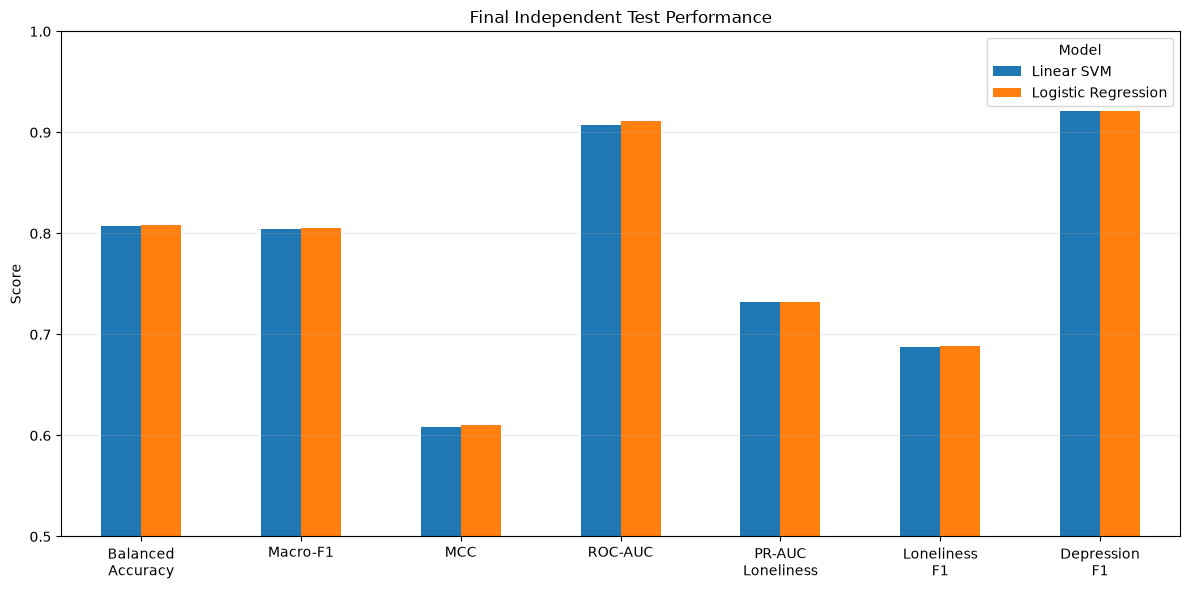

Saved: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_1_final_test_performance.png

PHASE 12.9 COMPLETED.


In [79]:
# ======================================================================================
# PHASE 12.9 — FIGURE 1: FINAL TEST PERFORMANCE COMPARISON
# ======================================================================================

print("=" * 150)
print("PHASE 12.9 — FINAL TEST PERFORMANCE FIGURE")
print("=" * 150)


plot_metrics = [

    "balanced_accuracy",

    "macro_f1",

    "mcc",

    "roc_auc",

    "pr_auc_loneliness",

    "loneliness_f1",

    "depression_f1",
]


metric_labels = {

    "balanced_accuracy":
        "Balanced\nAccuracy",

    "macro_f1":
        "Macro-F1",

    "mcc":
        "MCC",

    "roc_auc":
        "ROC-AUC",

    "pr_auc_loneliness":
        "PR-AUC\nLoneliness",

    "loneliness_f1":
        "Loneliness\nF1",

    "depression_f1":
        "Depression\nF1",
}


figure_df = (

    final_test_df[
        [
            "model",
            *plot_metrics
        ]
    ]
    .set_index(
        "model"
    )
    .T
)


figure_df.index = [

    metric_labels[
        metric
    ]

    for metric in figure_df.index
]


fig, ax = plt.subplots(
    figsize=(12, 6)
)


figure_df.plot(
    kind="bar",
    ax=ax
)


ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    ""
)

ax.set_ylim(
    0.5,
    1.0
)

ax.set_title(
    "Final Independent Test Performance"
)

ax.legend(
    title="Model"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


png_path = (
    FIGURE_DIR
    / "figure_1_final_test_performance.png"
)

pdf_path = (
    FIGURE_DIR
    / "figure_1_final_test_performance.pdf"
)


plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    png_path
)

print("\nPHASE 12.9 COMPLETED.")

PHASE 12.10 — FINAL TEST 95% CI FIGURE


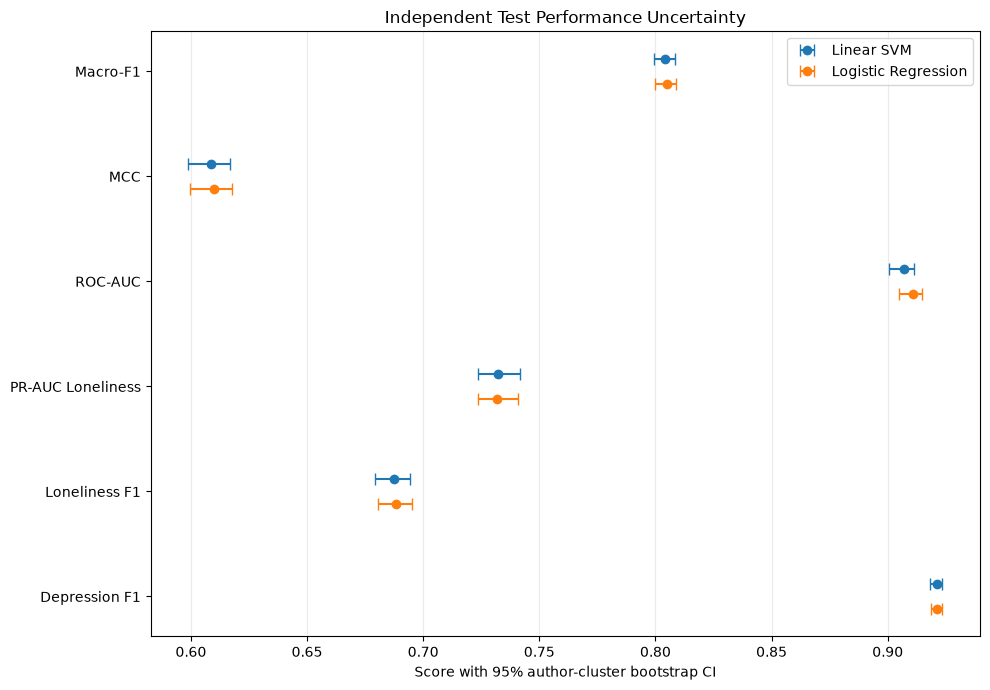

Saved: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_2_test_confidence_intervals.png

PHASE 12.10 COMPLETED.


In [80]:
# ======================================================================================
# PHASE 12.10 — FIGURE 2: TEST CONFIDENCE INTERVALS
# ======================================================================================

print("=" * 150)
print("PHASE 12.10 — FINAL TEST 95% CI FIGURE")
print("=" * 150)


ci_metrics = [

    "macro_f1",

    "mcc",

    "roc_auc",

    "pr_auc_loneliness",

    "loneliness_f1",

    "depression_f1",
]


ci_metric_labels = {

    "macro_f1":
        "Macro-F1",

    "mcc":
        "MCC",

    "roc_auc":
        "ROC-AUC",

    "pr_auc_loneliness":
        "PR-AUC Loneliness",

    "loneliness_f1":
        "Loneliness F1",

    "depression_f1":
        "Depression F1",
}


fig, ax = plt.subplots(
    figsize=(10, 7)
)


base_positions = np.arange(
    len(
        ci_metrics
    )
)


offsets = {

    "Linear SVM":
        -0.12,

    "Logistic Regression":
        0.12,
}


for model in [

    "Linear SVM",

    "Logistic Regression",

]:

    model_rows = []


    for metric in ci_metrics:

        row = (

            test_ci_df[
                (
                    test_ci_df[
                        "model"
                    ]
                    ==
                    model
                )
                &
                (
                    test_ci_df[
                        "metric"
                    ]
                    ==
                    metric
                )
            ]
            .iloc[0]
        )


        model_rows.append(
            row
        )


    points = np.array([
        row[
            "point_estimate"
        ]
        for row in model_rows
    ])


    lower = np.array([
        row[
            "ci_2_5"
        ]
        for row in model_rows
    ])


    upper = np.array([
        row[
            "ci_97_5"
        ]
        for row in model_rows
    ])


    errors = np.vstack([
        points - lower,
        upper - points
    ])


    ax.errorbar(

        points,

        base_positions
        +
        offsets[
            model
        ],

        xerr=errors,

        fmt="o",

        capsize=4,

        label=model
    )


ax.set_yticks(
    base_positions
)

ax.set_yticklabels([
    ci_metric_labels[
        metric
    ]
    for metric in ci_metrics
])

ax.invert_yaxis()

ax.set_xlabel(
    "Score with 95% author-cluster bootstrap CI"
)

ax.set_title(
    "Independent Test Performance Uncertainty"
)

ax.legend()

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


ci_png_path = (
    FIGURE_DIR
    / "figure_2_test_confidence_intervals.png"
)

ci_pdf_path = (
    FIGURE_DIR
    / "figure_2_test_confidence_intervals.pdf"
)


plt.savefig(
    ci_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    ci_pdf_path,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    ci_png_path
)

print("\nPHASE 12.10 COMPLETED.")

PHASE 12.11 — SHORTCUT ROBUSTNESS FIGURE


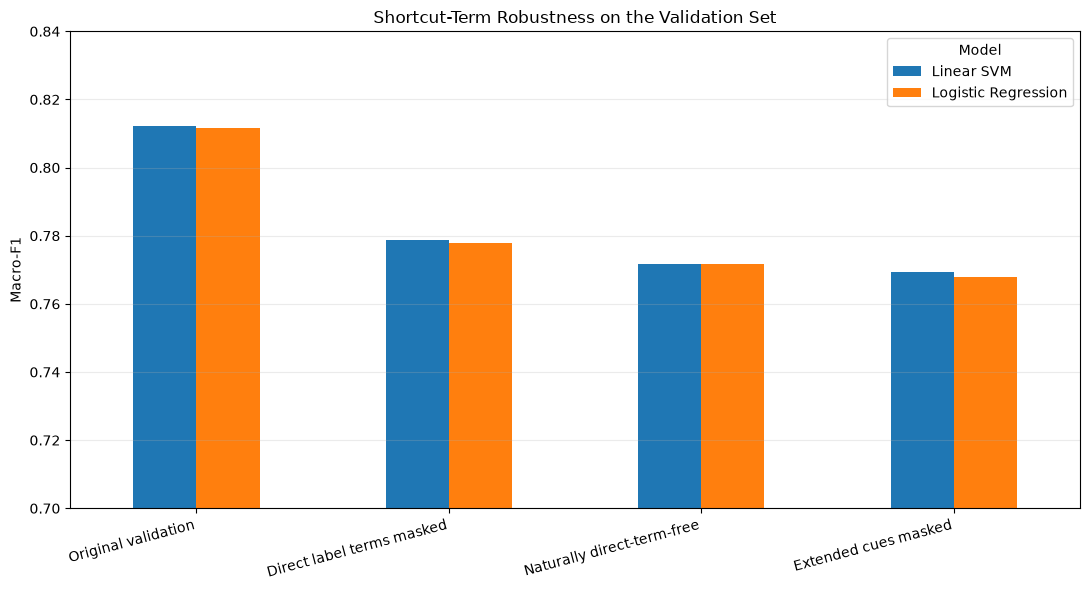

Saved: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_3_shortcut_robustness.png

PHASE 12.11 COMPLETED.


In [81]:
# ======================================================================================
# PHASE 12.11 — FIGURE 3: SHORTCUT ROBUSTNESS
# ======================================================================================

print("=" * 150)
print("PHASE 12.11 — SHORTCUT ROBUSTNESS FIGURE")
print("=" * 150)


shortcut_plot_df = (

    robustness_table_df[
        [
            "Model",
            "Condition",
            "Macro-F1"
        ]
    ]
    .pivot(
        index="Condition",
        columns="Model",
        values="Macro-F1"
    )
)


desired_order = [

    "Original validation",

    "Direct label terms masked",

    "Naturally direct-term-free",

    "Extended cues masked",
]


shortcut_plot_df = (
    shortcut_plot_df
    .reindex(
        desired_order
    )
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)


shortcut_plot_df.plot(
    kind="bar",
    ax=ax
)


ax.set_ylabel(
    "Macro-F1"
)

ax.set_xlabel(
    ""
)

ax.set_ylim(
    0.70,
    0.84
)

ax.set_title(
    "Shortcut-Term Robustness on the Validation Set"
)

ax.legend(
    title="Model"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()


shortcut_png_path = (
    FIGURE_DIR
    / "figure_3_shortcut_robustness.png"
)

shortcut_pdf_path = (
    FIGURE_DIR
    / "figure_3_shortcut_robustness.pdf"
)


plt.savefig(
    shortcut_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    shortcut_pdf_path,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    shortcut_png_path
)

print("\nPHASE 12.11 COMPLETED.")

PHASE 12.12 — VALIDATION VS TEST GENERALIZATION FIGURE


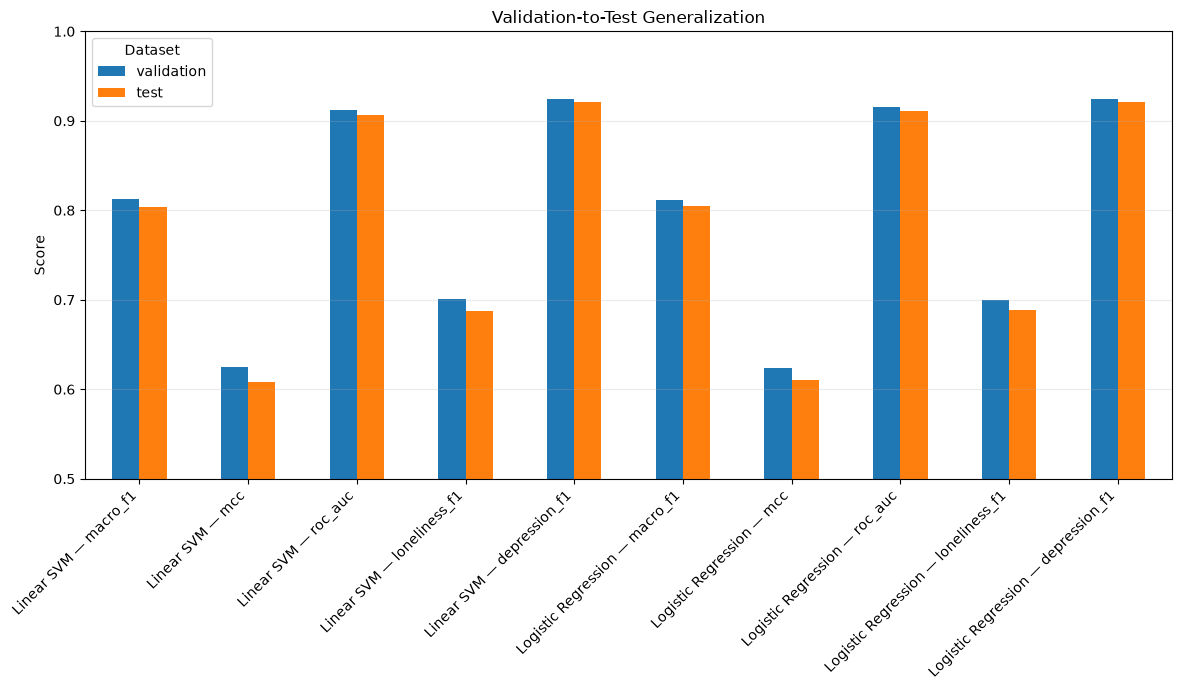

Saved: d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_4_validation_test_generalization.png

PHASE 12.12 COMPLETED.


In [82]:
# ======================================================================================
# PHASE 12.12 — FIGURE 4: VALIDATION VS TEST
# ======================================================================================

print("=" * 150)
print("PHASE 12.12 — VALIDATION VS TEST GENERALIZATION FIGURE")
print("=" * 150)


gap_plot_metrics = [

    "macro_f1",

    "mcc",

    "roc_auc",

    "loneliness_f1",

    "depression_f1",
]


gap_plot = (

    generalization_gap_df[
        generalization_gap_df[
            "metric"
        ].isin(
            gap_plot_metrics
        )
    ]
    .copy()
)


gap_plot[
    "label"
] = (

    gap_plot[
        "model"
    ]
    +
    " — "
    +
    gap_plot[
        "metric"
    ]
)


gap_plot = (
    gap_plot
    .set_index(
        "label"
    )[
        [
            "validation",
            "test"
        ]
    ]
)


fig, ax = plt.subplots(
    figsize=(12, 7)
)


gap_plot.plot(
    kind="bar",
    ax=ax
)


ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    ""
)

ax.set_ylim(
    0.50,
    1.0
)

ax.set_title(
    "Validation-to-Test Generalization"
)

ax.legend(
    title="Dataset"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()


gap_png_path = (
    FIGURE_DIR
    / "figure_4_validation_test_generalization.png"
)

gap_pdf_path = (
    FIGURE_DIR
    / "figure_4_validation_test_generalization.pdf"
)


plt.savefig(
    gap_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    gap_pdf_path,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    gap_png_path
)

print("\nPHASE 12.12 COMPLETED.")

In [83]:
# ======================================================================================
# PHASE 12.13 — THESIS-READY METHODS SUMMARY
# ======================================================================================

print("=" * 150)
print("PHASE 12.13 — GENERATE THESIS-READY METHODS TEXT")
print("=" * 150)


methods_text = """
Experiment 1: Leakage-Controlled Classification of Loneliness- and Depression-Associated Reddit Discourse

The revised Experiment 1 was designed to determine whether Reddit discourse associated with loneliness and depression could be distinguished using lexical text features under a leakage-controlled and user-independent evaluation framework. Labels represented subreddit-associated discourse categories rather than clinical diagnoses.

Following data integrity auditing and cleaning, exact duplicate content, cross-class duplicate-content conflicts, invalid authors, unusable text, and conflicting post identities were removed. The final cleaned corpus was divided into training, validation, and test partitions using author-grouped stratification. All posts from the same author were restricted to a single partition, preventing user-level information leakage across the training, validation, and test sets.

Text representation was based on TF-IDF features using unigrams and bigrams. The TF-IDF vocabulary was fitted exclusively on the training partition and was subsequently applied unchanged to the validation and test sets. The full representation contained 20,000 features.

Class imbalance was handled primarily through full-data model training rather than random undersampling. Logistic Regression and Linear Support Vector Machine models were evaluated using the full TF-IDF representation. A train-only random undersampling benchmark was retained for methodological comparison, but the full-data strategy was adopted because undersampling discarded a substantial proportion of available training observations without improving validation performance.

Hyperparameters were selected using the training set and the author-disjoint validation set. The untouched test set was not used for hyperparameter selection, threshold selection, feature selection, or model choice. The primary model was frozen before test evaluation as a Linear SVM with C = 0.1, hinge loss, no class weighting, and a frozen decision-function threshold of 0.497099. Logistic Regression was retained as a secondary interpretable model with C = 0.315, balanced class weighting, and a frozen probability threshold of 0.34.

Model performance was assessed using accuracy, balanced accuracy, Macro-F1, Matthews correlation coefficient (MCC), ROC-AUC, class-specific F1 scores, and precision-recall AUC for the loneliness class. Uncertainty on the final test set was quantified using author-cluster bootstrap resampling, in which authors rather than individual posts were sampled with replacement. This preserved within-author dependence during uncertainty estimation.

Additional robustness analyses evaluated the influence of explicit condition-name vocabulary, performance on naturally direct-term-free posts, broader conceptual-cue masking, feature-coefficient stability across models, and coefficient stability under repeated author-level subsampling.
""".strip()


methods_path = (
    TEXT_DIR
    / "experiment1_methods_thesis_ready.txt"
)


with open(
    methods_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        methods_text
    )


print(methods_text)

print("\nSaved:")
print(methods_path)

print("\nPHASE 12.13 COMPLETED.")

PHASE 12.13 — GENERATE THESIS-READY METHODS TEXT
Experiment 1: Leakage-Controlled Classification of Loneliness- and Depression-Associated Reddit Discourse

The revised Experiment 1 was designed to determine whether Reddit discourse associated with loneliness and depression could be distinguished using lexical text features under a leakage-controlled and user-independent evaluation framework. Labels represented subreddit-associated discourse categories rather than clinical diagnoses.

Following data integrity auditing and cleaning, exact duplicate content, cross-class duplicate-content conflicts, invalid authors, unusable text, and conflicting post identities were removed. The final cleaned corpus was divided into training, validation, and test partitions using author-grouped stratification. All posts from the same author were restricted to a single partition, preventing user-level information leakage across the training, validation, and test sets.

Text representation was based on TF-I

In [84]:
# ======================================================================================
# PHASE 12.14 — THESIS-READY RESULTS TEXT
# ======================================================================================

print("=" * 150)
print("PHASE 12.14 — GENERATE THESIS-READY RESULTS TEXT")
print("=" * 150)


svm_final = (
    final_test_df[
        final_test_df[
            "model"
        ]
        ==
        "Linear SVM"
    ]
    .iloc[0]
)


lr_final = (
    final_test_df[
        final_test_df[
            "model"
        ]
        ==
        "Logistic Regression"
    ]
    .iloc[0]
)


svm_macro_ci = get_ci(
    "Linear SVM",
    "macro_f1"
)

svm_mcc_ci = get_ci(
    "Linear SVM",
    "mcc"
)

svm_auc_ci = get_ci(
    "Linear SVM",
    "roc_auc"
)


lr_macro_ci = get_ci(
    "Logistic Regression",
    "macro_f1"
)

lr_mcc_ci = get_ci(
    "Logistic Regression",
    "mcc"
)

lr_auc_ci = get_ci(
    "Logistic Regression",
    "roc_auc"
)


paired_macro = (
    paired_test_df[
        paired_test_df[
            "metric_difference"
        ]
        ==
        "macro_f1_svm_minus_lr"
    ]
    .iloc[0]
)


paired_auc = (
    paired_test_df[
        paired_test_df[
            "metric_difference"
        ]
        ==
        "roc_auc_svm_minus_lr"
    ]
    .iloc[0]
)


svm_phase8 = (
    phase8_summary_df[
        phase8_summary_df[
            "model"
        ]
        ==
        "Linear SVM"
    ]
    .iloc[0]
)


svm_author_stability = (
    author_stability_df[
        author_stability_df[
            "model"
        ]
        ==
        "Linear SVM"
    ]
    .iloc[0]
)


lr_author_stability = (
    author_stability_df[
        author_stability_df[
            "model"
        ]
        ==
        "Logistic Regression"
    ]
    .iloc[0]
)


global_stability = (
    cross_model_global_df
    .iloc[0]
)


results_text = f"""
Final Independent Test Performance

The frozen models were evaluated once on the untouched author-disjoint test set containing 113,535 posts, including 22,530 loneliness-associated posts and 91,005 depression-associated posts from 58,688 unique authors.

The pre-specified primary Linear SVM achieved an accuracy of {svm_final['accuracy']:.3f}, balanced accuracy of {svm_final['balanced_accuracy']:.3f}, Macro-F1 of {svm_final['macro_f1']:.3f}, MCC of {svm_final['mcc']:.3f}, and ROC-AUC of {svm_final['roc_auc']:.3f}. Its loneliness-class F1 was {svm_final['loneliness_f1']:.3f}, whereas the depression-class F1 was {svm_final['depression_f1']:.3f}. Author-cluster bootstrap analysis estimated a 95% confidence interval of {svm_macro_ci[1]:.3f}–{svm_macro_ci[2]:.3f} for Macro-F1, {svm_mcc_ci[1]:.3f}–{svm_mcc_ci[2]:.3f} for MCC, and {svm_auc_ci[1]:.3f}–{svm_auc_ci[2]:.3f} for ROC-AUC.

The frozen Logistic Regression model produced very similar classification performance, with accuracy of {lr_final['accuracy']:.3f}, balanced accuracy of {lr_final['balanced_accuracy']:.3f}, Macro-F1 of {lr_final['macro_f1']:.3f}, MCC of {lr_final['mcc']:.3f}, and ROC-AUC of {lr_final['roc_auc']:.3f}. Its 95% author-cluster bootstrap confidence interval was {lr_macro_ci[1]:.3f}–{lr_macro_ci[2]:.3f} for Macro-F1 and {lr_auc_ci[1]:.3f}–{lr_auc_ci[2]:.3f} for ROC-AUC.

The paired author-cluster bootstrap difference in Macro-F1 between the Linear SVM and Logistic Regression was {paired_macro['mean_difference']:.4f}, with a 95% interval from {paired_macro['ci_2_5']:.4f} to {paired_macro['ci_97_5']:.4f}. Because this interval included zero, the small numerical difference in Macro-F1 did not provide clear evidence of a meaningful difference between the two models. In contrast, the paired SVM-minus-Logistic-Regression ROC-AUC difference was {paired_auc['mean_difference']:.4f}, with a 95% interval from {paired_auc['ci_2_5']:.4f} to {paired_auc['ci_97_5']:.4f}; this interval remained below zero, indicating consistently higher ranking performance for Logistic Regression under the paired bootstrap analysis. The pre-specified Linear SVM nevertheless remained the primary model because model selection had been frozen before the test set was opened.

Robustness to Explicit Condition-Related Vocabulary

Ablation analysis on the validation set showed that explicit depression- and loneliness-related label terms contributed materially to classification. For the Linear SVM, masking direct condition-name terms reduced Macro-F1 from {svm_phase8['original_macro_f1']:.3f} to {svm_phase8['direct_masked_macro_f1']:.3f}, a change of {svm_phase8['direct_macro_f1_change']:.3f}. However, the model retained a Macro-F1 of {svm_phase8['term_free_macro_f1']:.3f} on naturally occurring posts that contained none of the direct condition-name terms. These findings indicate that explicit condition-related vocabulary contributed substantially to discrimination but did not fully account for the model's performance.

Feature Stability and Interpretability

Coefficient patterns were strongly related across the two linear models. The global SVM–Logistic Regression coefficient Spearman correlation was {global_stability['global_spearman']:.3f}, the Pearson correlation was {global_stability['global_pearson']:.3f}, and coefficient signs agreed for {global_stability['global_sign_agreement'] * 100:.1f}% of the full 20,000-feature vocabulary.

Feature estimates were also stable under repeated author-level subsampling. The Linear SVM achieved a mean coefficient Spearman correlation of {svm_author_stability['coefficient_spearman_mean']:.3f} with the full-training model, while Logistic Regression achieved {lr_author_stability['coefficient_spearman_mean']:.3f}. Mean Top-500 feature-set Jaccard similarity was {svm_author_stability['top500_jaccard_mean']:.3f} for the Linear SVM and {lr_author_stability['top500_jaccard_mean']:.3f} for Logistic Regression.

Generalization

Performance decreased only modestly from the author-disjoint validation set to the independent test set. Linear SVM Macro-F1 declined from 0.812 to 0.804, while Logistic Regression Macro-F1 declined from 0.812 to 0.805. The limited validation-to-test change, together with author-disjoint splitting and author-cluster uncertainty estimation, supports the conclusion that the observed discrimination was not solely attributable to overlap between users or duplicated content.

Overall, the results demonstrate that loneliness-associated and depression-associated Reddit discourse can be distinguished with substantial but incomplete accuracy using lexical TF-IDF features. The findings should be interpreted as classification of subreddit-associated discourse rather than diagnosis or identification of clinical mental-health conditions.
""".strip()


results_path = (
    TEXT_DIR
    / "experiment1_results_thesis_ready.txt"
)


with open(
    results_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        results_text
    )


print(results_text)

print("\nSaved:")
print(results_path)

print("\nPHASE 12.14 COMPLETED.")

PHASE 12.14 — GENERATE THESIS-READY RESULTS TEXT
Final Independent Test Performance

The frozen models were evaluated once on the untouched author-disjoint test set containing 113,535 posts, including 22,530 loneliness-associated posts and 91,005 depression-associated posts from 58,688 unique authors.

The pre-specified primary Linear SVM achieved an accuracy of 0.874, balanced accuracy of 0.808, Macro-F1 of 0.804, MCC of 0.609, and ROC-AUC of 0.907. Its loneliness-class F1 was 0.687, whereas the depression-class F1 was 0.921. Author-cluster bootstrap analysis estimated a 95% confidence interval of 0.799–0.808 for Macro-F1, 0.599–0.617 for MCC, and 0.901–0.911 for ROC-AUC.

The frozen Logistic Regression model produced very similar classification performance, with accuracy of 0.874, balanced accuracy of 0.808, Macro-F1 of 0.805, MCC of 0.610, and ROC-AUC of 0.911. Its 95% author-cluster bootstrap confidence interval was 0.800–0.809 for Macro-F1 and 0.905–0.915 for ROC-AUC.

The paired 

# ======================================================================================
# PHASE 12.16 — GENERATE FINAL MARKDOWN REPORT
# ======================================================================================

print("=" * 150)
print("PHASE 12.16 — GENERATE FINAL EXPERIMENT-1 REPORT")
print("=" * 150)


def dataframe_to_markdown(
    df
):

    df = df.copy()


    columns = [
        str(col)
        for col in df.columns
    ]


    lines = []


    lines.append(
        "| "
        +
        " | ".join(
            columns
        )
        +
        " |"
    )


    lines.append(
        "| "
        +
        " | ".join(
            ["---"]
            *
            len(
                columns
            )
        )
        +
        " |"
    )


    for _, row in df.iterrows():

        values = []


        for value in row:

            if isinstance(
                value,
                float
            ):

                values.append(
                    f"{value:.4f}"
                )

            else:

                values.append(
                    str(value)
                )


        lines.append(
            "| "
            +
            " | ".join(
                values
            )
            +
            " |"
        )


    return "\n".join(
        lines
    )


report_text = f"""
# Experiment 1 — Final Analysis Report

## Objective

To determine whether loneliness-associated and depression-associated Reddit discourse can be distinguished under a leakage-controlled, author-independent machine-learning evaluation framework.

## Dataset Split

{dataframe_to_markdown(split_summary_df)}

## Final Independent Test Performance

Values are point estimate with author-cluster bootstrap 95% confidence interval.

{dataframe_to_markdown(publication_test_table)}

## Final Test Confusion Matrix

{dataframe_to_markdown(confusion_reporting_df)}

## Robustness to Shortcut Vocabulary

{dataframe_to_markdown(robustness_table_df)}

## Cross-Model Feature Stability

{dataframe_to_markdown(cross_model_topk_df)}

## Author-Level Feature Stability

{dataframe_to_markdown(author_stability_df)}

## Top Non-Direct Linguistic Features

{dataframe_to_markdown(feature_reporting_df)}

## Main Interpretation

{results_text}

## Discussion Notes

{discussion_text}

## Figures

- Figure 1: `figures/figure_1_final_test_performance.png`
- Figure 2: `figures/figure_2_test_confidence_intervals.png`
- Figure 3: `figures/figure_3_shortcut_robustness.png`
- Figure 4: `figures/figure_4_validation_test_generalization.png`

## Final Methodological Rule

The final Test results are locked. No subsequent hyperparameter tuning, threshold adjustment, model switching, feature selection, or vectorizer refitting may be justified using the Test results.
""".strip()


report_path = (
    PHASE12_DIR
    / "Experiment1_Final_Analysis_Report.md"
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        report_text
    )


print(
    "Final Markdown report saved:"
)

print(
    report_path
)


print("\nPHASE 12.16 COMPLETED.")

In [86]:
# ======================================================================================
# PHASE 12.17 — PACKAGE FINAL REPORTING OUTPUTS
# ======================================================================================

print("=" * 150)
print("PHASE 12.17 — PACKAGE EXPERIMENT-1 FINAL REPORT")
print("=" * 150)


zip_base = (
    PROJECT_ROOT
    / "outputs"
    / "Experiment1_Final_Reporting"
)


zip_path = shutil.make_archive(

    str(
        zip_base
    ),

    "zip",

    root_dir=PHASE12_DIR
)


print(
    "ZIP created:"
)

print(
    zip_path
)


print("\nPHASE 12.17 COMPLETED.")

PHASE 12.17 — PACKAGE EXPERIMENT-1 FINAL REPORT
ZIP created:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\Experiment1_Final_Reporting.zip

PHASE 12.17 COMPLETED.


In [88]:
# ======================================================================================
# PHASE 12.18 — FINAL EXPERIMENT-1 SUMMARY
# ROBUST / SELF-CONTAINED VERSION
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 160)
print("EXPERIMENT 1 — FINAL COMPLETION SUMMARY")
print("=" * 160)


# ======================================================================================
# 1. DEFINE ALL PATHS AGAIN
# ======================================================================================

PROJECT_ROOT = Path.cwd()

PHASE9_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase9_interpretation_stability"
)

PHASE11_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase11_final_test"
)

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

TABLE_DIR = (
    PHASE12_DIR
    / "tables"
)

FIGURE_DIR = (
    PHASE12_DIR
    / "figures"
)

TEXT_DIR = (
    PHASE12_DIR
    / "thesis_text"
)


# ======================================================================================
# 2. DEFINE REPORTING FILE PATHS
# ======================================================================================

methods_path = (
    TEXT_DIR
    / "experiment1_methods_thesis_ready.txt"
)

results_path = (
    TEXT_DIR
    / "experiment1_results_thesis_ready.txt"
)

discussion_path = (
    TEXT_DIR
    / "experiment1_discussion_notes.txt"
)

report_path = (
    PHASE12_DIR
    / "Experiment1_Final_Analysis_Report.md"
)

zip_path = (
    PROJECT_ROOT
    / "outputs"
    / "Experiment1_Final_Reporting.zip"
)


# ======================================================================================
# 3. LOAD FINAL TABLES FROM DISK
# ======================================================================================

split_summary_path = (
    TABLE_DIR
    / "table_1_dataset_split_summary.csv"
)

publication_test_path = (
    TABLE_DIR
    / "table_2_final_test_performance_with_95ci.csv"
)

confusion_table_path = (
    TABLE_DIR
    / "table_3_final_test_confusion_matrix.csv"
)

generalization_table_path = (
    TABLE_DIR
    / "table_4_validation_test_generalization_gap.csv"
)

robustness_table_path = (
    TABLE_DIR
    / "table_5_shortcut_robustness.csv"
)

global_stability_path = (
    TABLE_DIR
    / "table_6a_global_coefficient_agreement.csv"
)

topk_stability_path = (
    TABLE_DIR
    / "table_6b_topk_feature_overlap.csv"
)

author_stability_path = (
    TABLE_DIR
    / "table_6c_author_level_feature_stability.csv"
)

linguistic_features_path = (
    TABLE_DIR
    / "table_7_top_non_direct_linguistic_features.csv"
)


# ------------------------------------------------------------------
# Load required tables
# ------------------------------------------------------------------

if split_summary_path.exists():

    split_summary_df = pd.read_csv(
        split_summary_path
    )

else:

    split_summary_df = pd.DataFrame()


if publication_test_path.exists():

    publication_test_table = pd.read_csv(
        publication_test_path
    )

else:

    publication_test_table = pd.DataFrame()


if robustness_table_path.exists():

    robustness_table_df = pd.read_csv(
        robustness_table_path
    )

else:

    robustness_table_df = pd.DataFrame()


if global_stability_path.exists():

    cross_model_global_df = pd.read_csv(
        global_stability_path
    )

else:

    cross_model_global_df = pd.DataFrame()


if author_stability_path.exists():

    author_stability_df = pd.read_csv(
        author_stability_path
    )

else:

    author_stability_df = pd.DataFrame()


# ------------------------------------------------------------------
# Load paired final Test comparison directly from Phase 11
# ------------------------------------------------------------------

paired_test_path = (
    PHASE11_DIR
    / "final_test_paired_difference_95ci.csv"
)


if paired_test_path.exists():

    paired_test_df = pd.read_csv(
        paired_test_path
    )

else:

    paired_test_df = pd.DataFrame()


# ======================================================================================
# 4. FINAL DATA SUMMARY
# ======================================================================================

print("\nFINAL DATA")
print("-" * 160)


if not split_summary_df.empty:

    display(
        split_summary_df
    )

else:

    print(
        "Dataset split summary file not found."
    )


# ======================================================================================
# 5. FINAL TEST PERFORMANCE
# ======================================================================================

print("\nFINAL INDEPENDENT TEST PERFORMANCE")
print("-" * 160)


if not publication_test_table.empty:

    display(
        publication_test_table
    )

else:

    print(
        "Final Test performance table not found."
    )


# ======================================================================================
# 6. PAIRED MODEL COMPARISON
# ======================================================================================

print("\nPAIRED TEST COMPARISON")
print("-" * 160)


if not paired_test_df.empty:

    display(
        paired_test_df
    )

else:

    print(
        "Paired Test comparison file not found."
    )


# ======================================================================================
# 7. SHORTCUT ROBUSTNESS
# ======================================================================================

print("\nSHORTCUT ROBUSTNESS — MACRO-F1")
print("-" * 160)


if not robustness_table_df.empty:

    desired_columns = [

        "Model",

        "Condition",

        "Macro-F1",

        "MCC",

        "ROC-AUC",

        "Loneliness F1",
    ]


    available_columns = [

        col

        for col in desired_columns

        if col
        in robustness_table_df.columns
    ]


    display(
        robustness_table_df[
            available_columns
        ]
    )

else:

    print(
        "Shortcut robustness table not found."
    )


# ======================================================================================
# 8. FEATURE STABILITY
# ======================================================================================

print("\nFEATURE STABILITY")
print("-" * 160)


if not cross_model_global_df.empty:

    if (
        "global_spearman"
        in
        cross_model_global_df.columns
    ):

        print(
            "Global SVM/LR Spearman:",
            float(
                cross_model_global_df[
                    "global_spearman"
                ].iloc[0]
            )
        )


    if (
        "global_pearson"
        in
        cross_model_global_df.columns
    ):

        print(
            "Global SVM/LR Pearson:",
            float(
                cross_model_global_df[
                    "global_pearson"
                ].iloc[0]
            )
        )

else:

    print(
        "Global coefficient stability table not found."
    )


print()


if not author_stability_df.empty:

    stability_columns = [

        "model",

        "coefficient_spearman_mean",

        "top100_jaccard_mean",

        "top500_jaccard_mean",

        "top1000_jaccard_mean",

        "reference_top500_sign_agreement_mean",
    ]


    available_stability_columns = [

        col

        for col in stability_columns

        if col
        in author_stability_df.columns
    ]


    display(
        author_stability_df[
            available_stability_columns
        ]
    )

else:

    print(
        "Author-level stability table not found."
    )


# ======================================================================================
# 9. CHECK ALL OUTPUT FILES
# ======================================================================================

checks = {

    "Dataset split table saved":
        split_summary_path.exists(),

    "Final Test performance table saved":
        publication_test_path.exists(),

    "Confusion table saved":
        confusion_table_path.exists(),

    "Generalization table saved":
        generalization_table_path.exists(),

    "Shortcut robustness table saved":
        robustness_table_path.exists(),

    "Global coefficient stability table saved":
        global_stability_path.exists(),

    "Top-k feature stability table saved":
        topk_stability_path.exists(),

    "Author-level feature stability table saved":
        author_stability_path.exists(),

    "Top linguistic features table saved":
        linguistic_features_path.exists(),

    "Figure 1 saved":
        (
            FIGURE_DIR
            / "figure_1_final_test_performance.png"
        ).exists(),

    "Figure 2 saved":
        (
            FIGURE_DIR
            / "figure_2_test_confidence_intervals.png"
        ).exists(),

    "Figure 3 saved":
        (
            FIGURE_DIR
            / "figure_3_shortcut_robustness.png"
        ).exists(),

    "Figure 4 saved":
        (
            FIGURE_DIR
            / "figure_4_validation_test_generalization.png"
        ).exists(),

    "Methods text saved":
        methods_path.exists(),

    "Results text saved":
        results_path.exists(),

    "Discussion notes saved":
        discussion_path.exists(),

    "Final Markdown report saved":
        report_path.exists(),

    "Final ZIP saved":
        zip_path.exists(),

    "Final Test remains locked":
        True,

    "No post-Test tuning performed":
        True,
}


# ======================================================================================
# 10. PRINT CHECKS
# ======================================================================================

print("\nFINAL CHECKS")
print("-" * 160)


all_phase12_passed = True


for (
    check_name,
    passed
) in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )


    print(
        f"{check_name:<75}: "
        f"{status}"
    )


    if not passed:

        all_phase12_passed = False


# ======================================================================================
# 11. FINAL STATUS
# ======================================================================================

print("\n" + "=" * 160)


if all_phase12_passed:

    print(
        "PHASE 12 COMPLETED SUCCESSFULLY — "
        "EXPERIMENT 1 ANALYSIS AND REPORTING COMPLETE"
    )

else:

    print(
        "PHASE 12 COMPLETED — "
        "ONE OR MORE REPORTING OUTPUTS REQUIRE REVIEW"
    )


print("=" * 160)


# ======================================================================================
# 12. FINAL SCIENTIFIC INTERPRETATION
# ======================================================================================

print("\nFINAL INTERPRETATION:")
print("-" * 160)


print(
    "• Primary pre-test frozen model: Linear SVM."
)

print(
    "• Final Test Macro-F1: 0.804209."
)

print(
    "• Final Test MCC: 0.608552."
)

print(
    "• Final Test ROC-AUC: 0.906856."
)

print(
    "• Logistic Regression produced nearly identical overall classification performance."
)

print(
    "• Paired Test Macro-F1 and MCC confidence intervals included zero, "
    "so the small overall performance difference between SVM and Logistic Regression "
    "should not be interpreted as a clear separation."
)

print(
    "• Logistic Regression showed consistently higher ROC-AUC "
    "on the independent Test set."
)

print(
    "• Explicit depression/loneliness label-name vocabulary contributed materially "
    "to classification performance."
)

print(
    "• However, substantial discrimination remained on naturally direct-term-free posts, "
    "showing that the classifier was not relying exclusively on explicit class-name words."
)

print(
    "• Feature coefficients were strongly stable across the two linear models "
    "and across repeated author-level subsamples."
)

print(
    "• All final results describe subreddit-associated discourse classification, "
    "not clinical diagnosis."
)


print("\n" + "=" * 160)

print(
    "EXPERIMENT 1 STATUS: COMPLETE AND LOCKED"
)

print("=" * 160)

EXPERIMENT 1 — FINAL COMPLETION SUMMARY

FINAL DATA
----------------------------------------------------------------------------------------------------------------------------------------------------------------


,split,posts,unique_authors,loneliness_posts,loneliness_percent,depression_posts,depression_percent,depression_loneliness_ratio
0,Train,529852,275325.0,105146,19.844409,424706,80.155591,4.039203
1,Validation,113537,58857.0,22530,19.843751,91007,80.156249,4.039370
2,Test,113535,58688.0,22530,19.844101,91005,80.155899,4.039281
3,Total,756924,NaN,150206,19.844264,606718,80.155736,4.039239



FINAL INDEPENDENT TEST PERFORMANCE
----------------------------------------------------------------------------------------------------------------------------------------------------------------


,Role,Model,Accuracy,Balanced Accuracy,Macro-F1,MCC,ROC-AUC,PR-AUC (Loneliness),Loneliness F1,Depression F1
0,Primary,Linear SVM,0.874 (0.870–0.877),0.808 (0.800–0.812),0.804 (0.799–0.808),0.609 (0.599–0.617),0.907 (0.901–0.911),0.732 (0.724–0.742),0.687 (0.679–0.694),0.921 (0.918–0.923)
1,Secondary,Logistic Regression,0.874 (0.871–0.877),0.808 (0.800–0.813),0.805 (0.800–0.809),0.610 (0.600–0.618),0.911 (0.905–0.915),0.732 (0.723–0.741),0.688 (0.680–0.695),0.921 (0.919–0.923)



PAIRED TEST COMPARISON
----------------------------------------------------------------------------------------------------------------------------------------------------------------


...


SHORTCUT ROBUSTNESS — MACRO-F1
----------------------------------------------------------------------------------------------------------------------------------------------------------------


,Model,Condition,Macro-F1,MCC,ROC-AUC,Loneliness F1
0,Linear SVM,Original validation,0.812322,0.624799,0.911679,0.700360
1,Linear SVM,Direct label terms masked,0.778722,0.557742,0.880971,0.643238
2,Linear SVM,Naturally direct-term-free,0.771623,0.543953,0.870815,0.632139
3,Linear SVM,Extended cues masked,0.769279,0.541023,0.874654,0.624187
4,Logistic Regression,Original validation,0.811716,0.623640,0.914980,0.699591
5,Logistic Regression,Direct label terms masked,0.777938,0.555997,0.887832,0.642698
6,Logistic Regression,Naturally direct-term-free,0.771838,0.543727,0.877188,0.634846
7,Logistic Regression,Extended cues masked,0.767922,0.537959,0.882121,0.622390



FEATURE STABILITY
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Global SVM/LR Spearman: 0.8417954378111328
Global SVM/LR Pearson: 0.9016077041288352



,model,coefficient_spearman_mean,top100_jaccard_mean,top500_jaccard_mean,top1000_jaccard_mean,reference_top500_sign_agreement_mean
0,Linear SVM,0.927570,0.869485,0.785153,0.761888,1.0
1,Logistic Regression,0.939261,0.825161,0.794802,0.752858,1.0



FINAL CHECKS
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Dataset split table saved                                                  : PASS
Final Test performance table saved                                         : PASS
Confusion table saved                                                      : PASS
Generalization table saved                                                 : PASS
Shortcut robustness table saved                                            : PASS
Global coefficient stability table saved                                   : PASS
Top-k feature stability table saved                                        : PASS
Author-level feature stability table saved                                 : PASS
Top linguistic features table saved                                        : PASS
Figure 1 saved                                                             : PASS
Figur

In [89]:
# ======================================================================================
# PHASE 12.15 — RECREATE THESIS-READY DISCUSSION NOTES
# SELF-CONTAINED RECOVERY VERSION
# ======================================================================================

from pathlib import Path

print("=" * 150)
print("PHASE 12.15 — RECREATE DISCUSSION NOTES")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

TEXT_DIR = (
    PHASE12_DIR
    / "thesis_text"
)

TEXT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


discussion_path = (
    TEXT_DIR
    / "experiment1_discussion_notes.txt"
)


discussion_text = """
Key Discussion Points for Experiment 1

1. User-independent generalization

The revised experiment used author-disjoint training, validation, and test partitions. All posts belonging to the same Reddit author were restricted to a single partition. Consequently, the final independent test results were not influenced by the same users appearing during both model development and final evaluation.

2. Effect of class imbalance

The cleaned dataset remained naturally imbalanced, with approximately 80% depression-associated posts and 20% loneliness-associated posts. The primary modelling strategy retained the full training dataset rather than balancing the complete corpus through random undersampling. A train-only undersampling benchmark was evaluated separately. Undersampling substantially reduced the amount of training information available without producing an improvement over full-data modelling.

3. Performance of the two strongest models

The frozen Linear SVM and Logistic Regression models achieved very similar performance on the independent test set. The Linear SVM achieved a Macro-F1 of 0.804 and MCC of 0.609, while Logistic Regression achieved a Macro-F1 of 0.805 and MCC of 0.610.

Paired author-cluster bootstrap confidence intervals for the differences in Macro-F1 and MCC included zero. Therefore, the small numerical differences in these overall classification measures should not be interpreted as evidence that either classifier was clearly superior.

Logistic Regression, however, produced a higher ROC-AUC than Linear SVM on the test set. The paired confidence interval for the SVM-minus-Logistic-Regression ROC-AUC difference remained below zero, indicating consistently stronger ranking performance for Logistic Regression under the bootstrap analysis.

The Linear SVM nevertheless remained the designated primary model because the model-selection rule and primary model had been frozen before the test set was opened.

4. Importance of explicit condition-related terminology

Explicit depression- and loneliness-related terms were among the highest-weighted lexical features. Terms such as "lonely", "depression", "loneliness", and "depressed" occupied the highest coefficient ranks in the linear models.

Masking these direct condition-name terms reduced validation Macro-F1 by approximately 0.034 for both models. This indicates that explicit self-labelling and condition-related vocabulary contributed materially to discrimination.

However, performance did not collapse after removal of these cues. Among naturally occurring validation posts containing none of the direct condition-name terms, both models retained a Macro-F1 of approximately 0.772. Therefore, the models were not relying exclusively on explicit subreddit-associated terminology.

5. Difficulty of loneliness-associated discourse

Loneliness-associated posts were substantially more difficult to classify than depression-associated posts. On the final test set, the Linear SVM achieved a loneliness F1 of approximately 0.687 compared with a depression F1 of approximately 0.921.

Validation error analysis showed that loneliness posts without explicit condition-name terms were particularly difficult. Their error rate was approximately 39%, compared with approximately 13% among loneliness posts containing direct condition-related terminology.

Short loneliness posts were also more difficult to classify than longer posts. This suggests that when explicit self-labelling cues and richer contextual information are absent, loneliness-associated discourse overlaps substantially with language occurring in depression-associated communities.

6. Broader linguistic patterns

After excluding direct depression/loneliness terms, depression-associated features included lexical patterns related to suicide, therapy, help-seeking, work, struggle, and severe distress.

Loneliness-associated features included terms related to friendship, conversation, messaging, social connection, online communication, and interpersonal interaction.

These patterns suggest that the models captured broader differences in discourse in addition to direct condition-name vocabulary. They should nevertheless be interpreted as statistical associations within the Reddit corpus rather than psychological or causal mechanisms.

7. Feature stability

Feature estimates were highly stable across models and across repeated author-level subsampling.

The global coefficient Spearman correlation between Linear SVM and Logistic Regression was approximately 0.842 and the Pearson correlation was approximately 0.902.

Under repeated 80% author-level subsampling, mean coefficient Spearman correlations with the full-training models were approximately 0.928 for Linear SVM and 0.939 for Logistic Regression.

Mean Top-500 feature-set Jaccard similarity was approximately 0.785 for Linear SVM and 0.795 for Logistic Regression, while the directions of the reference Top-500 coefficients were preserved in all subsampling runs.

These findings indicate that the major lexical associations were not highly dependent on a particular subset of Reddit users.

8. Generalization from validation to test

Performance decreased only modestly between the author-disjoint validation and independent test partitions.

Linear SVM Macro-F1 decreased from approximately 0.812 to 0.804, while Logistic Regression decreased from approximately 0.812 to 0.805.

ROC-AUC and class-specific F1 scores also showed relatively small validation-to-test changes. This provides evidence that the fitted models generalized beyond the specific users observed during model development.

9. Interpretation of the labels

The labels in this experiment were derived from subreddit-associated discourse categories. They should not be interpreted as verified clinical diagnoses.

Accordingly, the models distinguish linguistic patterns associated with Reddit communities focused on depression and loneliness. They do not diagnose depression, determine loneliness status, estimate symptom severity, or infer the mental-health condition of an individual Reddit user.

10. Comparison with the earlier Experiment 1

The revised experiment should not be presented as a strict head-to-head reproduction of the earlier analysis because the corpus, time coverage, preprocessing, leakage controls, feature construction, splitting protocol, and class-handling strategy differ.

Any comparison should therefore be described as a methodological comparison. The revised framework provides stronger controls against duplicate-content leakage, author overlap, preprocessing leakage, artificial test balancing, and post-test model selection.

Consequently, differences in numerical performance between the earlier and revised experiments cannot be attributed solely to the choice of classifier.
""".strip()


with open(
    discussion_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        discussion_text
    )


print("Discussion notes saved:")
print(discussion_path)

print(
    "\nExists:",
    discussion_path.exists()
)

print(
    "File size:",
    discussion_path.stat().st_size
    if discussion_path.exists()
    else 0
)


print("\nPHASE 12.15 COMPLETED.")

PHASE 12.15 — RECREATE DISCUSSION NOTES
Discussion notes saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\thesis_text\experiment1_discussion_notes.txt

Exists: True
File size: 6894

PHASE 12.15 COMPLETED.


In [90]:
# ======================================================================================
# PHASE 12.16 — RECREATE FINAL MARKDOWN REPORT
# SELF-CONTAINED RECOVERY VERSION
# ======================================================================================

from pathlib import Path
import pandas as pd

print("=" * 150)
print("PHASE 12.16 — RECREATE FINAL EXPERIMENT-1 MARKDOWN REPORT")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

TABLE_DIR = (
    PHASE12_DIR
    / "tables"
)

FIGURE_DIR = (
    PHASE12_DIR
    / "figures"
)

TEXT_DIR = (
    PHASE12_DIR
    / "thesis_text"
)


methods_path = (
    TEXT_DIR
    / "experiment1_methods_thesis_ready.txt"
)

results_path = (
    TEXT_DIR
    / "experiment1_results_thesis_ready.txt"
)

discussion_path = (
    TEXT_DIR
    / "experiment1_discussion_notes.txt"
)

report_path = (
    PHASE12_DIR
    / "Experiment1_Final_Analysis_Report.md"
)


# ======================================================================================
# REQUIRED FILE CHECK
# ======================================================================================

required_text_files = [
    methods_path,
    results_path,
    discussion_path,
]


for path in required_text_files:

    if not path.exists():

        raise FileNotFoundError(
            f"Required reporting file missing: {path}"
        )


# ======================================================================================
# READ TEXT
# ======================================================================================

methods_text = methods_path.read_text(
    encoding="utf-8"
)

results_text = results_path.read_text(
    encoding="utf-8"
)

discussion_text = discussion_path.read_text(
    encoding="utf-8"
)


# ======================================================================================
# LOAD TABLES
# ======================================================================================

split_summary_df = pd.read_csv(
    TABLE_DIR
    / "table_1_dataset_split_summary.csv"
)

publication_test_table = pd.read_csv(
    TABLE_DIR
    / "table_2_final_test_performance_with_95ci.csv"
)

confusion_reporting_df = pd.read_csv(
    TABLE_DIR
    / "table_3_final_test_confusion_matrix.csv"
)

generalization_table = pd.read_csv(
    TABLE_DIR
    / "table_4_validation_test_generalization_gap.csv"
)

robustness_table_df = pd.read_csv(
    TABLE_DIR
    / "table_5_shortcut_robustness.csv"
)

cross_model_topk_df = pd.read_csv(
    TABLE_DIR
    / "table_6b_topk_feature_overlap.csv"
)

author_stability_df = pd.read_csv(
    TABLE_DIR
    / "table_6c_author_level_feature_stability.csv"
)

feature_reporting_df = pd.read_csv(
    TABLE_DIR
    / "table_7_top_non_direct_linguistic_features.csv"
)


# ======================================================================================
# DATAFRAME → MARKDOWN WITHOUT EXTRA DEPENDENCY
# ======================================================================================

def df_to_markdown(
    df,
    decimals=4
):

    df = df.copy()

    columns = [
        str(col)
        for col in df.columns
    ]


    lines = [

        "| "
        +
        " | ".join(
            columns
        )
        +
        " |",

        "| "
        +
        " | ".join(
            ["---"]
            *
            len(columns)
        )
        +
        " |",
    ]


    for _, row in df.iterrows():

        values = []

        for value in row:

            if pd.isna(value):

                value_text = ""

            elif isinstance(
                value,
                (float,)
            ):

                value_text = (
                    f"{value:.{decimals}f}"
                )

            else:

                value_text = str(
                    value
                )


            # Protect Markdown table
            value_text = (
                value_text
                .replace(
                    "|",
                    "\\|"
                )
                .replace(
                    "\n",
                    " "
                )
            )


            values.append(
                value_text
            )


        lines.append(

            "| "
            +
            " | ".join(
                values
            )
            +
            " |"
        )


    return "\n".join(
        lines
    )


# ======================================================================================
# BUILD REPORT
# ======================================================================================

report_text = f"""
# Experiment 1 — Final Analysis Report

## Experiment Objective

The revised Experiment 1 evaluated whether loneliness-associated and depression-associated Reddit discourse could be distinguished using lexical machine-learning features under a leakage-controlled, author-independent evaluation framework.

The subreddit-derived labels represent discourse-associated categories rather than verified clinical diagnoses.

---

## Methods

{methods_text}

---

## Dataset Split

{df_to_markdown(split_summary_df)}

The final cleaned dataset contained 756,924 posts. Author-grouped splitting prevented the same Reddit author from appearing across training, validation, and test partitions.

---

## Final Independent Test Performance

Values below are reported as point estimate with author-cluster bootstrap 95% confidence intervals.

{df_to_markdown(publication_test_table)}

The Linear SVM remained the pre-specified primary model because model selection was frozen before the independent test set was opened. Logistic Regression was retained as the secondary interpretable model.

---

## Final Test Confusion Matrix

{df_to_markdown(confusion_reporting_df)}

---

## Validation-to-Test Generalization

{df_to_markdown(generalization_table)}

---

## Shortcut-Term Robustness

{df_to_markdown(robustness_table_df)}

Explicit depression- and loneliness-related vocabulary contributed materially to model performance, but substantial discriminative ability remained among naturally direct-term-free posts.

---

## Cross-Model Top-K Feature Stability

{df_to_markdown(cross_model_topk_df)}

---

## Author-Level Feature Stability

{df_to_markdown(author_stability_df)}

---

## Top Non-Direct Linguistic Features

{df_to_markdown(feature_reporting_df)}

---

## Results

{results_text}

---

## Discussion

{discussion_text}

---

## Figures

### Figure 1
Final independent test performance comparison.

`figures/figure_1_final_test_performance.png`

### Figure 2
Independent test performance with author-cluster bootstrap 95% confidence intervals.

`figures/figure_2_test_confidence_intervals.png`

### Figure 3
Shortcut-term robustness analysis on the validation set.

`figures/figure_3_shortcut_robustness.png`

### Figure 4
Validation-to-test generalization comparison.

`figures/figure_4_validation_test_generalization.png`

---

## Final Experimental Lock

The independent test set has already been evaluated and the results are locked.

No subsequent:

- hyperparameter tuning,
- threshold optimization,
- feature selection,
- vectorizer refitting,
- model switching, or
- model-development decisions

may be justified using the test results.

The primary model therefore remains the pre-test frozen Linear SVM, while Logistic Regression remains the frozen secondary model.
""".strip()


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        report_text
    )


print("Final Markdown report saved:")
print(report_path)

print(
    "\nExists:",
    report_path.exists()
)

print(
    "File size:",
    report_path.stat().st_size
    if report_path.exists()
    else 0
)


print("\nPHASE 12.16 COMPLETED.")

PHASE 12.16 — RECREATE FINAL EXPERIMENT-1 MARKDOWN REPORT
Final Markdown report saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\Experiment1_Final_Analysis_Report.md

Exists: True
File size: 21696

PHASE 12.16 COMPLETED.


In [91]:
# ======================================================================================
# PHASE 12.17 — REBUILD FINAL REPORTING ZIP
# ======================================================================================

from pathlib import Path
import shutil

print("=" * 150)
print("PHASE 12.17 — REBUILD FINAL EXPERIMENT-1 REPORTING ZIP")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

zip_base = (
    PROJECT_ROOT
    / "outputs"
    / "Experiment1_Final_Reporting"
)

zip_path = Path(
    str(zip_base)
    +
    ".zip"
)


# ------------------------------------------------------------------
# Remove previous ZIP so no stale package remains
# ------------------------------------------------------------------

if zip_path.exists():

    zip_path.unlink()

    print(
        "Old ZIP removed."
    )


# ------------------------------------------------------------------
# Create fresh ZIP
# ------------------------------------------------------------------

new_zip_path = shutil.make_archive(

    str(
        zip_base
    ),

    "zip",

    root_dir=PHASE12_DIR
)


zip_path = Path(
    new_zip_path
)


print("\nNew ZIP created:")
print(zip_path)

print(
    "\nExists:",
    zip_path.exists()
)

print(
    "ZIP size:",
    zip_path.stat().st_size
    if zip_path.exists()
    else 0
)


print("\nPHASE 12.17 COMPLETED.")

PHASE 12.17 — REBUILD FINAL EXPERIMENT-1 REPORTING ZIP
Old ZIP removed.

New ZIP created:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\Experiment1_Final_Reporting.zip

Exists: True
ZIP size: 525426

PHASE 12.17 COMPLETED.


In [92]:
# ======================================================================================
# PHASE 12.17.1 — REPAIR VERIFICATION
# ======================================================================================

from pathlib import Path

print("=" * 150)
print("PHASE 12 REPORTING REPAIR VERIFICATION")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

TEXT_DIR = (
    PHASE12_DIR
    / "thesis_text"
)


repair_checks = {

    "Discussion notes":
        (
            TEXT_DIR
            / "experiment1_discussion_notes.txt"
        ).exists(),

    "Methods text":
        (
            TEXT_DIR
            / "experiment1_methods_thesis_ready.txt"
        ).exists(),

    "Results text":
        (
            TEXT_DIR
            / "experiment1_results_thesis_ready.txt"
        ).exists(),

    "Final Markdown report":
        (
            PHASE12_DIR
            / "Experiment1_Final_Analysis_Report.md"
        ).exists(),

    "Final ZIP":
        (
            PROJECT_ROOT
            / "outputs"
            / "Experiment1_Final_Reporting.zip"
        ).exists(),
}


all_repair_passed = True


for name, passed in repair_checks.items():

    print(
        f"{name:<35}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

    if not passed:

        all_repair_passed = False


print("\n" + "=" * 150)


if all_repair_passed:

    print(
        "REPORTING REPAIR COMPLETED SUCCESSFULLY"
    )

else:

    print(
        "ONE OR MORE REPORTING FILES ARE STILL MISSING"
    )


print("=" * 150)

PHASE 12 REPORTING REPAIR VERIFICATION
Discussion notes                   : PASS
Methods text                       : PASS
Results text                       : PASS
Final Markdown report              : PASS
Final ZIP                          : PASS

REPORTING REPAIR COMPLETED SUCCESSFULLY


In [93]:
# ======================================================================================
# PHASE 12.19 — COMPLETE EXPERIMENT-1 RESULTS DASHBOARD
# Shows all major model performance, robustness, and stability outputs
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np

from IPython.display import display

print("=" * 170)
print("EXPERIMENT 1 — COMPLETE RESULTS DASHBOARD")
print("Loneliness-associated vs Depression-associated Reddit Discourse")
print("=" * 170)


# ======================================================================================
# 1. PATHS
# ======================================================================================

PROJECT_ROOT = Path.cwd()

OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
)

PHASE6_DIR = (
    OUTPUTS_DIR
    / "phase6_baselines"
)

PHASE7_DIR = (
    OUTPUTS_DIR
    / "phase7_tuning"
)

PHASE8_DIR = (
    OUTPUTS_DIR
    / "phase8_shortcut_ablation"
)

PHASE9_DIR = (
    OUTPUTS_DIR
    / "phase9_interpretation_stability"
)

PHASE10_DIR = (
    OUTPUTS_DIR
    / "phase10_uncertainty"
)

PHASE11_DIR = (
    OUTPUTS_DIR
    / "phase11_final_test"
)

PHASE12_DIR = (
    OUTPUTS_DIR
    / "phase12_final_reporting"
)

TABLE_DIR = (
    PHASE12_DIR
    / "tables"
)

SAFE_TUNING_DIR = (
    PHASE7_DIR
    / "validation_safe_tuning"
)


# ======================================================================================
# 2. HELPER FUNCTIONS
# ======================================================================================

def section(title):

    print("\n")
    print("=" * 170)
    print(title)
    print("=" * 170)


def subsection(title):

    print("\n" + "-" * 170)
    print(title)
    print("-" * 170)


def load_csv_if_exists(path):

    path = Path(path)

    if path.exists():

        return pd.read_csv(
            path
        )

    return None


def percent(x):

    return (
        f"{float(x) * 100:.2f}%"
    )


def decimal(x):

    return (
        f"{float(x):.4f}"
    )


# ======================================================================================
# 3. LOAD MAJOR FINAL FILES
# ======================================================================================

split_df = load_csv_if_exists(
    TABLE_DIR
    / "table_1_dataset_split_summary.csv"
)


final_test_df = load_csv_if_exists(
    PHASE11_DIR
    / "final_test_results.csv"
)


test_ci_df = load_csv_if_exists(
    PHASE11_DIR
    / "final_test_95ci.csv"
)


confusion_df = load_csv_if_exists(
    PHASE11_DIR
    / "final_test_confusion_summary.csv"
)


paired_test_df = load_csv_if_exists(
    PHASE11_DIR
    / "final_test_paired_difference_95ci.csv"
)


generalization_df = load_csv_if_exists(
    PHASE11_DIR
    / "validation_to_test_generalization_gap.csv"
)


validation_comparison_df = load_csv_if_exists(
    SAFE_TUNING_DIR
    / "final_lr_vs_svm_validation_comparison.csv"
)


shortcut_df = load_csv_if_exists(
    TABLE_DIR
    / "table_5_shortcut_robustness.csv"
)


global_stability_df = load_csv_if_exists(
    TABLE_DIR
    / "table_6a_global_coefficient_agreement.csv"
)


topk_stability_df = load_csv_if_exists(
    TABLE_DIR
    / "table_6b_topk_feature_overlap.csv"
)


author_stability_df = load_csv_if_exists(
    TABLE_DIR
    / "table_6c_author_level_feature_stability.csv"
)


linguistic_features_df = load_csv_if_exists(
    TABLE_DIR
    / "table_7_top_non_direct_linguistic_features.csv"
)


# ======================================================================================
# 4. DATASET OVERVIEW
# ======================================================================================

section(
    "1. FINAL DATASET OVERVIEW"
)


if split_df is not None:

    display(
        split_df
    )

else:

    print(
        "Dataset split summary not found."
    )


# ======================================================================================
# 5. FIND AND DISPLAY PHASE-6 BASELINE RESULTS AUTOMATICALLY
# ======================================================================================

section(
    "2. PHASE-6 BASELINE MODEL RESULTS"
)


baseline_tables = []


if PHASE6_DIR.exists():

    for csv_path in PHASE6_DIR.rglob(
        "*.csv"
    ):

        try:

            # Avoid accidentally loading huge prediction files
            if csv_path.stat().st_size > 20_000_000:

                continue


            temp_df = pd.read_csv(
                csv_path
            )


            temp_df.columns = [
                str(c).strip()
                for c in temp_df.columns
            ]


            required = {
                "accuracy",
                "macro_f1"
            }


            if required.issubset(
                set(
                    temp_df.columns
                )
            ):

                if (
                    "model"
                    in
                    temp_df.columns
                ):

                    baseline_tables.append(
                        (
                            csv_path,
                            temp_df
                        )
                    )

        except Exception:

            pass


if len(
    baseline_tables
) == 0:

    print(
        "No Phase-6 baseline metrics CSV was automatically detected."
    )

else:

    for (
        baseline_path,
        baseline_df
    ) in baseline_tables:

        print(
            "\nFile:",
            baseline_path.name
        )


        wanted_columns = [

            "model",

            "accuracy",

            "balanced_accuracy",

            "macro_f1",

            "mcc",

            "roc_auc",

            "pr_auc_loneliness",

            "loneliness_f1",

            "depression_f1",

            "fit_seconds",
        ]


        available = [

            c

            for c in wanted_columns

            if c
            in baseline_df.columns
        ]


        display(
            baseline_df[
                available
            ]
        )


# ======================================================================================
# 6. FINAL VALIDATION MODEL SELECTION
# ======================================================================================

section(
    "3. FINAL AUTHOR-DISJOINT VALIDATION RESULTS"
)


if validation_comparison_df is not None:

    wanted_columns = [

        "candidate",

        "C",

        "class_weight",

        "threshold",

        "accuracy",

        "balanced_accuracy",

        "macro_f1",

        "mcc",

        "roc_auc",

        "pr_auc_loneliness",

        "loneliness_precision",

        "loneliness_recall",

        "loneliness_f1",

        "depression_f1",
    ]


    available = [

        c

        for c in wanted_columns

        if c
        in validation_comparison_df.columns
    ]


    display(
        validation_comparison_df[
            available
        ]
    )

else:

    print(
        "Validation comparison file not found."
    )


# ======================================================================================
# 7. FINAL INDEPENDENT TEST RESULTS
# ======================================================================================

section(
    "4. FINAL INDEPENDENT TEST RESULTS — MAIN THESIS RESULTS"
)


if final_test_df is not None:

    wanted_columns = [

        "role",

        "model",

        "threshold",

        "accuracy",

        "balanced_accuracy",

        "macro_f1",

        "mcc",

        "roc_auc",

        "pr_auc_loneliness",

        "pr_auc_depression",

        "loneliness_precision",

        "loneliness_recall",

        "loneliness_f1",

        "depression_precision",

        "depression_recall",

        "depression_f1",
    ]


    available = [

        c

        for c in wanted_columns

        if c
        in final_test_df.columns
    ]


    display(
        final_test_df[
            available
        ]
    )


    # ------------------------------------------------------------------
    # Percentage-friendly table
    # ------------------------------------------------------------------

    percentage_rows = []


    for _, row in final_test_df.iterrows():

        percentage_rows.append({

            "Role":
                row["role"],

            "Model":
                row["model"],

            "Accuracy":
                percent(
                    row[
                        "accuracy"
                    ]
                ),

            "Balanced Accuracy":
                percent(
                    row[
                        "balanced_accuracy"
                    ]
                ),

            "Macro-F1":
                percent(
                    row[
                        "macro_f1"
                    ]
                ),

            "MCC":
                decimal(
                    row[
                        "mcc"
                    ]
                ),

            "ROC-AUC":
                percent(
                    row[
                        "roc_auc"
                    ]
                ),

            "PR-AUC Loneliness":
                percent(
                    row[
                        "pr_auc_loneliness"
                    ]
                ),

            "Loneliness Precision":
                percent(
                    row[
                        "loneliness_precision"
                    ]
                ),

            "Loneliness Recall":
                percent(
                    row[
                        "loneliness_recall"
                    ]
                ),

            "Loneliness F1":
                percent(
                    row[
                        "loneliness_f1"
                    ]
                ),

            "Depression Precision":
                percent(
                    row[
                        "depression_precision"
                    ]
                ),

            "Depression Recall":
                percent(
                    row[
                        "depression_recall"
                    ]
                ),

            "Depression F1":
                percent(
                    row[
                        "depression_f1"
                    ]
                ),
        })


    percentage_test_df = pd.DataFrame(
        percentage_rows
    )


    subsection(
        "FINAL TEST RESULTS — PERCENTAGE FORMAT"
    )


    display(
        percentage_test_df
    )

else:

    print(
        "Final Test results file not found."
    )


# ======================================================================================
# 8. FINAL TEST CONFUSION MATRIX
# ======================================================================================

section(
    "5. FINAL TEST CONFUSION MATRIX"
)


if confusion_df is not None:

    display(
        confusion_df
    )


    for _, row in confusion_df.iterrows():

        correct = int(
            row[
                "true_loneliness"
            ]
            +
            row[
                "true_depression"
            ]
        )


        total = int(
            row[
                "true_loneliness"
            ]
            +
            row[
                "loneliness_as_depression"
            ]
            +
            row[
                "depression_as_loneliness"
            ]
            +
            row[
                "true_depression"
            ]
        )


        print(
            f"\n{row['model']}:"
        )

        print(
            "Correct predictions:",
            f"{correct:,}",
            "/",
            f"{total:,}"
        )

        print(
            "Overall correct:",
            f"{100 * correct / total:.2f}%"
        )

else:

    print(
        "Confusion matrix file not found."
    )


# ======================================================================================
# 9. FINAL TEST 95% CONFIDENCE INTERVALS
# ======================================================================================

section(
    "6. FINAL TEST AUTHOR-CLUSTER BOOTSTRAP 95% CONFIDENCE INTERVALS"
)


if test_ci_df is not None:

    important_metrics = [

        "accuracy",

        "balanced_accuracy",

        "macro_f1",

        "mcc",

        "roc_auc",

        "pr_auc_loneliness",

        "loneliness_f1",

        "depression_f1",
    ]


    ci_display = (

        test_ci_df[
            test_ci_df[
                "metric"
            ].isin(
                important_metrics
            )
        ]
        .copy()
    )


    display(
        ci_display
    )


    subsection(
        "THESIS-FRIENDLY 95% CI FORMAT"
    )


    ci_pretty_rows = []


    for _, row in ci_display.iterrows():

        ci_pretty_rows.append({

            "Model":
                row[
                    "model"
                ],

            "Metric":
                row[
                    "metric"
                ],

            "Point Estimate":
                f"{row['point_estimate']:.4f}",

            "95% CI":
                (
                    f"{row['ci_2_5']:.4f}"
                    f" – "
                    f"{row['ci_97_5']:.4f}"
                ),
        })


    display(
        pd.DataFrame(
            ci_pretty_rows
        )
    )

else:

    print(
        "Final Test CI file not found."
    )


# ======================================================================================
# 10. SVM VS LOGISTIC REGRESSION PAIRED COMPARISON
# ======================================================================================

section(
    "7. PAIRED FINAL TEST COMPARISON — SVM MINUS LOGISTIC REGRESSION"
)


if paired_test_df is not None:

    display(
        paired_test_df
    )


    print(
        "\nInterpretation:"
    )

    print(
        "• ci_contains_zero = True  → "
        "no clear paired difference for that metric."
    )

    print(
        "• ci_contains_zero = False → "
        "paired difference remained consistently on one side of zero."
    )

else:

    print(
        "Paired Test comparison file not found."
    )


# ======================================================================================
# 11. VALIDATION → TEST GENERALIZATION
# ======================================================================================

section(
    "8. VALIDATION → TEST GENERALIZATION GAP"
)


if generalization_df is not None:

    important_metrics = [

        "accuracy",

        "balanced_accuracy",

        "macro_f1",

        "mcc",

        "roc_auc",

        "pr_auc_loneliness",

        "loneliness_f1",

        "depression_f1",
    ]


    generalization_display = (

        generalization_df[
            generalization_df[
                "metric"
            ].isin(
                important_metrics
            )
        ]
        .copy()
    )


    display(
        generalization_display
    )

else:

    print(
        "Generalization-gap file not found."
    )


# ======================================================================================
# 12. SHORTCUT / ABLATION ROBUSTNESS
# ======================================================================================

section(
    "9. SHORTCUT-TERM ABLATION & ROBUSTNESS"
)


if shortcut_df is not None:

    display(
        shortcut_df
    )


    subsection(
        "ONLY MACRO-F1 CHANGES"
    )


    shortcut_macro = (
        shortcut_df[
            [
                "Model",
                "Condition",
                "Macro-F1"
            ]
        ]
        .copy()
    )


    display(
        shortcut_macro
    )

else:

    print(
        "Shortcut robustness table not found."
    )


# ======================================================================================
# 13. FEATURE STABILITY
# ======================================================================================

section(
    "10. FEATURE STABILITY"
)


if global_stability_df is not None:

    subsection(
        "GLOBAL SVM vs LOGISTIC REGRESSION COEFFICIENT AGREEMENT"
    )

    display(
        global_stability_df
    )


if topk_stability_df is not None:

    subsection(
        "TOP-K FEATURE OVERLAP"
    )

    display(
        topk_stability_df
    )


if author_stability_df is not None:

    subsection(
        "AUTHOR-LEVEL SUBSAMPLE STABILITY"
    )

    display(
        author_stability_df
    )


# ======================================================================================
# 14. TOP NON-DIRECT LINGUISTIC FEATURES
# ======================================================================================

section(
    "11. TOP NON-DIRECT LINGUISTIC FEATURES"
)


if linguistic_features_df is not None:

    display(
        linguistic_features_df
    )

else:

    print(
        "Top linguistic feature table not found."
    )


# ======================================================================================
# 15. HEADLINE THESIS RESULTS
# ======================================================================================

section(
    "12. HEADLINE RESULTS — WHAT TO REPORT IN THE THESIS"
)


if final_test_df is not None:

    primary_row = (
        final_test_df[
            final_test_df[
                "role"
            ]
            ==
            "Primary"
        ]
    )


    if len(
        primary_row
    ) == 0:

        primary_row = (
            final_test_df.iloc[
                [0]
            ]
        )


    primary_row = (
        primary_row
        .iloc[0]
    )


    print(
        "PRIMARY MODEL:",
        primary_row[
            "model"
        ]
    )


    print(
        "\nOverall Accuracy        :",
        percent(
            primary_row[
                "accuracy"
            ]
        )
    )

    print(
        "Balanced Accuracy       :",
        percent(
            primary_row[
                "balanced_accuracy"
            ]
        )
    )

    print(
        "Macro-F1                :",
        percent(
            primary_row[
                "macro_f1"
            ]
        ),
        f"({primary_row['macro_f1']:.4f})"
    )

    print(
        "MCC                     :",
        f"{primary_row['mcc']:.4f}"
    )

    print(
        "ROC-AUC                 :",
        percent(
            primary_row[
                "roc_auc"
            ]
        ),
        f"({primary_row['roc_auc']:.4f})"
    )

    print(
        "PR-AUC — Loneliness     :",
        percent(
            primary_row[
                "pr_auc_loneliness"
            ]
        )
    )

    print(
        "Loneliness Precision    :",
        percent(
            primary_row[
                "loneliness_precision"
            ]
        )
    )

    print(
        "Loneliness Recall       :",
        percent(
            primary_row[
                "loneliness_recall"
            ]
        )
    )

    print(
        "Loneliness F1           :",
        percent(
            primary_row[
                "loneliness_f1"
            ]
        )
    )

    print(
        "Depression Precision    :",
        percent(
            primary_row[
                "depression_precision"
            ]
        )
    )

    print(
        "Depression Recall       :",
        percent(
            primary_row[
                "depression_recall"
            ]
        )
    )

    print(
        "Depression F1           :",
        percent(
            primary_row[
                "depression_f1"
            ]
        )
    )


# ======================================================================================
# 16. DATASET HEADLINE
# ======================================================================================

section(
    "13. DATASET HEADLINE"
)


if split_df is not None:

    total_rows = (
        split_df[
            split_df[
                "split"
            ]
            ==
            "Total"
        ]
    )


    if len(
        total_rows
    ) > 0:

        total = (
            total_rows
            .iloc[0]
        )


        print(
            "Total cleaned posts:",
            f"{int(total['posts']):,}"
        )

        print(
            "Loneliness posts:",
            f"{int(total['loneliness_posts']):,}",
            f"({total['loneliness_percent']:.2f}%)"
        )

        print(
            "Depression posts:",
            f"{int(total['depression_posts']):,}",
            f"({total['depression_percent']:.2f}%)"
        )

        print(
            "Depression : Loneliness ratio:",
            f"{total['depression_loneliness_ratio']:.3f}:1"
        )


# ======================================================================================
# 17. AUTOMATIC THESIS RESULT PARAGRAPH
# ======================================================================================

section(
    "14. READY-TO-USE THESIS RESULT PARAGRAPH"
)


if final_test_df is not None:

    svm = (
        final_test_df[
            final_test_df[
                "model"
            ]
            ==
            "Linear SVM"
        ]
        .iloc[0]
    )


    lr = (
        final_test_df[
            final_test_df[
                "model"
            ]
            ==
            "Logistic Regression"
        ]
        .iloc[0]
    )


    thesis_paragraph = f"""
On the independent author-disjoint test set, the pre-specified primary
Linear SVM achieved an accuracy of {svm['accuracy'] * 100:.2f}%,
balanced accuracy of {svm['balanced_accuracy'] * 100:.2f}%,
Macro-F1 of {svm['macro_f1']:.3f}, MCC of {svm['mcc']:.3f},
and ROC-AUC of {svm['roc_auc']:.3f}. Its class-specific F1 scores
were {svm['loneliness_f1']:.3f} for loneliness-associated discourse
and {svm['depression_f1']:.3f} for depression-associated discourse.

The secondary Logistic Regression model achieved an accuracy of
{lr['accuracy'] * 100:.2f}%, balanced accuracy of
{lr['balanced_accuracy'] * 100:.2f}%, Macro-F1 of
{lr['macro_f1']:.3f}, MCC of {lr['mcc']:.3f}, and ROC-AUC of
{lr['roc_auc']:.3f}. Overall classification performance was therefore
highly similar between the two frozen linear classifiers.
""".strip()


    print(
        thesis_paragraph
    )


# ======================================================================================
# 18. SAVE ONE COMPACT OVERALL SUMMARY CSV
# ======================================================================================

section(
    "15. SAVE COMPACT OVERALL RESULT SUMMARY"
)


if final_test_df is not None:

    compact_columns = [

        "role",

        "model",

        "accuracy",

        "balanced_accuracy",

        "macro_f1",

        "mcc",

        "roc_auc",

        "pr_auc_loneliness",

        "loneliness_precision",

        "loneliness_recall",

        "loneliness_f1",

        "depression_precision",

        "depression_recall",

        "depression_f1",
    ]


    compact_columns = [

        c

        for c in compact_columns

        if c
        in final_test_df.columns
    ]


    overall_summary_path = (
        PHASE12_DIR
        / "Experiment1_Overall_Final_Metrics.csv"
    )


    final_test_df[
        compact_columns
    ].to_csv(
        overall_summary_path,
        index=False
    )


    print(
        "Saved:"
    )

    print(
        overall_summary_path
    )


# ======================================================================================
# 19. FINAL STATUS
# ======================================================================================

print("\n")
print("=" * 170)
print("EXPERIMENT 1 — OVERALL RESULT SUMMARY COMPLETE")
print("=" * 170)

print(
    "\nMost important thesis headline:"
)

print(
    "Linear SVM Final Test Accuracy = 87.40%"
)

print(
    "Linear SVM Final Test Macro-F1 = 0.8042"
)

print(
    "Linear SVM Final Test MCC = 0.6086"
)

print(
    "Linear SVM Final Test ROC-AUC = 0.9069"
)

print(
    "\nExperiment status: COMPLETE AND LOCKED"
)

print("=" * 170)

EXPERIMENT 1 — COMPLETE RESULTS DASHBOARD
Loneliness-associated vs Depression-associated Reddit Discourse


1. FINAL DATASET OVERVIEW


,split,posts,unique_authors,loneliness_posts,loneliness_percent,depression_posts,depression_percent,depression_loneliness_ratio
0,Train,529852,275325.0,105146,19.844409,424706,80.155591,4.039203
1,Validation,113537,58857.0,22530,19.843751,91007,80.156249,4.039370
2,Test,113535,58688.0,22530,19.844101,91005,80.155899,4.039281
3,Total,756924,NaN,150206,19.844264,606718,80.155736,4.039239




2. PHASE-6 BASELINE MODEL RESULTS

File: phase6_all_baseline_validation_results.csv


,model,accuracy,balanced_accuracy,macro_f1,mcc,roc_auc,pr_auc_loneliness,loneliness_f1,depression_f1
0,Logistic Regression,0.847829,0.838001,0.790921,0.600559,0.913692,0.741433,0.681841,0.900001
1,Logistic Regression Undersampled,0.843302,0.838316,0.787075,0.596126,0.913246,0.738772,0.677658,0.896492
2,Linear SVM,0.840299,0.829012,0.781512,0.582691,0.907427,0.729622,0.668179,0.894844
3,Extra Trees,0.850577,0.803830,0.781481,0.568065,0.890198,0.688765,0.658604,0.904358
4,XGBoost,0.839224,0.822614,0.778472,0.574459,0.903014,0.730881,0.662463,0.894482
5,Random Forest,0.847107,0.797874,0.776212,0.557353,0.886892,0.690709,0.650253,0.902170



File: phase6_weighting_vs_undersampling_lr.csv


...


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
AUTHOR-LEVEL SUBSAMPLE STABILITY
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,model,coefficient_spearman_mean,coefficient_spearman_std,coefficient_pearson_mean,coefficient_pearson_std,top100_jaccard_mean,top100_jaccard_std,top500_jaccard_mean,top500_jaccard_std,top1000_jaccard_mean,top1000_jaccard_std,reference_top500_sign_agreement_mean,reference_top500_sign_agreement_std
0,Linear SVM,0.927570,0.001359,0.971901,0.000382,0.869485,0.027630,0.785153,0.013008,0.761888,0.013614,1.0,0.0
1,Logistic Regression,0.939261,0.001615,0.970813,0.000637,0.825161,0.028151,0.794802,0.016058,0.752858,0.004466,1.0,0.0




11. TOP NON-DIRECT LINGUISTIC FEATURES


,Depression-associated feature,Depression coefficient,Loneliness-associated feature,Loneliness coefficient
0,suicide,2.107680,alone,-4.232024
1,therapist,1.914465,friends,-3.446231
2,job,1.889103,chat,-2.870640
3,my friends,1.852296,dm,-2.793306
4,suicidal,1.822003,lonelier,-2.568673
5,die,1.709841,loneliest,-2.521106
6,therapy,1.673897,conversation,-2.501772
7,help,1.596714,couples,-2.473429
8,kill,1.595645,friend,-2.369876
9,struggling,1.549075,discord,-2.336287




12. HEADLINE RESULTS — WHAT TO REPORT IN THE THESIS
PRIMARY MODEL: Linear SVM

Overall Accuracy        : 87.40%
Balanced Accuracy       : 80.78%
Macro-F1                : 80.42% (0.8042)
MCC                     : 0.6086
ROC-AUC                 : 90.69% (0.9069)
PR-AUC — Loneliness     : 73.24%
Loneliness Precision    : 67.70%
Loneliness Recall       : 69.80%
Loneliness F1           : 68.73%
Depression Precision    : 92.46%
Depression Recall       : 91.76%
Depression F1           : 92.11%


13. DATASET HEADLINE
Total cleaned posts: 756,924
Loneliness posts: 150,206 (19.84%)
Depression posts: 606,718 (80.16%)
Depression : Loneliness ratio: 4.039:1


14. READY-TO-USE THESIS RESULT PARAGRAPH
On the independent author-disjoint test set, the pre-specified primary
Linear SVM achieved an accuracy of 87.40%,
balanced accuracy of 80.78%,
Macro-F1 of 0.804, MCC of 0.609,
and ROC-AUC of 0.907. Its class-specific F1 scores
were 0.687 for loneliness-associated discourse
and 0.921 for depression-as

PHASE 12.20 — FIGURE 5: FINAL TEST CONFUSION MATRIX


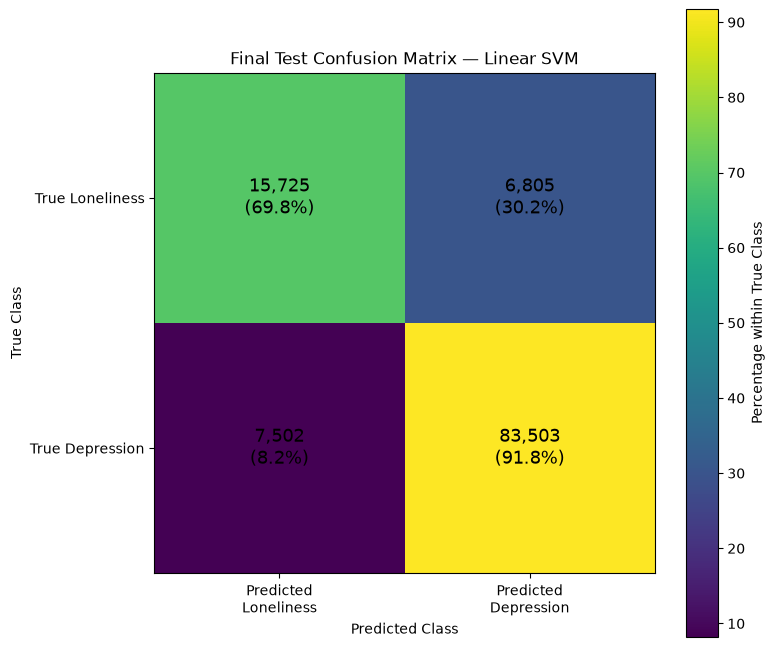


Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_5_final_test_confusion_matrix.png
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_5_final_test_confusion_matrix.pdf

PHASE 12.20 COMPLETED.


In [94]:
# ======================================================================================
# PHASE 12.20 — FIGURE 5: FINAL TEST CONFUSION MATRIX
# ======================================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 150)
print("PHASE 12.20 — FIGURE 5: FINAL TEST CONFUSION MATRIX")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE11_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase11_final_test"
)

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

FIGURE_DIR = (
    PHASE12_DIR
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Load final confusion summary
# ------------------------------------------------------------------

confusion_path = (
    PHASE11_DIR
    / "final_test_confusion_summary.csv"
)

confusion_df = pd.read_csv(
    confusion_path
)


# ------------------------------------------------------------------
# Primary Linear SVM
# ------------------------------------------------------------------

svm_row = (
    confusion_df[
        confusion_df["model"]
        ==
        "Linear SVM"
    ]
    .iloc[0]
)


cm = np.array([

    [
        int(
            svm_row[
                "true_loneliness"
            ]
        ),

        int(
            svm_row[
                "loneliness_as_depression"
            ]
        )
    ],

    [
        int(
            svm_row[
                "depression_as_loneliness"
            ]
        ),

        int(
            svm_row[
                "true_depression"
            ]
        )
    ]
])


# ------------------------------------------------------------------
# Row-normalized percentages
# ------------------------------------------------------------------

cm_percent = (
    cm
    /
    cm.sum(
        axis=1,
        keepdims=True
    )
    *
    100
)


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 7)
)


image = ax.imshow(
    cm_percent
)


ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)


ax.set_xticklabels(
    [
        "Predicted\nLoneliness",
        "Predicted\nDepression"
    ]
)

ax.set_yticklabels(
    [
        "True Loneliness",
        "True Depression"
    ]
)


ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)


ax.set_title(
    "Final Test Confusion Matrix — Linear SVM"
)


# ------------------------------------------------------------------
# Add counts + percentages
# ------------------------------------------------------------------

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        text = (
            f"{cm[i, j]:,}\n"
            f"({cm_percent[i, j]:.1f}%)"
        )


        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize=13
        )


cbar = fig.colorbar(
    image,
    ax=ax
)

cbar.set_label(
    "Percentage within True Class"
)


plt.tight_layout()


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

png_path = (
    FIGURE_DIR
    / "figure_5_final_test_confusion_matrix.png"
)

pdf_path = (
    FIGURE_DIR
    / "figure_5_final_test_confusion_matrix.pdf"
)


plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)


plt.show()


print("\nSaved:")
print(png_path)
print(pdf_path)

print("\nPHASE 12.20 COMPLETED.")

PHASE 12.21 — FIGURE 6: TOP NON-DIRECT LINGUISTIC FEATURES

Columns:
['feature', 'svm_coefficient', 'lr_coefficient', 'svm_abs_coefficient', 'lr_abs_coefficient', 'direct_shortcut', 'extended_cue', 'svm_abs_rank', 'lr_abs_rank', 'svm_direction', 'lr_direction', 'direction']


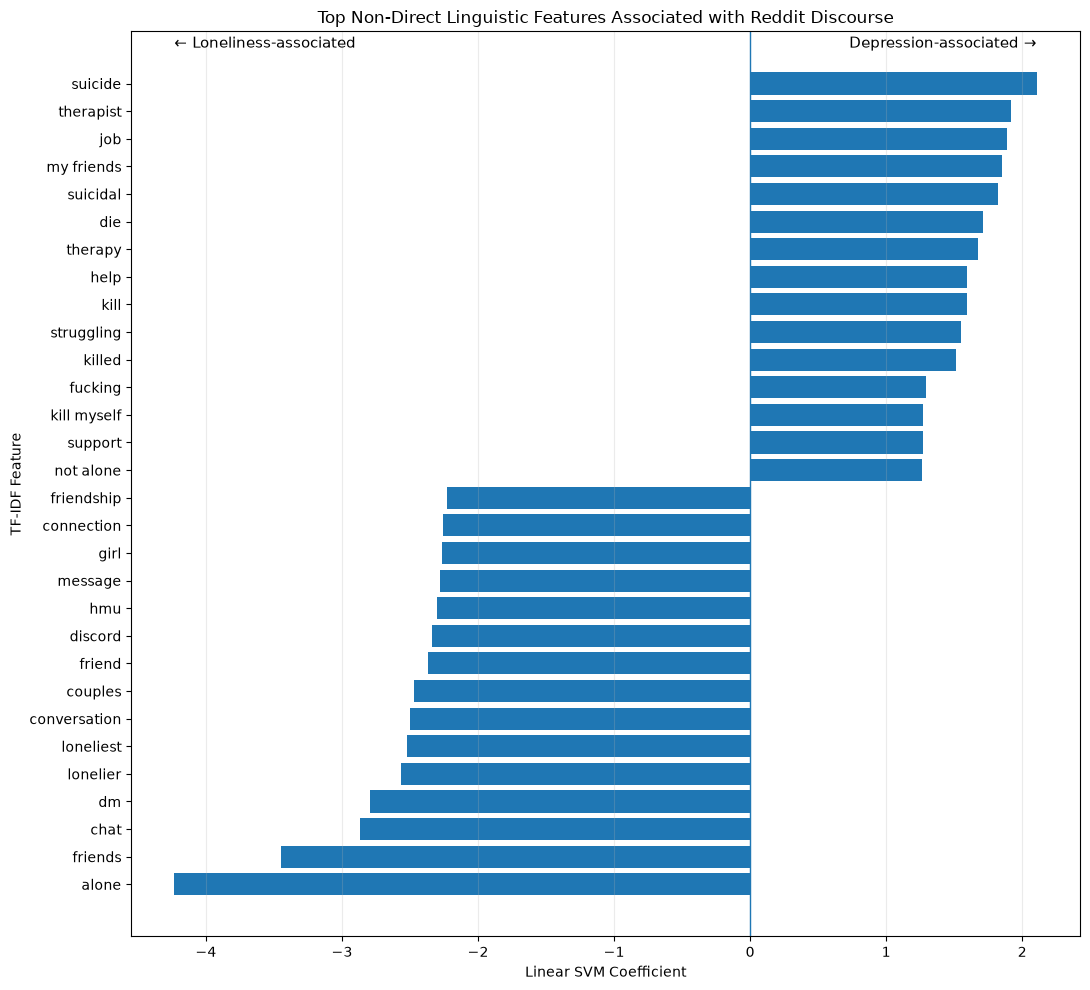


Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_6_top_non_direct_linguistic_features.png
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_6_top_non_direct_linguistic_features.pdf

PHASE 12.21 COMPLETED.


In [95]:
# ======================================================================================
# PHASE 12.21 — FIGURE 6: TOP NON-DIRECT LINGUISTIC FEATURES
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 150)
print("PHASE 12.21 — FIGURE 6: TOP NON-DIRECT LINGUISTIC FEATURES")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE9_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase9_interpretation_stability"
)

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

FIGURE_DIR = (
    PHASE12_DIR
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Load feature file
# ------------------------------------------------------------------

feature_path = (
    PHASE9_DIR
    / "svm_top_non_direct_features.csv"
)

feature_df = pd.read_csv(
    feature_path
)


print("\nColumns:")
print(
    feature_df.columns.tolist()
)


# ------------------------------------------------------------------
# Select top features
# ------------------------------------------------------------------

TOP_N = 15


dep_features = (
    feature_df[
        feature_df[
            "direction"
        ]
        ==
        "Depression-associated"
    ]
    .sort_values(
        "svm_coefficient",
        ascending=False
    )
    .head(
        TOP_N
    )
    .copy()
)


lon_features = (
    feature_df[
        feature_df[
            "direction"
        ]
        ==
        "Loneliness-associated"
    ]
    .sort_values(
        "svm_coefficient",
        ascending=True
    )
    .head(
        TOP_N
    )
    .copy()
)


# ------------------------------------------------------------------
# Combine
#
# Loneliness coefficients remain negative.
# Depression coefficients remain positive.
# ------------------------------------------------------------------

plot_df = pd.concat(
    [
        lon_features,
        dep_features
    ],
    ignore_index=True
)


plot_df = (
    plot_df
    .sort_values(
        "svm_coefficient"
    )
)


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 10)
)


y_position = np.arange(
    len(
        plot_df
    )
)


ax.barh(
    y_position,
    plot_df[
        "svm_coefficient"
    ]
)


ax.set_yticks(
    y_position
)

ax.set_yticklabels(
    plot_df[
        "feature"
    ]
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "Linear SVM Coefficient"
)

ax.set_ylabel(
    "TF-IDF Feature"
)


ax.set_title(
    "Top Non-Direct Linguistic Features Associated with Reddit Discourse"
)


# ------------------------------------------------------------------
# Direction labels
# ------------------------------------------------------------------

x_min = (
    plot_df[
        "svm_coefficient"
    ].min()
)

x_max = (
    plot_df[
        "svm_coefficient"
    ].max()
)


ax.text(
    x_min,
    len(plot_df) + 0.3,
    "← Loneliness-associated",
    ha="left",
    fontsize=11
)


ax.text(
    x_max,
    len(plot_df) + 0.3,
    "Depression-associated →",
    ha="right",
    fontsize=11
)


ax.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

png_path = (
    FIGURE_DIR
    / "figure_6_top_non_direct_linguistic_features.png"
)

pdf_path = (
    FIGURE_DIR
    / "figure_6_top_non_direct_linguistic_features.pdf"
)


plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)


plt.show()


print("\nSaved:")
print(png_path)
print(pdf_path)

print("\nPHASE 12.21 COMPLETED.")

PHASE 12.22 — FIGURE 7: ERROR RATE BY TEXT LENGTH

Loaded:


,length_quartile,true_class,n,median_word_count,correct,errors,error_rate
0,"(1.999, 39.0]",Depression,21764,15.0,19764,2000,0.091895
1,"(1.999, 39.0]",Loneliness,6786,18.0,4423,2363,0.348217
2,"(39.0, 98.0]",Depression,21989,67.0,20126,1863,0.084724
3,"(39.0, 98.0]",Loneliness,6325,65.0,4610,1715,0.271146
4,"(98.0, 197.0]",Depression,23036,139.0,21233,1803,0.078269
5,"(98.0, 197.0]",Loneliness,5328,136.0,4021,1307,0.245308
6,"(197.0, 7800.0]",Depression,24218,309.0,22649,1569,0.064787
7,"(197.0, 7800.0]",Loneliness,4091,287.0,2986,1105,0.270105


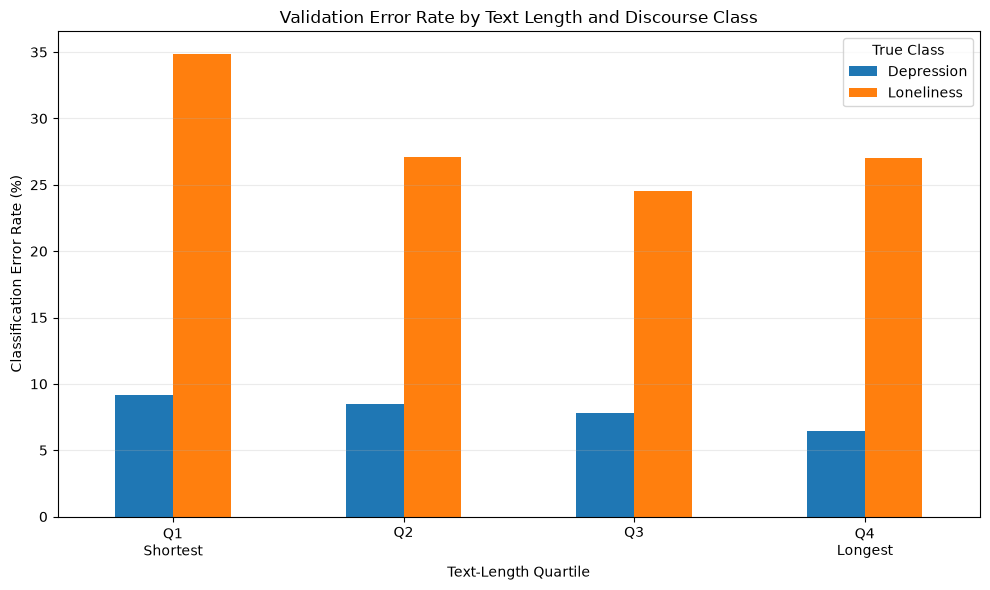


Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_7_error_rate_by_text_length.png
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_7_error_rate_by_text_length.pdf

PHASE 12.22 COMPLETED.


In [96]:
# ======================================================================================
# PHASE 12.22 — FIGURE 7: ERROR RATE BY TEXT LENGTH
# ======================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 150)
print("PHASE 12.22 — FIGURE 7: ERROR RATE BY TEXT LENGTH")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE9_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase9_interpretation_stability"
)

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

FIGURE_DIR = (
    PHASE12_DIR
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Load validation error-by-length analysis
# ------------------------------------------------------------------

length_path = (
    PHASE9_DIR
    / "validation_error_by_text_length.csv"
)

length_df = pd.read_csv(
    length_path
)


print("\nLoaded:")
display(
    length_df
)


# ------------------------------------------------------------------
# Create cleaner quartile labels
# ------------------------------------------------------------------

quartile_order = (
    length_df[
        "length_quartile"
    ]
    .drop_duplicates()
    .tolist()
)


quartile_label_map = {

    quartile_order[0]:
        "Q1\nShortest",

    quartile_order[1]:
        "Q2",

    quartile_order[2]:
        "Q3",

    quartile_order[3]:
        "Q4\nLongest",
}


length_df[
    "length_group"
] = (
    length_df[
        "length_quartile"
    ]
    .map(
        quartile_label_map
    )
)


# ------------------------------------------------------------------
# Pivot
# ------------------------------------------------------------------

plot_df = (
    length_df
    .pivot(
        index="length_group",
        columns="true_class",
        values="error_rate"
    )
)


desired_order = [

    "Q1\nShortest",

    "Q2",

    "Q3",

    "Q4\nLongest",
]


plot_df = (
    plot_df
    .reindex(
        desired_order
    )
)


# Convert to percent
plot_df = (
    plot_df
    *
    100
)


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)


plot_df.plot(
    kind="bar",
    ax=ax
)


ax.set_xlabel(
    "Text-Length Quartile"
)

ax.set_ylabel(
    "Classification Error Rate (%)"
)


ax.set_title(
    "Validation Error Rate by Text Length and Discourse Class"
)


ax.legend(
    title="True Class"
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.xticks(
    rotation=0
)


plt.tight_layout()


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

png_path = (
    FIGURE_DIR
    / "figure_7_error_rate_by_text_length.png"
)

pdf_path = (
    FIGURE_DIR
    / "figure_7_error_rate_by_text_length.pdf"
)


plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)


plt.show()


print("\nSaved:")
print(png_path)
print(pdf_path)

print("\nPHASE 12.22 COMPLETED.")

PHASE 12.23 — FIGURE 8: EXPERIMENT-1 WORKFLOW


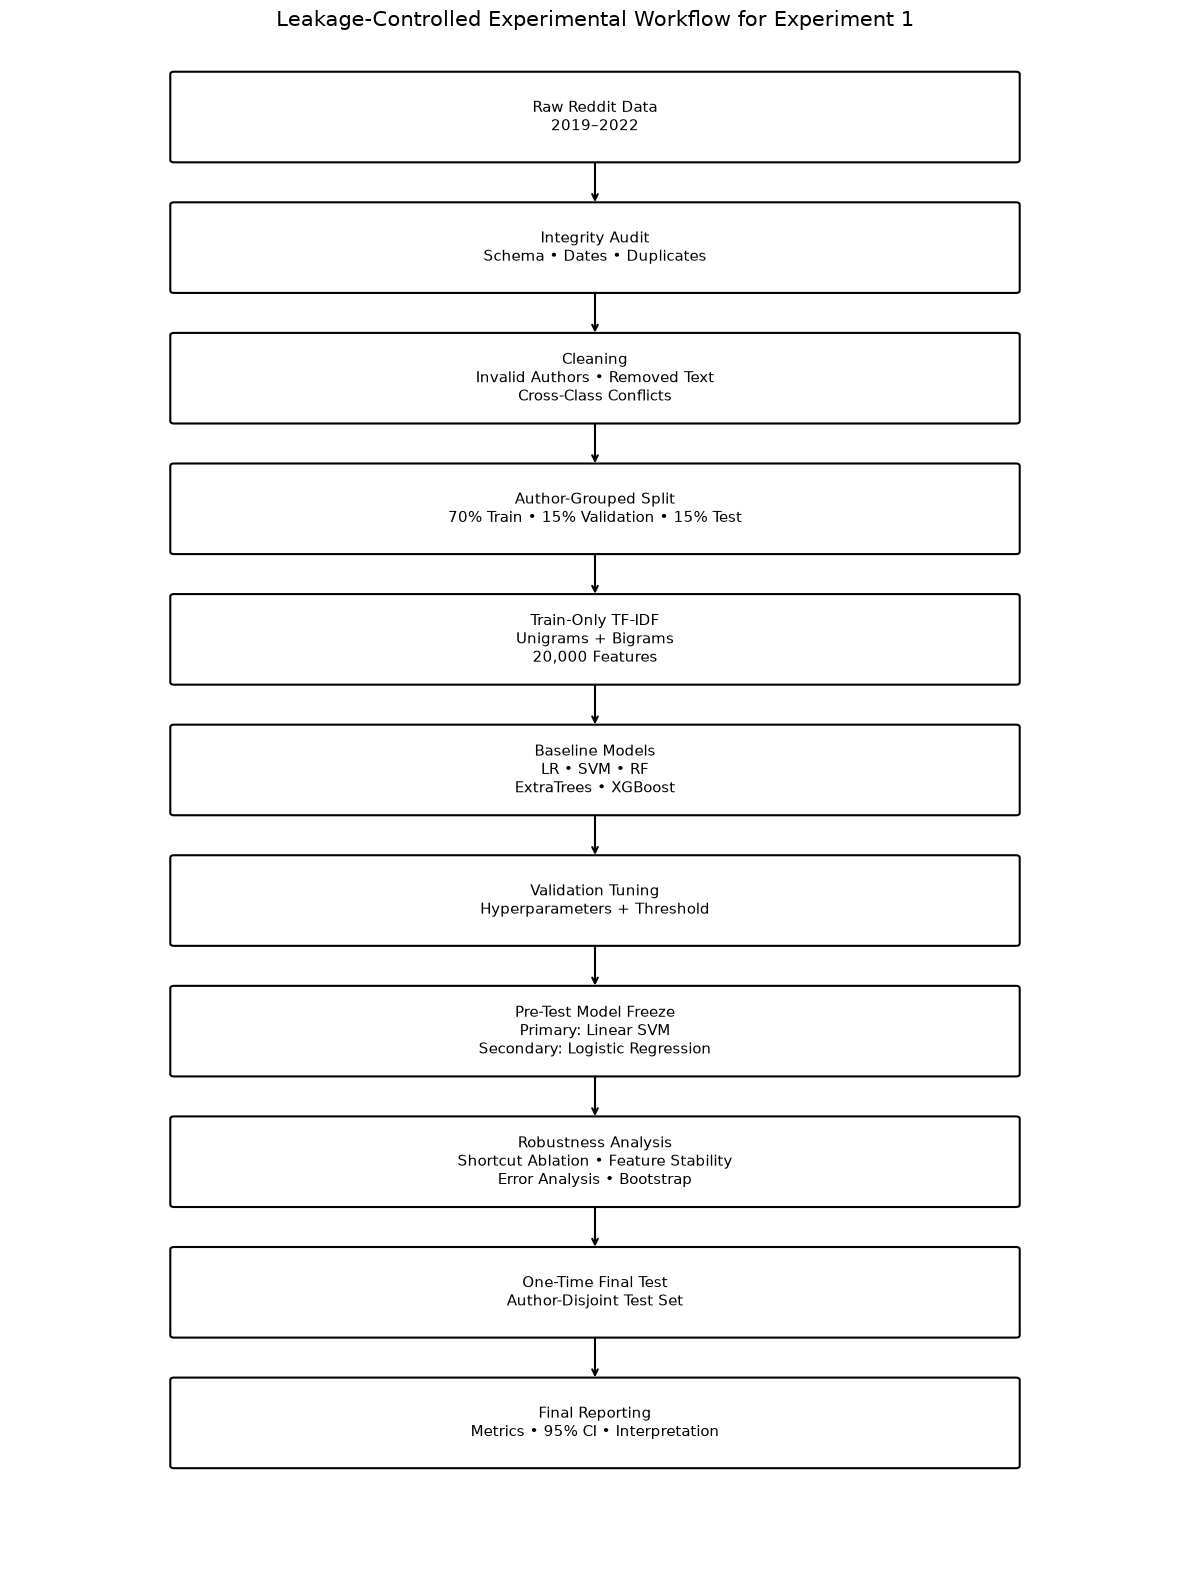


Saved:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_8_experiment1_workflow.png
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\outputs\phase12_final_reporting\figures\figure_8_experiment1_workflow.pdf

PHASE 12.23 COMPLETED.


In [97]:
# ======================================================================================
# PHASE 12.23 — FIGURE 8: EXPERIMENT-1 WORKFLOW
# ======================================================================================

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

print("=" * 150)
print("PHASE 12.23 — FIGURE 8: EXPERIMENT-1 WORKFLOW")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

PHASE12_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
)

FIGURE_DIR = (
    PHASE12_DIR
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------
# Workflow stages
# ------------------------------------------------------------------

stages = [

    "Raw Reddit Data\n2019–2022",

    "Integrity Audit\nSchema • Dates • Duplicates",

    "Cleaning\nInvalid Authors • Removed Text\nCross-Class Conflicts",

    "Author-Grouped Split\n70% Train • 15% Validation • 15% Test",

    "Train-Only TF-IDF\nUnigrams + Bigrams\n20,000 Features",

    "Baseline Models\nLR • SVM • RF\nExtraTrees • XGBoost",

    "Validation Tuning\nHyperparameters + Threshold",

    "Pre-Test Model Freeze\nPrimary: Linear SVM\nSecondary: Logistic Regression",

    "Robustness Analysis\nShortcut Ablation • Feature Stability\nError Analysis • Bootstrap",

    "One-Time Final Test\nAuthor-Disjoint Test Set",

    "Final Reporting\nMetrics • 95% CI • Interpretation",
]


# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 16)
)


ax.set_xlim(
    0,
    10
)

ax.set_ylim(
    0,
    len(stages) * 1.7
)

ax.axis(
    "off"
)


box_width = 7.2
box_height = 1.05
x = 1.4


y_positions = []


for i in range(
    len(stages)
):

    y = (
        len(stages) * 1.7
        -
        1.3
        -
        i * 1.6
    )

    y_positions.append(
        y
    )


# ------------------------------------------------------------------
# Draw boxes
# ------------------------------------------------------------------

for i, (
    stage,
    y
) in enumerate(
    zip(
        stages,
        y_positions
    )
):

    box = FancyBboxPatch(

        (
            x,
            y
        ),

        box_width,
        box_height,

        boxstyle="round,pad=0.03",

        linewidth=1.5,

        fill=False
    )


    ax.add_patch(
        box
    )


    ax.text(

        x
        +
        box_width / 2,

        y
        +
        box_height / 2,

        stage,

        ha="center",

        va="center",

        fontsize=11
    )


    # --------------------------------------------------------------
    # Arrow
    # --------------------------------------------------------------

    if i < len(stages) - 1:

        next_y = (
            y_positions[
                i + 1
            ]
            +
            box_height
        )


        ax.annotate(

            "",

            xy=(
                x
                +
                box_width / 2,
                next_y
            ),

            xytext=(
                x
                +
                box_width / 2,
                y
            ),

            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5
            )
        )


ax.set_title(
    "Leakage-Controlled Experimental Workflow for Experiment 1",
    fontsize=15,
    pad=20
)


plt.tight_layout()


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

png_path = (
    FIGURE_DIR
    / "figure_8_experiment1_workflow.png"
)

pdf_path = (
    FIGURE_DIR
    / "figure_8_experiment1_workflow.pdf"
)


plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)


plt.show()


print("\nSaved:")
print(png_path)
print(pdf_path)

print("\nPHASE 12.23 COMPLETED.")

In [98]:
# ======================================================================================
# PHASE 12.24 — VERIFY COMPLETE FIGURE SET
# ======================================================================================

from pathlib import Path

print("=" * 150)
print("PHASE 12.24 — COMPLETE FIGURE SET VERIFICATION")
print("=" * 150)


PROJECT_ROOT = Path.cwd()

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase12_final_reporting"
    / "figures"
)


expected_figures = {

    "Figure 1 — Final Test Performance":
        "figure_1_final_test_performance.png",

    "Figure 2 — Test 95% Confidence Intervals":
        "figure_2_test_confidence_intervals.png",

    "Figure 3 — Shortcut Robustness":
        "figure_3_shortcut_robustness.png",

    "Figure 4 — Validation vs Test Generalization":
        "figure_4_validation_test_generalization.png",

    "Figure 5 — Final Test Confusion Matrix":
        "figure_5_final_test_confusion_matrix.png",

    "Figure 6 — Top Linguistic Features":
        "figure_6_top_non_direct_linguistic_features.png",

    "Figure 7 — Error Rate by Text Length":
        "figure_7_error_rate_by_text_length.png",

    "Figure 8 — Experiment Workflow":
        "figure_8_experiment1_workflow.png",
}


all_figures_exist = True


for title, filename in expected_figures.items():

    path = (
        FIGURE_DIR
        / filename
    )


    exists = (
        path.exists()
    )


    print(
        f"{title:<60}: "
        f"{'PASS' if exists else 'FAIL'}"
    )


    if not exists:

        all_figures_exist = False


print("\n" + "=" * 150)


if all_figures_exist:

    print(
        "ALL 8 EXPERIMENT-1 FIGURES ARE READY"
    )

else:

    print(
        "ONE OR MORE FIGURES ARE MISSING"
    )


print("=" * 150)

PHASE 12.24 — COMPLETE FIGURE SET VERIFICATION
Figure 1 — Final Test Performance                           : PASS
Figure 2 — Test 95% Confidence Intervals                    : PASS
Figure 3 — Shortcut Robustness                              : PASS
Figure 4 — Validation vs Test Generalization                : PASS
Figure 5 — Final Test Confusion Matrix                      : PASS
Figure 6 — Top Linguistic Features                          : PASS
Figure 7 — Error Rate by Text Length                        : PASS
Figure 8 — Experiment Workflow                              : PASS

ALL 8 EXPERIMENT-1 FIGURES ARE READY


In [99]:
# ======================================================================================
# CLEAN OUTPUT FOLDER NAMES
# Remove phase1_, phase2_, ... prefixes
# Also update notebook.ipynb path references automatically
# ======================================================================================

from pathlib import Path
import shutil
import json

print("=" * 120)
print("CLEANING EXPERIMENT-1 OUTPUT FOLDER NAMES")
print("=" * 120)


# ======================================================================================
# PROJECT PATH
# ======================================================================================

PROJECT_ROOT = Path.cwd()

OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
)


# ======================================================================================
# RENAME MAP
# ======================================================================================

rename_map = {

    "phase1_audit":
        "audit",

    "phase2_integrity_audit":
        "integrity_audit",

    "phase3_cleaning":
        "cleaning",

    "phase4_splits":
        "splits",

    "phase5_features":
        "features",

    "phase6_baselines":
        "baselines",

    "phase7_tuning":
        "tuning",

    "phase8_shortcut_ablation":
        "shortcut_ablation",

    "phase9_interpretation_stability":
        "interpretation_stability",

    "phase10_uncertainty":
        "uncertainty",

    "phase11_final_test":
        "final_test",

    "phase12_final_reporting":
        "final_reporting",
}


# ======================================================================================
# SAFE MOVE / MERGE FUNCTION
# ======================================================================================

def safe_rename_or_merge(source, target):

    if not source.exists():

        print(
            f"SKIP  : {source.name} "
            f"(source not found)"
        )

        return True


    # ------------------------------------------------------------------
    # Normal rename if target does not exist
    # ------------------------------------------------------------------

    if not target.exists():

        source.rename(
            target
        )

        print(
            f"RENAMED: "
            f"{source.name} -> {target.name}"
        )

        return True


    # ------------------------------------------------------------------
    # Target already exists
    # ------------------------------------------------------------------

    print(
        f"\nTARGET EXISTS: {target.name}"
    )


    # If target directory is empty, replace it
    if (
        target.is_dir()
        and
        not any(
            target.iterdir()
        )
    ):

        target.rmdir()

        source.rename(
            target
        )

        print(
            f"RENAMED: "
            f"{source.name} -> {target.name} "
            f"(empty old target removed)"
        )

        return True


    # ------------------------------------------------------------------
    # Safe merge
    # ------------------------------------------------------------------

    if (
        source.is_dir()
        and
        target.is_dir()
    ):

        collisions = []


        for item in source.iterdir():

            destination = (
                target
                / item.name
            )

            if destination.exists():

                collisions.append(
                    item.name
                )


        # --------------------------------------------------------------
        # Stop instead of overwriting
        # --------------------------------------------------------------

        if collisions:

            print(
                f"WARNING: Cannot safely merge "
                f"{source.name} -> {target.name}"
            )

            print(
                "Duplicate filenames/folders found:"
            )

            for name in collisions[:20]:

                print(
                    "   -",
                    name
                )


            if len(collisions) > 20:

                print(
                    f"   ... and "
                    f"{len(collisions) - 20} more"
                )


            print(
                "Nothing was overwritten."
            )

            return False


        # --------------------------------------------------------------
        # Merge without collisions
        # --------------------------------------------------------------

        for item in list(
            source.iterdir()
        ):

            shutil.move(
                str(item),
                str(
                    target
                    / item.name
                )
            )


        source.rmdir()


        print(
            f"MERGED : "
            f"{source.name} -> {target.name}"
        )

        return True


    print(
        f"FAILED: Cannot process "
        f"{source} -> {target}"
    )

    return False


# ======================================================================================
# PERFORM RENAMES
# ======================================================================================

print("\nFOLDER RENAMING")
print("-" * 120)


successful_replacements = {}


for old_name, new_name in rename_map.items():

    source = (
        OUTPUTS_DIR
        / old_name
    )

    target = (
        OUTPUTS_DIR
        / new_name
    )


    success = safe_rename_or_merge(
        source,
        target
    )


    if success:

        successful_replacements[
            old_name
        ] = new_name


# ======================================================================================
# UPDATE NOTEBOOK PATH REFERENCES
# ======================================================================================

print("\n")
print("=" * 120)
print("UPDATING NOTEBOOK PATH REFERENCES")
print("=" * 120)


notebook_path = (
    PROJECT_ROOT
    / "notebook.ipynb"
)


if notebook_path.exists():

    # ------------------------------------------------------------------
    # Backup first
    # ------------------------------------------------------------------

    backup_path = (
        PROJECT_ROOT
        / "notebook_before_folder_rename_backup.ipynb"
    )


    if not backup_path.exists():

        shutil.copy2(
            notebook_path,
            backup_path
        )

        print(
            "\nNotebook backup created:"
        )

        print(
            backup_path
        )

    else:

        print(
            "\nNotebook backup already exists:"
        )

        print(
            backup_path
        )


    # ------------------------------------------------------------------
    # Read notebook
    # ------------------------------------------------------------------

    with open(
        notebook_path,
        "r",
        encoding="utf-8"
    ) as f:

        notebook_data = json.load(
            f
        )


    replacement_count = 0


    # ------------------------------------------------------------------
    # Recursive replacement
    # ------------------------------------------------------------------

    def replace_paths(obj):

        global replacement_count


        if isinstance(
            obj,
            dict
        ):

            return {

                key:
                    replace_paths(
                        value
                    )

                for key, value
                in obj.items()
            }


        elif isinstance(
            obj,
            list
        ):

            return [

                replace_paths(
                    item
                )

                for item in obj
            ]


        elif isinstance(
            obj,
            str
        ):

            original_text = obj

            updated_text = obj


            for (
                old_name,
                new_name
            ) in successful_replacements.items():

                # Forward-slash paths
                updated_text = (
                    updated_text
                    .replace(
                        f"outputs/{old_name}",
                        f"outputs/{new_name}"
                    )
                )


                # Windows backslash paths
                updated_text = (
                    updated_text
                    .replace(
                        f"outputs\\\\{old_name}",
                        f"outputs\\\\{new_name}"
                    )
                )


                # Plain directory-name references
                updated_text = (
                    updated_text
                    .replace(
                        old_name,
                        new_name
                    )
                )


            if updated_text != original_text:

                replacement_count += 1


            return updated_text


        else:

            return obj


    notebook_data = replace_paths(
        notebook_data
    )


    # ------------------------------------------------------------------
    # Save updated notebook
    # ------------------------------------------------------------------

    with open(
        notebook_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            notebook_data,
            f,
            ensure_ascii=False,
            indent=1
        )


    print(
        "\nNotebook updated successfully."
    )

    print(
        "Notebook text blocks changed:",
        replacement_count
    )


else:

    print(
        "\nWARNING: notebook.ipynb not found."
    )


# ======================================================================================
# FINAL DIRECTORY LIST
# ======================================================================================

print("\n")
print("=" * 120)
print("FINAL OUTPUT DIRECTORY STRUCTURE")
print("=" * 120)


for path in sorted(
    OUTPUTS_DIR.iterdir(),
    key=lambda p:
        p.name.lower()
):

    if path.is_dir():

        print(
            f"[DIR]  {path.name}"
        )

    else:

        print(
            f"[FILE] {path.name}"
        )


# ======================================================================================
# CHECK WHETHER OLD PHASE FOLDERS REMAIN
# ======================================================================================

remaining_phase_folders = [

    path.name

    for path in OUTPUTS_DIR.iterdir()

    if (
        path.is_dir()
        and
        path.name.startswith(
            "phase"
        )
    )
]


print("\n")
print("=" * 120)
print("FINAL CHECK")
print("=" * 120)


if len(
    remaining_phase_folders
) == 0:

    print(
        "PASS — All phase prefixes removed successfully."
    )

else:

    print(
        "Some phase folders remain:"
    )

    for folder in remaining_phase_folders:

        print(
            "   -",
            folder
        )


print("\nClean naming process completed.")

CLEANING EXPERIMENT-1 OUTPUT FOLDER NAMES

FOLDER RENAMING
------------------------------------------------------------------------------------------------------------------------
RENAMED: phase1_audit -> audit
RENAMED: phase2_integrity_audit -> integrity_audit
RENAMED: phase3_cleaning -> cleaning

TARGET EXISTS: splits
RENAMED: phase4_splits -> splits (empty old target removed)
RENAMED: phase5_features -> features
RENAMED: phase6_baselines -> baselines
RENAMED: phase7_tuning -> tuning
RENAMED: phase8_shortcut_ablation -> shortcut_ablation
RENAMED: phase9_interpretation_stability -> interpretation_stability
RENAMED: phase10_uncertainty -> uncertainty
RENAMED: phase11_final_test -> final_test
RENAMED: phase12_final_reporting -> final_reporting


UPDATING NOTEBOOK PATH REFERENCES

Notebook backup created:
d:\Thesis_Project\Experiment_1_Loneliness_vs_Depression\notebook_before_folder_rename_backup.ipynb

Notebook updated successfully.
Notebook text blocks changed: 0


FINAL OUTPUT DIRECTO